In [1]:
import numpy as np
import matplotlib.pylab as plt
%matplotlib inline
#%config InlineBackend.figure_format = 'eps'


import scienceplots
import pandas as pd

plt.style.use('science')
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from matplotlib.patches import  ConnectionPatch

### CA-Hepth datasets

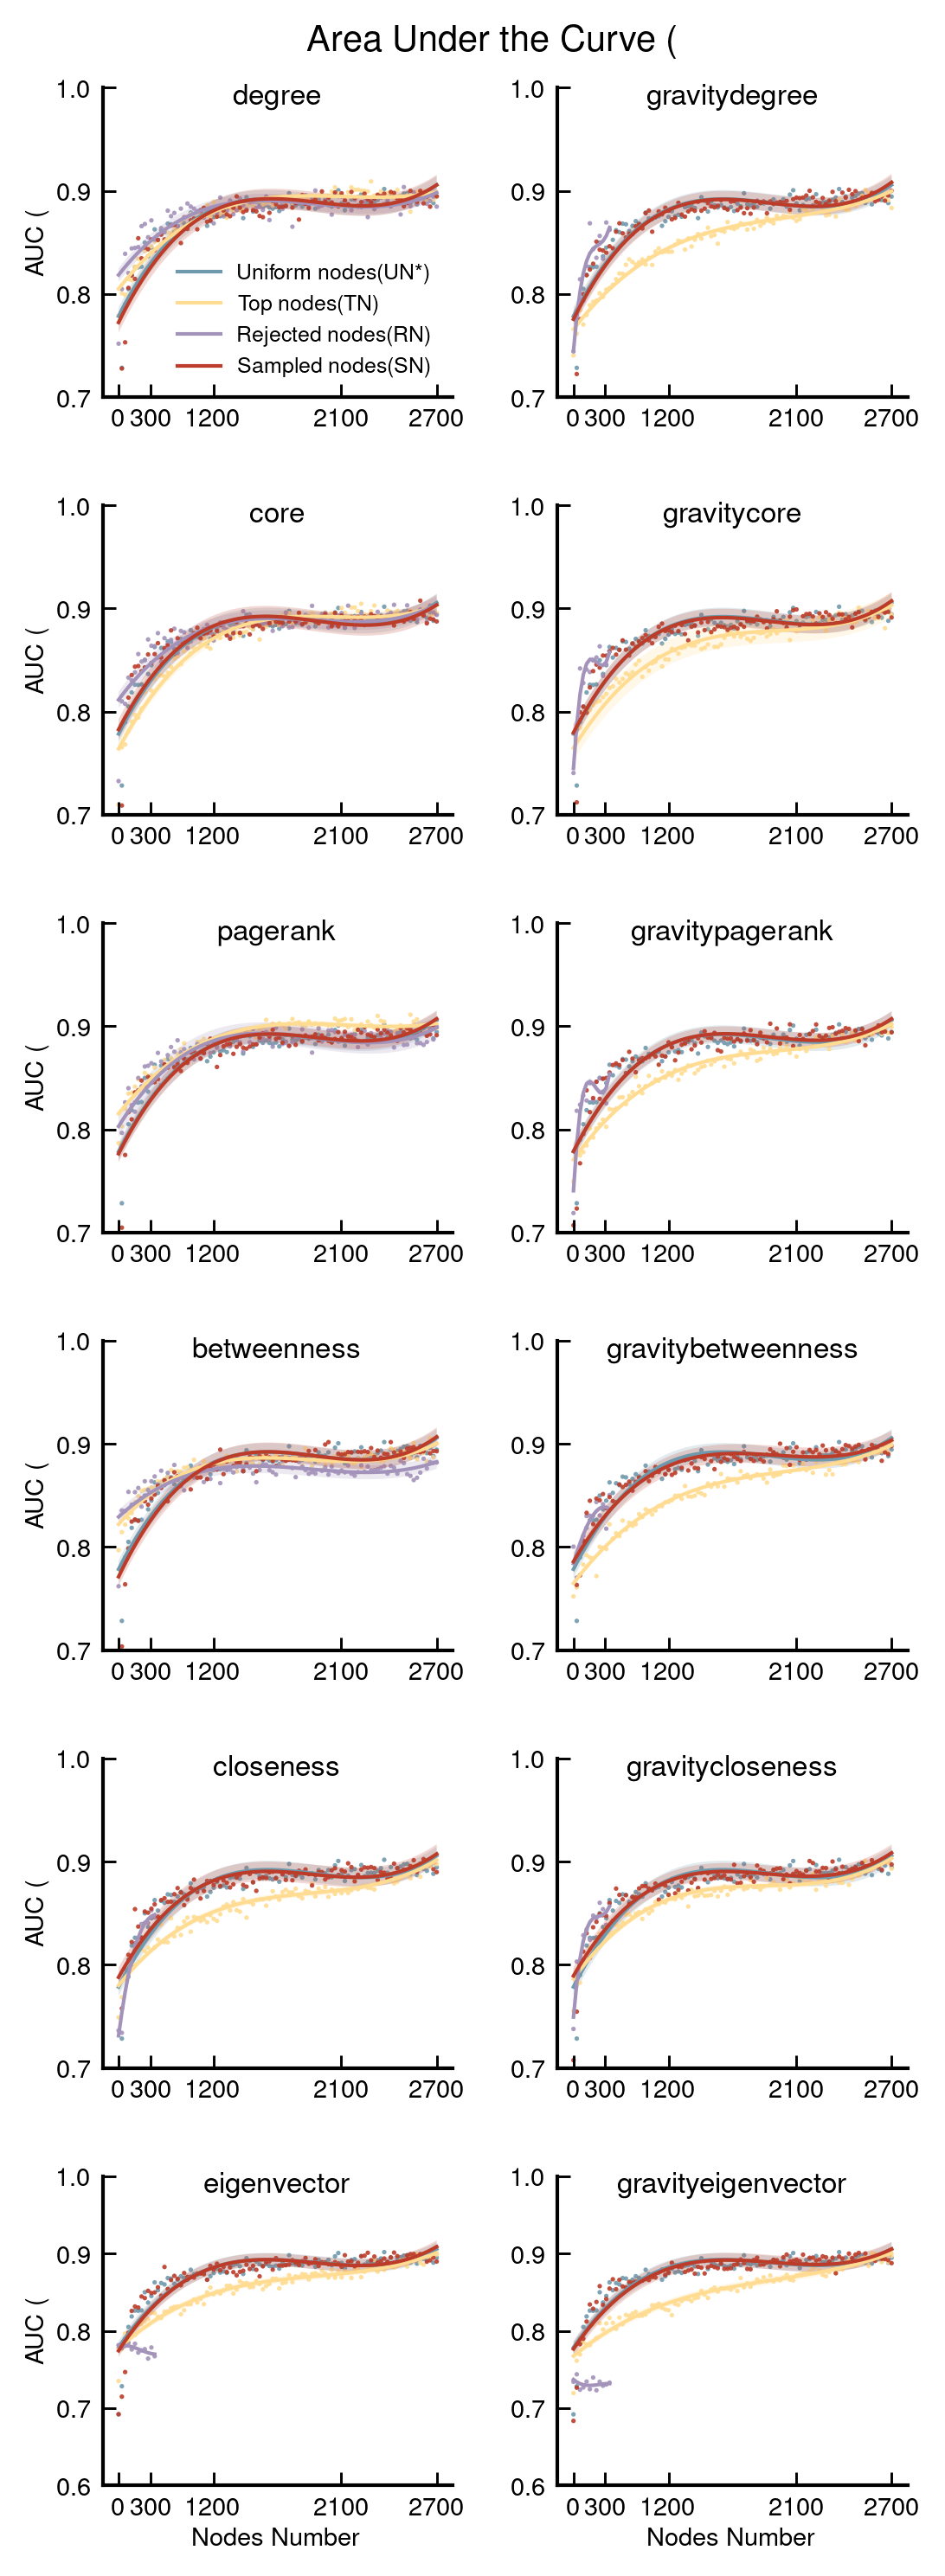

In [2]:
# Samped nodes by probability
cath_degree_sn = pd.read_csv('cath/convert_accuracy/cath_gcn_vae_degree_sn.csv')
cath_core_sn = pd.read_csv('cath/convert_accuracy/cath_gcn_vae_core_sn.csv')
cath_betweenness_sn = pd.read_csv('cath/convert_accuracy/cath_gcn_vae_betweenness_sn.csv')
cath_eigenvector_sn = pd.read_csv('cath/convert_accuracy/cath_gcn_vae_eigenvector_sn.csv')
cath_pagerank_sn = pd.read_csv('cath/convert_accuracy/cath_gcn_vae_pagerank_sn.csv')
cath_closeness_sn = pd.read_csv('cath/convert_accuracy/cath_gcn_vae_closeness_sn.csv')
cath_gravitydegree_sn = pd.read_csv('cath/convert_accuracy/cath_gcn_vae_gravitydegree_sn.csv')
cath_gravitypagerank_sn  = pd.read_csv('cath/convert_accuracy/cath_gcn_vae_gravitypagerank_sn.csv')
cath_gravitycore_sn = pd.read_csv('cath/convert_accuracy/cath_gcn_vae_gravitycore_sn.csv')
cath_gravitybetweenness_sn = pd.read_csv('cath/convert_accuracy/cath_gcn_vae_gravitybetweenness_sn.csv')
cath_gravityeigenvector_sn = pd.read_csv('cath/convert_accuracy/cath_gcn_vae_gravityeigenvector_sn.csv')
cath_gravitycloseness_sn = pd.read_csv('cath/convert_accuracy/cath_gcn_vae_gravitycloseness_sn.csv')


cath_degree_tn = pd.read_csv('cath/convert_accuracy/cath_gcn_vae_degree_tn.csv')
cath_core_tn = pd.read_csv('cath/convert_accuracy/cath_gcn_vae_core_tn.csv')
cath_betweenness_tn = pd.read_csv('cath/convert_accuracy/cath_gcn_vae_betweenness_tn.csv')
cath_eigenvector_tn = pd.read_csv('cath/convert_accuracy/cath_gcn_vae_eigenvector_tn.csv')
cath_pagerank_tn = pd.read_csv('cath/convert_accuracy/cath_gcn_vae_pagerank_tn.csv')
cath_closeness_tn = pd.read_csv('cath/convert_accuracy/cath_gcn_vae_closeness_tn.csv')
cath_gravitydegree_tn = pd.read_csv('cath/convert_accuracy/cath_gcn_vae_gravitydegree_tn.csv')
cath_gravitypagerank_tn  = pd.read_csv('cath/convert_accuracy/cath_gcn_vae_gravitypagerank_tn.csv')
cath_gravitycore_tn = pd.read_csv('cath/convert_accuracy/cath_gcn_vae_gravitycore_tn.csv')
cath_gravitybetweenness_tn = pd.read_csv('cath/convert_accuracy/cath_gcn_vae_gravitybetweenness_tn.csv')
cath_gravityeigenvector_tn = pd.read_csv('cath/convert_accuracy/cath_gcn_vae_gravityeigenvector_tn.csv')
cath_gravitycloseness_tn = pd.read_csv('cath/convert_accuracy/cath_gcn_vae_gravitycloseness_tn.csv')

cath_degree_rn = pd.read_csv('cath/convert_accuracy/cath_gcn_vae_degree_rn.csv')
cath_core_rn = pd.read_csv('cath/convert_accuracy/cath_gcn_vae_core_rn.csv')
cath_betweenness_rn = pd.read_csv('cath/convert_accuracy/cath_gcn_vae_betweenness_rn.csv')
cath_eigenvector_rn = pd.read_csv('cath/convert_accuracy/cath_gcn_vae_eigenvector_rn.csv')
cath_pagerank_rn = pd.read_csv('cath/convert_accuracy/cath_gcn_vae_pagerank_rn.csv')
cath_closeness_rn = pd.read_csv('cath/convert_accuracy/cath_gcn_vae_closeness_rn.csv')
cath_gravitydegree_rn = pd.read_csv('cath/convert_accuracy/cath_gcn_vae_gravitydegree_rn.csv')
cath_gravitypagerank_rn  = pd.read_csv('cath/convert_accuracy/cath_gcn_vae_gravitypagerank_rn.csv')
cath_gravitycore_rn = pd.read_csv('cath/convert_accuracy/cath_gcn_vae_gravitycore_rn.csv')
cath_gravitybetweenness_rn = pd.read_csv('cath/convert_accuracy/cath_gcn_vae_gravitybetweenness_rn.csv')
cath_gravityeigenvector_rn = pd.read_csv('cath/convert_accuracy/cath_gcn_vae_gravityeigenvector_rn.csv')
cath_gravitycloseness_rn = pd.read_csv('cath/convert_accuracy/cath_gcn_vae_gravitycloseness_rn.csv')

cath_uniform = pd.read_csv('cath/convert_accuracy/cath_gcn_vae_degree_un.csv')



plt.style.use('nature')
from scipy.optimize import curve_fit
from scipy.interpolate import UnivariateSpline


def cubic_fit(x, a, b, c, d):
    return a * x**3 + b * x**2 + c * x + d

x = np.linspace(0,1,98)

fig,axes = plt.subplots(6,2,figsize = (2,6),dpi=600)
params, covariance = curve_fit(cubic_fit, x, cath_uniform['mean_auc'].values)
a_fit, b_fit, c_fit, d_fit = params
cath_uniform1 = cubic_fit(x, a_fit, b_fit, c_fit, d_fit)
axes[0,0].plot(x,cath_uniform1,color ='#6F99ADFF', label = 'Uniform nodes(UN*)',linewidth=0.5)
axes[0,0].scatter(x, cath_uniform['mean_auc'].values,color ='#6F99ADFF',edgecolors='none', s=0.4, alpha=0.9)
distances = 0.4* np.abs(cath_uniform['mean_auc'].values - cath_uniform1)
spline = UnivariateSpline(np.arange(len(distances)), distances.flatten(), s=0)
smooth_distances = spline(np.arange(len(distances)))
smooth_distances_mean = np.mean([np.min(smooth_distances), np.max(smooth_distances)])* 2/4
axes[0,0].fill_between(x, cath_uniform1-smooth_distances_mean, cath_uniform1+smooth_distances_mean, color='#6F99ADFF', alpha=0.2,edgecolors='none')
params, covariance = curve_fit(cubic_fit, x, cath_degree_tn['mean_auc'].values)
a_fit, b_fit, c_fit, d_fit = params
cath_degree_fit = cubic_fit(x, a_fit, b_fit, c_fit, d_fit)
axes[0,0].plot(x, cath_degree_fit, color='#FFDC91FF', label='Top nodes(TN)', linewidth=0.5)
axes[0,0].scatter(x, cath_degree_tn['mean_auc'].values, color ='#FFDC91FF',edgecolors='none', s=0.4, alpha=0.9)
distances = 0.4* np.abs(cath_degree_tn['mean_auc'].values - cath_degree_fit)
spline = UnivariateSpline(np.arange(len(distances)), distances.flatten(), s=0)
smooth_distances = spline(np.arange(len(distances)))
smooth_distances_mean = np.mean([np.min(smooth_distances), np.max(smooth_distances)]) * 2/4
axes[0,0].fill_between(x, cath_degree_fit - smooth_distances_mean, cath_degree_fit + smooth_distances_mean, color='#FFDC91FF', alpha=0.2,edgecolors='none')
params, covariance = curve_fit(cubic_fit, x, cath_degree_rn['mean_auc'].values)
a_fit, b_fit, c_fit, d_fit = params
cath_degree_fit = cubic_fit(x, a_fit, b_fit, c_fit, d_fit)
axes[0,0].plot(x, cath_degree_fit, color='#A392BA', label='Rejected nodes(RN)', linewidth=0.5)
axes[0,0].scatter(x, cath_degree_rn['mean_auc'].values, color ='#A392BA',edgecolors='none', s=0.4, alpha=0.9)
distances = 0.4* np.abs(cath_degree_rn['mean_auc'].values - cath_degree_fit)
spline = UnivariateSpline(np.arange(len(distances)), distances.flatten(), s=0)
smooth_distances = spline(np.arange(len(distances)))
smooth_distances_mean = np.mean([np.min(smooth_distances), np.max(smooth_distances)]) * 2/4
axes[0,0].fill_between(x, cath_degree_fit - smooth_distances_mean, cath_degree_fit + smooth_distances_mean, color='#A392BA', alpha=0.2,edgecolors='none')
params, covariance = curve_fit(cubic_fit, x, cath_degree_sn['mean_auc'].values)
a_fit, b_fit, c_fit, d_fit = params
cath_degree_fit = cubic_fit(x, a_fit, b_fit, c_fit, d_fit)
axes[0,0].plot(x, cath_degree_fit, color='#BC3C29FF', label='Sampled nodes(SN)', linewidth=0.5)
axes[0,0].scatter(x, cath_degree_sn['mean_auc'].values, color ='#BC3C29FF',edgecolors='none', s=0.4, alpha=0.9)
distances = 0.4* np.abs(cath_degree_sn['mean_auc'].values - cath_degree_fit)
spline = UnivariateSpline(np.arange(len(distances)), distances.flatten(), s=0)
smooth_distances = spline(np.arange(len(distances)))
smooth_distances_mean = np.mean([np.min(smooth_distances), np.max(smooth_distances)]) * 2/4
axes[0,0].fill_between(x, cath_degree_fit - smooth_distances_mean, cath_degree_fit + smooth_distances_mean, color='#BC3C29FF', alpha=0.2,edgecolors='none')
axes[0,0].tick_params(labelsize=4)
axes[0,0].set_xticks([0,0.12,0.35,0.7,1])
axes[0,0].set_xticklabels(np.array([0, 300,1000, 2000, 2700]).astype(int))
axes[0,0].legend(fontsize=3,edgecolor='black',framealpha=0.1,loc='best',frameon=False)
axes[0,0].grid (False)
axes[0,0].spines['top'].set_visible(False)
axes[0,0].spines['right'].set_visible(False)
axes[0,0].xaxis.set_ticks_position('bottom')
axes[0,0].yaxis.set_ticks_position('left')
axes[0,0].set_ylim([0.7,1])
axes[0,0].set_yticks(np.linspace(0.6, 1, 5))
axes[0,0].set_yticks([0.6, 0.7, 0.8, 0.9,1])
axes[0,0].set_xticks([], minor=True)
axes[0,0].set_yticks([], minor=True)
axes[0,0].tick_params(axis='both', which='both', length=1.2)
axes[0,0].text(0.5, 0.97, 'degree', transform=axes[0,0].transAxes, ha='center', va='center', bbox=dict(facecolor='none', edgecolor='none', boxstyle='round', alpha=0.0), fontsize=4)

params, covariance = curve_fit(cubic_fit, x, cath_uniform['mean_auc'].values)
a_fit, b_fit, c_fit, d_fit = params
cath_uniform1 = cubic_fit(x, a_fit, b_fit, c_fit, d_fit)
axes[1,0].plot(x,cath_uniform1,color ='#6F99ADFF', label = 'Uniform nodes(UN*)',linewidth=0.5)
axes[1,0].scatter(x, cath_uniform['mean_auc'].values,color ='#6F99ADFF',edgecolors='none', s=0.4, alpha=0.9)
distances = 0.4* np.abs(cath_uniform['mean_auc'].values - cath_uniform1)
spline = UnivariateSpline(np.arange(len(distances)), distances.flatten(), s=0)
smooth_distances = spline(np.arange(len(distances)))
smooth_distances_mean = np.mean([np.min(smooth_distances), np.max(smooth_distances)])* 2/4
axes[1,0].fill_between(x, cath_uniform1-smooth_distances_mean, cath_uniform1+smooth_distances_mean, color='#6F99ADFF', alpha=0.2,edgecolors='none')
params, covariance = curve_fit(cubic_fit, x, cath_core_tn['mean_auc'].values)
a_fit, b_fit, c_fit, d_fit = params
cath_core_fit = cubic_fit(x, a_fit, b_fit, c_fit, d_fit)
axes[1,0].plot(x, cath_core_fit, color='#FFDC91FF', label='Top nodes(TN)', linewidth=0.5)
axes[1,0].scatter(x, cath_core_tn['mean_auc'].values, color ='#FFDC91FF',edgecolors='none', s=0.4, alpha=0.9)
distances = 0.4* np.abs(cath_core_tn['mean_auc'].values - cath_core_fit)
spline = UnivariateSpline(np.arange(len(distances)), distances.flatten(), s=0)
smooth_distances = spline(np.arange(len(distances)))
smooth_distances_mean = np.mean([np.min(smooth_distances), np.max(smooth_distances)]) * 2/4
axes[1,0].fill_between(x, cath_core_fit - smooth_distances_mean, cath_core_fit + smooth_distances_mean, color='#FFDC91FF', alpha=0.2,edgecolors='none')
params, covariance = curve_fit(cubic_fit, x, cath_core_rn['mean_auc'].values)
a_fit, b_fit, c_fit, d_fit = params
cath_core_fit = cubic_fit(x, a_fit, b_fit, c_fit, d_fit)
axes[1,0].plot(x, cath_core_fit, color='#A392BA', label='Rejected nodes(RN)', linewidth=0.5)
axes[1,0].scatter(x, cath_core_rn['mean_auc'].values, color ='#A392BA',edgecolors='none', s=0.4, alpha=0.9)
distances = 0.4* np.abs(cath_core_rn['mean_auc'].values - cath_core_fit)
spline = UnivariateSpline(np.arange(len(distances)), distances.flatten(), s=0)
smooth_distances = spline(np.arange(len(distances)))
smooth_distances_mean = np.mean([np.min(smooth_distances), np.max(smooth_distances)]) * 2/4
axes[1,0].fill_between(x, cath_core_fit - smooth_distances_mean, cath_core_fit + smooth_distances_mean, color='#A392BA', alpha=0.2,edgecolors='none')
params, covariance = curve_fit(cubic_fit, x, cath_core_sn['mean_auc'].values)
a_fit, b_fit, c_fit, d_fit = params
cath_core_fit = cubic_fit(x, a_fit, b_fit, c_fit, d_fit)
axes[1,0].plot(x, cath_core_fit, color='#BC3C29FF', label='Sampled nodes(SN)', linewidth=0.5)
axes[1,0].scatter(x, cath_core_sn['mean_auc'].values, color ='#BC3C29FF',edgecolors='none', s=0.4, alpha=0.9)
distances = 0.4* np.abs(cath_core_sn['mean_auc'].values - cath_core_fit)
spline = UnivariateSpline(np.arange(len(distances)), distances.flatten(), s=0)
smooth_distances = spline(np.arange(len(distances)))
smooth_distances_mean = np.mean([np.min(smooth_distances), np.max(smooth_distances)]) * 2/4
axes[1,0].fill_between(x, cath_core_fit - smooth_distances_mean, cath_core_fit + smooth_distances_mean, color='#BC3C29FF', alpha=0.2,edgecolors='none')
axes[1,0].tick_params(labelsize=4)
axes[1,0].set_xticks([0,0.12,0.35,0.7,1])
axes[1,0].set_xticklabels(np.array([0, 300,1000, 2000, 2700]).astype(int))
# axes[1,0].legend(fontsize=3,edgecolor='black',framealpha=0.1,loc='best',frameon=False)
axes[1,0].grid (False)
axes[1,0].spines['top'].set_visible(False)
axes[1,0].spines['right'].set_visible(False)
axes[1,0].xaxis.set_ticks_position('bottom')
axes[1,0].yaxis.set_ticks_position('left')
axes[1,0].set_ylim([0.7,1])
axes[1,0].set_yticks(np.linspace(0.6, 1, 5))
axes[1,0].set_yticks([0.6, 0.7, 0.8, 0.9,1])
axes[1,0].set_xticks([], minor=True)
axes[1,0].set_yticks([], minor=True)
axes[1,0].tick_params(axis='both', which='both', length=1.2)
axes[1,0].text(0.5, 0.97, 'core', transform=axes[1,0].transAxes, ha='center', va='center', bbox=dict(facecolor='none', edgecolor='none', boxstyle='round', alpha=0.0), fontsize=4)


params, covariance = curve_fit(cubic_fit, x, cath_uniform['mean_auc'].values)
a_fit, b_fit, c_fit, d_fit = params
cath_uniform1 = cubic_fit(x, a_fit, b_fit, c_fit, d_fit)
axes[2,0].plot(x,cath_uniform1,color ='#6F99ADFF', label = 'Uniform nodes(UN*)',linewidth=0.5)
axes[2,0].scatter(x, cath_uniform['mean_auc'].values,color ='#6F99ADFF',edgecolors='none', s=0.4, alpha=0.9)
distances = 0.4* np.abs(cath_uniform['mean_auc'].values - cath_uniform1)
spline = UnivariateSpline(np.arange(len(distances)), distances.flatten(), s=0)
smooth_distances = spline(np.arange(len(distances)))
smooth_distances_mean = np.mean([np.min(smooth_distances), np.max(smooth_distances)])* 2/4
axes[2,0].fill_between(x, cath_uniform1-smooth_distances_mean, cath_uniform1+smooth_distances_mean, color='#6F99ADFF', alpha=0.2,edgecolors='none')
params, covariance = curve_fit(cubic_fit, x, cath_pagerank_tn['mean_auc'].values)
a_fit, b_fit, c_fit, d_fit = params
cath_pagerank_fit = cubic_fit(x, a_fit, b_fit, c_fit, d_fit)
axes[2,0].plot(x, cath_pagerank_fit, color='#FFDC91FF', label='Top nodes(TN)', linewidth=0.5)
axes[2,0].scatter(x, cath_pagerank_tn['mean_auc'].values, color ='#FFDC91FF',edgecolors='none', s=0.4, alpha=0.9)
distances = 0.4* np.abs(cath_pagerank_tn['mean_auc'].values - cath_pagerank_fit)
spline = UnivariateSpline(np.arange(len(distances)), distances.flatten(), s=0)
smooth_distances = spline(np.arange(len(distances)))
smooth_distances_mean = np.mean([np.min(smooth_distances), np.max(smooth_distances)]) * 2/4
axes[2,0].fill_between(x, cath_pagerank_fit - smooth_distances_mean, cath_pagerank_fit + smooth_distances_mean, color='#FFDC91FF', alpha=0.2,edgecolors='none')
params, covariance = curve_fit(cubic_fit, x, cath_pagerank_rn['mean_auc'].values)
a_fit, b_fit, c_fit, d_fit = params
cath_pagerank_fit = cubic_fit(x, a_fit, b_fit, c_fit, d_fit)
axes[2,0].plot(x, cath_pagerank_fit, color='#A392BA', label='Rejected nodes(RN)', linewidth=0.5)
axes[2,0].scatter(x, cath_pagerank_rn['mean_auc'].values, color ='#A392BA',edgecolors='none', s=0.4, alpha=0.9)
distances = 0.4* np.abs(cath_pagerank_rn['mean_auc'].values - cath_pagerank_fit)
spline = UnivariateSpline(np.arange(len(distances)), distances.flatten(), s=0)
smooth_distances = spline(np.arange(len(distances)))
smooth_distances_mean = np.mean([np.min(smooth_distances), np.max(smooth_distances)]) * 2/4
axes[2,0].fill_between(x, cath_pagerank_fit - smooth_distances_mean, cath_pagerank_fit + smooth_distances_mean, color='#A392BA', alpha=0.2,edgecolors='none')
params, covariance = curve_fit(cubic_fit, x, cath_pagerank_sn['mean_auc'].values)
a_fit, b_fit, c_fit, d_fit = params
cath_pagerank_fit = cubic_fit(x, a_fit, b_fit, c_fit, d_fit)
axes[2,0].plot(x, cath_pagerank_fit, color='#BC3C29FF', label='Sampled nodes(SN)', linewidth=0.5)
axes[2,0].scatter(x, cath_pagerank_sn['mean_auc'].values, color ='#BC3C29FF',edgecolors='none', s=0.4, alpha=0.9)
distances = 0.4* np.abs(cath_pagerank_sn['mean_auc'].values - cath_pagerank_fit)
spline = UnivariateSpline(np.arange(len(distances)), distances.flatten(), s=0)
smooth_distances = spline(np.arange(len(distances)))
smooth_distances_mean = np.mean([np.min(smooth_distances), np.max(smooth_distances)]) * 2/4
axes[2,0].fill_between(x, cath_pagerank_fit - smooth_distances_mean, cath_pagerank_fit + smooth_distances_mean, color='#BC3C29FF', alpha=0.2,edgecolors='none')
axes[2,0].tick_params(labelsize=4)
axes[2,0].set_xticks([0,0.12,0.35,0.7,1])
axes[2,0].set_xticklabels(np.array([0, 300,1000, 2000, 2700]).astype(int))
# axes[2,0].legend(fontsize=3,edgecolor='black',framealpha=0.1,loc='best',frameon=False)
axes[2,0].grid (False)
axes[2,0].spines['top'].set_visible(False)
axes[2,0].spines['right'].set_visible(False)
axes[2,0].xaxis.set_ticks_position('bottom')
axes[2,0].yaxis.set_ticks_position('left')
axes[2,0].set_ylim([0.7,1])
axes[2,0].set_yticks(np.linspace(0.6, 1, 5))
axes[2,0].set_yticks([0.6, 0.7, 0.8, 0.9,1])
axes[2,0].set_xticks([], minor=True)
axes[2,0].set_yticks([], minor=True)
axes[2,0].tick_params(axis='both', which='both', length=1.2)
axes[2,0].text(0.5, 0.97, 'pagerank', transform=axes[2,0].transAxes, ha='center', va='center', bbox=dict(facecolor='none', edgecolor='none', boxstyle='round', alpha=0.0), fontsize=4)


params, covariance = curve_fit(cubic_fit, x, cath_uniform['mean_auc'].values)
a_fit, b_fit, c_fit, d_fit = params
cath_uniform1 = cubic_fit(x, a_fit, b_fit, c_fit, d_fit)
axes[3,0].plot(x,cath_uniform1,color ='#6F99ADFF', label = 'Uniform nodes(UN*)',linewidth=0.5)
axes[3,0].scatter(x, cath_uniform['mean_auc'].values,color ='#6F99ADFF',edgecolors='none', s=0.4, alpha=0.9)
distances = 0.4* np.abs(cath_uniform['mean_auc'].values - cath_uniform1)
spline = UnivariateSpline(np.arange(len(distances)), distances.flatten(), s=0)
smooth_distances = spline(np.arange(len(distances)))
smooth_distances_mean = np.mean([np.min(smooth_distances), np.max(smooth_distances)])* 2/4
axes[3,0].fill_between(x, cath_uniform1-smooth_distances_mean, cath_uniform1+smooth_distances_mean, color='#6F99ADFF', alpha=0.2,edgecolors='none')
params, covariance = curve_fit(cubic_fit, x, cath_betweenness_tn['mean_auc'].values)
a_fit, b_fit, c_fit, d_fit = params
cath_betweenness_fit = cubic_fit(x, a_fit, b_fit, c_fit, d_fit)
axes[3,0].plot(x, cath_betweenness_fit, color='#FFDC91FF', label='Top nodes(TN)', linewidth=0.5)
axes[3,0].scatter(x, cath_betweenness_tn['mean_auc'].values, color ='#FFDC91FF',edgecolors='none', s=0.4, alpha=0.9)
distances = 0.4* np.abs(cath_betweenness_tn['mean_auc'].values - cath_betweenness_fit)
spline = UnivariateSpline(np.arange(len(distances)), distances.flatten(), s=0)
smooth_distances = spline(np.arange(len(distances)))
smooth_distances_mean = np.mean([np.min(smooth_distances), np.max(smooth_distances)]) * 2/4
axes[3,0].fill_between(x, cath_betweenness_fit - smooth_distances_mean, cath_betweenness_fit + smooth_distances_mean, color='#FFDC91FF', alpha=0.2,edgecolors='none')
params, covariance = curve_fit(cubic_fit, x, cath_betweenness_rn['mean_auc'].values)
a_fit, b_fit, c_fit, d_fit = params
cath_betweenness_fit = cubic_fit(x, a_fit, b_fit, c_fit, d_fit)
axes[3,0].plot(x, cath_betweenness_fit, color='#A392BA', label='Rejected nodes(RN)', linewidth=0.5)
axes[3,0].scatter(x, cath_betweenness_rn['mean_auc'].values, color ='#A392BA',edgecolors='none', s=0.4, alpha=0.9)
distances = 0.4* np.abs(cath_betweenness_rn['mean_auc'].values - cath_betweenness_fit)
spline = UnivariateSpline(np.arange(len(distances)), distances.flatten(), s=0)
smooth_distances = spline(np.arange(len(distances)))
smooth_distances_mean = np.mean([np.min(smooth_distances), np.max(smooth_distances)]) * 2/4
axes[3,0].fill_between(x, cath_betweenness_fit - smooth_distances_mean, cath_betweenness_fit + smooth_distances_mean, color='#A392BA', alpha=0.2,edgecolors='none')
params, covariance = curve_fit(cubic_fit, x, cath_betweenness_sn['mean_auc'].values)
a_fit, b_fit, c_fit, d_fit = params
cath_betweenness_fit = cubic_fit(x, a_fit, b_fit, c_fit, d_fit)
axes[3,0].plot(x, cath_betweenness_fit, color='#BC3C29FF', label='Sampled nodes(SN)', linewidth=0.5)
axes[3,0].scatter(x, cath_betweenness_sn['mean_auc'].values, color ='#BC3C29FF',edgecolors='none', s=0.4, alpha=0.9)
distances = 0.4* np.abs(cath_betweenness_sn['mean_auc'].values - cath_betweenness_fit)
spline = UnivariateSpline(np.arange(len(distances)), distances.flatten(), s=0)
smooth_distances = spline(np.arange(len(distances)))
smooth_distances_mean = np.mean([np.min(smooth_distances), np.max(smooth_distances)]) * 2/4
axes[3,0].fill_between(x, cath_betweenness_fit - smooth_distances_mean, cath_betweenness_fit + smooth_distances_mean, color='#BC3C29FF', alpha=0.2,edgecolors='none')
axes[3,0].tick_params(labelsize=4)
axes[3,0].set_xticks([0,0.12,0.35,0.7,1])
axes[3,0].set_xticklabels(np.array([0, 300,1000, 2000, 2700]).astype(int))
# axes[3,0].legend(fontsize=3,edgecolor='black',framealpha=0.1,loc='best',frameon=False)
axes[3,0].grid (False)
axes[3,0].spines['top'].set_visible(False)
axes[3,0].spines['right'].set_visible(False)
axes[3,0].xaxis.set_ticks_position('bottom')
axes[3,0].yaxis.set_ticks_position('left')
axes[3,0].set_ylim([0.7,1])
axes[3,0].set_yticks(np.linspace(0.6, 1, 5))
axes[3,0].set_yticks([0.6, 0.7, 0.8, 0.9,1])
axes[3,0].set_xticks([], minor=True)
axes[3,0].set_yticks([], minor=True)
axes[3,0].tick_params(axis='both', which='both', length=1.2)
axes[3,0].text(0.5, 0.97, 'betweenness', transform=axes[3,0].transAxes, ha='center', va='center', bbox=dict(facecolor='none', edgecolor='none', boxstyle='round', alpha=0.0), fontsize=4)


params, covariance = curve_fit(cubic_fit, x, cath_uniform['mean_auc'].values)
a_fit, b_fit, c_fit, d_fit = params
cath_uniform1 = cubic_fit(x, a_fit, b_fit, c_fit, d_fit)
axes[4,0].plot(x,cath_uniform1,color ='#6F99ADFF', label = 'Uniform nodes(UN*)',linewidth=0.5)
axes[4,0].scatter(x, cath_uniform['mean_auc'].values,color ='#6F99ADFF',edgecolors='none', s=0.4, alpha=0.9)
distances = 0.4* np.abs(cath_uniform['mean_auc'].values - cath_uniform1)
spline = UnivariateSpline(np.arange(len(distances)), distances.flatten(), s=0)
smooth_distances = spline(np.arange(len(distances)))
smooth_distances_mean = np.mean([np.min(smooth_distances), np.max(smooth_distances)])* 2/4
axes[4,0].fill_between(x, cath_uniform1-smooth_distances_mean, cath_uniform1+smooth_distances_mean, color='#6F99ADFF', alpha=0.2,edgecolors='none')
params, covariance = curve_fit(cubic_fit, x, cath_closeness_tn['mean_auc'].values)
a_fit, b_fit, c_fit, d_fit = params
cath_closeness_fit = cubic_fit(x, a_fit, b_fit, c_fit, d_fit)
axes[4,0].plot(x, cath_closeness_fit, color='#FFDC91FF', label='Top nodes(TN)', linewidth=0.5)
axes[4,0].scatter(x, cath_closeness_tn['mean_auc'].values, color ='#FFDC91FF',edgecolors='none', s=0.4, alpha=0.9)
distances = 0.4* np.abs(cath_closeness_tn['mean_auc'].values - cath_closeness_fit)
spline = UnivariateSpline(np.arange(len(distances)), distances.flatten(), s=0)
smooth_distances = spline(np.arange(len(distances)))
smooth_distances_mean = np.mean([np.min(smooth_distances), np.max(smooth_distances)]) * 2/4
axes[4,0].fill_between(x, cath_closeness_fit - smooth_distances_mean, cath_closeness_fit + smooth_distances_mean, color='#FFDC91FF', alpha=0.2,edgecolors='none')
params, covariance = curve_fit(cubic_fit, x[:12], cath_closeness_rn['mean_auc'].values)
a_fit, b_fit, c_fit, d_fit = params
cath_closeness_fit = cubic_fit(x[:12], a_fit, b_fit, c_fit, d_fit)
axes[4,0].plot(x[:12], cath_closeness_fit, color='#A392BA', label='Rejected nodes(RN)', linewidth=0.5)
axes[4,0].scatter(x[:12], cath_closeness_rn['mean_auc'].values, color ='#A392BA',edgecolors='none', s=0.4, alpha=0.9)
distances = 0.4* np.abs(cath_closeness_rn['mean_auc'].values - cath_closeness_fit)
spline = UnivariateSpline(np.arange(len(distances)), distances.flatten(), s=0)
smooth_distances = spline(np.arange(len(distances)))
smooth_distances_mean = np.mean([np.min(smooth_distances), np.max(smooth_distances)]) * 2/4
axes[4,0].fill_between(x[:12], cath_closeness_fit - smooth_distances_mean, cath_closeness_fit + smooth_distances_mean, color='#A392BA', alpha=0.2,edgecolors='none')

params, covariance = curve_fit(cubic_fit, x, cath_closeness_sn['mean_auc'].values)
a_fit, b_fit, c_fit, d_fit = params
cath_closeness_fit = cubic_fit(x, a_fit, b_fit, c_fit, d_fit)
axes[4,0].plot(x, cath_closeness_fit, color='#BC3C29FF', label='Sampled nodes(SN)', linewidth=0.5)
axes[4,0].scatter(x, cath_closeness_sn['mean_auc'].values, color ='#BC3C29FF',edgecolors='none', s=0.4, alpha=0.9)
distances = 0.4* np.abs(cath_closeness_sn['mean_auc'].values - cath_closeness_fit)
spline = UnivariateSpline(np.arange(len(distances)), distances.flatten(), s=0)
smooth_distances = spline(np.arange(len(distances)))
smooth_distances_mean = np.mean([np.min(smooth_distances), np.max(smooth_distances)]) * 2/4
axes[4,0].fill_between(x, cath_closeness_fit - smooth_distances_mean, cath_closeness_fit + smooth_distances_mean, color='#BC3C29FF', alpha=0.2,edgecolors='none')
axes[4,0].tick_params(labelsize=4)
axes[4,0].set_xticks([0,0.12,0.35,0.7,1])
axes[4,0].set_xticklabels(np.array([0, 300,1000, 2000, 2700]).astype(int))
# axes[4,0].legend(fontsize=3,edgecolor='black',framealpha=0.1,loc='best',frameon=False)
axes[4,0].grid (False)
axes[4,0].spines['top'].set_visible(False)
axes[4,0].spines['right'].set_visible(False)
axes[4,0].xaxis.set_ticks_position('bottom')
axes[4,0].yaxis.set_ticks_position('left')
axes[4,0].set_ylim([0.7,1])
axes[4,0].set_yticks(np.linspace(0.6, 1, 5))
axes[4,0].set_yticks([0.6, 0.7, 0.8, 0.9,1])
axes[4,0].set_xticks([], minor=True)
axes[4,0].set_yticks([], minor=True)
axes[4,0].tick_params(axis='both', which='both', length=1.2)
axes[4,0].text(0.5, 0.97, 'closeness', transform=axes[4,0].transAxes, ha='center', va='center', bbox=dict(facecolor='none', edgecolor='none', boxstyle='round', alpha=0.0), fontsize=4)


params, covariance = curve_fit(cubic_fit, x, cath_uniform['mean_auc'].values)
a_fit, b_fit, c_fit, d_fit = params
cath_uniform1 = cubic_fit(x, a_fit, b_fit, c_fit, d_fit)
axes[5,0].plot(x,cath_uniform1,color ='#6F99ADFF', label = 'Uniform nodes(UN*)',linewidth=0.5)
axes[5,0].scatter(x, cath_uniform['mean_auc'].values,color ='#6F99ADFF',edgecolors='none', s=0.4, alpha=0.9)
distances = 0.4* np.abs(cath_uniform['mean_auc'].values - cath_uniform1)
spline = UnivariateSpline(np.arange(len(distances)), distances.flatten(), s=0)
smooth_distances = spline(np.arange(len(distances)))
smooth_distances_mean = np.mean([np.min(smooth_distances), np.max(smooth_distances)])* 2/4
axes[5,0].fill_between(x, cath_uniform1-smooth_distances_mean, cath_uniform1+smooth_distances_mean, color='#6F99ADFF', alpha=0.2,edgecolors='none')
params, covariance = curve_fit(cubic_fit, x, cath_eigenvector_tn['mean_auc'].values)
a_fit, b_fit, c_fit, d_fit = params
cath_eigenvector_fit = cubic_fit(x, a_fit, b_fit, c_fit, d_fit)
axes[5,0].plot(x, cath_eigenvector_fit, color='#FFDC91FF', label='Top nodes(TN)', linewidth=0.5)
axes[5,0].scatter(x, cath_eigenvector_tn['mean_auc'].values, color ='#FFDC91FF',edgecolors='none', s=0.4, alpha=0.9)
distances = 0.4* np.abs(cath_eigenvector_tn['mean_auc'].values - cath_eigenvector_fit)
spline = UnivariateSpline(np.arange(len(distances)), distances.flatten(), s=0)
smooth_distances = spline(np.arange(len(distances)))
smooth_distances_mean = np.mean([np.min(smooth_distances), np.max(smooth_distances)]) * 2/4
axes[5,0].fill_between(x, cath_eigenvector_fit - smooth_distances_mean, cath_eigenvector_fit + smooth_distances_mean, color='#FFDC91FF', alpha=0.2,edgecolors='none')
params, covariance = curve_fit(cubic_fit, x[:12], cath_eigenvector_rn['mean_auc'].values[:12])
a_fit, b_fit, c_fit, d_fit = params
cath_eigenvector_fit = cubic_fit(x[:12], a_fit, b_fit, c_fit, d_fit)
axes[5,0].plot(x[:12], cath_eigenvector_fit, color='#A392BA', label='Rejected nodes(RN)', linewidth=0.5)
axes[5,0].scatter(x[:12], cath_eigenvector_rn['mean_auc'].values[:12], color ='#A392BA',edgecolors='none', s=0.4, alpha=0.9)
distances = 0.4* np.abs(cath_eigenvector_rn['mean_auc'].values[:12] - cath_eigenvector_fit)
spline = UnivariateSpline(np.arange(len(distances)), distances.flatten(), s=0)
smooth_distances = spline(np.arange(len(distances)))
smooth_distances_mean = np.mean([np.min(smooth_distances), np.max(smooth_distances)]) * 2/4
axes[5,0].fill_between(x[:12], cath_eigenvector_fit - smooth_distances_mean, cath_eigenvector_fit + smooth_distances_mean, color='#A392BA', alpha=0.2,edgecolors='none')
params, covariance = curve_fit(cubic_fit, x, cath_eigenvector_sn['mean_auc'].values)
a_fit, b_fit, c_fit, d_fit = params
cath_eigenvector_fit = cubic_fit(x, a_fit, b_fit, c_fit, d_fit)
axes[5,0].plot(x, cath_eigenvector_fit, color='#BC3C29FF', label='Sampled nodes(SN)', linewidth=0.5)
axes[5,0].scatter(x, cath_eigenvector_sn['mean_auc'].values, color ='#BC3C29FF',edgecolors='none', s=0.4, alpha=0.9)
distances = 0.4* np.abs(cath_eigenvector_sn['mean_auc'].values - cath_eigenvector_fit)
spline = UnivariateSpline(np.arange(len(distances)), distances.flatten(), s=0)
smooth_distances = spline(np.arange(len(distances)))
smooth_distances_mean = np.mean([np.min(smooth_distances), np.max(smooth_distances)]) * 2/4
axes[5,0].fill_between(x, cath_eigenvector_fit - smooth_distances_mean, cath_eigenvector_fit + smooth_distances_mean, color='#BC3C29FF', alpha=0.2,edgecolors='none')
axes[5,0].tick_params(labelsize=4)
axes[5,0].set_xticks([0,0.12,0.35,0.7,1])
axes[5,0].set_xticklabels(np.array([0, 300,1000, 2000, 2700]).astype(int))
# axes[5,0].legend(fontsize=3,edgecolor='black',framealpha=0.1,loc='best',frameon=False)
axes[5,0].grid (False)
axes[5,0].spines['top'].set_visible(False)
axes[5,0].spines['right'].set_visible(False)
axes[5,0].xaxis.set_ticks_position('bottom')
axes[5,0].yaxis.set_ticks_position('left')
axes[5,0].set_ylim([0.7,1])
axes[5,0].set_yticks(np.linspace(0.6, 1, 5))
axes[5,0].set_yticks([0.6, 0.7, 0.8, 0.9,1])
axes[5,0].set_xticks([], minor=True)
axes[5,0].set_yticks([], minor=True)
axes[5,0].tick_params(axis='both', which='both', length=1.2)
axes[5,0].text(0.5, 0.97, 'eigenvector', transform=axes[5,0].transAxes, ha='center', va='center', bbox=dict(facecolor='none', edgecolor='none', boxstyle='round', alpha=0.0), fontsize=4)


params, covariance = curve_fit(cubic_fit, x, cath_uniform['mean_auc'].values)
a_fit, b_fit, c_fit, d_fit = params
cath_uniform1 = cubic_fit(x, a_fit, b_fit, c_fit, d_fit)
axes[0,1].plot(x,cath_uniform1,color ='#6F99ADFF', label = 'Uniform nodes(UN*)',linewidth=0.5)
axes[0,1].scatter(x, cath_uniform['mean_auc'].values,color ='#6F99ADFF',edgecolors='none', s=0.4, alpha=0.9)
distances = 0.4* np.abs(cath_uniform['mean_auc'].values - cath_uniform1)
spline = UnivariateSpline(np.arange(len(distances)), distances.flatten(), s=0)
smooth_distances = spline(np.arange(len(distances)))
smooth_distances_mean = np.mean([np.min(smooth_distances), np.max(smooth_distances)])* 2/4
axes[0,1].fill_between(x, cath_uniform1-smooth_distances_mean, cath_uniform1+smooth_distances_mean, color='#6F99ADFF', alpha=0.2,edgecolors='none')
params, covariance = curve_fit(cubic_fit, x, cath_gravitydegree_tn['mean_auc'].values)
a_fit, b_fit, c_fit, d_fit = params
cath_gravitydegree_fit = cubic_fit(x, a_fit, b_fit, c_fit, d_fit)
axes[0,1].plot(x, cath_gravitydegree_fit, color='#FFDC91FF', label='Top nodes(TN)', linewidth=0.5)
axes[0,1].scatter(x, cath_gravitydegree_tn['mean_auc'].values, color ='#FFDC91FF',edgecolors='none', s=0.4, alpha=0.9)
distances = 0.4* np.abs(cath_gravitydegree_tn['mean_auc'].values - cath_gravitydegree_fit)
spline = UnivariateSpline(np.arange(len(distances)), distances.flatten(), s=0)
smooth_distances = spline(np.arange(len(distances)))
smooth_distances_mean = np.mean([np.min(smooth_distances), np.max(smooth_distances)]) * 2/4
axes[0,1].fill_between(x, cath_gravitydegree_fit - smooth_distances_mean, cath_gravitydegree_fit + smooth_distances_mean, color='#FFDC91FF', alpha=0.2,edgecolors='none')
params, covariance = curve_fit(cubic_fit, x[:12], cath_gravitydegree_rn['mean_auc'].values[:12])
a_fit, b_fit, c_fit, d_fit = params
cath_gravitydegree_fit = cubic_fit(x[:12], a_fit, b_fit, c_fit, d_fit)
axes[0,1].plot(x[:12], cath_gravitydegree_fit, color='#A392BA', label='Rejected nodes(RN)', linewidth=0.5)
axes[0,1].scatter(x[:12], cath_gravitydegree_rn['mean_auc'].values[:12], color ='#A392BA',edgecolors='none', s=0.4, alpha=0.9)
distances = 0.4* np.abs(cath_gravitydegree_rn['mean_auc'].values[:12] - cath_gravitydegree_fit)
spline = UnivariateSpline(np.arange(len(distances)), distances.flatten(), s=0)
smooth_distances = spline(np.arange(len(distances)))
smooth_distances_mean = np.mean([np.min(smooth_distances), np.max(smooth_distances)]) * 2/4
axes[0,1].fill_between(x[:12], cath_gravitydegree_fit - smooth_distances_mean, cath_gravitydegree_fit + smooth_distances_mean, color='#A392BA', alpha=0.2,edgecolors='none')
params, covariance = curve_fit(cubic_fit, x, cath_gravitydegree_sn['mean_auc'].values)
a_fit, b_fit, c_fit, d_fit = params
cath_gravitydegree_fit = cubic_fit(x, a_fit, b_fit, c_fit, d_fit)
axes[0,1].plot(x , cath_gravitydegree_fit, color='#BC3C29FF', label='Sampled nodes(SN)', linewidth=0.5)
axes[0,1].scatter(x , cath_gravitydegree_sn['mean_auc'].values, color ='#BC3C29FF',edgecolors='none', s=0.4, alpha=0.9)
distances = 0.4* np.abs(cath_gravitydegree_sn['mean_auc'].values - cath_gravitydegree_fit)
spline = UnivariateSpline(np.arange(len(distances)), distances.flatten(), s=0)
smooth_distances = spline(np.arange(len(distances)))
smooth_distances_mean = np.mean([np.min(smooth_distances), np.max(smooth_distances)]) * 2/4
axes[0,1].fill_between(x , cath_gravitydegree_fit - smooth_distances_mean, cath_gravitydegree_fit + smooth_distances_mean, color='#BC3C29FF', alpha=0.2,edgecolors='none')
axes[0,1].tick_params(labelsize=4)
axes[0,1].set_xticks([0,0.12,0.35,0.7,1])
axes[0,1].set_xticklabels(np.array([0, 300,1000, 2000, 2700]).astype(int))
# axes[0,1].legend(fontsize=3,edgecolor='black',framealpha=0.1,loc='best',frameon=False)
axes[0,1].grid (False)
axes[0,1].spines['top'].set_visible(False)
axes[0,1].spines['right'].set_visible(False)
axes[0,1].xaxis.set_ticks_position('bottom')
axes[0,1].yaxis.set_ticks_position('left')
axes[0,1].set_ylim([0.7,1])
axes[0,1].set_yticks(np.linspace(0.6, 1, 5))
axes[0,1].set_yticks([0.6, 0.7, 0.8, 0.9,1])
axes[0,1].set_xticks([], minor=True)
axes[0,1].set_yticks([], minor=True)
axes[0,1].tick_params(axis='both', which='both', length=1.2)
axes[0,1].text(0.5, 0.97, 'gravitydegree', transform=axes[0,1].transAxes, ha='center', va='center', bbox=dict(facecolor='none', edgecolor='none', boxstyle='round', alpha=0.0), fontsize=4)

params, covariance = curve_fit(cubic_fit, x, cath_uniform['mean_auc'].values)
a_fit, b_fit, c_fit, d_fit = params
cath_uniform1 = cubic_fit(x, a_fit, b_fit, c_fit, d_fit)
axes[1,1].plot(x,cath_uniform1,color ='#6F99ADFF', label = 'Uniform nodes(UN*)',linewidth=0.5)
axes[1,1].scatter(x, cath_uniform['mean_auc'].values,color ='#6F99ADFF',edgecolors='none', s=0.4, alpha=0.9)
distances = 0.4* np.abs(cath_uniform['mean_auc'].values - cath_uniform1)
spline = UnivariateSpline(np.arange(len(distances)), distances.flatten(), s=0)
smooth_distances = spline(np.arange(len(distances)))
smooth_distances_mean = np.mean([np.min(smooth_distances), np.max(smooth_distances)])* 2/4
axes[1,1].fill_between(x, cath_uniform1-smooth_distances_mean, cath_uniform1+smooth_distances_mean, color='#6F99ADFF', alpha=0.2,edgecolors='none')
params, covariance = curve_fit(cubic_fit, x, cath_gravitycore_tn['mean_auc'].values)
a_fit, b_fit, c_fit, d_fit = params
cath_gravitycore_fit = cubic_fit(x, a_fit, b_fit, c_fit, d_fit)
axes[1,1].plot(x, cath_gravitycore_fit, color='#FFDC91FF', label='Top nodes(TN)', linewidth=0.5)
axes[1,1].scatter(x, cath_gravitycore_tn['mean_auc'].values, color ='#FFDC91FF',edgecolors='none', s=0.4, alpha=0.9)
distances = 0.4* np.abs(cath_gravitycore_tn['mean_auc'].values - cath_gravitycore_fit)
spline = UnivariateSpline(np.arange(len(distances)), distances.flatten(), s=0)
smooth_distances = spline(np.arange(len(distances)))
smooth_distances_mean = np.mean([np.min(smooth_distances), np.max(smooth_distances)]) * 2/4
axes[1,1].fill_between(x, cath_gravitycore_fit - smooth_distances_mean, cath_gravitycore_fit + smooth_distances_mean, color='#FFDC91FF', alpha=0.2,edgecolors='none')
params, covariance = curve_fit(cubic_fit, x[:12], cath_gravitycore_rn['mean_auc'].values[:12])
a_fit, b_fit, c_fit, d_fit = params
cath_gravitycore_fit = cubic_fit(x[:12], a_fit, b_fit, c_fit, d_fit)
axes[1,1].plot(x[:12], cath_gravitycore_fit, color='#A392BA', label='Rejected nodes(RN)', linewidth=0.5)
axes[1,1].scatter(x[:12], cath_gravitycore_rn['mean_auc'].values[:12], color ='#A392BA',edgecolors='none', s=0.4, alpha=0.9)
distances = 0.4* np.abs(cath_gravitycore_rn['mean_auc'].values[:12] - cath_gravitycore_fit)
spline = UnivariateSpline(np.arange(len(distances)), distances.flatten(), s=0)
smooth_distances = spline(np.arange(len(distances)))
smooth_distances_mean = np.mean([np.min(smooth_distances), np.max(smooth_distances)]) * 2/4
axes[1,1].fill_between(x[:12], cath_gravitycore_fit - smooth_distances_mean, cath_gravitycore_fit + smooth_distances_mean, color='#A392BA', alpha=0.2,edgecolors='none')
params, covariance = curve_fit(cubic_fit, x, cath_gravitycore_sn['mean_auc'].values)
a_fit, b_fit, c_fit, d_fit = params
cath_gravitycore_fit = cubic_fit(x, a_fit, b_fit, c_fit, d_fit)
axes[1,1].plot(x, cath_gravitycore_fit, color='#BC3C29FF', label='Sampled nodes(SN)', linewidth=0.5)
axes[1,1].scatter(x, cath_gravitycore_sn['mean_auc'].values, color ='#BC3C29FF',edgecolors='none', s=0.4, alpha=0.9)
distances = 0.4* np.abs(cath_gravitycore_sn['mean_auc'].values - cath_gravitycore_fit)
spline = UnivariateSpline(np.arange(len(distances)), distances.flatten(), s=0)
smooth_distances = spline(np.arange(len(distances)))
smooth_distances_mean = np.mean([np.min(smooth_distances), np.max(smooth_distances)]) * 2/4
axes[1,1].fill_between(x, cath_gravitycore_fit - smooth_distances_mean, cath_gravitycore_fit + smooth_distances_mean, color='#BC3C29FF', alpha=0.2,edgecolors='none')
axes[1,1].tick_params(labelsize=4)
axes[1,1].set_xticks([0,0.12,0.35,0.7,1])
axes[1,1].set_xticklabels(np.array([0, 300,1000, 2000, 2700]).astype(int))
# axes[1,1].legend(fontsize=3,edgecolor='black',framealpha=0.1,loc='best',frameon=False)
axes[1,1].grid (False)
axes[1,1].spines['top'].set_visible(False)
axes[1,1].spines['right'].set_visible(False)
axes[1,1].xaxis.set_ticks_position('bottom')
axes[1,1].yaxis.set_ticks_position('left')
axes[1,1].set_ylim([0.7,1])
axes[1,1].set_yticks(np.linspace(0.6, 1, 5))
axes[1,1].set_yticks([0.6, 0.7, 0.8, 0.9,1])
axes[1,1].set_xticks([], minor=True)
axes[1,1].set_yticks([], minor=True)
axes[1,1].tick_params(axis='both', which='both', length=1.2)
axes[1,1].text(0.5, 0.97, 'gravitycore', transform=axes[1,1].transAxes, ha='center', va='center', bbox=dict(facecolor='none', edgecolor='none', boxstyle='round', alpha=0.0), fontsize=4)


params, covariance = curve_fit(cubic_fit, x, cath_uniform['mean_auc'].values)
a_fit, b_fit, c_fit, d_fit = params
cath_uniform1 = cubic_fit(x, a_fit, b_fit, c_fit, d_fit)
axes[2,1].plot(x,cath_uniform1,color ='#6F99ADFF', label = 'Uniform nodes(UN*)',linewidth=0.5)
axes[2,1].scatter(x, cath_uniform['mean_auc'].values,color ='#6F99ADFF',edgecolors='none', s=0.4, alpha=0.9)
distances = 0.4* np.abs(cath_uniform['mean_auc'].values - cath_uniform1)
spline = UnivariateSpline(np.arange(len(distances)), distances.flatten(), s=0)
smooth_distances = spline(np.arange(len(distances)))
smooth_distances_mean = np.mean([np.min(smooth_distances), np.max(smooth_distances)])* 2/4
axes[2,1].fill_between(x, cath_uniform1-smooth_distances_mean, cath_uniform1+smooth_distances_mean, color='#6F99ADFF', alpha=0.2,edgecolors='none')
params, covariance = curve_fit(cubic_fit, x, cath_gravitypagerank_tn['mean_auc'].values)
a_fit, b_fit, c_fit, d_fit = params
cath_gravitypagerank_fit = cubic_fit(x, a_fit, b_fit, c_fit, d_fit)
axes[2,1].plot(x, cath_gravitypagerank_fit, color='#FFDC91FF', label='Top nodes(TN)', linewidth=0.5)
axes[2,1].scatter(x, cath_gravitypagerank_tn['mean_auc'].values, color ='#FFDC91FF',edgecolors='none', s=0.4, alpha=0.9)
distances = 0.4* np.abs(cath_gravitypagerank_tn['mean_auc'].values - cath_gravitypagerank_fit)
spline = UnivariateSpline(np.arange(len(distances)), distances.flatten(), s=0)
smooth_distances = spline(np.arange(len(distances)))
smooth_distances_mean = np.mean([np.min(smooth_distances), np.max(smooth_distances)]) * 2/4
axes[2,1].fill_between(x, cath_gravitypagerank_fit - smooth_distances_mean, cath_gravitypagerank_fit + smooth_distances_mean, color='#FFDC91FF', alpha=0.2,edgecolors='none')
params, covariance = curve_fit(cubic_fit, x[:12], cath_gravitypagerank_rn['mean_auc'].values[:12])
a_fit, b_fit, c_fit, d_fit = params
cath_gravitypagerank_fit = cubic_fit(x[:12], a_fit, b_fit, c_fit, d_fit)
axes[2,1].plot(x[:12], cath_gravitypagerank_fit, color='#A392BA', label='Rejected nodes(RN)', linewidth=0.5)
axes[2,1].scatter(x[:12], cath_gravitypagerank_rn['mean_auc'].values[:12], color ='#A392BA',edgecolors='none', s=0.4, alpha=0.9)
distances = 0.4* np.abs(cath_gravitypagerank_rn['mean_auc'].values[:12] - cath_gravitypagerank_fit)
spline = UnivariateSpline(np.arange(len(distances)), distances.flatten(), s=0)
smooth_distances = spline(np.arange(len(distances)))
smooth_distances_mean = np.mean([np.min(smooth_distances), np.max(smooth_distances)]) * 2/4
axes[2,1].fill_between(x[:12], cath_gravitypagerank_fit - smooth_distances_mean, cath_gravitypagerank_fit + smooth_distances_mean, color='#A392BA', alpha=0.2,edgecolors='none')

params, covariance = curve_fit(cubic_fit, x, cath_gravitypagerank_sn['mean_auc'].values)
a_fit, b_fit, c_fit, d_fit = params
cath_gravitypagerank_fit = cubic_fit(x, a_fit, b_fit, c_fit, d_fit)
axes[2,1].plot(x, cath_gravitypagerank_fit, color='#BC3C29FF', label='Sampled nodes(SN)', linewidth=0.5)
axes[2,1].scatter(x, cath_gravitypagerank_sn['mean_auc'].values, color ='#BC3C29FF',edgecolors='none', s=0.4, alpha=0.9)
distances = 0.4* np.abs(cath_gravitypagerank_sn['mean_auc'].values - cath_gravitypagerank_fit)
spline = UnivariateSpline(np.arange(len(distances)), distances.flatten(), s=0)
smooth_distances = spline(np.arange(len(distances)))
smooth_distances_mean = np.mean([np.min(smooth_distances), np.max(smooth_distances)]) * 2/4
axes[2,1].fill_between(x, cath_gravitypagerank_fit - smooth_distances_mean, cath_gravitypagerank_fit + smooth_distances_mean, color='#BC3C29FF', alpha=0.2,edgecolors='none')
axes[2,1].tick_params(labelsize=4)
axes[2,1].set_xticks([0,0.12,0.35,0.7,1])
axes[2,1].set_xticklabels(np.array([0, 300,1000, 2000, 2700]).astype(int))
# axes[2,1].legend(fontsize=3,edgecolor='black',framealpha=0.1,loc='best',frameon=False)
axes[2,1].grid (False)
axes[2,1].spines['top'].set_visible(False)
axes[2,1].spines['right'].set_visible(False)
axes[2,1].xaxis.set_ticks_position('bottom')
axes[2,1].yaxis.set_ticks_position('left')
axes[2,1].set_ylim([0.7,1])
axes[2,1].set_yticks(np.linspace(0.6, 1, 5))
axes[2,1].set_yticks([0.6, 0.7, 0.8, 0.9,1])
axes[2,1].set_xticks([], minor=True)
axes[2,1].set_yticks([], minor=True)
axes[2,1].tick_params(axis='both', which='both', length=1.2)
axes[2,1].text(0.5, 0.97, 'gravitypagerank', transform=axes[2,1].transAxes, ha='center', va='center', bbox=dict(facecolor='none', edgecolor='none', boxstyle='round', alpha=0.0), fontsize=4)



params, covariance = curve_fit(cubic_fit, x, cath_uniform['mean_auc'].values)
a_fit, b_fit, c_fit, d_fit = params
cath_uniform1 = cubic_fit(x, a_fit, b_fit, c_fit, d_fit)
axes[3,1].plot(x,cath_uniform1,color ='#6F99ADFF', label = 'Uniform nodes(UN*)',linewidth=0.5)
axes[3,1].scatter(x, cath_uniform['mean_auc'].values,color ='#6F99ADFF',edgecolors='none', s=0.4, alpha=0.9)
distances = 0.4* np.abs(cath_uniform['mean_auc'].values - cath_uniform1)
spline = UnivariateSpline(np.arange(len(distances)), distances.flatten(), s=0)
smooth_distances = spline(np.arange(len(distances)))
smooth_distances_mean = np.mean([np.min(smooth_distances), np.max(smooth_distances)])* 2/4
axes[3,1].fill_between(x, cath_uniform1-smooth_distances_mean, cath_uniform1+smooth_distances_mean, color='#6F99ADFF', alpha=0.2,edgecolors='none')
params, covariance = curve_fit(cubic_fit, x, cath_gravitybetweenness_tn['mean_auc'].values)
a_fit, b_fit, c_fit, d_fit = params
cath_gravitybetweenness_fit = cubic_fit(x, a_fit, b_fit, c_fit, d_fit)
axes[3,1].plot(x, cath_gravitybetweenness_fit, color='#FFDC91FF', label='Top nodes(TN)', linewidth=0.5)
axes[3,1].scatter(x, cath_gravitybetweenness_tn['mean_auc'].values, color ='#FFDC91FF',edgecolors='none', s=0.4, alpha=0.9)
distances = 0.4* np.abs(cath_gravitybetweenness_tn['mean_auc'].values - cath_gravitybetweenness_fit)
spline = UnivariateSpline(np.arange(len(distances)), distances.flatten(), s=0)
smooth_distances = spline(np.arange(len(distances)))
smooth_distances_mean = np.mean([np.min(smooth_distances), np.max(smooth_distances)]) * 2/4
axes[3,1].fill_between(x, cath_gravitybetweenness_fit - smooth_distances_mean, cath_gravitybetweenness_fit + smooth_distances_mean, color='#FFDC91FF', alpha=0.2,edgecolors='none')
params, covariance = curve_fit(cubic_fit, x[:12], cath_gravitybetweenness_rn['mean_auc'].values)
a_fit, b_fit, c_fit, d_fit = params
cath_gravitybetweenness_fit = cubic_fit(x[:12], a_fit, b_fit, c_fit, d_fit)
axes[3,1].plot(x[:12], cath_gravitybetweenness_fit, color='#A392BA', label='Rejected nodes(RN)', linewidth=0.5)
axes[3,1].scatter(x[:12], cath_gravitybetweenness_rn['mean_auc'].values, color ='#A392BA',edgecolors='none', s=0.4, alpha=0.9)
distances = 0.4* np.abs(cath_gravitybetweenness_rn['mean_auc'].values - cath_gravitybetweenness_fit)
spline = UnivariateSpline(np.arange(len(distances)), distances.flatten(), s=0)
smooth_distances = spline(np.arange(len(distances)))
smooth_distances_mean = np.mean([np.min(smooth_distances), np.max(smooth_distances)]) * 2/4
axes[3,1].fill_between(x[:12], cath_gravitybetweenness_fit - smooth_distances_mean, cath_gravitybetweenness_fit + smooth_distances_mean, color='#A392BA', alpha=0.2,edgecolors='none')
params, covariance = curve_fit(cubic_fit, x, cath_gravitybetweenness_sn['mean_auc'].values)
a_fit, b_fit, c_fit, d_fit = params
cath_gravitybetweenness_fit = cubic_fit(x, a_fit, b_fit, c_fit, d_fit)
axes[3,1].plot(x, cath_gravitybetweenness_fit, color='#BC3C29FF', label='Sampled nodes(SN)', linewidth=0.5)
axes[3,1].scatter(x, cath_gravitybetweenness_sn['mean_auc'].values, color ='#BC3C29FF',edgecolors='none', s=0.4, alpha=0.9)
distances = 0.4* np.abs(cath_gravitybetweenness_sn['mean_auc'].values - cath_gravitybetweenness_fit)
spline = UnivariateSpline(np.arange(len(distances)), distances.flatten(), s=0)
smooth_distances = spline(np.arange(len(distances)))
smooth_distances_mean = np.mean([np.min(smooth_distances), np.max(smooth_distances)]) * 2/4
axes[3,1].fill_between(x, cath_gravitybetweenness_fit - smooth_distances_mean, cath_gravitybetweenness_fit + smooth_distances_mean, color='#BC3C29FF', alpha=0.2,edgecolors='none')
axes[3,1].tick_params(labelsize=4)
axes[3,1].set_xticks([0,0.12,0.35,0.7,1])
axes[3,1].set_xticklabels(np.array([0, 300,1000, 2000, 2700]).astype(int))
# axes[3,1].legend(fontsize=3,edgecolor='black',framealpha=0.1,loc='best',frameon=False)
axes[3,1].grid (False)
axes[3,1].spines['top'].set_visible(False)
axes[3,1].spines['right'].set_visible(False)
axes[3,1].xaxis.set_ticks_position('bottom')
axes[3,1].yaxis.set_ticks_position('left')
axes[3,1].set_ylim([0.7,1])
axes[3,1].set_yticks(np.linspace(0.6, 1, 5))
axes[3,1].set_yticks([0.6, 0.7, 0.8, 0.9,1])
axes[3,1].set_xticks([], minor=True)
axes[3,1].set_yticks([], minor=True)
axes[3,1].tick_params(axis='both', which='both', length=1.2)
axes[3,1].text(0.5, 0.97, 'gravitybetweenness', transform=axes[3,1].transAxes, ha='center', va='center', bbox=dict(facecolor='none', edgecolor='none', boxstyle='round', alpha=0.0), fontsize=4)

params, covariance = curve_fit(cubic_fit, x, cath_uniform['mean_auc'].values)
a_fit, b_fit, c_fit, d_fit = params
cath_uniform1 = cubic_fit(x, a_fit, b_fit, c_fit, d_fit)
axes[4,1].plot(x,cath_uniform1,color ='#6F99ADFF', label = 'Uniform nodes(UN*)',linewidth=0.5)
axes[4,1].scatter(x, cath_uniform['mean_auc'].values,color ='#6F99ADFF',edgecolors='none', s=0.4, alpha=0.9)
distances = 0.4* np.abs(cath_uniform['mean_auc'].values - cath_uniform1)
spline = UnivariateSpline(np.arange(len(distances)), distances.flatten(), s=0)
smooth_distances = spline(np.arange(len(distances)))
smooth_distances_mean = np.mean([np.min(smooth_distances), np.max(smooth_distances)])* 2/4
axes[4,1].fill_between(x, cath_uniform1-smooth_distances_mean, cath_uniform1+smooth_distances_mean, color='#6F99ADFF', alpha=0.2,edgecolors='none')
params, covariance = curve_fit(cubic_fit, x, cath_gravitycloseness_tn['mean_auc'].values)
a_fit, b_fit, c_fit, d_fit = params
cath_gravitycloseness_fit = cubic_fit(x, a_fit, b_fit, c_fit, d_fit)
axes[4,1].plot(x, cath_gravitycloseness_fit, color='#FFDC91FF', label='Top nodes(TN)', linewidth=0.5)
axes[4,1].scatter(x, cath_gravitycloseness_tn['mean_auc'].values, color ='#FFDC91FF',edgecolors='none', s=0.4, alpha=0.9)
distances = 0.4* np.abs(cath_gravitycloseness_tn['mean_auc'].values - cath_gravitycloseness_fit)
spline = UnivariateSpline(np.arange(len(distances)), distances.flatten(), s=0)
smooth_distances = spline(np.arange(len(distances)))
smooth_distances_mean = np.mean([np.min(smooth_distances), np.max(smooth_distances)]) * 2/4
axes[4,1].fill_between(x, cath_gravitycloseness_fit - smooth_distances_mean, cath_gravitycloseness_fit + smooth_distances_mean, color='#FFDC91FF', alpha=0.2,edgecolors='none')
params, covariance = curve_fit(cubic_fit, x[:12], cath_gravitycloseness_rn['mean_auc'].values)
a_fit, b_fit, c_fit, d_fit = params
cath_gravitycloseness_fit = cubic_fit(x[:12], a_fit, b_fit, c_fit, d_fit)
axes[4,1].plot(x[:12], cath_gravitycloseness_fit, color='#A392BA', label='Rejected nodes(RN)', linewidth=0.5)
axes[4,1].scatter(x[:12], cath_gravitycloseness_rn['mean_auc'].values, color ='#A392BA',edgecolors='none', s=0.4, alpha=0.9)
distances = 0.4* np.abs(cath_gravitycloseness_rn['mean_auc'].values - cath_gravitycloseness_fit)
spline = UnivariateSpline(np.arange(len(distances)), distances.flatten(), s=0)
smooth_distances = spline(np.arange(len(distances)))
smooth_distances_mean = np.mean([np.min(smooth_distances), np.max(smooth_distances)]) * 2/4
axes[4,1].fill_between(x[:12], cath_gravitycloseness_fit - smooth_distances_mean, cath_gravitycloseness_fit + smooth_distances_mean, color='#A392BA', alpha=0.2,edgecolors='none')
params, covariance = curve_fit(cubic_fit, x, cath_gravitycloseness_sn['mean_auc'].values)
a_fit, b_fit, c_fit, d_fit = params
cath_gravitycloseness_fit = cubic_fit(x, a_fit, b_fit, c_fit, d_fit)
axes[4,1].plot(x, cath_gravitycloseness_fit, color='#BC3C29FF', label='Sampled nodes(SN)', linewidth=0.5)
axes[4,1].scatter(x, cath_gravitycloseness_sn['mean_auc'].values, color ='#BC3C29FF',edgecolors='none', s=0.4, alpha=0.9)
distances = 0.4* np.abs(cath_gravitycloseness_sn['mean_auc'].values - cath_gravitycloseness_fit)
spline = UnivariateSpline(np.arange(len(distances)), distances.flatten(), s=0)
smooth_distances = spline(np.arange(len(distances)))
smooth_distances_mean = np.mean([np.min(smooth_distances), np.max(smooth_distances)]) * 2/4
axes[4,1].fill_between(x, cath_gravitycloseness_fit - smooth_distances_mean, cath_gravitycloseness_fit + smooth_distances_mean, color='#BC3C29FF', alpha=0.2,edgecolors='none')
axes[4,1].tick_params(labelsize=4)
axes[4,1].set_xticks([0,0.12,0.35,0.7,1])
axes[4,1].set_xticklabels(np.array([0, 300,1000, 2000, 2700]).astype(int))
# axes[4,1].legend(fontsize=3,edgecolor='black',framealpha=0.1,loc='best',frameon=False)
axes[4,1].grid (False)
axes[4,1].spines['top'].set_visible(False)
axes[4,1].spines['right'].set_visible(False)
axes[4,1].xaxis.set_ticks_position('bottom')
axes[4,1].yaxis.set_ticks_position('left')
axes[4,1].set_ylim([0.7,1])
axes[4,1].set_yticks(np.linspace(0.6, 1, 5))
axes[4,1].set_yticks([0.6, 0.7, 0.8, 0.9,1])
axes[4,1].set_xticks([], minor=True)
axes[4,1].set_yticks([], minor=True)
axes[4,1].tick_params(axis='both', which='both', length=1.2)
axes[4,1].text(0.5, 0.97, 'gravitycloseness', transform=axes[4,1].transAxes, ha='center', va='center', bbox=dict(facecolor='none', edgecolor='none', boxstyle='round', alpha=0.0), fontsize=4)


params, covariance = curve_fit(cubic_fit, x, cath_uniform['mean_auc'].values)
a_fit, b_fit, c_fit, d_fit = params
cath_uniform1 = cubic_fit(x, a_fit, b_fit, c_fit, d_fit)
axes[5,1].plot(x,cath_uniform1,color ='#6F99ADFF', label = 'Uniform nodes(UN*)',linewidth=0.5)
axes[5,1].scatter(x, cath_uniform['mean_auc'].values,color ='#6F99ADFF',edgecolors='none', s=0.4, alpha=0.9)
distances = 0.4* np.abs(cath_uniform['mean_auc'].values - cath_uniform1)
spline = UnivariateSpline(np.arange(len(distances)), distances.flatten(), s=0)
smooth_distances = spline(np.arange(len(distances)))
smooth_distances_mean = np.mean([np.min(smooth_distances), np.max(smooth_distances)])* 2/4
axes[5,1].fill_between(x, cath_uniform1-smooth_distances_mean, cath_uniform1+smooth_distances_mean, color='#6F99ADFF', alpha=0.2,edgecolors='none')
params, covariance = curve_fit(cubic_fit, x, cath_gravityeigenvector_tn['mean_auc'].values)
a_fit, b_fit, c_fit, d_fit = params
cath_gravityeigenvector_fit = cubic_fit(x, a_fit, b_fit, c_fit, d_fit)
axes[5,1].plot(x, cath_gravityeigenvector_fit, color='#FFDC91FF', label='Top nodes(TN)', linewidth=0.5)
axes[5,1].scatter(x, cath_gravityeigenvector_tn['mean_auc'].values, color ='#FFDC91FF',edgecolors='none', s=0.4, alpha=0.9)
distances = 0.4* np.abs(cath_gravityeigenvector_tn['mean_auc'].values - cath_gravityeigenvector_fit)
spline = UnivariateSpline(np.arange(len(distances)), distances.flatten(), s=0)
smooth_distances = spline(np.arange(len(distances)))
smooth_distances_mean = np.mean([np.min(smooth_distances), np.max(smooth_distances)]) * 2/4
axes[5,1].fill_between(x, cath_gravityeigenvector_fit - smooth_distances_mean, cath_gravityeigenvector_fit + smooth_distances_mean, color='#FFDC91FF', alpha=0.2,edgecolors='none')
params, covariance = curve_fit(cubic_fit, x[:12], cath_gravityeigenvector_rn['mean_auc'].values)
a_fit, b_fit, c_fit, d_fit = params
cath_gravityeigenvector_fit = cubic_fit(x[:12], a_fit, b_fit, c_fit, d_fit)
axes[5,1].plot(x[:12], cath_gravityeigenvector_fit, color='#A392BA', label='Rejected nodes(RN)', linewidth=0.5)
axes[5,1].scatter(x[:12], cath_gravityeigenvector_rn['mean_auc'].values, color ='#A392BA',edgecolors='none', s=0.4, alpha=0.9)
distances = 0.4* np.abs(cath_gravityeigenvector_rn['mean_auc'].values - cath_gravityeigenvector_fit)
spline = UnivariateSpline(np.arange(len(distances)), distances.flatten(), s=0)
smooth_distances = spline(np.arange(len(distances)))
smooth_distances_mean = np.mean([np.min(smooth_distances), np.max(smooth_distances)]) * 2/4
axes[5,1].fill_between(x[:12], cath_gravityeigenvector_fit - smooth_distances_mean, cath_gravityeigenvector_fit + smooth_distances_mean, color='#A392BA', alpha=0.2,edgecolors='none')
params, covariance = curve_fit(cubic_fit, x, cath_gravityeigenvector_sn['mean_auc'].values)
a_fit, b_fit, c_fit, d_fit = params
cath_gravityeigenvector_fit = cubic_fit(x, a_fit, b_fit, c_fit, d_fit)
axes[5,1].plot(x, cath_gravityeigenvector_fit, color='#BC3C29FF', label='Sampled nodes(SN)', linewidth=0.5)
axes[5,1].scatter(x, cath_gravityeigenvector_sn['mean_auc'].values, color ='#BC3C29FF',edgecolors='none', s=0.4, alpha=0.9)
distances = 0.4* np.abs(cath_gravityeigenvector_sn['mean_auc'].values - cath_gravityeigenvector_fit)
spline = UnivariateSpline(np.arange(len(distances)), distances.flatten(), s=0)
smooth_distances = spline(np.arange(len(distances)))
smooth_distances_mean = np.mean([np.min(smooth_distances), np.max(smooth_distances)]) * 2/4
axes[5,1].fill_between(x, cath_gravityeigenvector_fit - smooth_distances_mean, cath_gravityeigenvector_fit + smooth_distances_mean, color='#BC3C29FF', alpha=0.2,edgecolors='none')
axes[5,1].grid (False)
axes[5,1].spines['top'].set_visible(False)
axes[5,1].spines['right'].set_visible(False)
axes[5,1].xaxis.set_ticks_position('bottom')
axes[5,1].yaxis.set_ticks_position('left')
axes[5,1].set_ylim([0.7,1])
axes[5,1].set_yticks(np.linspace(0.6, 1, 5))
axes[5,1].set_yticks([0.6, 0.7, 0.8, 0.9,1])
axes[5,1].set_xticks([], minor=True)
axes[5,1].set_yticks([], minor=True)

axes[5,1].text(0.5, 0.97, 'gravityeigenvector', transform=axes[5,1].transAxes, ha='center', va='center', bbox=dict(facecolor='none', edgecolor='none', boxstyle='round', alpha=0.0), fontsize=4)




plt.subplots_adjust(wspace=0.3,hspace=0.3)

for i in range(6):
    axes[i,0].set_ylabel('AUC (%)',fontsize=3.5,labelpad=1)
    if i==5:
        axes[i,0].set_xlabel('Nodes Number',fontsize=3.5,labelpad=1)
        axes[i,1].set_xlabel('Nodes Number',fontsize=3.5,labelpad=1)
    if i<5:
        axes[i,0].set_ylim([0.7,1])
        axes[i,0].set_yticks(np.linspace(0.7, 1, 4))
        axes[i,0].set_yticks([0.7, 0.8, 0.9,1])

        axes[i,1].set_ylim([0.7,1])
        axes[i,1].set_yticks(np.linspace(0.7, 1, 4))
        axes[i,1].set_yticks([0.7, 0.8, 0.9,1])

for ax in axes.flat:
    ax.set_xticks([0,0.10,0.3,0.7,1])
    ax.set_xticklabels(np.array([0, 300,1200, 2100, 2700]).astype(int))
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.xaxis.set_ticks_position('bottom')
    ax.yaxis.set_ticks_position('left')
    ax.tick_params(axis='both', which='both', length=1.8,pad=1.5,width=0.35)
    ax.tick_params(labelsize=3.5)

#     ax.set_xlim([0,1])
#     ax.set_xticks([0,0.11,0.34,0.56,0.78,1])
#     ax.set_xticklabels(np.array([0, 300,900,1500,2100,2700]).astype(int))
#     ax.set_yticks(np.linspace(0.7, 1, 4))
#     ax.set_yticks([0.7, 0.8, 0.9,1])
#
#     ax.set_xticks([0,0.12,0.35,0.7,1])
#     ax.set_xticklabels(np.array([0, 300,1000, 2000, 2700]).astype(int))
#     ax.legend(fontsize=3,edgecolor='black',framealpha=0.1,loc='best',frameon=False)
#     ax.grid (False)
#     ax.spines['top'].set_visible(False)
#     ax.spines['right'].set_visible(False)
#     ax.xaxis.set_ticks_position('bottom')
#     ax.yaxis.set_ticks_position('left')
#     ax.set_xticks([], minor=True)
#     ax.set_yticks([], minor=True)
#     ax.tick_params(axis='both', which='both', length=1.2)
#         #ax.tick_params(axis='x', rotation=45,labelsize=3.5)
plt.subplots_adjust(wspace=0.3,hspace=0.35)


fig.suptitle('Area Under the Curve (%) on CA-Hepth',fontsize=5, y=0.9)
# plt.tight_layout()
fig.savefig('results/cath_auc.png',dpi=350)
fig.savefig('results/cath_auc.pdf',dpi=150)

In [3]:

# plt.style.use('nature')
# from scipy.optimize import curve_fit
# from scipy.interpolate import UnivariateSpline


# def cubic_fit(x, a, b, c, d):
#     return a * x**3 + b * x**2 + c * x + d

# x = np.linspace(0,1,98)

# fig,axes = plt.subplots(6,2,figsize = (2,6),dpi=600)
# params, covariance = curve_fit(cubic_fit, x, cath_uniform['mean_ap'].values)
# a_fit, b_fit, c_fit, d_fit = params
# cath_uniform1 = cubic_fit(x, a_fit, b_fit, c_fit, d_fit)
# axes[0,0].plot(x,cath_uniform1,color ='#6F99ADFF', label = 'Uniform nodes(UN*)',linewidth=0.5)
# axes[0,0].scatter(x, cath_uniform['mean_ap'].values,color ='#6F99ADFF',edgecolors='none', s=0.4, alpha=0.9)
# distances = 0.4* np.abs(cath_uniform['mean_ap'].values - cath_uniform1)
# spline = UnivariateSpline(np.arange(len(distances)), distances.flatten(), s=0)
# smooth_distances = spline(np.arange(len(distances)))
# smooth_distances_mean = np.mean([np.min(smooth_distances), np.max(smooth_distances)])* 2/4
# axes[0,0].fill_between(x, cath_uniform1-smooth_distances_mean, cath_uniform1+smooth_distances_mean, color='#6F99ADFF', alpha=0.2,edgecolors='none')
# params, covariance = curve_fit(cubic_fit, x, cath_degree_tn['mean_ap'].values)
# a_fit, b_fit, c_fit, d_fit = params
# cath_degree_fit = cubic_fit(x, a_fit, b_fit, c_fit, d_fit)
# axes[0,0].plot(x, cath_degree_fit, color='#FFDC91FF', label='Top nodes(TN)', linewidth=0.5)
# axes[0,0].scatter(x, cath_degree_tn['mean_ap'].values, color ='#FFDC91FF',edgecolors='none', s=0.4, alpha=0.9)
# distances = 0.4* np.abs(cath_degree_tn['mean_ap'].values - cath_degree_fit)
# spline = UnivariateSpline(np.arange(len(distances)), distances.flatten(), s=0)
# smooth_distances = spline(np.arange(len(distances)))
# smooth_distances_mean = np.mean([np.min(smooth_distances), np.max(smooth_distances)]) * 2/4
# axes[0,0].fill_between(x, cath_degree_fit - smooth_distances_mean, cath_degree_fit + smooth_distances_mean, color='#FFDC91FF', alpha=0.2,edgecolors='none')
# params, covariance = curve_fit(cubic_fit, x, cath_degree_rn['mean_ap'].values)
# a_fit, b_fit, c_fit, d_fit = params
# cath_degree_fit = cubic_fit(x, a_fit, b_fit, c_fit, d_fit)
# axes[0,0].plot(x, cath_degree_fit, color='#A392BA', label='Rejected nodes(RN)', linewidth=0.5)
# axes[0,0].scatter(x, cath_degree_rn['mean_ap'].values, color ='#A392BA',edgecolors='none', s=0.4, alpha=0.9)
# distances = 0.4* np.abs(cath_degree_rn['mean_ap'].values - cath_degree_fit)
# spline = UnivariateSpline(np.arange(len(distances)), distances.flatten(), s=0)
# smooth_distances = spline(np.arange(len(distances)))
# smooth_distances_mean = np.mean([np.min(smooth_distances), np.max(smooth_distances)]) * 2/4
# axes[0,0].fill_between(x, cath_degree_fit - smooth_distances_mean, cath_degree_fit + smooth_distances_mean, color='#A392BA', alpha=0.2,edgecolors='none')
# params, covariance = curve_fit(cubic_fit, x, cath_degree_sn['mean_ap'].values)
# a_fit, b_fit, c_fit, d_fit = params
# cath_degree_fit = cubic_fit(x, a_fit, b_fit, c_fit, d_fit)
# axes[0,0].plot(x, cath_degree_fit, color='#BC3C29FF', label='Sampled nodes(SN)', linewidth=0.5)
# axes[0,0].scatter(x, cath_degree_sn['mean_ap'].values, color ='#BC3C29FF',edgecolors='none', s=0.4, alpha=0.9)
# distances = 0.4* np.abs(cath_degree_sn['mean_ap'].values - cath_degree_fit)
# spline = UnivariateSpline(np.arange(len(distances)), distances.flatten(), s=0)
# smooth_distances = spline(np.arange(len(distances)))
# smooth_distances_mean = np.mean([np.min(smooth_distances), np.max(smooth_distances)]) * 2/4
# axes[0,0].fill_between(x, cath_degree_fit - smooth_distances_mean, cath_degree_fit + smooth_distances_mean, color='#BC3C29FF', alpha=0.2,edgecolors='none')
# axes[0,0].tick_params(labelsize=4)
# axes[0,0].set_xticks([0,0.12,0.35,0.7,1])
# axes[0,0].set_xticklabels(np.array([0, 300,1000, 2000, 2700]).astype(int))
# axes[0,0].legend(fontsize=3,edgecolor='black',framealpha=0.1,loc='best',frameon=False)
# axes[0,0].grid (False)
# axes[0,0].spines['top'].set_visible(False)
# axes[0,0].spines['right'].set_visible(False)
# axes[0,0].xaxis.set_ticks_position('bottom')
# axes[0,0].yaxis.set_ticks_position('left')
# axes[0,0].set_ylim([0.7,1])
# axes[0,0].set_yticks(np.linspace(0.6, 1, 5))
# axes[0,0].set_yticks([0.6, 0.7, 0.8, 0.9,1])
# axes[0,0].set_xticks([], minor=True)
# axes[0,0].set_yticks([], minor=True)
# axes[0,0].tick_params(axis='both', which='both', length=1.2)
# axes[0,0].text(0.5, 0.97, 'degree', transform=axes[0,0].transAxes, ha='center', va='center', bbox=dict(facecolor='none', edgecolor='none', boxstyle='round', alpha=0.0), fontsize=4)

# params, covariance = curve_fit(cubic_fit, x, cath_uniform['mean_ap'].values)
# a_fit, b_fit, c_fit, d_fit = params
# cath_uniform1 = cubic_fit(x, a_fit, b_fit, c_fit, d_fit)
# axes[1,0].plot(x,cath_uniform1,color ='#6F99ADFF', label = 'Uniform nodes(UN*)',linewidth=0.5)
# axes[1,0].scatter(x, cath_uniform['mean_ap'].values,color ='#6F99ADFF',edgecolors='none', s=0.4, alpha=0.9)
# distances = 0.4* np.abs(cath_uniform['mean_ap'].values - cath_uniform1)
# spline = UnivariateSpline(np.arange(len(distances)), distances.flatten(), s=0)
# smooth_distances = spline(np.arange(len(distances)))
# smooth_distances_mean = np.mean([np.min(smooth_distances), np.max(smooth_distances)])* 2/4
# axes[1,0].fill_between(x, cath_uniform1-smooth_distances_mean, cath_uniform1+smooth_distances_mean, color='#6F99ADFF', alpha=0.2,edgecolors='none')
# params, covariance = curve_fit(cubic_fit, x, cath_core_tn['mean_ap'].values)
# a_fit, b_fit, c_fit, d_fit = params
# cath_core_fit = cubic_fit(x, a_fit, b_fit, c_fit, d_fit)
# axes[1,0].plot(x, cath_core_fit, color='#FFDC91FF', label='Top nodes(TN)', linewidth=0.5)
# axes[1,0].scatter(x, cath_core_tn['mean_ap'].values, color ='#FFDC91FF',edgecolors='none', s=0.4, alpha=0.9)
# distances = 0.4* np.abs(cath_core_tn['mean_ap'].values - cath_core_fit)
# spline = UnivariateSpline(np.arange(len(distances)), distances.flatten(), s=0)
# smooth_distances = spline(np.arange(len(distances)))
# smooth_distances_mean = np.mean([np.min(smooth_distances), np.max(smooth_distances)]) * 2/4
# axes[1,0].fill_between(x, cath_core_fit - smooth_distances_mean, cath_core_fit + smooth_distances_mean, color='#FFDC91FF', alpha=0.2,edgecolors='none')
# params, covariance = curve_fit(cubic_fit, x, cath_core_rn['mean_ap'].values)
# a_fit, b_fit, c_fit, d_fit = params
# cath_core_fit = cubic_fit(x, a_fit, b_fit, c_fit, d_fit)
# axes[1,0].plot(x, cath_core_fit, color='#A392BA', label='Rejected nodes(RN)', linewidth=0.5)
# axes[1,0].scatter(x, cath_core_rn['mean_ap'].values, color ='#A392BA',edgecolors='none', s=0.4, alpha=0.9)
# distances = 0.4* np.abs(cath_core_rn['mean_ap'].values - cath_core_fit)
# spline = UnivariateSpline(np.arange(len(distances)), distances.flatten(), s=0)
# smooth_distances = spline(np.arange(len(distances)))
# smooth_distances_mean = np.mean([np.min(smooth_distances), np.max(smooth_distances)]) * 2/4
# axes[1,0].fill_between(x, cath_core_fit - smooth_distances_mean, cath_core_fit + smooth_distances_mean, color='#A392BA', alpha=0.2,edgecolors='none')
# params, covariance = curve_fit(cubic_fit, x, cath_core_sn['mean_ap'].values)
# a_fit, b_fit, c_fit, d_fit = params
# cath_core_fit = cubic_fit(x, a_fit, b_fit, c_fit, d_fit)
# axes[1,0].plot(x, cath_core_fit, color='#BC3C29FF', label='Sampled nodes(SN)', linewidth=0.5)
# axes[1,0].scatter(x, cath_core_sn['mean_ap'].values, color ='#BC3C29FF',edgecolors='none', s=0.4, alpha=0.9)
# distances = 0.4* np.abs(cath_core_sn['mean_ap'].values - cath_core_fit)
# spline = UnivariateSpline(np.arange(len(distances)), distances.flatten(), s=0)
# smooth_distances = spline(np.arange(len(distances)))
# smooth_distances_mean = np.mean([np.min(smooth_distances), np.max(smooth_distances)]) * 2/4
# axes[1,0].fill_between(x, cath_core_fit - smooth_distances_mean, cath_core_fit + smooth_distances_mean, color='#BC3C29FF', alpha=0.2,edgecolors='none')
# axes[1,0].tick_params(labelsize=4)
# axes[1,0].set_xticks([0,0.12,0.35,0.7,1])
# axes[1,0].set_xticklabels(np.array([0, 300,1000, 2000, 2700]).astype(int))
# # axes[1,0].legend(fontsize=3,edgecolor='black',framealpha=0.1,loc='best',frameon=False)
# axes[1,0].grid (False)
# axes[1,0].spines['top'].set_visible(False)
# axes[1,0].spines['right'].set_visible(False)
# axes[1,0].xaxis.set_ticks_position('bottom')
# axes[1,0].yaxis.set_ticks_position('left')
# axes[1,0].set_ylim([0.7,1])
# axes[1,0].set_yticks(np.linspace(0.6, 1, 5))
# axes[1,0].set_yticks([0.6, 0.7, 0.8, 0.9,1])
# axes[1,0].set_xticks([], minor=True)
# axes[1,0].set_yticks([], minor=True)
# axes[1,0].tick_params(axis='both', which='both', length=1.2)
# axes[1,0].text(0.5, 0.97, 'core', transform=axes[1,0].transAxes, ha='center', va='center', bbox=dict(facecolor='none', edgecolor='none', boxstyle='round', alpha=0.0), fontsize=4)


# params, covariance = curve_fit(cubic_fit, x, cath_uniform['mean_ap'].values)
# a_fit, b_fit, c_fit, d_fit = params
# cath_uniform1 = cubic_fit(x, a_fit, b_fit, c_fit, d_fit)
# axes[2,0].plot(x,cath_uniform1,color ='#6F99ADFF', label = 'Uniform nodes(UN*)',linewidth=0.5)
# axes[2,0].scatter(x, cath_uniform['mean_ap'].values,color ='#6F99ADFF',edgecolors='none', s=0.4, alpha=0.9)
# distances = 0.4* np.abs(cath_uniform['mean_ap'].values - cath_uniform1)
# spline = UnivariateSpline(np.arange(len(distances)), distances.flatten(), s=0)
# smooth_distances = spline(np.arange(len(distances)))
# smooth_distances_mean = np.mean([np.min(smooth_distances), np.max(smooth_distances)])* 2/4
# axes[2,0].fill_between(x, cath_uniform1-smooth_distances_mean, cath_uniform1+smooth_distances_mean, color='#6F99ADFF', alpha=0.2,edgecolors='none')
# params, covariance = curve_fit(cubic_fit, x, cath_pagerank_tn['mean_ap'].values)
# a_fit, b_fit, c_fit, d_fit = params
# cath_pagerank_fit = cubic_fit(x, a_fit, b_fit, c_fit, d_fit)
# axes[2,0].plot(x, cath_pagerank_fit, color='#FFDC91FF', label='Top nodes(TN)', linewidth=0.5)
# axes[2,0].scatter(x, cath_pagerank_tn['mean_ap'].values, color ='#FFDC91FF',edgecolors='none', s=0.4, alpha=0.9)
# distances = 0.4* np.abs(cath_pagerank_tn['mean_ap'].values - cath_pagerank_fit)
# spline = UnivariateSpline(np.arange(len(distances)), distances.flatten(), s=0)
# smooth_distances = spline(np.arange(len(distances)))
# smooth_distances_mean = np.mean([np.min(smooth_distances), np.max(smooth_distances)]) * 2/4
# axes[2,0].fill_between(x, cath_pagerank_fit - smooth_distances_mean, cath_pagerank_fit + smooth_distances_mean, color='#FFDC91FF', alpha=0.2,edgecolors='none')
# params, covariance = curve_fit(cubic_fit, x, cath_pagerank_rn['mean_ap'].values)
# a_fit, b_fit, c_fit, d_fit = params
# cath_pagerank_fit = cubic_fit(x, a_fit, b_fit, c_fit, d_fit)
# axes[2,0].plot(x, cath_pagerank_fit, color='#A392BA', label='Rejected nodes(RN)', linewidth=0.5)
# axes[2,0].scatter(x, cath_pagerank_rn['mean_ap'].values, color ='#A392BA',edgecolors='none', s=0.4, alpha=0.9)
# distances = 0.4* np.abs(cath_pagerank_rn['mean_ap'].values - cath_pagerank_fit)
# spline = UnivariateSpline(np.arange(len(distances)), distances.flatten(), s=0)
# smooth_distances = spline(np.arange(len(distances)))
# smooth_distances_mean = np.mean([np.min(smooth_distances), np.max(smooth_distances)]) * 2/4
# axes[2,0].fill_between(x, cath_pagerank_fit - smooth_distances_mean, cath_pagerank_fit + smooth_distances_mean, color='#A392BA', alpha=0.2,edgecolors='none')
# params, covariance = curve_fit(cubic_fit, x, cath_pagerank_sn['mean_ap'].values)
# a_fit, b_fit, c_fit, d_fit = params
# cath_pagerank_fit = cubic_fit(x, a_fit, b_fit, c_fit, d_fit)
# axes[2,0].plot(x, cath_pagerank_fit, color='#BC3C29FF', label='Sampled nodes(SN)', linewidth=0.5)
# axes[2,0].scatter(x, cath_pagerank_sn['mean_ap'].values, color ='#BC3C29FF',edgecolors='none', s=0.4, alpha=0.9)
# distances = 0.4* np.abs(cath_pagerank_sn['mean_ap'].values - cath_pagerank_fit)
# spline = UnivariateSpline(np.arange(len(distances)), distances.flatten(), s=0)
# smooth_distances = spline(np.arange(len(distances)))
# smooth_distances_mean = np.mean([np.min(smooth_distances), np.max(smooth_distances)]) * 2/4
# axes[2,0].fill_between(x, cath_pagerank_fit - smooth_distances_mean, cath_pagerank_fit + smooth_distances_mean, color='#BC3C29FF', alpha=0.2,edgecolors='none')
# axes[2,0].tick_params(labelsize=4)
# axes[2,0].set_xticks([0,0.12,0.35,0.7,1])
# axes[2,0].set_xticklabels(np.array([0, 300,1000, 2000, 2700]).astype(int))
# # axes[2,0].legend(fontsize=3,edgecolor='black',framealpha=0.1,loc='best',frameon=False)
# axes[2,0].grid (False)
# axes[2,0].spines['top'].set_visible(False)
# axes[2,0].spines['right'].set_visible(False)
# axes[2,0].xaxis.set_ticks_position('bottom')
# axes[2,0].yaxis.set_ticks_position('left')
# axes[2,0].set_ylim([0.7,1])
# axes[2,0].set_yticks(np.linspace(0.6, 1, 5))
# axes[2,0].set_yticks([0.6, 0.7, 0.8, 0.9,1])
# axes[2,0].set_xticks([], minor=True)
# axes[2,0].set_yticks([], minor=True)
# axes[2,0].tick_params(axis='both', which='both', length=1.2)
# axes[2,0].text(0.5, 0.97, 'pagerank', transform=axes[2,0].transAxes, ha='center', va='center', bbox=dict(facecolor='none', edgecolor='none', boxstyle='round', alpha=0.0), fontsize=4)


# params, covariance = curve_fit(cubic_fit, x, cath_uniform['mean_ap'].values)
# a_fit, b_fit, c_fit, d_fit = params
# cath_uniform1 = cubic_fit(x, a_fit, b_fit, c_fit, d_fit)
# axes[3,0].plot(x,cath_uniform1,color ='#6F99ADFF', label = 'Uniform nodes(UN*)',linewidth=0.5)
# axes[3,0].scatter(x, cath_uniform['mean_ap'].values,color ='#6F99ADFF',edgecolors='none', s=0.4, alpha=0.9)
# distances = 0.4* np.abs(cath_uniform['mean_ap'].values - cath_uniform1)
# spline = UnivariateSpline(np.arange(len(distances)), distances.flatten(), s=0)
# smooth_distances = spline(np.arange(len(distances)))
# smooth_distances_mean = np.mean([np.min(smooth_distances), np.max(smooth_distances)])* 2/4
# axes[3,0].fill_between(x, cath_uniform1-smooth_distances_mean, cath_uniform1+smooth_distances_mean, color='#6F99ADFF', alpha=0.2,edgecolors='none')
# params, covariance = curve_fit(cubic_fit, x, cath_betweenness_tn['mean_ap'].values)
# a_fit, b_fit, c_fit, d_fit = params
# cath_betweenness_fit = cubic_fit(x, a_fit, b_fit, c_fit, d_fit)
# axes[3,0].plot(x, cath_betweenness_fit, color='#FFDC91FF', label='Top nodes(TN)', linewidth=0.5)
# axes[3,0].scatter(x, cath_betweenness_tn['mean_ap'].values, color ='#FFDC91FF',edgecolors='none', s=0.4, alpha=0.9)
# distances = 0.4* np.abs(cath_betweenness_tn['mean_ap'].values - cath_betweenness_fit)
# spline = UnivariateSpline(np.arange(len(distances)), distances.flatten(), s=0)
# smooth_distances = spline(np.arange(len(distances)))
# smooth_distances_mean = np.mean([np.min(smooth_distances), np.max(smooth_distances)]) * 2/4
# axes[3,0].fill_between(x, cath_betweenness_fit - smooth_distances_mean, cath_betweenness_fit + smooth_distances_mean, color='#FFDC91FF', alpha=0.2,edgecolors='none')
# params, covariance = curve_fit(cubic_fit, x[:12], cath_betweenness_rn['mean_ap'].values[:12])
# a_fit, b_fit, c_fit, d_fit = params
# cath_betweenness_fit = cubic_fit(x[:12], a_fit, b_fit, c_fit, d_fit)
# axes[3,0].plot(x[:12], cath_betweenness_fit, color='#A392BA', label='Rejected nodes(RN)', linewidth=0.5)
# axes[3,0].scatter(x[:12], cath_betweenness_rn['mean_ap'].values[:12], color ='#A392BA',edgecolors='none', s=0.4, alpha=0.9)
# distances = 0.4* np.abs(cath_betweenness_rn['mean_ap'].values[:12] - cath_betweenness_fit)
# spline = UnivariateSpline(np.arange(len(distances)), distances.flatten(), s=0)
# smooth_distances = spline(np.arange(len(distances)))
# smooth_distances_mean = np.mean([np.min(smooth_distances), np.max(smooth_distances)]) * 2/4
# axes[3,0].fill_between(x[:12], cath_betweenness_fit - smooth_distances_mean, cath_betweenness_fit + smooth_distances_mean, color='#A392BA', alpha=0.2,edgecolors='none')
# params, covariance = curve_fit(cubic_fit, x, cath_betweenness_sn['mean_ap'].values)
# a_fit, b_fit, c_fit, d_fit = params
# cath_betweenness_fit = cubic_fit(x, a_fit, b_fit, c_fit, d_fit)
# axes[3,0].plot(x, cath_betweenness_fit, color='#BC3C29FF', label='Sampled nodes(SN)', linewidth=0.5)
# axes[3,0].scatter(x, cath_betweenness_sn['mean_ap'].values, color ='#BC3C29FF',edgecolors='none', s=0.4, alpha=0.9)
# distances = 0.4* np.abs(cath_betweenness_sn['mean_ap'].values - cath_betweenness_fit)
# spline = UnivariateSpline(np.arange(len(distances)), distances.flatten(), s=0)
# smooth_distances = spline(np.arange(len(distances)))
# smooth_distances_mean = np.mean([np.min(smooth_distances), np.max(smooth_distances)]) * 2/4
# axes[3,0].fill_between(x, cath_betweenness_fit - smooth_distances_mean, cath_betweenness_fit + smooth_distances_mean, color='#BC3C29FF', alpha=0.2,edgecolors='none')
# axes[3,0].tick_params(labelsize=4)
# axes[3,0].set_xticks([0,0.12,0.35,0.7,1])
# axes[3,0].set_xticklabels(np.array([0, 300,1000, 2000, 2700]).astype(int))
# # axes[3,0].legend(fontsize=3,edgecolor='black',framealpha=0.1,loc='best',frameon=False)
# axes[3,0].grid (False)
# axes[3,0].spines['top'].set_visible(False)
# axes[3,0].spines['right'].set_visible(False)
# axes[3,0].xaxis.set_ticks_position('bottom')
# axes[3,0].yaxis.set_ticks_position('left')
# axes[3,0].set_ylim([0.7,1])
# axes[3,0].set_yticks(np.linspace(0.6, 1, 5))
# axes[3,0].set_yticks([0.6, 0.7, 0.8, 0.9,1])
# axes[3,0].set_xticks([], minor=True)
# axes[3,0].set_yticks([], minor=True)
# axes[3,0].tick_params(axis='both', which='both', length=1.2)
# axes[3,0].text(0.5, 0.97, 'betweenness', transform=axes[3,0].transAxes, ha='center', va='center', bbox=dict(facecolor='none', edgecolor='none', boxstyle='round', alpha=0.0), fontsize=4)


# params, covariance = curve_fit(cubic_fit, x, cath_uniform['mean_ap'].values)
# a_fit, b_fit, c_fit, d_fit = params
# cath_uniform1 = cubic_fit(x, a_fit, b_fit, c_fit, d_fit)
# axes[4,0].plot(x,cath_uniform1,color ='#6F99ADFF', label = 'Uniform nodes(UN*)',linewidth=0.5)
# axes[4,0].scatter(x, cath_uniform['mean_ap'].values,color ='#6F99ADFF',edgecolors='none', s=0.4, alpha=0.9)
# distances = 0.4* np.abs(cath_uniform['mean_ap'].values - cath_uniform1)
# spline = UnivariateSpline(np.arange(len(distances)), distances.flatten(), s=0)
# smooth_distances = spline(np.arange(len(distances)))
# smooth_distances_mean = np.mean([np.min(smooth_distances), np.max(smooth_distances)])* 2/4
# axes[4,0].fill_between(x, cath_uniform1-smooth_distances_mean, cath_uniform1+smooth_distances_mean, color='#6F99ADFF', alpha=0.2,edgecolors='none')
# params, covariance = curve_fit(cubic_fit, x, cath_closeness_tn['mean_ap'].values)
# a_fit, b_fit, c_fit, d_fit = params
# cath_closeness_fit = cubic_fit(x, a_fit, b_fit, c_fit, d_fit)
# axes[4,0].plot(x, cath_closeness_fit, color='#FFDC91FF', label='Top nodes(TN)', linewidth=0.5)
# axes[4,0].scatter(x, cath_closeness_tn['mean_ap'].values, color ='#FFDC91FF',edgecolors='none', s=0.4, alpha=0.9)
# distances = 0.4* np.abs(cath_closeness_tn['mean_ap'].values - cath_closeness_fit)
# spline = UnivariateSpline(np.arange(len(distances)), distances.flatten(), s=0)
# smooth_distances = spline(np.arange(len(distances)))
# smooth_distances_mean = np.mean([np.min(smooth_distances), np.max(smooth_distances)]) * 2/4
# axes[4,0].fill_between(x, cath_closeness_fit - smooth_distances_mean, cath_closeness_fit + smooth_distances_mean, color='#FFDC91FF', alpha=0.2,edgecolors='none')
# params, covariance = curve_fit(cubic_fit, x[:12], cath_closeness_rn['mean_ap'].values)
# a_fit, b_fit, c_fit, d_fit = params
# cath_closeness_fit = cubic_fit(x[:12], a_fit, b_fit, c_fit, d_fit)
# axes[4,0].plot(x[:12], cath_closeness_fit, color='#A392BA', label='Rejected nodes(RN)', linewidth=0.5)
# axes[4,0].scatter(x[:12], cath_closeness_rn['mean_ap'].values, color ='#A392BA',edgecolors='none', s=0.4, alpha=0.9)
# distances = 0.4* np.abs(cath_closeness_rn['mean_ap'].values - cath_closeness_fit)
# spline = UnivariateSpline(np.arange(len(distances)), distances.flatten(), s=0)
# smooth_distances = spline(np.arange(len(distances)))
# smooth_distances_mean = np.mean([np.min(smooth_distances), np.max(smooth_distances)]) * 2/4
# axes[4,0].fill_between(x[:12], cath_closeness_fit - smooth_distances_mean, cath_closeness_fit + smooth_distances_mean, color='#A392BA', alpha=0.2,edgecolors='none')
# params, covariance = curve_fit(cubic_fit, x, cath_closeness_sn['mean_ap'].values)
# a_fit, b_fit, c_fit, d_fit = params
# cath_closeness_fit = cubic_fit(x, a_fit, b_fit, c_fit, d_fit)
# axes[4,0].plot(x, cath_closeness_fit, color='#BC3C29FF', label='Sampled nodes(SN)', linewidth=0.5)
# axes[4,0].scatter(x, cath_closeness_sn['mean_ap'].values, color ='#BC3C29FF',edgecolors='none', s=0.4, alpha=0.9)
# distances = 0.4* np.abs(cath_closeness_sn['mean_ap'].values - cath_closeness_fit)
# spline = UnivariateSpline(np.arange(len(distances)), distances.flatten(), s=0)
# smooth_distances = spline(np.arange(len(distances)))
# smooth_distances_mean = np.mean([np.min(smooth_distances), np.max(smooth_distances)]) * 2/4
# axes[4,0].fill_between(x, cath_closeness_fit - smooth_distances_mean, cath_closeness_fit + smooth_distances_mean, color='#BC3C29FF', alpha=0.2,edgecolors='none')
# axes[4,0].tick_params(labelsize=4)
# axes[4,0].set_xticks([0,0.12,0.35,0.7,1])
# axes[4,0].set_xticklabels(np.array([0, 300,1000, 2000, 2700]).astype(int))
# # axes[4,0].legend(fontsize=3,edgecolor='black',framealpha=0.1,loc='best',frameon=False)
# axes[4,0].grid (False)
# axes[4,0].spines['top'].set_visible(False)
# axes[4,0].spines['right'].set_visible(False)
# axes[4,0].xaxis.set_ticks_position('bottom')
# axes[4,0].yaxis.set_ticks_position('left')
# axes[4,0].set_ylim([0.7,1])
# axes[4,0].set_yticks(np.linspace(0.6, 1, 5))
# axes[4,0].set_yticks([0.6, 0.7, 0.8, 0.9,1])
# axes[4,0].set_xticks([], minor=True)
# axes[4,0].set_yticks([], minor=True)
# axes[4,0].tick_params(axis='both', which='both', length=1.2)
# axes[4,0].text(0.5, 0.97, 'closeness', transform=axes[4,0].transAxes, ha='center', va='center', bbox=dict(facecolor='none', edgecolor='none', boxstyle='round', alpha=0.0), fontsize=4)


# params, covariance = curve_fit(cubic_fit, x, cath_uniform['mean_ap'].values)
# a_fit, b_fit, c_fit, d_fit = params
# cath_uniform1 = cubic_fit(x, a_fit, b_fit, c_fit, d_fit)
# axes[5,0].plot(x,cath_uniform1,color ='#6F99ADFF', label = 'Uniform nodes(UN*)',linewidth=0.5)
# axes[5,0].scatter(x, cath_uniform['mean_ap'].values,color ='#6F99ADFF',edgecolors='none', s=0.4, alpha=0.9)
# distances = 0.4* np.abs(cath_uniform['mean_ap'].values - cath_uniform1)
# spline = UnivariateSpline(np.arange(len(distances)), distances.flatten(), s=0)
# smooth_distances = spline(np.arange(len(distances)))
# smooth_distances_mean = np.mean([np.min(smooth_distances), np.max(smooth_distances)])* 2/4
# axes[5,0].fill_between(x, cath_uniform1-smooth_distances_mean, cath_uniform1+smooth_distances_mean, color='#6F99ADFF', alpha=0.2,edgecolors='none')
# params, covariance = curve_fit(cubic_fit, x, cath_eigenvector_tn['mean_ap'].values)
# a_fit, b_fit, c_fit, d_fit = params
# cath_eigenvector_fit = cubic_fit(x, a_fit, b_fit, c_fit, d_fit)
# axes[5,0].plot(x, cath_eigenvector_fit, color='#FFDC91FF', label='Top nodes(TN)', linewidth=0.5)
# axes[5,0].scatter(x, cath_eigenvector_tn['mean_ap'].values, color ='#FFDC91FF',edgecolors='none', s=0.4, alpha=0.9)
# distances = 0.4* np.abs(cath_eigenvector_tn['mean_ap'].values - cath_eigenvector_fit)
# spline = UnivariateSpline(np.arange(len(distances)), distances.flatten(), s=0)
# smooth_distances = spline(np.arange(len(distances)))
# smooth_distances_mean = np.mean([np.min(smooth_distances), np.max(smooth_distances)]) * 2/4
# axes[5,0].fill_between(x, cath_eigenvector_fit - smooth_distances_mean, cath_eigenvector_fit + smooth_distances_mean, color='#FFDC91FF', alpha=0.2,edgecolors='none')
# params, covariance = curve_fit(cubic_fit, x[:12], cath_eigenvector_rn['mean_ap'].values[:12])
# a_fit, b_fit, c_fit, d_fit = params
# cath_eigenvector_fit = cubic_fit(x[:12], a_fit, b_fit, c_fit, d_fit)
# axes[5,0].plot(x[:12], cath_eigenvector_fit, color='#A392BA', label='Rejected nodes(RN)', linewidth=0.5)
# axes[5,0].scatter(x[:12], cath_eigenvector_rn['mean_ap'].values[:12], color ='#A392BA',edgecolors='none', s=0.4, alpha=0.9)
# distances = 0.4* np.abs(cath_eigenvector_rn['mean_ap'].values[:12] - cath_eigenvector_fit)
# spline = UnivariateSpline(np.arange(len(distances)), distances.flatten(), s=0)
# smooth_distances = spline(np.arange(len(distances)))
# smooth_distances_mean = np.mean([np.min(smooth_distances), np.max(smooth_distances)]) * 2/4
# axes[5,0].fill_between(x[:12], cath_eigenvector_fit - smooth_distances_mean, cath_eigenvector_fit + smooth_distances_mean, color='#A392BA', alpha=0.2,edgecolors='none')
# params, covariance = curve_fit(cubic_fit, x, cath_eigenvector_sn['mean_ap'].values)
# a_fit, b_fit, c_fit, d_fit = params
# cath_eigenvector_fit = cubic_fit(x, a_fit, b_fit, c_fit, d_fit)
# axes[5,0].plot(x, cath_eigenvector_fit, color='#BC3C29FF', label='Sampled nodes(SN)', linewidth=0.5)
# axes[5,0].scatter(x, cath_eigenvector_sn['mean_ap'].values, color ='#BC3C29FF',edgecolors='none', s=0.4, alpha=0.9)
# distances = 0.4* np.abs(cath_eigenvector_sn['mean_ap'].values - cath_eigenvector_fit)
# spline = UnivariateSpline(np.arange(len(distances)), distances.flatten(), s=0)
# smooth_distances = spline(np.arange(len(distances)))
# smooth_distances_mean = np.mean([np.min(smooth_distances), np.max(smooth_distances)]) * 2/4
# axes[5,0].fill_between(x, cath_eigenvector_fit - smooth_distances_mean, cath_eigenvector_fit + smooth_distances_mean, color='#BC3C29FF', alpha=0.2,edgecolors='none')
# axes[5,0].tick_params(labelsize=4)
# axes[5,0].set_xticks([0,0.12,0.35,0.7,1])
# axes[5,0].set_xticklabels(np.array([0, 300,1000, 2000, 2700]).astype(int))
# # axes[5,0].legend(fontsize=3,edgecolor='black',framealpha=0.1,loc='best',frameon=False)
# axes[5,0].grid (False)
# axes[5,0].spines['top'].set_visible(False)
# axes[5,0].spines['right'].set_visible(False)
# axes[5,0].xaxis.set_ticks_position('bottom')
# axes[5,0].yaxis.set_ticks_position('left')
# axes[5,0].set_ylim([0.7,1])
# axes[5,0].set_yticks(np.linspace(0.6, 1, 5))
# axes[5,0].set_yticks([0.6, 0.7, 0.8, 0.9,1])
# axes[5,0].set_xticks([], minor=True)
# axes[5,0].set_yticks([], minor=True)
# axes[5,0].tick_params(axis='both', which='both', length=1.2)
# axes[5,0].text(0.5, 0.97, 'eigenvector', transform=axes[5,0].transAxes, ha='center', va='center', bbox=dict(facecolor='none', edgecolor='none', boxstyle='round', alpha=0.0), fontsize=4)


# params, covariance = curve_fit(cubic_fit, x, cath_uniform['mean_ap'].values)
# a_fit, b_fit, c_fit, d_fit = params
# cath_uniform1 = cubic_fit(x, a_fit, b_fit, c_fit, d_fit)
# axes[0,1].plot(x,cath_uniform1,color ='#6F99ADFF', label = 'Uniform nodes(UN*)',linewidth=0.5)
# axes[0,1].scatter(x, cath_uniform['mean_ap'].values,color ='#6F99ADFF',edgecolors='none', s=0.4, alpha=0.9)
# distances = 0.4* np.abs(cath_uniform['mean_ap'].values - cath_uniform1)
# spline = UnivariateSpline(np.arange(len(distances)), distances.flatten(), s=0)
# smooth_distances = spline(np.arange(len(distances)))
# smooth_distances_mean = np.mean([np.min(smooth_distances), np.max(smooth_distances)])* 2/4
# axes[0,1].fill_between(x, cath_uniform1-smooth_distances_mean, cath_uniform1+smooth_distances_mean, color='#6F99ADFF', alpha=0.2,edgecolors='none')
# params, covariance = curve_fit(cubic_fit, x, cath_gravitydegree_tn['mean_ap'].values)
# a_fit, b_fit, c_fit, d_fit = params
# cath_gravitydegree_fit = cubic_fit(x, a_fit, b_fit, c_fit, d_fit)
# axes[0,1].plot(x, cath_gravitydegree_fit, color='#FFDC91FF', label='Top nodes(TN)', linewidth=0.5)
# axes[0,1].scatter(x, cath_gravitydegree_tn['mean_ap'].values, color ='#FFDC91FF',edgecolors='none', s=0.4, alpha=0.9)
# distances = 0.4* np.abs(cath_gravitydegree_tn['mean_ap'].values - cath_gravitydegree_fit)
# spline = UnivariateSpline(np.arange(len(distances)), distances.flatten(), s=0)
# smooth_distances = spline(np.arange(len(distances)))
# smooth_distances_mean = np.mean([np.min(smooth_distances), np.max(smooth_distances)]) * 2/4
# axes[0,1].fill_between(x, cath_gravitydegree_fit - smooth_distances_mean, cath_gravitydegree_fit + smooth_distances_mean, color='#FFDC91FF', alpha=0.2,edgecolors='none')
# params, covariance = curve_fit(cubic_fit, x[:12], cath_gravitydegree_rn['mean_ap'].values[:12])
# a_fit, b_fit, c_fit, d_fit = params
# cath_gravitydegree_fit = cubic_fit(x[:12], a_fit, b_fit, c_fit, d_fit)
# axes[0,1].plot(x[:12], cath_gravitydegree_fit, color='#A392BA', label='Rejected nodes(RN)', linewidth=0.5)
# axes[0,1].scatter(x[:12], cath_gravitydegree_rn['mean_ap'].values[:12], color ='#A392BA',edgecolors='none', s=0.4, alpha=0.9)
# distances = 0.4* np.abs(cath_gravitydegree_rn['mean_ap'].values[:12] - cath_gravitydegree_fit)
# spline = UnivariateSpline(np.arange(len(distances)), distances.flatten(), s=0)
# smooth_distances = spline(np.arange(len(distances)))
# smooth_distances_mean = np.mean([np.min(smooth_distances), np.max(smooth_distances)]) * 2/4
# axes[0,1].fill_between(x[:12], cath_gravitydegree_fit - smooth_distances_mean, cath_gravitydegree_fit + smooth_distances_mean, color='#A392BA', alpha=0.2,edgecolors='none')
# params, covariance = curve_fit(cubic_fit, x, cath_gravitydegree_sn['mean_ap'].values)
# a_fit, b_fit, c_fit, d_fit = params
# cath_gravitydegree_fit = cubic_fit(x, a_fit, b_fit, c_fit, d_fit)
# axes[0,1].plot(x, cath_gravitydegree_fit, color='#BC3C29FF', label='Sampled nodes(SN)', linewidth=0.5)
# axes[0,1].scatter(x, cath_gravitydegree_sn['mean_ap'].values, color ='#BC3C29FF',edgecolors='none', s=0.4, alpha=0.9)
# distances = 0.4* np.abs(cath_gravitydegree_sn['mean_ap'].values - cath_gravitydegree_fit)
# spline = UnivariateSpline(np.arange(len(distances)), distances.flatten(), s=0)
# smooth_distances = spline(np.arange(len(distances)))
# smooth_distances_mean = np.mean([np.min(smooth_distances), np.max(smooth_distances)]) * 2/4
# axes[0,1].fill_between(x, cath_gravitydegree_fit - smooth_distances_mean, cath_gravitydegree_fit + smooth_distances_mean, color='#BC3C29FF', alpha=0.2,edgecolors='none')
# axes[0,1].tick_params(labelsize=4)
# axes[0,1].set_xticks([0,0.12,0.35,0.7,1])
# axes[0,1].set_xticklabels(np.array([0, 300,1000, 2000, 2700]).astype(int))
# # axes[0,1].legend(fontsize=3,edgecolor='black',framealpha=0.1,loc='best',frameon=False)
# axes[0,1].grid (False)
# axes[0,1].spines['top'].set_visible(False)
# axes[0,1].spines['right'].set_visible(False)
# axes[0,1].xaxis.set_ticks_position('bottom')
# axes[0,1].yaxis.set_ticks_position('left')
# axes[0,1].set_ylim([0.7,1])
# axes[0,1].set_yticks(np.linspace(0.6, 1, 5))
# axes[0,1].set_yticks([0.6, 0.7, 0.8, 0.9,1])
# axes[0,1].set_xticks([], minor=True)
# axes[0,1].set_yticks([], minor=True)
# axes[0,1].tick_params(axis='both', which='both', length=1.2)
# axes[0,1].text(0.5, 0.97, 'gravitydegree', transform=axes[0,1].transAxes, ha='center', va='center', bbox=dict(facecolor='none', edgecolor='none', boxstyle='round', alpha=0.0), fontsize=4)

# params, covariance = curve_fit(cubic_fit, x, cath_uniform['mean_ap'].values)
# a_fit, b_fit, c_fit, d_fit = params
# cath_uniform1 = cubic_fit(x, a_fit, b_fit, c_fit, d_fit)
# axes[1,1].plot(x,cath_uniform1,color ='#6F99ADFF', label = 'Uniform nodes(UN*)',linewidth=0.5)
# axes[1,1].scatter(x, cath_uniform['mean_ap'].values,color ='#6F99ADFF',edgecolors='none', s=0.4, alpha=0.9)
# distances = 0.4* np.abs(cath_uniform['mean_ap'].values - cath_uniform1)
# spline = UnivariateSpline(np.arange(len(distances)), distances.flatten(), s=0)
# smooth_distances = spline(np.arange(len(distances)))
# smooth_distances_mean = np.mean([np.min(smooth_distances), np.max(smooth_distances)])* 2/4
# axes[1,1].fill_between(x, cath_uniform1-smooth_distances_mean, cath_uniform1+smooth_distances_mean, color='#6F99ADFF', alpha=0.2,edgecolors='none')
# params, covariance = curve_fit(cubic_fit, x, cath_gravitycore_tn['mean_ap'].values)
# a_fit, b_fit, c_fit, d_fit = params
# cath_gravitycore_fit = cubic_fit(x, a_fit, b_fit, c_fit, d_fit)
# axes[1,1].plot(x, cath_gravitycore_fit, color='#FFDC91FF', label='Top nodes(TN)', linewidth=0.5)
# axes[1,1].scatter(x, cath_gravitycore_tn['mean_ap'].values, color ='#FFDC91FF',edgecolors='none', s=0.4, alpha=0.9)
# distances = 0.4* np.abs(cath_gravitycore_tn['mean_ap'].values - cath_gravitycore_fit)
# spline = UnivariateSpline(np.arange(len(distances)), distances.flatten(), s=0)
# smooth_distances = spline(np.arange(len(distances)))
# smooth_distances_mean = np.mean([np.min(smooth_distances), np.max(smooth_distances)]) * 2/4
# axes[1,1].fill_between(x, cath_gravitycore_fit - smooth_distances_mean, cath_gravitycore_fit + smooth_distances_mean, color='#FFDC91FF', alpha=0.2,edgecolors='none')
# params, covariance = curve_fit(cubic_fit, x[:12], cath_gravitycore_rn['mean_ap'].values[:12])
# a_fit, b_fit, c_fit, d_fit = params
# cath_gravitycore_fit = cubic_fit(x[:12], a_fit, b_fit, c_fit, d_fit)
# axes[1,1].plot(x[:12], cath_gravitycore_fit, color='#A392BA', label='Rejected nodes(RN)', linewidth=0.5)
# axes[1,1].scatter(x[:12], cath_gravitycore_rn['mean_ap'].values[:12], color ='#A392BA',edgecolors='none', s=0.4, alpha=0.9)
# distances = 0.4* np.abs(cath_gravitycore_rn['mean_ap'].values[:12] - cath_gravitycore_fit)
# spline = UnivariateSpline(np.arange(len(distances)), distances.flatten(), s=0)
# smooth_distances = spline(np.arange(len(distances)))
# smooth_distances_mean = np.mean([np.min(smooth_distances), np.max(smooth_distances)]) * 2/4
# axes[1,1].fill_between(x[:12], cath_gravitycore_fit - smooth_distances_mean, cath_gravitycore_fit + smooth_distances_mean, color='#A392BA', alpha=0.2,edgecolors='none')
# params, covariance = curve_fit(cubic_fit, x, cath_gravitycore_sn['mean_ap'].values)
# a_fit, b_fit, c_fit, d_fit = params
# cath_gravitycore_fit = cubic_fit(x, a_fit, b_fit, c_fit, d_fit)
# axes[1,1].plot(x, cath_gravitycore_fit, color='#BC3C29FF', label='Sampled nodes(SN)', linewidth=0.5)
# axes[1,1].scatter(x, cath_gravitycore_sn['mean_ap'].values, color ='#BC3C29FF',edgecolors='none', s=0.4, alpha=0.9)
# distances = 0.4* np.abs(cath_gravitycore_sn['mean_ap'].values - cath_gravitycore_fit)
# spline = UnivariateSpline(np.arange(len(distances)), distances.flatten(), s=0)
# smooth_distances = spline(np.arange(len(distances)))
# smooth_distances_mean = np.mean([np.min(smooth_distances), np.max(smooth_distances)]) * 2/4
# axes[1,1].fill_between(x, cath_gravitycore_fit - smooth_distances_mean, cath_gravitycore_fit + smooth_distances_mean, color='#BC3C29FF', alpha=0.2,edgecolors='none')
# axes[1,1].tick_params(labelsize=4)
# axes[1,1].set_xticks([0,0.12,0.35,0.7,1])
# axes[1,1].set_xticklabels(np.array([0, 300,1000, 2000, 2700]).astype(int))
# # axes[1,1].legend(fontsize=3,edgecolor='black',framealpha=0.1,loc='best',frameon=False)
# axes[1,1].grid (False)
# axes[1,1].spines['top'].set_visible(False)
# axes[1,1].spines['right'].set_visible(False)
# axes[1,1].xaxis.set_ticks_position('bottom')
# axes[1,1].yaxis.set_ticks_position('left')
# axes[1,1].set_ylim([0.7,1])
# axes[1,1].set_yticks(np.linspace(0.6, 1, 5))
# axes[1,1].set_yticks([0.6, 0.7, 0.8, 0.9,1])
# axes[1,1].set_xticks([], minor=True)
# axes[1,1].set_yticks([], minor=True)
# axes[1,1].tick_params(axis='both', which='both', length=1.2)
# axes[1,1].text(0.5, 0.97, 'gravitycore', transform=axes[1,1].transAxes, ha='center', va='center', bbox=dict(facecolor='none', edgecolor='none', boxstyle='round', alpha=0.0), fontsize=4)


# params, covariance = curve_fit(cubic_fit, x, cath_uniform['mean_ap'].values)
# a_fit, b_fit, c_fit, d_fit = params
# cath_uniform1 = cubic_fit(x, a_fit, b_fit, c_fit, d_fit)
# axes[2,1].plot(x,cath_uniform1,color ='#6F99ADFF', label = 'Uniform nodes(UN*)',linewidth=0.5)
# axes[2,1].scatter(x, cath_uniform['mean_ap'].values,color ='#6F99ADFF',edgecolors='none', s=0.4, alpha=0.9)
# distances = 0.4* np.abs(cath_uniform['mean_ap'].values - cath_uniform1)
# spline = UnivariateSpline(np.arange(len(distances)), distances.flatten(), s=0)
# smooth_distances = spline(np.arange(len(distances)))
# smooth_distances_mean = np.mean([np.min(smooth_distances), np.max(smooth_distances)])* 2/4
# axes[2,1].fill_between(x, cath_uniform1-smooth_distances_mean, cath_uniform1+smooth_distances_mean, color='#6F99ADFF', alpha=0.2,edgecolors='none')
# params, covariance = curve_fit(cubic_fit, x, cath_gravitypagerank_tn['mean_ap'].values)
# a_fit, b_fit, c_fit, d_fit = params
# cath_gravitypagerank_fit = cubic_fit(x, a_fit, b_fit, c_fit, d_fit)
# axes[2,1].plot(x, cath_gravitypagerank_fit, color='#FFDC91FF', label='Top nodes(TN)', linewidth=0.5)
# axes[2,1].scatter(x, cath_gravitypagerank_tn['mean_ap'].values, color ='#FFDC91FF',edgecolors='none', s=0.4, alpha=0.9)
# distances = 0.4* np.abs(cath_gravitypagerank_tn['mean_ap'].values - cath_gravitypagerank_fit)
# spline = UnivariateSpline(np.arange(len(distances)), distances.flatten(), s=0)
# smooth_distances = spline(np.arange(len(distances)))
# smooth_distances_mean = np.mean([np.min(smooth_distances), np.max(smooth_distances)]) * 2/4
# axes[2,1].fill_between(x, cath_gravitypagerank_fit - smooth_distances_mean, cath_gravitypagerank_fit + smooth_distances_mean, color='#FFDC91FF', alpha=0.2,edgecolors='none')
# params, covariance = curve_fit(cubic_fit, x[:12], cath_gravitypagerank_rn['mean_ap'].values[:12])
# a_fit, b_fit, c_fit, d_fit = params
# cath_gravitypagerank_fit = cubic_fit(x[:12], a_fit, b_fit, c_fit, d_fit)
# axes[2,1].plot(x[:12], cath_gravitypagerank_fit, color='#A392BA', label='Rejected nodes(RN)', linewidth=0.5)
# axes[2,1].scatter(x[:12], cath_gravitypagerank_rn['mean_ap'].values[:12], color ='#A392BA',edgecolors='none', s=0.4, alpha=0.9)
# distances = 0.4* np.abs(cath_gravitypagerank_rn['mean_ap'].values[:12] - cath_gravitypagerank_fit)
# spline = UnivariateSpline(np.arange(len(distances)), distances.flatten(), s=0)
# smooth_distances = spline(np.arange(len(distances)))
# smooth_distances_mean = np.mean([np.min(smooth_distances), np.max(smooth_distances)]) * 2/4
# axes[2,1].fill_between(x[:12], cath_gravitypagerank_fit - smooth_distances_mean, cath_gravitypagerank_fit + smooth_distances_mean, color='#A392BA', alpha=0.2,edgecolors='none')
# params, covariance = curve_fit(cubic_fit, x, cath_gravitypagerank_sn['mean_ap'].values)
# a_fit, b_fit, c_fit, d_fit = params
# cath_gravitypagerank_fit = cubic_fit(x, a_fit, b_fit, c_fit, d_fit)
# axes[2,1].plot(x, cath_gravitypagerank_fit, color='#BC3C29FF', label='Sampled nodes(SN)', linewidth=0.5)
# axes[2,1].scatter(x, cath_gravitypagerank_sn['mean_ap'].values, color ='#BC3C29FF',edgecolors='none', s=0.4, alpha=0.9)
# distances = 0.4* np.abs(cath_gravitypagerank_sn['mean_ap'].values - cath_gravitypagerank_fit)
# spline = UnivariateSpline(np.arange(len(distances)), distances.flatten(), s=0)
# smooth_distances = spline(np.arange(len(distances)))
# smooth_distances_mean = np.mean([np.min(smooth_distances), np.max(smooth_distances)]) * 2/4
# axes[2,1].fill_between(x, cath_gravitypagerank_fit - smooth_distances_mean, cath_gravitypagerank_fit + smooth_distances_mean, color='#BC3C29FF', alpha=0.2,edgecolors='none')
# axes[2,1].tick_params(labelsize=4)
# axes[2,1].set_xticks([0,0.12,0.35,0.7,1])
# axes[2,1].set_xticklabels(np.array([0, 300,1000, 2000, 2700]).astype(int))
# # axes[2,1].legend(fontsize=3,edgecolor='black',framealpha=0.1,loc='best',frameon=False)
# axes[2,1].grid (False)
# axes[2,1].spines['top'].set_visible(False)
# axes[2,1].spines['right'].set_visible(False)
# axes[2,1].xaxis.set_ticks_position('bottom')
# axes[2,1].yaxis.set_ticks_position('left')
# axes[2,1].set_ylim([0.7,1])
# axes[2,1].set_yticks(np.linspace(0.6, 1, 5))
# axes[2,1].set_yticks([0.6, 0.7, 0.8, 0.9,1])
# axes[2,1].set_xticks([], minor=True)
# axes[2,1].set_yticks([], minor=True)
# axes[2,1].tick_params(axis='both', which='both', length=1.2)
# axes[2,1].text(0.5, 0.97, 'gravitypagerank', transform=axes[2,1].transAxes, ha='center', va='center', bbox=dict(facecolor='none', edgecolor='none', boxstyle='round', alpha=0.0), fontsize=4)



# params, covariance = curve_fit(cubic_fit, x, cath_uniform['mean_ap'].values)
# a_fit, b_fit, c_fit, d_fit = params
# cath_uniform1 = cubic_fit(x, a_fit, b_fit, c_fit, d_fit)
# axes[3,1].plot(x,cath_uniform1,color ='#6F99ADFF', label = 'Uniform nodes(UN*)',linewidth=0.5)
# axes[3,1].scatter(x, cath_uniform['mean_ap'].values,color ='#6F99ADFF',edgecolors='none', s=0.4, alpha=0.9)
# distances = 0.4* np.abs(cath_uniform['mean_ap'].values - cath_uniform1)
# spline = UnivariateSpline(np.arange(len(distances)), distances.flatten(), s=0)
# smooth_distances = spline(np.arange(len(distances)))
# smooth_distances_mean = np.mean([np.min(smooth_distances), np.max(smooth_distances)])* 2/4
# axes[3,1].fill_between(x, cath_uniform1-smooth_distances_mean, cath_uniform1+smooth_distances_mean, color='#6F99ADFF', alpha=0.2,edgecolors='none')
# params, covariance = curve_fit(cubic_fit, x, cath_gravitybetweenness_tn['mean_ap'].values)
# a_fit, b_fit, c_fit, d_fit = params
# cath_gravitybetweenness_fit = cubic_fit(x, a_fit, b_fit, c_fit, d_fit)
# axes[3,1].plot(x, cath_gravitybetweenness_fit, color='#FFDC91FF', label='Top nodes(TN)', linewidth=0.5)
# axes[3,1].scatter(x, cath_gravitybetweenness_tn['mean_ap'].values, color ='#FFDC91FF',edgecolors='none', s=0.4, alpha=0.9)
# distances = 0.4* np.abs(cath_gravitybetweenness_tn['mean_ap'].values - cath_gravitybetweenness_fit)
# spline = UnivariateSpline(np.arange(len(distances)), distances.flatten(), s=0)
# smooth_distances = spline(np.arange(len(distances)))
# smooth_distances_mean = np.mean([np.min(smooth_distances), np.max(smooth_distances)]) * 2/4
# axes[3,1].fill_between(x, cath_gravitybetweenness_fit - smooth_distances_mean, cath_gravitybetweenness_fit + smooth_distances_mean, color='#FFDC91FF', alpha=0.2,edgecolors='none')
# params, covariance = curve_fit(cubic_fit, x[:12], cath_betweenness_rn['mean_ap'].values[:12])
# a_fit, b_fit, c_fit, d_fit = params
# cath_gravitybetweenness_fit = cubic_fit(x[:12], a_fit, b_fit, c_fit, d_fit)
# axes[3,1].plot(x[:12], cath_gravitybetweenness_fit, color='#A392BA', label='Rejected nodes(RN)', linewidth=0.5)
# axes[3,1].scatter(x[:12], cath_betweenness_rn['mean_ap'].values[:12], color ='#A392BA',edgecolors='none', s=0.4, alpha=0.9)
# distances = 0.4* np.abs(cath_betweenness_rn['mean_ap'].values[:12] - cath_gravitybetweenness_fit)
# spline = UnivariateSpline(np.arange(len(distances)), distances.flatten(), s=0)
# smooth_distances = spline(np.arange(len(distances)))
# smooth_distances_mean = np.mean([np.min(smooth_distances), np.max(smooth_distances)]) * 2/4
# axes[3,1].fill_between(x[:12], cath_gravitybetweenness_fit - smooth_distances_mean, cath_gravitybetweenness_fit + smooth_distances_mean, color='#A392BA', alpha=0.2,edgecolors='none')
# params, covariance = curve_fit(cubic_fit, x, cath_gravitybetweenness_sn['mean_ap'].values)
# a_fit, b_fit, c_fit, d_fit = params
# cath_gravitybetweenness_fit = cubic_fit(x, a_fit, b_fit, c_fit, d_fit)
# axes[3,1].plot(x, cath_gravitybetweenness_fit, color='#BC3C29FF', label='Sampled nodes(SN)', linewidth=0.5)
# axes[3,1].scatter(x, cath_gravitybetweenness_sn['mean_ap'].values, color ='#BC3C29FF',edgecolors='none', s=0.4, alpha=0.9)
# distances = 0.4* np.abs(cath_gravitybetweenness_sn['mean_ap'].values - cath_gravitybetweenness_fit)
# spline = UnivariateSpline(np.arange(len(distances)), distances.flatten(), s=0)
# smooth_distances = spline(np.arange(len(distances)))
# smooth_distances_mean = np.mean([np.min(smooth_distances), np.max(smooth_distances)]) * 2/4
# axes[3,1].fill_between(x, cath_gravitybetweenness_fit - smooth_distances_mean, cath_gravitybetweenness_fit + smooth_distances_mean, color='#BC3C29FF', alpha=0.2,edgecolors='none')
# axes[3,1].tick_params(labelsize=4)
# axes[3,1].set_xticks([0,0.12,0.35,0.7,1])
# axes[3,1].set_xticklabels(np.array([0, 300,1000, 2000, 2700]).astype(int))
# # axes[3,1].legend(fontsize=3,edgecolor='black',framealpha=0.1,loc='best',frameon=False)
# axes[3,1].grid (False)
# axes[3,1].spines['top'].set_visible(False)
# axes[3,1].spines['right'].set_visible(False)
# axes[3,1].xaxis.set_ticks_position('bottom')
# axes[3,1].yaxis.set_ticks_position('left')
# axes[3,1].set_ylim([0.7,1])
# axes[3,1].set_yticks(np.linspace(0.6, 1, 5))
# axes[3,1].set_yticks([0.6, 0.7, 0.8, 0.9,1])
# axes[3,1].set_xticks([], minor=True)
# axes[3,1].set_yticks([], minor=True)
# axes[3,1].tick_params(axis='both', which='both', length=1.2)
# axes[3,1].text(0.5, 0.97, 'gravitybetweenness', transform=axes[3,1].transAxes, ha='center', va='center', bbox=dict(facecolor='none', edgecolor='none', boxstyle='round', alpha=0.0), fontsize=4)

# params, covariance = curve_fit(cubic_fit, x, cath_uniform['mean_ap'].values)
# a_fit, b_fit, c_fit, d_fit = params
# cath_uniform1 = cubic_fit(x, a_fit, b_fit, c_fit, d_fit)
# axes[4,1].plot(x,cath_uniform1,color ='#6F99ADFF', label = 'Uniform nodes(UN*)',linewidth=0.5)
# axes[4,1].scatter(x, cath_uniform['mean_ap'].values,color ='#6F99ADFF',edgecolors='none', s=0.4, alpha=0.9)
# distances = 0.4* np.abs(cath_uniform['mean_ap'].values - cath_uniform1)
# spline = UnivariateSpline(np.arange(len(distances)), distances.flatten(), s=0)
# smooth_distances = spline(np.arange(len(distances)))
# smooth_distances_mean = np.mean([np.min(smooth_distances), np.max(smooth_distances)])* 2/4
# axes[4,1].fill_between(x, cath_uniform1-smooth_distances_mean, cath_uniform1+smooth_distances_mean, color='#6F99ADFF', alpha=0.2,edgecolors='none')
# params, covariance = curve_fit(cubic_fit, x, cath_gravitycloseness_tn['mean_ap'].values)
# a_fit, b_fit, c_fit, d_fit = params
# cath_gravitycloseness_fit = cubic_fit(x, a_fit, b_fit, c_fit, d_fit)
# axes[4,1].plot(x, cath_gravitycloseness_fit, color='#FFDC91FF', label='Top nodes(TN)', linewidth=0.5)
# axes[4,1].scatter(x, cath_gravitycloseness_tn['mean_ap'].values, color ='#FFDC91FF',edgecolors='none', s=0.4, alpha=0.9)
# distances = 0.4* np.abs(cath_gravitycloseness_tn['mean_ap'].values - cath_gravitycloseness_fit)
# spline = UnivariateSpline(np.arange(len(distances)), distances.flatten(), s=0)
# smooth_distances = spline(np.arange(len(distances)))
# smooth_distances_mean = np.mean([np.min(smooth_distances), np.max(smooth_distances)]) * 2/4
# axes[4,1].fill_between(x, cath_gravitycloseness_fit - smooth_distances_mean, cath_gravitycloseness_fit + smooth_distances_mean, color='#FFDC91FF', alpha=0.2,edgecolors='none')
# params, covariance = curve_fit(cubic_fit, x[:12], cath_gravitycloseness_rn['mean_ap'].values[:12])
# a_fit, b_fit, c_fit, d_fit = params
# cath_gravitycloseness_fit = cubic_fit(x[:12], a_fit, b_fit, c_fit, d_fit)
# axes[4,1].plot(x[:12], cath_gravitycloseness_fit, color='#A392BA', label='Rejected nodes(RN)', linewidth=0.5)
# axes[4,1].scatter(x[:12], cath_gravitycloseness_rn['mean_ap'].values[:12], color ='#A392BA',edgecolors='none', s=0.4, alpha=0.9)
# distances = 0.4* np.abs(cath_gravitycloseness_rn['mean_ap'].values[:12] - cath_gravitycloseness_fit)
# spline = UnivariateSpline(np.arange(len(distances)), distances.flatten(), s=0)
# smooth_distances = spline(np.arange(len(distances)))
# smooth_distances_mean = np.mean([np.min(smooth_distances), np.max(smooth_distances)]) * 2/4
# axes[4,1].fill_between(x[:12], cath_gravitycloseness_fit - smooth_distances_mean, cath_gravitycloseness_fit + smooth_distances_mean, color='#A392BA', alpha=0.2,edgecolors='none')
# params, covariance = curve_fit(cubic_fit, x, cath_gravitycloseness_sn['mean_ap'].values)
# a_fit, b_fit, c_fit, d_fit = params
# cath_gravitycloseness_fit = cubic_fit(x, a_fit, b_fit, c_fit, d_fit)
# axes[4,1].plot(x, cath_gravitycloseness_fit, color='#BC3C29FF', label='Sampled nodes(SN)', linewidth=0.5)
# axes[4,1].scatter(x, cath_gravitycloseness_sn['mean_ap'].values, color ='#BC3C29FF',edgecolors='none', s=0.4, alpha=0.9)
# distances = 0.4* np.abs(cath_gravitycloseness_sn['mean_ap'].values - cath_gravitycloseness_fit)
# spline = UnivariateSpline(np.arange(len(distances)), distances.flatten(), s=0)
# smooth_distances = spline(np.arange(len(distances)))
# smooth_distances_mean = np.mean([np.min(smooth_distances), np.max(smooth_distances)]) * 2/4
# axes[4,1].fill_between(x, cath_gravitycloseness_fit - smooth_distances_mean, cath_gravitycloseness_fit + smooth_distances_mean, color='#BC3C29FF', alpha=0.2,edgecolors='none')
# axes[4,1].tick_params(labelsize=4)
# axes[4,1].set_xticks([0,0.12,0.35,0.7,1])
# axes[4,1].set_xticklabels(np.array([0, 300,1000, 2000, 2700]).astype(int))
# # axes[4,1].legend(fontsize=3,edgecolor='black',framealpha=0.1,loc='best',frameon=False)
# axes[4,1].grid (False)
# axes[4,1].spines['top'].set_visible(False)
# axes[4,1].spines['right'].set_visible(False)
# axes[4,1].xaxis.set_ticks_position('bottom')
# axes[4,1].yaxis.set_ticks_position('left')
# axes[4,1].set_ylim([0.7,1])
# axes[4,1].set_yticks(np.linspace(0.6, 1, 5))
# axes[4,1].set_yticks([0.6, 0.7, 0.8, 0.9,1])
# axes[4,1].set_xticks([], minor=True)
# axes[4,1].set_yticks([], minor=True)
# axes[4,1].tick_params(axis='both', which='both', length=1.2)
# axes[4,1].text(0.5, 0.97, 'gravitycloseness', transform=axes[4,1].transAxes, ha='center', va='center', bbox=dict(facecolor='none', edgecolor='none', boxstyle='round', alpha=0.0), fontsize=4)


# params, covariance = curve_fit(cubic_fit, x, cath_uniform['mean_ap'].values)
# a_fit, b_fit, c_fit, d_fit = params
# cath_uniform1 = cubic_fit(x, a_fit, b_fit, c_fit, d_fit)
# axes[5,1].plot(x,cath_uniform1,color ='#6F99ADFF', label = 'Uniform nodes(UN*)',linewidth=0.5)
# axes[5,1].scatter(x, cath_uniform['mean_ap'].values,color ='#6F99ADFF',edgecolors='none', s=0.4, alpha=0.9)
# distances = 0.4* np.abs(cath_uniform['mean_ap'].values - cath_uniform1)
# spline = UnivariateSpline(np.arange(len(distances)), distances.flatten(), s=0)
# smooth_distances = spline(np.arange(len(distances)))
# smooth_distances_mean = np.mean([np.min(smooth_distances), np.max(smooth_distances)])* 2/4
# axes[5,1].fill_between(x, cath_uniform1-smooth_distances_mean, cath_uniform1+smooth_distances_mean, color='#6F99ADFF', alpha=0.2,edgecolors='none')
# params, covariance = curve_fit(cubic_fit, x, cath_gravityeigenvector_tn['mean_ap'].values)
# a_fit, b_fit, c_fit, d_fit = params
# cath_gravityeigenvector_fit = cubic_fit(x, a_fit, b_fit, c_fit, d_fit)
# axes[5,1].plot(x, cath_gravityeigenvector_fit, color='#FFDC91FF', label='Top nodes(TN)', linewidth=0.5)
# axes[5,1].scatter(x, cath_gravityeigenvector_tn['mean_ap'].values, color ='#FFDC91FF',edgecolors='none', s=0.4, alpha=0.9)
# distances = 0.4* np.abs(cath_gravityeigenvector_tn['mean_ap'].values - cath_gravityeigenvector_fit)
# spline = UnivariateSpline(np.arange(len(distances)), distances.flatten(), s=0)
# smooth_distances = spline(np.arange(len(distances)))
# smooth_distances_mean = np.mean([np.min(smooth_distances), np.max(smooth_distances)]) * 2/4
# axes[5,1].fill_between(x, cath_gravityeigenvector_fit - smooth_distances_mean, cath_gravityeigenvector_fit + smooth_distances_mean, color='#FFDC91FF', alpha=0.2,edgecolors='none')
# params, covariance = curve_fit(cubic_fit, x[:12], cath_gravityeigenvector_rn['mean_ap'].values[:12])
# a_fit, b_fit, c_fit, d_fit = params
# cath_gravityeigenvector_fit = cubic_fit(x[:12], a_fit, b_fit, c_fit, d_fit)
# axes[5,1].plot(x[:12], cath_gravityeigenvector_fit, color='#A392BA', label='Rejected nodes(RN)', linewidth=0.5)
# axes[5,1].scatter(x[:12], cath_gravityeigenvector_rn['mean_ap'].values[:12], color ='#A392BA',edgecolors='none', s=0.4, alpha=0.9)
# distances = 0.4* np.abs(cath_gravityeigenvector_rn['mean_ap'].values[:12] - cath_gravityeigenvector_fit)
# spline = UnivariateSpline(np.arange(len(distances)), distances.flatten(), s=0)
# smooth_distances = spline(np.arange(len(distances)))
# smooth_distances_mean = np.mean([np.min(smooth_distances), np.max(smooth_distances)]) * 2/4
# axes[5,1].fill_between(x[:12], cath_gravityeigenvector_fit - smooth_distances_mean, cath_gravityeigenvector_fit + smooth_distances_mean, color='#A392BA', alpha=0.2,edgecolors='none')
# params, covariance = curve_fit(cubic_fit, x, cath_gravityeigenvector_sn['mean_ap'].values)
# a_fit, b_fit, c_fit, d_fit = params
# cath_gravityeigenvector_fit = cubic_fit(x, a_fit, b_fit, c_fit, d_fit)
# axes[5,1].plot(x, cath_gravityeigenvector_fit, color='#BC3C29FF', label='Sampled nodes(SN)', linewidth=0.5)
# axes[5,1].scatter(x, cath_gravityeigenvector_sn['mean_ap'].values, color ='#BC3C29FF',edgecolors='none', s=0.4, alpha=0.9)
# distances = 0.4* np.abs(cath_gravityeigenvector_sn['mean_ap'].values - cath_gravityeigenvector_fit)
# spline = UnivariateSpline(np.arange(len(distances)), distances.flatten(), s=0)
# smooth_distances = spline(np.arange(len(distances)))
# smooth_distances_mean = np.mean([np.min(smooth_distances), np.max(smooth_distances)]) * 2/4
# axes[5,1].fill_between(x, cath_gravityeigenvector_fit - smooth_distances_mean, cath_gravityeigenvector_fit + smooth_distances_mean, color='#BC3C29FF', alpha=0.2,edgecolors='none')
# axes[5,1].grid (False)
# axes[5,1].spines['top'].set_visible(False)
# axes[5,1].spines['right'].set_visible(False)
# axes[5,1].xaxis.set_ticks_position('bottom')
# axes[5,1].yaxis.set_ticks_position('left')
# axes[5,1].set_ylim([0.7,1])
# axes[5,1].set_yticks(np.linspace(0.6, 1, 5))
# axes[5,1].set_yticks([0.6, 0.7, 0.8, 0.9,1])
# axes[5,1].set_xticks([], minor=True)
# axes[5,1].set_yticks([], minor=True)

# axes[5,1].text(0.5, 0.97, 'gravityeigenvector', transform=axes[5,1].transAxes, ha='center', va='center', bbox=dict(facecolor='none', edgecolor='none', boxstyle='round', alpha=0.0), fontsize=4)




# plt.subplots_adjust(wspace=0.3,hspace=0.3)

# for i in range(6):
#     axes[i,0].set_ylabel('AUC (%)',fontsize=3.5,labelpad=1)
#     if i==5:
#         axes[i,0].set_xlabel('Nodes Number',fontsize=3.5,labelpad=1)
#         axes[i,1].set_xlabel('Nodes Number',fontsize=3.5,labelpad=1)
#     if i<5:
#         axes[i,0].set_ylim([0.7,1])
#         axes[i,0].set_yticks(np.linspace(0.7, 1, 4))
#         axes[i,0].set_yticks([0.7, 0.8, 0.9,1])

#         axes[i,1].set_ylim([0.7,1])
#         axes[i,1].set_yticks(np.linspace(0.7, 1, 4))
#         axes[i,1].set_yticks([0.7, 0.8, 0.9,1])

# for ax in axes.flat:
#     ax.set_xticks([0,0.10,0.3,0.7,1])
#     ax.set_xticklabels(np.array([0, 300,1200, 2100, 2700]).astype(int))
#     ax.spines['top'].set_visible(False)
#     ax.spines['right'].set_visible(False)
#     ax.xaxis.set_ticks_position('bottom')
#     ax.yaxis.set_ticks_position('left')
#     ax.tick_params(axis='both', which='both', length=1.8,pad=1.5,width=0.35)
#     ax.tick_params(labelsize=3.5)

# #     ax.set_xlim([0,1])
# #     ax.set_xticks([0,0.11,0.34,0.56,0.78,1])
# #     ax.set_xticklabels(np.array([0, 300,900,1500,2100,2700]).astype(int))
# #     ax.set_yticks(np.linspace(0.7, 1, 4))
# #     ax.set_yticks([0.7, 0.8, 0.9,1])
# #
# #     ax.set_xticks([0,0.12,0.35,0.7,1])
# #     ax.set_xticklabels(np.array([0, 300,1000, 2000, 2700]).astype(int))
# #     ax.legend(fontsize=3,edgecolor='black',framealpha=0.1,loc='best',frameon=False)
# #     ax.grid (False)
# #     ax.spines['top'].set_visible(False)
# #     ax.spines['right'].set_visible(False)
# #     ax.xaxis.set_ticks_position('bottom')
# #     ax.yaxis.set_ticks_position('left')
# #     ax.set_xticks([], minor=True)
# #     ax.set_yticks([], minor=True)
# #     ax.tick_params(axis='both', which='both', length=1.2)
# #         #ax.tick_params(axis='x', rotation=45,labelsize=3.5)
# plt.subplots_adjust(wspace=0.3,hspace=0.35)


# fig.suptitle('Area Under the Curve (%) on cath',fontsize=5, y=0.9)
# # plt.tight_layout()
# fig.savefig('results/cath_ap.png',dpi=350)
# fig.savefig('results/cath_ap.pdf',dpi=150)

In [4]:
cath_degree = np.genfromtxt('cath/convert_accuracy/cath_degree.csv',delimiter = ',')
cath_core = np.genfromtxt('cath/convert_accuracy/cath_core.csv',delimiter = ',')
cath_pagerank = np.genfromtxt('cath/convert_accuracy/cath_pagerank.csv',delimiter=',')
cath_betweenness = np.genfromtxt('cath/convert_accuracy/cath_betweenness.csv',delimiter = ',')
cath_closeness = np.genfromtxt('cath/convert_accuracy/cath_closeness.csv',delimiter = ',')
cath_eigenvector = np.genfromtxt('cath/convert_accuracy/cath_eigenvector.csv',delimiter=',')

cath_gravitydegree = np.genfromtxt('cath/convert_accuracy/cath_gravitydegree.csv',delimiter=',')
cath_gravitypagerank  = np.genfromtxt('cath/convert_accuracy/cath_gravitypagerank.csv',delimiter=',')
cath_gravitycore = np.genfromtxt('cath/convert_accuracy/cath_gravitycore.csv',delimiter=',')
cath_gravitybetweenness = np.genfromtxt('cath/convert_accuracy/cath_gravitybetweenness.csv',delimiter = ',')
cath_gravitycloseness = np.genfromtxt('cath/convert_accuracy/cath_gravitycloseness.csv',delimiter = ',')
cath_gravityeigenvector = np.genfromtxt('cath/convert_accuracy/cath_gravityeigenvector.csv',delimiter=',')
cath_uniform = np.genfromtxt('cath/convert_accuracy/cath_uniform.csv',delimiter=',')

In [36]:
cath_gravityeigenvector.shape

(99, 6)

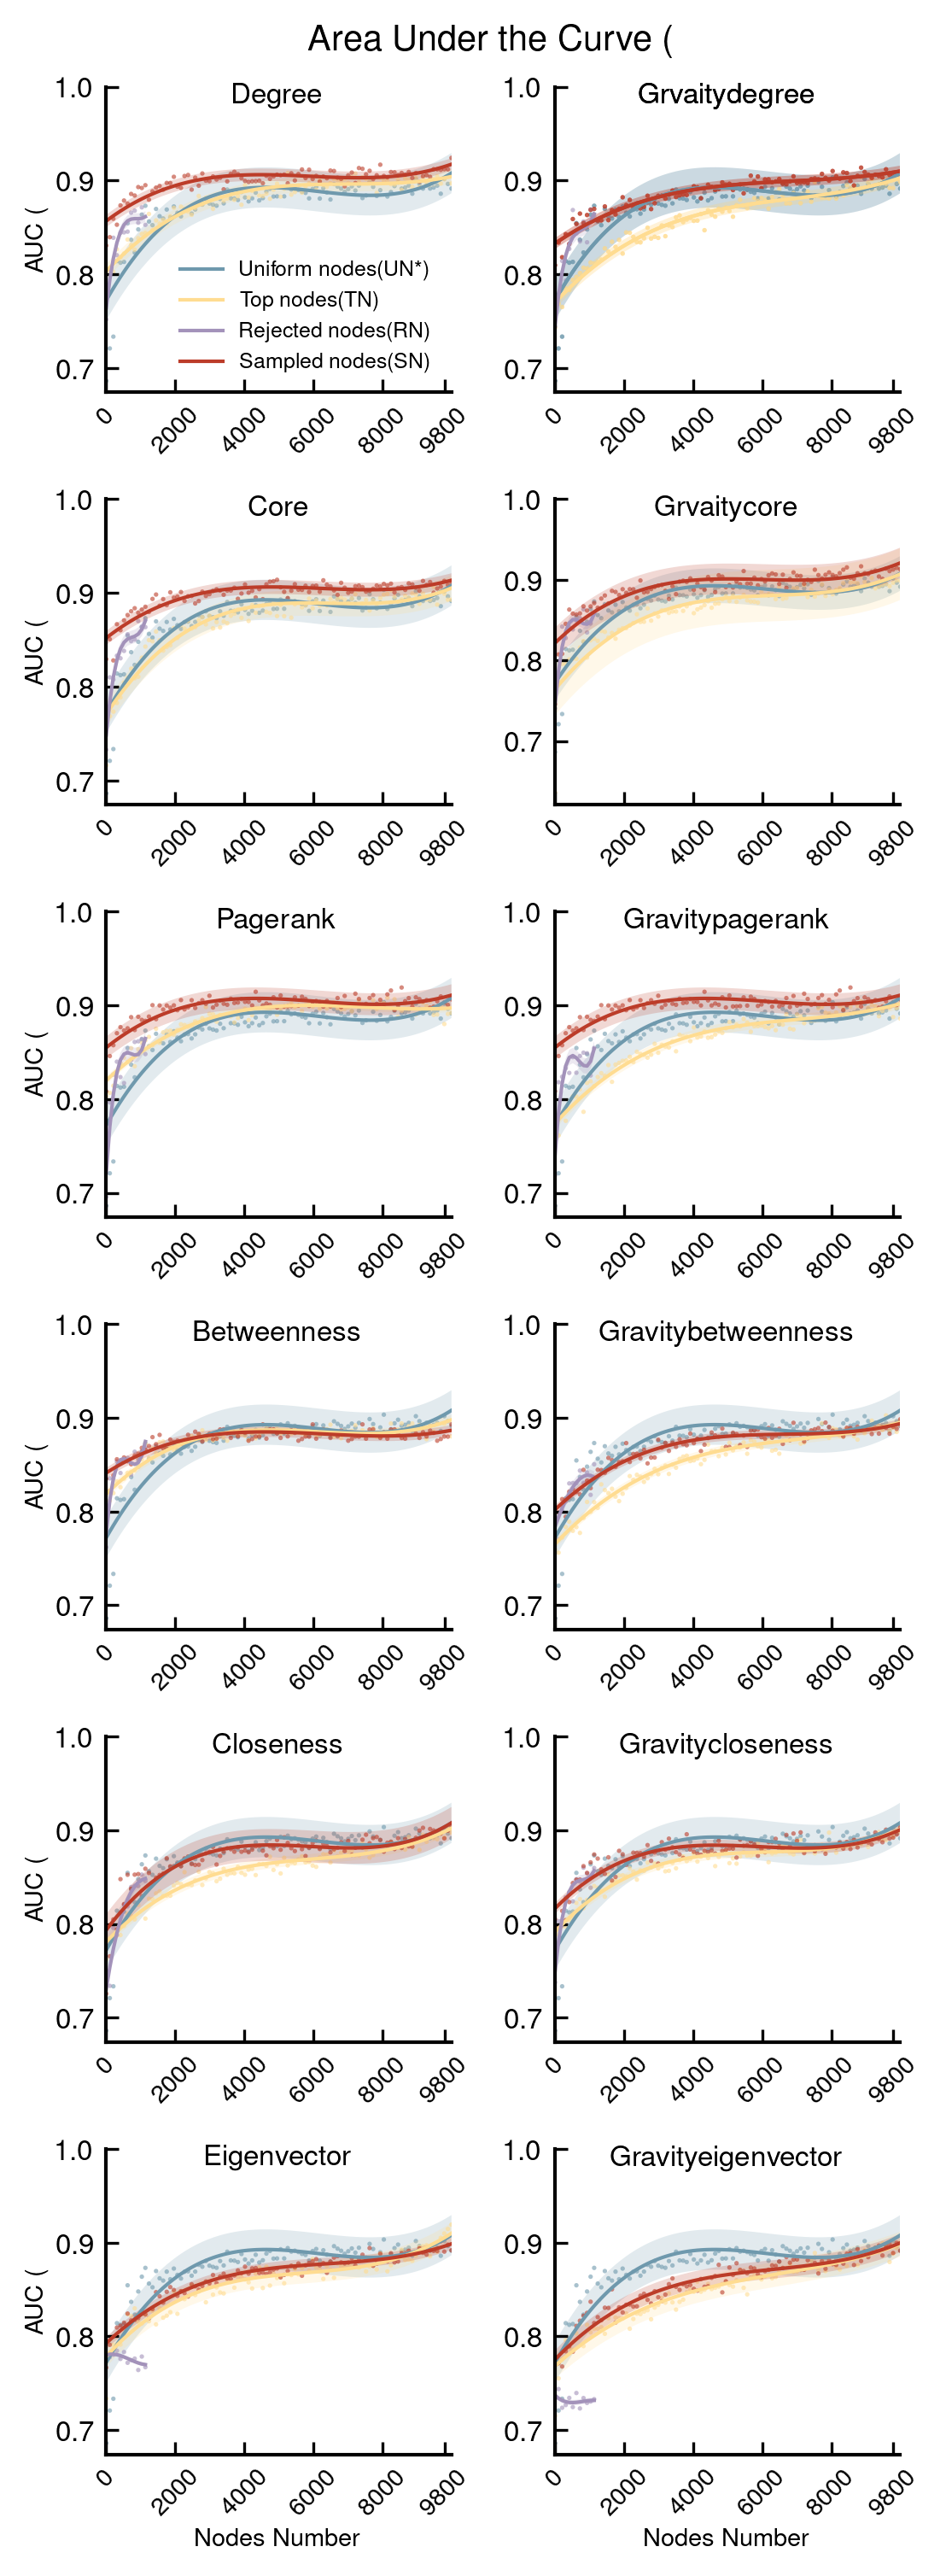

In [5]:

plt.style.use('nature')
from scipy.optimize import curve_fit
from scipy.interpolate import UnivariateSpline


def cubic_fit(x, a, b, c, d):
    return a * x**3 + b * x**2 + c * x + d

x = np.linspace(0,1,98)

fig,axes = plt.subplots(6,2,figsize = (2,6),dpi=600)

params, covariance = curve_fit(cubic_fit, x, cath_uniform[:98,0])
a_fit, b_fit, c_fit, d_fit = params
cath_uniform1 = cubic_fit(x, a_fit, b_fit, c_fit, d_fit)
axes[0,0].plot(x,cath_uniform1,color ='#6F99ADFF', label = 'Uniform nodes(UN*)',linewidth=0.5)
axes[0,0].scatter(x, cath_uniform[:98,0],color ='#6F99ADFF',edgecolors='none', s=0.4, alpha=0.6)
distances = np.abs(cath_uniform[:98, 0] - cath_uniform1)
spline = UnivariateSpline(np.arange(len(distances)), distances.flatten(), s=0)
smooth_distances = spline(np.arange(len(distances)))
smooth_distances_mean = np.mean([np.min(smooth_distances), np.max(smooth_distances)])* 0.5
axes[0,0].fill_between(x, cath_uniform1-smooth_distances_mean, cath_uniform1+smooth_distances_mean, color='#6F99ADFF', alpha=0.2,edgecolors='none')
params, covariance = curve_fit(cubic_fit, x, cath_degree[:98, 2])
a_fit, b_fit, c_fit, d_fit = params
cath_degree_fit = cubic_fit(x, a_fit, b_fit, c_fit, d_fit)
axes[0,0].plot(x, cath_degree_fit, color='#FFDC91FF', label='Top nodes(TN)', linewidth=0.5)
axes[0,0].scatter(x, cath_degree[:98, 2], color ='#FFDC91FF',edgecolors='none', s=0.4, alpha=0.6)
distances = np.abs(cath_degree[:98, 2] - cath_degree_fit)
spline = UnivariateSpline(np.arange(len(distances)), distances.flatten(), s=0)
smooth_distances = spline(np.arange(len(distances)))
smooth_distances_mean = np.mean([np.min(smooth_distances), np.max(smooth_distances)]) * 0.5
axes[0,0].fill_between(x, cath_degree_fit - smooth_distances_mean, cath_degree_fit + smooth_distances_mean, color='#FFDC91FF', alpha=0.2,edgecolors='none')

axes[0,0].tick_params(labelsize=4)

axes[0,0].set_xticks([0,0.12,0.35,0.7,1])
axes[0,0].set_xticklabels(np.array([0, 300,980, 2000, 2700]).astype(int))

axes[0,0].grid (False)
axes[0,0].spines['top'].set_visible(False)
axes[0,0].spines['right'].set_visible(False)
axes[0,0].xaxis.set_ticks_position('bottom')
axes[0,0].yaxis.set_ticks_position('left')
axes[0,0].set_yticks(np.linspace(0.6, 1, 5))
axes[0,0].set_yticks([0.6, 0.7, 0.8, 0.9,1])
axes[0,0].set_xticks([], minor=True)
axes[0,0].set_yticks([], minor=True)
axes[0,0].tick_params(axis='both', which='both', length=1.2)
axes[0,0].text(0.5, 0.97, 'Degree', transform=axes[0,0].transAxes, ha='center', va='center', bbox=dict(facecolor='none', edgecolor='none', boxstyle='round', alpha=0.0), fontsize=4)



params, covariance = curve_fit(cubic_fit, x, cath_uniform[:98,0])
a_fit, b_fit, c_fit, d_fit = params
cath_uniform1 = cubic_fit(x, a_fit, b_fit, c_fit, d_fit)
axes[1,0].plot(x,cath_uniform1,color ='#6F99ADFF', label = 'uniform',linewidth=0.5)
axes[1,0].scatter(x, cath_uniform[:98,0],color ='#6F99ADFF',edgecolors='none', s=0.4, alpha=0.6)
distances = np.abs(cath_uniform[:98, 0] - cath_uniform1)
spline = UnivariateSpline(np.arange(len(distances)), distances.flatten(), s=0)
smooth_distances = spline(np.arange(len(distances)))
smooth_distances_mean = np.mean([np.min(smooth_distances), np.max(smooth_distances)])* 0.5
axes[1,0].fill_between(x, cath_uniform1-smooth_distances_mean, cath_uniform1+smooth_distances_mean, color='#6F99ADFF', alpha=0.2,edgecolors='none')
params, covariance = curve_fit(cubic_fit, x, cath_core[:98, 2])
a_fit, b_fit, c_fit, d_fit = params
cath_core_fit = cubic_fit(x, a_fit, b_fit, c_fit, d_fit)
axes[1,0].plot(x, cath_core_fit, color='#FFDC91FF', label='Top Nodes', linewidth=0.5)
axes[1,0].scatter(x, cath_core[:98, 2], color ='#FFDC91FF',edgecolors='none', s=0.4, alpha=0.6)
distances = np.abs(cath_core[:98, 2] - cath_core_fit)
spline = UnivariateSpline(np.arange(len(distances)), distances.flatten(), s=0)
smooth_distances = spline(np.arange(len(distances)))
smooth_distances_mean = np.mean([np.min(smooth_distances), np.max(smooth_distances)]) * 0.5
axes[1,0].fill_between(x, cath_core_fit - smooth_distances_mean, cath_core_fit + smooth_distances_mean, color='#FFDC91FF', alpha=0.2,edgecolors='none')

axes[1,0].tick_params(labelsize=4)
axes[1,0].set_xticks([0,0.12,0.35,0.7,1])
axes[1,0].set_xticklabels(np.array([0, 300,980, 2000, 2700]).astype(int))
#axes[1,0].legend(fontsize=3,edgecolor='black',framealpha=0.1,loc='center right')
axes[1,0].grid (False)
axes[1,0].spines['top'].set_visible(False)
axes[1,0].spines['right'].set_visible(False)
axes[1,0].xaxis.set_ticks_position('bottom')
axes[1,0].yaxis.set_ticks_position('left')
axes[1,0].set_yticks(np.linspace(0.6, 1, 5))
axes[1,0].set_yticks([0.6, 0.7, 0.8, 0.9,1])
axes[1,0].set_xticks([], minor=True)
axes[1,0].set_yticks([], minor=True)
axes[1,0].tick_params(axis='both', which='both', length=1.2)
axes[1,0].text(0.5, 0.97, 'Core', transform=axes[1,0].transAxes, ha='center', va='center', bbox=dict(facecolor='none', edgecolor='none', boxstyle='round', alpha=0.0), fontsize=4)



params, covariance = curve_fit(cubic_fit, x, cath_uniform[:98,0])
a_fit, b_fit, c_fit, d_fit = params
cath_uniform1 = cubic_fit(x, a_fit, b_fit, c_fit, d_fit)
axes[2,0].plot(x,cath_uniform1,color ='#6F99ADFF', label = 'uniform',linewidth=0.5)
axes[2,0].scatter(x, cath_uniform[:98,0],color ='#6F99ADFF',edgecolors='none', s=0.4, alpha=0.6)
distances = np.abs(cath_uniform[:98, 0] - cath_uniform1)
spline = UnivariateSpline(np.arange(len(distances)), distances.flatten(), s=0)
smooth_distances = spline(np.arange(len(distances)))
smooth_distances_mean = np.mean([np.min(smooth_distances), np.max(smooth_distances)])* 0.5
axes[2,0].fill_between(x, cath_uniform1-smooth_distances_mean, cath_uniform1+smooth_distances_mean, color='#6F99ADFF', alpha=0.2,edgecolors='none')
params, covariance = curve_fit(cubic_fit, x, cath_pagerank[:98, 2])
a_fit, b_fit, c_fit, d_fit = params
cath_pagerank_fit = cubic_fit(x, a_fit, b_fit, c_fit, d_fit)
axes[2,0].plot(x, cath_pagerank_fit, color='#FFDC91FF', label='Top Nodes', linewidth=0.5)
axes[2,0].scatter(x, cath_pagerank[:98, 2], color ='#FFDC91FF',edgecolors='none', s=0.4, alpha=0.6)
distances = np.abs(cath_pagerank[:98, 2] - cath_pagerank_fit)
spline = UnivariateSpline(np.arange(len(distances)), distances.flatten(), s=0)
smooth_distances = spline(np.arange(len(distances)))
smooth_distances_mean = np.mean([np.min(smooth_distances), np.max(smooth_distances)]) * 0.5
axes[2,0].fill_between(x, cath_pagerank_fit - smooth_distances_mean, cath_pagerank_fit + smooth_distances_mean, color='#FFDC91FF', alpha=0.2,edgecolors='none')

axes[2,0].tick_params(labelsize=4)
axes[2,0].set_xticks([0,0.12,0.35,0.7,1])
axes[2,0].set_xticklabels(np.array([0, 300,980, 2000, 2700]).astype(int))
#axes[2,0].legend(fontsize=3,edgecolor='black',framealpha=0.1,loc='center right')
axes[2,0].grid (False)
axes[2,0].spines['top'].set_visible(False)
axes[2,0].spines['right'].set_visible(False)
axes[2,0].xaxis.set_ticks_position('bottom')
axes[2,0].yaxis.set_ticks_position('left')
axes[2,0].set_yticks(np.linspace(0.6, 1, 5))
axes[2,0].set_yticks([0.6, 0.7, 0.8, 0.9,1])
axes[2,0].set_xticks([], minor=True)
axes[2,0].set_yticks([], minor=True)
axes[2,0].tick_params(axis='both', which='both', length=1.2)
axes[2,0].text(0.5, 0.97, 'Pagerank', transform=axes[2,0].transAxes, ha='center', va='center', bbox=dict(facecolor='none', edgecolor='none', boxstyle='round', alpha=0.0), fontsize=4)

params, covariance = curve_fit(cubic_fit, x, cath_uniform[:98,0])
a_fit, b_fit, c_fit, d_fit = params
cath_uniform1 = cubic_fit(x, a_fit, b_fit, c_fit, d_fit)
axes[3,0].plot(x,cath_uniform1,color ='#6F99ADFF', label = 'uniform',linewidth=0.5)
axes[3,0].scatter(x, cath_uniform[:98,0],color ='#6F99ADFF',edgecolors='none', s=0.4, alpha=0.6)
distances = np.abs(cath_uniform[:98, 0] - cath_uniform1)
spline = UnivariateSpline(np.arange(len(distances)), distances.flatten(), s=0)
smooth_distances = spline(np.arange(len(distances)))
smooth_distances_mean = np.mean([np.min(smooth_distances), np.max(smooth_distances)])* 0.5
axes[3,0].fill_between(x, cath_uniform1-smooth_distances_mean, cath_uniform1+smooth_distances_mean, color='#6F99ADFF', alpha=0.2,edgecolors='none')
params, covariance = curve_fit(cubic_fit, x, cath_betweenness[:98, 2])
a_fit, b_fit, c_fit, d_fit = params
cath_betweenness_fit = cubic_fit(x, a_fit, b_fit, c_fit, d_fit)
axes[3,0].plot(x, cath_betweenness_fit, color='#FFDC91FF', label='Top Nodes', linewidth=0.5)
axes[3,0].scatter(x, cath_betweenness[:98, 2], color ='#FFDC91FF',edgecolors='none', s=0.4, alpha=0.6)
distances = np.abs(cath_betweenness[:98, 2] - cath_betweenness_fit)
spline = UnivariateSpline(np.arange(len(distances)), distances.flatten(), s=0)
smooth_distances = spline(np.arange(len(distances)))
smooth_distances_mean = np.mean([np.min(smooth_distances), np.max(smooth_distances)]) * 0.5
axes[3,0].fill_between(x, cath_betweenness_fit - smooth_distances_mean, cath_betweenness_fit + smooth_distances_mean, color='#FFDC91FF', alpha=0.2,edgecolors='none')

axes[3,0].tick_params(labelsize=4)
axes[3,0].set_xticks([0,0.12,0.35,0.7,1])
axes[3,0].set_xticklabels(np.array([0, 300,980, 2000, 2700]).astype(int))
#axes[3,0].legend(fontsize=3,edgecolor='black',framealpha=0.1,loc='center right')
axes[3,0].grid (False)
axes[3,0].spines['top'].set_visible(False)
axes[3,0].spines['right'].set_visible(False)
axes[3,0].xaxis.set_ticks_position('bottom')
axes[3,0].yaxis.set_ticks_position('left')
axes[3,0].set_yticks(np.linspace(0.6, 1, 5))
axes[3,0].set_yticks([0.6, 0.7, 0.8, 0.9,1])
axes[3,0].set_xticks([], minor=True)
axes[3,0].set_yticks([], minor=True)
axes[3,0].tick_params(axis='both', which='both', length=1.2)
axes[3,0].text(0.5, 0.97, 'Betweenness', transform=axes[3,0].transAxes, ha='center', va='center', bbox=dict(facecolor='none', edgecolor='none', boxstyle='round', alpha=0.0), fontsize=4)


params, covariance = curve_fit(cubic_fit, x, cath_uniform[:98,0])
a_fit, b_fit, c_fit, d_fit = params
cath_uniform1 = cubic_fit(x, a_fit, b_fit, c_fit, d_fit)
axes[4,0].plot(x,cath_uniform1,color ='#6F99ADFF', label = 'uniform',linewidth=0.5)
axes[4,0].scatter(x, cath_uniform[:98,0],color ='#6F99ADFF',edgecolors='none', s=0.4, alpha=0.6)
distances = np.abs(cath_uniform[:98, 0] - cath_uniform1)
spline = UnivariateSpline(np.arange(len(distances)), distances.flatten(), s=0)
smooth_distances = spline(np.arange(len(distances)))
smooth_distances_mean = np.mean([np.min(smooth_distances), np.max(smooth_distances)])* 0.5
axes[4,0].fill_between(x, cath_uniform1-smooth_distances_mean, cath_uniform1+smooth_distances_mean, color='#6F99ADFF', alpha=0.2,edgecolors='none')
params, covariance = curve_fit(cubic_fit, x, cath_closeness[:98, 2])
a_fit, b_fit, c_fit, d_fit = params
cath_closeness_fit = cubic_fit(x, a_fit, b_fit, c_fit, d_fit)
axes[4,0].plot(x, cath_closeness_fit, color='#FFDC91FF', label='Top Nodes', linewidth=0.5)
axes[4,0].scatter(x, cath_closeness[:98, 2], color ='#FFDC91FF',edgecolors='none', s=0.4, alpha=0.6)
distances = np.abs(cath_closeness[:98, 2] - cath_closeness_fit)
spline = UnivariateSpline(np.arange(len(distances)), distances.flatten(), s=0)
smooth_distances = spline(np.arange(len(distances)))
smooth_distances_mean = np.mean([np.min(smooth_distances), np.max(smooth_distances)]) * 0.5
axes[4,0].fill_between(x, cath_closeness_fit - smooth_distances_mean, cath_closeness_fit + smooth_distances_mean, color='#FFDC91FF', alpha=0.2,edgecolors='none')

axes[4,0].tick_params(labelsize=4)
axes[4,0].set_xticks([0,0.12,0.35,0.7,1])
axes[4,0].set_xticklabels(np.array([0, 300,980, 2000, 2700]).astype(int))
#axes[4,0].legend(fontsize=3,edgecolor='black',framealpha=0.1,loc='center right')
axes[4,0].grid (False)
axes[4,0].spines['top'].set_visible(False)
axes[4,0].spines['right'].set_visible(False)
axes[4,0].xaxis.set_ticks_position('bottom')
axes[4,0].yaxis.set_ticks_position('left')
axes[4,0].set_yticks(np.linspace(0.6, 1, 5))
axes[4,0].set_yticks([0.6, 0.7, 0.8, 0.9,1])
axes[4,0].set_xticks([], minor=True)
axes[4,0].set_yticks([], minor=True)
axes[4,0].tick_params(axis='both', which='both', length=1.2)
axes[4,0].text(0.5, 0.97, 'Closeness', transform=axes[4,0].transAxes, ha='center', va='center', bbox=dict(facecolor='none', edgecolor='none', boxstyle='round', alpha=0.0), fontsize=4)



params, covariance = curve_fit(cubic_fit, x, cath_uniform[:98,0])
a_fit, b_fit, c_fit, d_fit = params
cath_uniform1 = cubic_fit(x, a_fit, b_fit, c_fit, d_fit)
axes[5,0].plot(x,cath_uniform1,color ='#6F99ADFF', label = 'uniform',linewidth=0.5)
axes[5,0].scatter(x, cath_uniform[:98,0],color ='#6F99ADFF',edgecolors='none', s=0.4, alpha=0.6)
distances = np.abs(cath_uniform[:98, 0] - cath_uniform1)
spline = UnivariateSpline(np.arange(len(distances)), distances.flatten(), s=0)
smooth_distances = spline(np.arange(len(distances)))
smooth_distances_mean = np.mean([np.min(smooth_distances), np.max(smooth_distances)])* 0.5
axes[5,0].fill_between(x, cath_uniform1-smooth_distances_mean, cath_uniform1+smooth_distances_mean, color='#6F99ADFF', alpha=0.2,edgecolors='none')
params, covariance = curve_fit(cubic_fit, x, cath_eigenvector[:98, 2])
a_fit, b_fit, c_fit, d_fit = params
cath_eigenvector_fit = cubic_fit(x, a_fit, b_fit, c_fit, d_fit)
axes[5,0].plot(x, cath_eigenvector_fit, color='#FFDC91FF', label='Top Nodes', linewidth=0.5)
axes[5,0].scatter(x, cath_eigenvector[:98, 2], color ='#FFDC91FF',edgecolors='none', s=0.4, alpha=0.6)
distances = np.abs(cath_eigenvector[:98, 2] - cath_eigenvector_fit)
spline = UnivariateSpline(np.arange(len(distances)), distances.flatten(), s=0)
smooth_distances = spline(np.arange(len(distances)))
smooth_distances_mean = np.mean([np.min(smooth_distances), np.max(smooth_distances)]) * 0.5
axes[5,0].fill_between(x, cath_eigenvector_fit - smooth_distances_mean, cath_eigenvector_fit + smooth_distances_mean, color='#FFDC91FF', alpha=0.2,edgecolors='none')

axes[5,0].tick_params(labelsize=4)
axes[5,0].set_xticks([0,0.12,0.35,0.7,1])
axes[5,0].set_xticklabels(np.array([0, 300,980, 2000, 2700]).astype(int))
#axes[5,0].legend(fontsize=3,edgecolor='black',framealpha=0.1,loc='center right')
axes[5,0].grid (False)
axes[5,0].spines['top'].set_visible(False)
axes[5,0].spines['right'].set_visible(False)
axes[5,0].xaxis.set_ticks_position('bottom')
axes[5,0].yaxis.set_ticks_position('left')
axes[5,0].set_yticks(np.linspace(0.6, 1, 5))
axes[5,0].set_yticks([0.6, 0.7, 0.8, 0.9,1])
axes[5,0].set_xticks([], minor=True)
axes[5,0].set_yticks([], minor=True)
axes[5,0].tick_params(axis='both', which='both', length=1.2)
axes[5,0].text(0.5, 0.97, 'Eigenvector', transform=axes[5,0].transAxes, ha='center', va='center', bbox=dict(facecolor='none', edgecolor='none', boxstyle='round', alpha=0.0), fontsize=4)





params, covariance = curve_fit(cubic_fit, x, cath_uniform[:98,0])
a_fit, b_fit, c_fit, d_fit = params
cath_uniform1 = cubic_fit(x, a_fit, b_fit, c_fit, d_fit)

params, covariance = curve_fit(cubic_fit, x, cath_uniform[:98,0])
a_fit, b_fit, c_fit, d_fit = params
cath_uniform1 = cubic_fit(x, a_fit, b_fit, c_fit, d_fit)
axes[0,1].plot(x,cath_uniform1,color ='#6F99ADFF', label = 'uniform',linewidth=0.5)
axes[0,1].scatter(x, cath_uniform[:98,0],color ='#6F99ADFF',edgecolors='none', s=0.4, alpha=0.6)
distances = np.abs(cath_uniform[:98, 0] - cath_uniform1)
spline = UnivariateSpline(np.arange(len(distances)), distances.flatten(), s=0)
smooth_distances = spline(np.arange(len(distances)))
smooth_distances_mean = np.mean([np.min(smooth_distances), np.max(smooth_distances)])* 0.5
axes[0,1].fill_between(x, cath_uniform1-smooth_distances_mean, cath_uniform1+smooth_distances_mean, color='#6F99ADFF', alpha=0.2,edgecolors='none')
params, covariance = curve_fit(cubic_fit, x, cath_gravitydegree[:98, 2])
a_fit, b_fit, c_fit, d_fit = params
cath_gravitydegree_fit = cubic_fit(x, a_fit, b_fit, c_fit, d_fit)
axes[0,1].plot(x, cath_gravitydegree_fit, color='#FFDC91FF', label='Top Nodes', linewidth=0.5)
axes[0,1].scatter(x, cath_gravitydegree[:98, 2], color ='#FFDC91FF',edgecolors='none', s=0.4, alpha=0.6)
distances = np.abs(cath_gravitydegree[:98, 2] - cath_gravitydegree_fit)
spline = UnivariateSpline(np.arange(len(distances)), distances.flatten(), s=0)
smooth_distances = spline(np.arange(len(distances)))
smooth_distances_mean = np.mean([np.min(smooth_distances), np.max(smooth_distances)]) * 0.5
axes[0,1].fill_between(x, cath_gravitydegree_fit - smooth_distances_mean, cath_gravitydegree_fit + smooth_distances_mean, color='#FFDC91FF', alpha=0.2,edgecolors='none')

axes[0,1].tick_params(labelsize=4)
axes[0,1].set_xticks([0,0.12,0.35,0.7,1])
axes[0,1].set_xticklabels(np.array([0, 300,980, 2000, 2700]).astype(int))
axes[0,1].grid (False)
axes[0,1].spines['top'].set_visible(False)
axes[0,1].spines['right'].set_visible(False)
axes[0,1].xaxis.set_ticks_position('bottom')
axes[0,1].yaxis.set_ticks_position('left')
axes[0,1].set_yticks(np.linspace(0.6, 1, 5))
axes[0,1].set_yticks([0.6, 0.7, 0.8, 0.9,1])
axes[0,1].set_xticks([], minor=True)
axes[0,1].set_yticks([], minor=True)
axes[0,1].tick_params(axis='both', which='both', length=1.2)
axes[0,1].text(0.5, 0.97, 'Grvaitydegree', transform=axes[0,1].transAxes, ha='center', va='center', bbox=dict(facecolor='none', edgecolor='none', boxstyle='round', alpha=0.0), fontsize=4)


axes[0,1].plot(x,cath_uniform1,color ='#6F99ADFF', label = 'uniform',linewidth=0.5)
axes[0,1].scatter(x, cath_uniform[:98,0],color ='#6F99ADFF',edgecolors='none', s=0.4, alpha=0.6)
distances = np.abs(cath_uniform[:98, 0] - cath_uniform1)
spline = UnivariateSpline(np.arange(len(distances)), distances.flatten(), s=0)
smooth_distances = spline(np.arange(len(distances)))
smooth_distances_mean = np.mean([np.min(smooth_distances), np.max(smooth_distances)])* 0.5
axes[0,1].fill_between(x, cath_uniform1-smooth_distances_mean, cath_uniform1+smooth_distances_mean, color='#6F99ADFF', alpha=0.2,edgecolors='none')
params, covariance = curve_fit(cubic_fit, x, cath_gravitydegree[:98, 2])
a_fit, b_fit, c_fit, d_fit = params
cath_gravitydegree_fit = cubic_fit(x, a_fit, b_fit, c_fit, d_fit)
axes[0,1].plot(x, cath_gravitydegree_fit, color='#FFDC91FF', label='Top Nodes', linewidth=0.5)
axes[0,1].scatter(x, cath_gravitydegree[:98, 2], color ='#FFDC91FF',edgecolors='none', s=0.4, alpha=0.6)
distances = np.abs(cath_gravitydegree[:98, 2] - cath_gravitydegree_fit)
spline = UnivariateSpline(np.arange(len(distances)), distances.flatten(), s=0)
smooth_distances = spline(np.arange(len(distances)))
smooth_distances_mean = np.mean([np.min(smooth_distances), np.max(smooth_distances)]) * 0.5
axes[0,1].fill_between(x, cath_gravitydegree_fit - smooth_distances_mean, cath_gravitydegree_fit + smooth_distances_mean, color='#FFDC91FF', alpha=0.2,edgecolors='none')
params, covariance = curve_fit(cubic_fit, x, cath_gravitydegree[:98,0])
a_fit, b_fit, c_fit, d_fit = params
cath_gravitydegree_fit = cubic_fit(x, a_fit, b_fit, c_fit, d_fit)
axes[0,1].plot(x, cath_gravitydegree_fit, color='#BC3C29FF', label='Sampled Nodes', linewidth=0.5)
axes[0,1].scatter(x, cath_gravitydegree[:98, 0], color ='#BC3C29FF',edgecolors='none', s=0.4, alpha=0.6)
distances = np.abs(cath_gravitydegree[:98, 0] - cath_gravitydegree_fit)
spline = UnivariateSpline(np.arange(len(distances)), distances.flatten(), s=0)
smooth_distances = spline(np.arange(len(distances)))
smooth_distances_mean = np.mean([np.min(smooth_distances), np.max(smooth_distances)]) * 0.5
axes[0,1].fill_between(x, cath_gravitydegree_fit - smooth_distances_mean, cath_gravitydegree_fit + smooth_distances_mean, color='#BC3C29FF', alpha=0.2,edgecolors='none')
axes[0,1].tick_params(labelsize=4)
axes[0,1].set_xticks([0,0.12,0.35,0.7,1])
axes[0,1].set_xticklabels(np.array([0, 300,980, 2000, 2700]).astype(int))
#axes[0,1].legend(fontsize=3,edgecolor='black',framealpha=0.1,loc='center right')
axes[0,1].grid (False)
axes[0,1].spines['top'].set_visible(False)
axes[0,1].spines['right'].set_visible(False)
axes[0,1].xaxis.set_ticks_position('bottom')
axes[0,1].yaxis.set_ticks_position('left')
axes[0,1].set_yticks(np.linspace(0.6, 1, 5))
axes[0,1].set_yticks([0.6, 0.7, 0.8, 0.9,1])
axes[0,1].set_xticks([], minor=True)
axes[0,1].set_yticks([], minor=True)
axes[0,1].tick_params(axis='both', which='both', length=1.2)
axes[0,1].text(0.5, 0.97, 'Grvaitydegree', transform=axes[0,1].transAxes, ha='center', va='center', bbox=dict(facecolor='none', edgecolor='none', boxstyle='round', alpha=0.0), fontsize=4)



params, covariance = curve_fit(cubic_fit, x, cath_uniform[:98,0])
a_fit, b_fit, c_fit, d_fit = params
cath_uniform1 = cubic_fit(x, a_fit, b_fit, c_fit, d_fit)
axes[1,1].plot(x,cath_uniform1,color ='#6F99ADFF', label = 'uniform',linewidth=0.5)
axes[1,1].scatter(x, cath_uniform[:98,0],color ='#6F99ADFF',edgecolors='none', s=0.4, alpha=0.6)
distances = np.abs(cath_uniform[:98, 0] - cath_uniform1)
spline = UnivariateSpline(np.arange(len(distances)), distances.flatten(), s=0)
smooth_distances = spline(np.arange(len(distances)))
smooth_distances_mean = np.mean([np.min(smooth_distances), np.max(smooth_distances)])* 0.5
axes[1,1].fill_between(x, cath_uniform1-smooth_distances_mean, cath_uniform1+smooth_distances_mean, color='#6F99ADFF', alpha=0.2,edgecolors='none')
params, covariance = curve_fit(cubic_fit, x, cath_gravitycore[:98, 2])
a_fit, b_fit, c_fit, d_fit = params
cath_gravitycore_fit = cubic_fit(x, a_fit, b_fit, c_fit, d_fit)
axes[1,1].plot(x, cath_gravitycore_fit, color='#FFDC91FF', label='Top Nodes', linewidth=0.5)
axes[1,1].scatter(x, cath_gravitycore[:98, 2], color ='#FFDC91FF',edgecolors='none', s=0.4, alpha=0.6)
distances = np.abs(cath_gravitycore[:98, 2] - cath_gravitycore_fit)
spline = UnivariateSpline(np.arange(len(distances)), distances.flatten(), s=0)
smooth_distances = spline(np.arange(len(distances)))
smooth_distances_mean = np.mean([np.min(smooth_distances), np.max(smooth_distances)]) *0.5
axes[1,1].fill_between(x, cath_gravitycore_fit - smooth_distances_mean, cath_gravitycore_fit + smooth_distances_mean, color='#FFDC91FF', alpha=0.2,edgecolors='none')

axes[1,1].tick_params(labelsize=4)
axes[1,1].set_xticks([0,0.12,0.35,0.7,1])
axes[1,1].set_xticklabels(np.array([0, 300,980, 2000, 2700]).astype(int))
#axes[1,1].legend(fontsize=3,edgecolor='black',framealpha=0.1,loc='center right')
axes[1,1].grid (False)
axes[1,1].spines['top'].set_visible(False)
axes[1,1].spines['right'].set_visible(False)
axes[1,1].xaxis.set_ticks_position('bottom')
axes[1,1].yaxis.set_ticks_position('left')
axes[1,1].set_yticks(np.linspace(0.6, 1, 5))
axes[1,1].set_yticks([0.6, 0.7, 0.8, 0.9,1])
axes[1,1].set_xticks([], minor=True)
axes[1,1].set_yticks([], minor=True)
axes[1,1].tick_params(axis='both', which='both', length=1.2)
axes[1,1].text(0.5, 0.97, 'Grvaitycore', transform=axes[1,1].transAxes, ha='center', va='center', bbox=dict(facecolor='none', edgecolor='none', boxstyle='round', alpha=0.0), fontsize=4)








params, covariance = curve_fit(cubic_fit, x, cath_uniform[:98,0])
a_fit, b_fit, c_fit, d_fit = params
cath_uniform1 = cubic_fit(x, a_fit, b_fit, c_fit, d_fit)
axes[2,1].plot(x,cath_uniform1,color ='#6F99ADFF', label = 'uniform',linewidth=0.5)
axes[2,1].scatter(x, cath_uniform[:98,0],color ='#6F99ADFF',edgecolors='none', s=0.4, alpha=0.6)
distances = np.abs(cath_uniform[:98, 0] - cath_uniform1)
spline = UnivariateSpline(np.arange(len(distances)), distances.flatten(), s=0)
smooth_distances = spline(np.arange(len(distances)))
smooth_distances_mean = np.mean([np.min(smooth_distances), np.max(smooth_distances)])* 0.5
axes[2,1].fill_between(x, cath_uniform1-smooth_distances_mean, cath_uniform1+smooth_distances_mean, color='#6F99ADFF', alpha=0.2,edgecolors='none')
params, covariance = curve_fit(cubic_fit, x, cath_gravitypagerank[:98, 2])
a_fit, b_fit, c_fit, d_fit = params
cath_gravitypagerank_fit = cubic_fit(x, a_fit, b_fit, c_fit, d_fit)
axes[2,1].plot(x, cath_gravitypagerank_fit, color='#FFDC91FF', label='Top Nodes', linewidth=0.5)
axes[2,1].scatter(x, cath_gravitypagerank[:98, 2], color ='#FFDC91FF',edgecolors='none', s=0.4, alpha=0.6)
distances = np.abs(cath_gravitypagerank[:98, 2] - cath_gravitypagerank_fit)
spline = UnivariateSpline(np.arange(len(distances)), distances.flatten(), s=0)
smooth_distances = spline(np.arange(len(distances)))
smooth_distances_mean = np.mean([np.min(smooth_distances), np.max(smooth_distances)]) * 0.5
axes[2,1].fill_between(x, cath_gravitypagerank_fit - smooth_distances_mean, cath_gravitypagerank_fit + smooth_distances_mean, color='#FFDC91FF', alpha=0.2,edgecolors='none')
axes[2,1].tick_params(labelsize=4)
axes[2,1].set_xticks([0,0.12,0.35,0.7,1])
axes[2,1].set_xticklabels(np.array([0, 300,980, 2000, 2700]).astype(int))
#axes[2,1].legend(fontsize=3,edgecolor='black',framealpha=0.1,loc='center right')
axes[2,1].grid (False)
axes[2,1].spines['top'].set_visible(False)
axes[2,1].spines['right'].set_visible(False)
axes[2,1].xaxis.set_ticks_position('bottom')
axes[2,1].yaxis.set_ticks_position('left')
axes[2,1].set_yticks(np.linspace(0.6, 1, 5))
axes[2,1].set_yticks([0.6, 0.7, 0.8, 0.9,1])
axes[2,1].set_xticks([], minor=True)
axes[2,1].set_yticks([], minor=True)
axes[2,1].tick_params(axis='both', which='both', length=1.2)
axes[2,1].text(0.5, 0.97, 'Gravitypagerank', transform=axes[2,1].transAxes, ha='center', va='center', bbox=dict(facecolor='none', edgecolor='none', boxstyle='round', alpha=0.0), fontsize=4)




params, covariance = curve_fit(cubic_fit, x, cath_uniform[:98,0])
a_fit, b_fit, c_fit, d_fit = params
cath_uniform1 = cubic_fit(x, a_fit, b_fit, c_fit, d_fit)
axes[3,1].plot(x,cath_uniform1,color ='#6F99ADFF', label = 'uniform',linewidth=0.5)
axes[3,1].scatter(x, cath_uniform[:98,0],color ='#6F99ADFF',edgecolors='none', s=0.4, alpha=0.6)
distances = np.abs(cath_uniform[:98, 0] - cath_uniform1)
spline = UnivariateSpline(np.arange(len(distances)), distances.flatten(), s=0)
smooth_distances = spline(np.arange(len(distances)))
smooth_distances_mean = np.mean([np.min(smooth_distances), np.max(smooth_distances)])* 0.5
axes[3,1].fill_between(x, cath_uniform1-smooth_distances_mean, cath_uniform1+smooth_distances_mean, color='#6F99ADFF', alpha=0.2,edgecolors='none')
params, covariance = curve_fit(cubic_fit, x, cath_gravitybetweenness[:98, 2])
a_fit, b_fit, c_fit, d_fit = params
cath_gravitybetweenness_fit = cubic_fit(x, a_fit, b_fit, c_fit, d_fit)
axes[3,1].plot(x, cath_gravitybetweenness_fit, color='#FFDC91FF', label='Top Nodes', linewidth=0.5)
axes[3,1].scatter(x, cath_gravitybetweenness[:98, 2], color ='#FFDC91FF',edgecolors='none', s=0.4, alpha=0.6)
distances = np.abs(cath_gravitybetweenness[:98, 2] - cath_gravitybetweenness_fit)
spline = UnivariateSpline(np.arange(len(distances)), distances.flatten(), s=0)
smooth_distances = spline(np.arange(len(distances)))
smooth_distances_mean = np.mean([np.min(smooth_distances), np.max(smooth_distances)]) * 0.5
axes[3,1].fill_between(x, cath_gravitybetweenness_fit - smooth_distances_mean, cath_gravitybetweenness_fit + smooth_distances_mean, color='#FFDC91FF', alpha=0.2,edgecolors='none')
axes[3,1].tick_params(labelsize=4)
axes[3,1].set_xticks([0,0.12,0.35,0.7,1])
axes[3,1].set_xticklabels(np.array([0, 300,980, 2000, 2700]).astype(int))
#axes[3,1].legend(fontsize=3,edgecolor='black',framealpha=0.1,loc='center right')
axes[3,1].grid (False)
axes[3,1].spines['top'].set_visible(False)
axes[3,1].spines['right'].set_visible(False)
axes[3,1].xaxis.set_ticks_position('bottom')
axes[3,1].yaxis.set_ticks_position('left')
axes[3,1].set_yticks(np.linspace(0.6, 1, 5))
axes[3,1].set_yticks([0.6, 0.7, 0.8, 0.9,1])
axes[3,1].set_xticks([], minor=True)
axes[3,1].set_yticks([], minor=True)
axes[3,1].tick_params(axis='both', which='both', length=1.2)
axes[3,1].text(0.5, 0.97, 'Gravitybetweenness', transform=axes[3,1].transAxes, ha='center', va='center', bbox=dict(facecolor='none', edgecolor='none', boxstyle='round', alpha=0.0), fontsize=4)






params, covariance = curve_fit(cubic_fit, x, cath_uniform[:98,0])
a_fit, b_fit, c_fit, d_fit = params
cath_uniform1 = cubic_fit(x, a_fit, b_fit, c_fit, d_fit)
axes[4,1].plot(x,cath_uniform1,color ='#6F99ADFF', label = 'uniform',linewidth=0.5)
axes[4,1].scatter(x, cath_uniform[:98,0],color ='#6F99ADFF',edgecolors='none', s=0.4, alpha=0.6)
distances = np.abs(cath_uniform[:98, 0] - cath_uniform1)
spline = UnivariateSpline(np.arange(len(distances)), distances.flatten(), s=0)
smooth_distances = spline(np.arange(len(distances)))
smooth_distances_mean = np.mean([np.min(smooth_distances), np.max(smooth_distances)])* 0.5
axes[4,1].fill_between(x, cath_uniform1-smooth_distances_mean, cath_uniform1+smooth_distances_mean, color='#6F99ADFF', alpha=0.2,edgecolors='none')
params, covariance = curve_fit(cubic_fit, x, cath_gravitycloseness[:98, 2])
a_fit, b_fit, c_fit, d_fit = params
cath_gravitycloseness_fit = cubic_fit(x, a_fit, b_fit, c_fit, d_fit)
axes[4,1].plot(x, cath_gravitycloseness_fit, color='#FFDC91FF', label='Top Nodes', linewidth=0.5)
axes[4,1].scatter(x, cath_gravitycloseness[:98, 2], color ='#FFDC91FF',edgecolors='none', s=0.4, alpha=0.6)
distances = np.abs(cath_gravitycloseness[:98, 2] - cath_gravitycloseness_fit)
spline = UnivariateSpline(np.arange(len(distances)), distances.flatten(), s=0)
smooth_distances = spline(np.arange(len(distances)))
smooth_distances_mean = np.mean([np.min(smooth_distances), np.max(smooth_distances)]) * 0.5
axes[4,1].fill_between(x, cath_gravitycloseness_fit - smooth_distances_mean, cath_gravitycloseness_fit + smooth_distances_mean, color='#FFDC91FF', alpha=0.2,edgecolors='none')
axes[4,1].tick_params(labelsize=4)
axes[4,1].set_xticks([0,0.12,0.35,0.7,1])
axes[4,1].set_xticklabels(np.array([0, 300,980, 2000, 2700]).astype(int))
#axes[4,1].legend(fontsize=3,edgecolor='black',framealpha=0.1,loc='center right')
axes[4,1].grid (False)
axes[4,1].spines['top'].set_visible(False)
axes[4,1].spines['right'].set_visible(False)
axes[4,1].xaxis.set_ticks_position('bottom')
axes[4,1].yaxis.set_ticks_position('left')
axes[4,1].set_yticks(np.linspace(0.6, 1, 5))
axes[4,1].set_yticks([0.6, 0.7, 0.8, 0.9,1])
axes[4,1].set_xticks([], minor=True)
axes[4,1].set_yticks([], minor=True)
axes[4,1].tick_params(axis='both', which='both', length=1.2)
axes[4,1].text(0.5, 0.97, 'Gravitycloseness', transform=axes[4,1].transAxes, ha='center', va='center', bbox=dict(facecolor='none', edgecolor='none', boxstyle='round', alpha=0.0), fontsize=4)








params, covariance = curve_fit(cubic_fit, x, cath_uniform[:98,0])
a_fit, b_fit, c_fit, d_fit = params
cath_uniform1 = cubic_fit(x, a_fit, b_fit, c_fit, d_fit)
axes[5,1].plot(x,cath_uniform1,color ='#6F99ADFF', label = 'uniform',linewidth=0.5)
axes[5,1].scatter(x, cath_uniform[:98,0],color ='#6F99ADFF',edgecolors='none', s=0.4, alpha=0.6)
distances = np.abs(cath_uniform[:98, 0] - cath_uniform1)
spline = UnivariateSpline(np.arange(len(distances)), distances.flatten(), s=0)
smooth_distances = spline(np.arange(len(distances)))
smooth_distances_mean = np.mean([np.min(smooth_distances), np.max(smooth_distances)])* 0.5
axes[5,1].fill_between(x, cath_uniform1-smooth_distances_mean, cath_uniform1+smooth_distances_mean, color='#6F99ADFF', alpha=0.2,edgecolors='none')
params, covariance = curve_fit(cubic_fit, x, cath_gravityeigenvector[:98, 2])
a_fit, b_fit, c_fit, d_fit = params
cath_gravityeigenvector_fit = cubic_fit(x, a_fit, b_fit, c_fit, d_fit)
axes[5,1].plot(x, cath_gravityeigenvector_fit, color='#FFDC91FF', label='Top Nodes', linewidth=0.5)
axes[5,1].scatter(x, cath_gravityeigenvector[:98, 2], color ='#FFDC91FF',edgecolors='none', s=0.4, alpha=0.6)
distances = np.abs(cath_gravityeigenvector[:98, 2] - cath_gravityeigenvector_fit)
spline = UnivariateSpline(np.arange(len(distances)), distances.flatten(), s=0)
smooth_distances = spline(np.arange(len(distances)))
smooth_distances_mean = np.mean([np.min(smooth_distances), np.max(smooth_distances)]) * 0.5
axes[5,1].fill_between(x, cath_gravityeigenvector_fit - smooth_distances_mean, cath_gravityeigenvector_fit + smooth_distances_mean, color='#FFDC91FF', alpha=0.2,edgecolors='none')
axes[5,1].tick_params(labelsize=4)
axes[5,1].set_xticks([0,0.12,0.35,0.7,1])
axes[5,1].set_xticklabels(np.array([0, 300,980, 2000, 2700]).astype(int))
#axes[5,1].legend(fontsize=3,edgecolor='black',framealpha=0.1,loc='center right')
axes[5,1].grid (False)
axes[5,1].spines['top'].set_visible(False)
axes[5,1].spines['right'].set_visible(False)
axes[5,1].xaxis.set_ticks_position('bottom')
axes[5,1].yaxis.set_ticks_position('left')
axes[5,1].set_yticks(np.linspace(0.6, 1, 5))
axes[5,1].set_yticks([0.6, 0.7, 0.8, 0.9,1])
axes[5,1].set_xticks([], minor=True)
axes[5,1].set_yticks([], minor=True)
axes[5,1].tick_params(axis='both', which='both', length=1.2)
axes[5,1].text(0.5, 0.97, 'Gravityeigenvector', transform=axes[5,1].transAxes, ha='center', va='center', bbox=dict(facecolor='none', edgecolor='none', boxstyle='round', alpha=0.0), fontsize=4)







y = np.linspace(0,1,98)
params, covariance = curve_fit(cubic_fit, x[:12], cath_degree_rn['mean_auc'].values[:12])
a_fit, b_fit, c_fit, d_fit = params
cath_degree_fit = cubic_fit(x[:12], a_fit, b_fit, c_fit, d_fit)
axes[0,0].plot(x[:12], cath_degree_fit, color='#A392BA', label='Rejected nodes(RN)', linewidth=0.5)
axes[0,0].scatter(x[:12], cath_degree_rn['mean_auc'].values[:12], color ='#A392BA',edgecolors='none', s=0.4, alpha=0.6)
distances = np.abs(cath_degree_rn['mean_auc'].values[:12] - cath_degree_fit)
spline = UnivariateSpline(np.arange(len(distances)), distances.flatten(), s=0)
smooth_distances = spline(np.arange(len(distances)))
smooth_distances_mean = np.mean([np.min(smooth_distances), np.max(smooth_distances)]) * 0.5
axes[0,0].fill_between(x[:12], cath_degree_fit - smooth_distances_mean, cath_degree_fit + smooth_distances_mean, color='#A392BA', alpha=0.2,edgecolors='none')

params, covariance = curve_fit(cubic_fit, x[:12], cath_core_rn['mean_auc'].values[:12])
a_fit, b_fit, c_fit, d_fit = params
cath_core_fit = cubic_fit(x[:12], a_fit, b_fit, c_fit, d_fit)
axes[1,0].plot(x[:12], cath_core_fit, color='#A392BA', label='Rejected nodes(RN)', linewidth=0.5)
axes[1,0].scatter(x[:12], cath_core_rn['mean_auc'].values[:12], color ='#A392BA',edgecolors='none', s=0.4, alpha=0.6)
distances = np.abs(cath_core_rn['mean_auc'].values[:12] - cath_core_fit)
spline = UnivariateSpline(np.arange(len(distances)), distances.flatten(), s=0)
smooth_distances = spline(np.arange(len(distances)))
smooth_distances_mean = np.mean([np.min(smooth_distances), np.max(smooth_distances)]) * 0.5
axes[1,0].fill_between(x[:12], cath_core_fit - smooth_distances_mean, cath_core_fit + smooth_distances_mean, color='#A392BA', alpha=0.2,edgecolors='none')



params, covariance = curve_fit(cubic_fit, x[:12], cath_pagerank_rn['mean_auc'].values[:12])
a_fit, b_fit, c_fit, d_fit = params
cath_pagerank_fit = cubic_fit(x[:12], a_fit, b_fit, c_fit, d_fit)
axes[2,0].plot(x[:12], cath_pagerank_fit, color='#A392BA', label='Rejected nodes(RN)', linewidth=0.5)
axes[2,0].scatter(x[:12], cath_pagerank_rn['mean_auc'].values[:12], color ='#A392BA',edgecolors='none', s=0.4, alpha=0.6)
distances = np.abs(cath_pagerank_rn['mean_auc'].values[:12] - cath_pagerank_fit)
spline = UnivariateSpline(np.arange(len(distances)), distances.flatten(), s=0)
smooth_distances = spline(np.arange(len(distances)))
smooth_distances_mean = np.mean([np.min(smooth_distances), np.max(smooth_distances)]) * 0.5
axes[2,0].fill_between(x[:12], cath_pagerank_fit - smooth_distances_mean, cath_pagerank_fit + smooth_distances_mean, color='#A392BA', alpha=0.2,edgecolors='none')





params, covariance = curve_fit(cubic_fit, x[:12], cath_betweenness_rn['mean_auc'].values[:12])
a_fit, b_fit, c_fit, d_fit = params
cath_betweenness_fit = cubic_fit(x[:12], a_fit, b_fit, c_fit, d_fit)
axes[3,0].plot(x[:12], cath_betweenness_fit, color='#A392BA', label='Rejected nodes(RN)', linewidth=0.5)
axes[3,0].scatter(x[:12], cath_betweenness_rn['mean_auc'].values[:12], color ='#A392BA',edgecolors='none', s=0.4, alpha=0.6)
distances = np.abs(cath_betweenness_rn['mean_auc'].values[:12] - cath_betweenness_fit)
spline = UnivariateSpline(np.arange(len(distances)), distances.flatten(), s=0)
smooth_distances = spline(np.arange(len(distances)))
smooth_distances_mean = np.mean([np.min(smooth_distances), np.max(smooth_distances)]) * 0.5



params, covariance = curve_fit(cubic_fit, x[:12], cath_closeness_rn['mean_auc'].values[:12])
a_fit, b_fit, c_fit, d_fit = params
cath_closeness_fit = cubic_fit(x[:12], a_fit, b_fit, c_fit, d_fit)
axes[4,0].plot(x[:12], cath_closeness_fit, color='#A392BA', label='Rejected nodes(RN)', linewidth=0.5)
axes[4,0].scatter(x[:12], cath_closeness_rn['mean_auc'].values[:12], color ='#A392BA',edgecolors='none', s=0.4, alpha=0.6)
distances = np.abs(cath_closeness_rn['mean_auc'].values[:12] - cath_closeness_fit)
spline = UnivariateSpline(np.arange(len(distances)), distances.flatten(), s=0)
smooth_distances = spline(np.arange(len(distances)))
smooth_distances_mean = np.mean([np.min(smooth_distances), np.max(smooth_distances)]) * 0.5
axes[4,0].fill_between(x[:12], cath_closeness_fit - smooth_distances_mean, cath_closeness_fit + smooth_distances_mean, color='#A392BA', alpha=0.2,edgecolors='none')


params, covariance = curve_fit(cubic_fit, x[:12], cath_eigenvector_rn['mean_auc'].values[:12])
a_fit, b_fit, c_fit, d_fit = params
cath_eigenvector_fit = cubic_fit(x[:12], a_fit, b_fit, c_fit, d_fit)
axes[5,0].plot(x[:12], cath_eigenvector_fit, color='#A392BA', label='Rejected nodes(RN)', linewidth=0.5)
axes[5,0].scatter(x[:12], cath_eigenvector_rn['mean_auc'].values[:12], color ='#A392BA',edgecolors='none', s=0.4, alpha=0.6)
distances = np.abs(cath_eigenvector_rn['mean_auc'].values[:12] - cath_eigenvector_fit)
spline = UnivariateSpline(np.arange(len(distances)), distances.flatten(), s=0)
smooth_distances = spline(np.arange(len(distances)))
smooth_distances_mean = np.mean([np.min(smooth_distances), np.max(smooth_distances)]) * 0.5
axes[5,0].fill_between(x[:12], cath_eigenvector_fit - smooth_distances_mean, cath_eigenvector_fit + smooth_distances_mean, color='#A392BA', alpha=0.2,edgecolors='none')



params, covariance = curve_fit(cubic_fit, x[:12], cath_gravitydegree_rn['mean_auc'].values[:12])
a_fit, b_fit, c_fit, d_fit = params
cath_gravitydegree_fit = cubic_fit(x[:12], a_fit, b_fit, c_fit, d_fit)
axes[0,1].plot(x[:12], cath_gravitydegree_fit, color='#A392BA', label='Rejected nodes(RN)', linewidth=0.5)
axes[0,1].scatter(x[:12], cath_gravitydegree_rn['mean_auc'].values[:12], color ='#A392BA',edgecolors='none', s=0.4, alpha=0.6)
distances = np.abs(cath_gravitydegree_rn['mean_auc'].values[:12] - cath_gravitydegree_fit)
spline = UnivariateSpline(np.arange(len(distances)), distances.flatten(), s=0)
smooth_distances = spline(np.arange(len(distances)))
smooth_distances_mean = np.mean([np.min(smooth_distances), np.max(smooth_distances)]) * 0.5
axes[0,1].fill_between(x[:12], cath_gravitydegree_fit - smooth_distances_mean, cath_gravitydegree_fit + smooth_distances_mean, color='#A392BA', alpha=0.2,edgecolors='none')



params, covariance = curve_fit(cubic_fit, x[:12], cath_gravitycore_rn['mean_auc'].values[:12])
a_fit, b_fit, c_fit, d_fit = params
cath_gravitycore_fit = cubic_fit(x[:12], a_fit, b_fit, c_fit, d_fit)
axes[1,1].plot(x[:12], cath_gravitycore_fit, color='#A392BA', label='Rejected nodes(RN)', linewidth=0.5)
axes[1,1].scatter(x[:12], cath_gravitycore_rn['mean_auc'].values[:12], color ='#A392BA',edgecolors='none', s=0.4, alpha=0.6)
distances =  np.abs(cath_gravitycore_rn['mean_auc'].values[:12] - cath_gravitycore_fit)
spline = UnivariateSpline(np.arange(len(distances)), distances.flatten(), s=0)
smooth_distances = spline(np.arange(len(distances)))
smooth_distances_mean = np.mean([np.min(smooth_distances), np.max(smooth_distances)]) * 0.5
axes[1,1].fill_between(x[:12], cath_gravitycore_fit - smooth_distances_mean, cath_gravitycore_fit + smooth_distances_mean, color='#A392BA', alpha=0.2,edgecolors='none')




params, covariance = curve_fit(cubic_fit, x[:12], cath_gravitypagerank_rn['mean_auc'].values[:12])
a_fit, b_fit, c_fit, d_fit = params
cath_gravitypagerank_fit = cubic_fit(x[:12], a_fit, b_fit, c_fit, d_fit)
axes[2,1].plot(x[:12], cath_gravitypagerank_fit, color='#A392BA', label='Rejected nodes(RN)', linewidth=0.5)
axes[2,1].scatter(x[:12], cath_gravitypagerank_rn['mean_auc'].values[:12], color ='#A392BA',edgecolors='none', s=0.4, alpha=0.6)
distances = np.abs(cath_gravitypagerank_rn['mean_auc'].values[:12] - cath_gravitypagerank_fit)
spline = UnivariateSpline(np.arange(len(distances)), distances.flatten(), s=0)
smooth_distances = spline(np.arange(len(distances)))
smooth_distances_mean = np.mean([np.min(smooth_distances), np.max(smooth_distances)]) * 0.5
axes[2,1].fill_between(x[:12], cath_gravitypagerank_fit - smooth_distances_mean, cath_gravitypagerank_fit + smooth_distances_mean, color='#A392BA', alpha=0.2,edgecolors='none')


params, covariance = curve_fit(cubic_fit, x[:12], cath_gravitybetweenness_rn['mean_auc'].values[:12])
a_fit, b_fit, c_fit, d_fit = params
cath_gravitybetweenness_fit = cubic_fit(x[:12], a_fit, b_fit, c_fit, d_fit)
axes[3,1].plot(x[:12], cath_gravitybetweenness_fit, color='#A392BA', label='Rejected nodes(RN)', linewidth=0.5)
axes[3,1].scatter(x[:12], cath_gravitybetweenness_rn['mean_auc'].values[:12], color ='#A392BA',edgecolors='none', s=0.4, alpha=0.6)
distances = np.abs(cath_gravitybetweenness_rn['mean_auc'].values[:12] - cath_gravitybetweenness_fit)
spline = UnivariateSpline(np.arange(len(distances)), distances.flatten(), s=0)
smooth_distances = spline(np.arange(len(distances)))
smooth_distances_mean = np.mean([np.min(smooth_distances), np.max(smooth_distances)]) * 0.5
axes[3,1].fill_between(x[:12], cath_gravitybetweenness_fit - smooth_distances_mean, cath_gravitybetweenness_fit + smooth_distances_mean, color='#A392BA', alpha=0.2,edgecolors='none')



params, covariance = curve_fit(cubic_fit, x[:12], cath_gravitycloseness_rn['mean_auc'].values[:12])
a_fit, b_fit, c_fit, d_fit = params
cath_gravitycloseness_fit = cubic_fit(x[:12], a_fit, b_fit, c_fit, d_fit)
axes[4,1].plot(x[:12], cath_gravitycloseness_fit, color='#A392BA', label='Rejected nodes(RN)', linewidth=0.5)
axes[4,1].scatter(x[:12], cath_gravitycloseness_rn['mean_auc'].values[:12], color ='#A392BA',edgecolors='none', s=0.4, alpha=0.6)
distances =  np.abs(cath_gravitycloseness_rn['mean_auc'].values[:12] - cath_gravitycloseness_fit)
spline = UnivariateSpline(np.arange(len(distances)), distances.flatten(), s=0)
smooth_distances = spline(np.arange(len(distances)))
smooth_distances_mean = np.mean([np.min(smooth_distances), np.max(smooth_distances)]) * 0.5
axes[4,1].fill_between(x[:12], cath_gravitycloseness_fit - smooth_distances_mean, cath_gravitycloseness_fit + smooth_distances_mean, color='#A392BA', alpha=0.2,edgecolors='none')


params, covariance = curve_fit(cubic_fit, x[:12], cath_gravityeigenvector_rn['mean_auc'].values[:12])
a_fit, b_fit, c_fit, d_fit = params
cath_gravityeigenvector_fit = cubic_fit(x[:12], a_fit, b_fit, c_fit, d_fit)
axes[5,1].plot(x[:12], cath_gravityeigenvector_fit, color='#A392BA', label='Rejected nodes(RN)', linewidth=0.5)
axes[5,1].scatter(x[:12], cath_gravityeigenvector_rn['mean_auc'].values[:12], color ='#A392BA',edgecolors='none', s=0.4, alpha=0.6)
distances = np.abs(cath_gravityeigenvector_rn['mean_auc'].values[:12] - cath_gravityeigenvector_fit)
spline = UnivariateSpline(np.arange(len(distances)), distances.flatten(), s=0)
smooth_distances = spline(np.arange(len(distances)))
smooth_distances_mean = np.mean([np.min(smooth_distances), np.max(smooth_distances)]) * 0.5
axes[5,1].fill_between(x[:12], cath_gravityeigenvector_fit - smooth_distances_mean, cath_gravityeigenvector_fit + smooth_distances_mean, color='#A392BA', alpha=0.2,edgecolors='none')


params, covariance = curve_fit(cubic_fit, x, cath_degree[:98,0])
a_fit, b_fit, c_fit, d_fit = params
cath_degree_fit = cubic_fit(x, a_fit, b_fit, c_fit, d_fit)
axes[0,0].plot(x, cath_degree_fit, color='#BC3C29FF', label='Sampled nodes(SN)', linewidth=0.5)
axes[0,0].scatter(x, cath_degree[:98, 0], color ='#BC3C29FF',edgecolors='none', s=0.4, alpha=0.6)
distances = np.abs(cath_degree[:98, 0] - cath_degree_fit)
spline = UnivariateSpline(np.arange(len(distances)), distances.flatten(), s=0)
smooth_distances = spline(np.arange(len(distances)))
smooth_distances_mean = np.mean([np.min(smooth_distances), np.max(smooth_distances)]) * 0.5
axes[0,0].fill_between(x, cath_degree_fit - smooth_distances_mean, cath_degree_fit + smooth_distances_mean, color='#BC3C29FF', alpha=0.2,edgecolors='none')

params, covariance = curve_fit(cubic_fit, x, cath_core[:98,0])
a_fit, b_fit, c_fit, d_fit = params
cath_core_fit = cubic_fit(x, a_fit, b_fit, c_fit, d_fit)
axes[1,0].plot(x, cath_core_fit, color='#BC3C29FF', label='Sampled Nodes', linewidth=0.5)
axes[1,0].scatter(x, cath_core[:98, 0], color ='#BC3C29FF',edgecolors='none', s=0.4, alpha=0.6)
distances = np.abs(cath_core[:98, 0] - cath_core_fit)
spline = UnivariateSpline(np.arange(len(distances)), distances.flatten(), s=0)
smooth_distances = spline(np.arange(len(distances)))
smooth_distances_mean = np.mean([np.min(smooth_distances), np.max(smooth_distances)]) * 0.5
axes[1,0].fill_between(x, cath_core_fit - smooth_distances_mean, cath_core_fit + smooth_distances_mean, color='#BC3C29FF', alpha=0.2,edgecolors='none')

params, covariance = curve_fit(cubic_fit, x, cath_pagerank[:98,0])
a_fit, b_fit, c_fit, d_fit = params
cath_pagerank_fit = cubic_fit(x, a_fit, b_fit, c_fit, d_fit)
axes[2,0].plot(x, cath_pagerank_fit, color='#BC3C29FF', label='Sampled Nodes', linewidth=0.5)
axes[2,0].scatter(x, cath_pagerank[:98, 0], color ='#BC3C29FF',edgecolors='none', s=0.4, alpha=0.6)
distances = np.abs(cath_pagerank[:98, 0] - cath_pagerank_fit)
spline = UnivariateSpline(np.arange(len(distances)), distances.flatten(), s=0)
smooth_distances = spline(np.arange(len(distances)))
smooth_distances_mean = np.mean([np.min(smooth_distances), np.max(smooth_distances)]) * 0.5
axes[2,0].fill_between(x, cath_pagerank_fit - smooth_distances_mean, cath_pagerank_fit + smooth_distances_mean, color='#BC3C29FF', alpha=0.2,edgecolors='none')

params, covariance = curve_fit(cubic_fit, x, cath_betweenness[:98,0])
a_fit, b_fit, c_fit, d_fit = params
cath_betweenness_fit = cubic_fit(x, a_fit, b_fit, c_fit, d_fit)
axes[3,0].plot(x, cath_betweenness_fit, color='#BC3C29FF', label='Sampled Nodes', linewidth=0.5)
axes[3,0].scatter(x, cath_betweenness[:98, 0], color ='#BC3C29FF',edgecolors='none', s=0.4, alpha=0.6)
distances = np.abs(cath_betweenness[:98, 0] - cath_betweenness_fit)
spline = UnivariateSpline(np.arange(len(distances)), distances.flatten(), s=0)
smooth_distances = spline(np.arange(len(distances)))
smooth_distances_mean = np.mean([np.min(smooth_distances), np.max(smooth_distances)]) * 0.5
axes[3,0].fill_between(x, cath_betweenness_fit - smooth_distances_mean, cath_betweenness_fit + smooth_distances_mean, color='#BC3C29FF', alpha=0.2,edgecolors='none')


params, covariance = curve_fit(cubic_fit, x, cath_closeness[:98,0])
a_fit, b_fit, c_fit, d_fit = params
cath_closeness_fit = cubic_fit(x, a_fit, b_fit, c_fit, d_fit)
axes[4,0].plot(x, cath_closeness_fit, color='#BC3C29FF', label='Sampled Nodes', linewidth=0.5)
axes[4,0].scatter(x, cath_closeness[:98, 0], color ='#BC3C29FF',edgecolors='none', s=0.4, alpha=0.6)
distances = np.abs(cath_closeness[:98, 0] - cath_closeness_fit)
spline = UnivariateSpline(np.arange(len(distances)), distances.flatten(), s=0)
smooth_distances = spline(np.arange(len(distances)))
smooth_distances_mean = np.mean([np.min(smooth_distances), np.max(smooth_distances)]) * 0.5
axes[4,0].fill_between(x, cath_closeness_fit - smooth_distances_mean, cath_closeness_fit + smooth_distances_mean, color='#BC3C29FF', alpha=0.2,edgecolors='none')

params, covariance = curve_fit(cubic_fit, x, cath_eigenvector[:98,0])
a_fit, b_fit, c_fit, d_fit = params
cath_eigenvector_fit = cubic_fit(x, a_fit, b_fit, c_fit, d_fit)
axes[5,0].plot(x, cath_eigenvector_fit, color='#BC3C29FF', label='Sampled Nodes', linewidth=0.5)
axes[5,0].scatter(x, cath_eigenvector[:98, 0], color ='#BC3C29FF',edgecolors='none', s=0.4, alpha=0.6)
distances = np.abs(cath_eigenvector[:98, 0] - cath_eigenvector_fit)
spline = UnivariateSpline(np.arange(len(distances)), distances.flatten(), s=0)
smooth_distances = spline(np.arange(len(distances)))
smooth_distances_mean = np.mean([np.min(smooth_distances), np.max(smooth_distances)]) * 0.5
axes[5,0].fill_between(x, cath_eigenvector_fit - smooth_distances_mean, cath_eigenvector_fit + smooth_distances_mean, color='#BC3C29FF', alpha=0.2,edgecolors='none')


params, covariance = curve_fit(cubic_fit, x, cath_gravitydegree[:98,0])
a_fit, b_fit, c_fit, d_fit = params
cath_gravitydegree_fit = cubic_fit(x, a_fit, b_fit, c_fit, d_fit)
axes[0,1].plot(x, cath_gravitydegree_fit, color='#BC3C29FF', label='Sampled Nodes', linewidth=0.5)
axes[0,1].scatter(x, cath_gravitydegree[:98, 0], color ='#BC3C29FF',edgecolors='none', s=0.4, alpha=0.6)
distances = np.abs(cath_gravitydegree[:98, 0] - cath_gravitydegree_fit)
spline = UnivariateSpline(np.arange(len(distances)), distances.flatten(), s=0)
smooth_distances = spline(np.arange(len(distances)))
smooth_distances_mean = np.mean([np.min(smooth_distances), np.max(smooth_distances)]) * 0.5
axes[0,1].fill_between(x, cath_gravitydegree_fit - smooth_distances_mean, cath_gravitydegree_fit + smooth_distances_mean, color='#BC3C29FF', alpha=0.2,edgecolors='none')

params, covariance = curve_fit(cubic_fit, x, cath_gravitycore[:98,0])
a_fit, b_fit, c_fit, d_fit = params
cath_gravitycore_fit = cubic_fit(x, a_fit, b_fit, c_fit, d_fit)
axes[1,1].plot(x, cath_gravitycore_fit, color='#BC3C29FF', label='Sampled Nodes', linewidth=0.5)
axes[1,1].scatter(x, cath_gravitycore[:98, 0], color ='#BC3C29FF',edgecolors='none', s=0.4, alpha=0.6)
distances = np.abs(cath_gravitycore[:98, 0] - cath_gravitycore_fit)
spline = UnivariateSpline(np.arange(len(distances)), distances.flatten(), s=0)
smooth_distances = spline(np.arange(len(distances)))
smooth_distances_mean = np.mean([np.min(smooth_distances), np.max(smooth_distances)]) * 0.5
axes[1,1].fill_between(x, cath_gravitycore_fit - smooth_distances_mean, cath_gravitycore_fit + smooth_distances_mean, color='#BC3C29FF', alpha=0.2,edgecolors='none')

params, covariance = curve_fit(cubic_fit, x, cath_gravitypagerank[:98,0])
a_fit, b_fit, c_fit, d_fit = params
cath_gravitypagerank_fit = cubic_fit(x, a_fit, b_fit, c_fit, d_fit)
axes[2,1].plot(x, cath_gravitypagerank_fit, color='#BC3C29FF', label='Sampled Nodes', linewidth=0.5)
axes[2,1].scatter(x, cath_gravitypagerank[:98, 0], color ='#BC3C29FF',edgecolors='none', s=0.4, alpha=0.6)
distances = np.abs(cath_gravitypagerank[:98, 0] - cath_gravitypagerank_fit)
spline = UnivariateSpline(np.arange(len(distances)), distances.flatten(), s=0)
smooth_distances = spline(np.arange(len(distances)))
smooth_distances_mean = np.mean([np.min(smooth_distances), np.max(smooth_distances)]) * 0.5
axes[2,1].fill_between(x, cath_gravitypagerank_fit - smooth_distances_mean, cath_gravitypagerank_fit + smooth_distances_mean, color='#BC3C29FF', alpha=0.2,edgecolors='none')

params, covariance = curve_fit(cubic_fit, x, cath_gravitybetweenness[:98,0])
a_fit, b_fit, c_fit, d_fit = params
cath_gravitybetweenness_fit = cubic_fit(x, a_fit, b_fit, c_fit, d_fit)
axes[3,1].plot(x, cath_gravitybetweenness_fit, color='#BC3C29FF', label='Sampled Nodes', linewidth=0.5)
axes[3,1].scatter(x, cath_gravitybetweenness[:98, 0], color ='#BC3C29FF',edgecolors='none', s=0.4, alpha=0.6)
distances = np.abs(cath_gravitybetweenness[:98, 0] - cath_gravitybetweenness_fit)
spline = UnivariateSpline(np.arange(len(distances)), distances.flatten(), s=0)
smooth_distances = spline(np.arange(len(distances)))
smooth_distances_mean = np.mean([np.min(smooth_distances), np.max(smooth_distances)]) * 0.5
axes[3,1].fill_between(x, cath_gravitybetweenness_fit - smooth_distances_mean, cath_gravitybetweenness_fit + smooth_distances_mean, color='#BC3C29FF', alpha=0.2,edgecolors='none')


params, covariance = curve_fit(cubic_fit, x, cath_gravitycloseness[:98,0])
a_fit, b_fit, c_fit, d_fit = params
cath_gravitycloseness_fit = cubic_fit(x, a_fit, b_fit, c_fit, d_fit)
axes[4,1].plot(x, cath_gravitycloseness_fit, color='#BC3C29FF', label='Sampled Nodes', linewidth=0.5)
axes[4,1].scatter(x, cath_gravitycloseness[:98, 0], color ='#BC3C29FF',edgecolors='none', s=0.4, alpha=0.6)
distances = np.abs(cath_gravitycloseness[:98, 0] - cath_gravitycloseness_fit)
spline = UnivariateSpline(np.arange(len(distances)), distances.flatten(), s=0)
smooth_distances = spline(np.arange(len(distances)))
smooth_distances_mean = np.mean([np.min(smooth_distances), np.max(smooth_distances)]) * 0.5
axes[4,1].fill_between(x, cath_gravitycloseness_fit - smooth_distances_mean, cath_gravitycloseness_fit + smooth_distances_mean, color='#BC3C29FF', alpha=0.2,edgecolors='none')

params, covariance = curve_fit(cubic_fit, x, cath_gravityeigenvector[:98,0])
a_fit, b_fit, c_fit, d_fit = params
cath_gravityeigenvector_fit = cubic_fit(x, a_fit, b_fit, c_fit, d_fit)
axes[5,1].plot(x, cath_gravityeigenvector_fit, color='#BC3C29FF', label='Sampled Nodes', linewidth=0.5)
axes[5,1].scatter(x, cath_gravityeigenvector[:98, 0], color ='#BC3C29FF',edgecolors='none', s=0.4, alpha=0.6)
distances = np.abs(cath_gravityeigenvector[:98, 0] - cath_gravityeigenvector_fit)
spline = UnivariateSpline(np.arange(len(distances)), distances.flatten(), s=0)
smooth_distances = spline(np.arange(len(distances)))
smooth_distances_mean = np.mean([np.min(smooth_distances), np.max(smooth_distances)]) * 0.5
axes[5,1].fill_between(x, cath_gravityeigenvector_fit - smooth_distances_mean, cath_gravityeigenvector_fit + smooth_distances_mean, color='#BC3C29FF', alpha=0.2,edgecolors='none')


axes[0,0].legend(fontsize=3,edgecolor='black',framealpha=0.1,loc='best',frameon=False)

plt.subplots_adjust(wspace=0.3,hspace=0.3)

for i in range(6):
    axes[i,0].set_ylabel('AUC (%)',fontsize=3.5,labelpad=1)
    if i==5:
        axes[i,0].set_xlabel('Nodes Number',fontsize=3.5,labelpad=1)
        axes[i,1].set_xlabel('Nodes Number',fontsize=3.5,labelpad=1)

for ax in axes.flat:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.xaxis.set_ticks_position('bottom')
    ax.yaxis.set_ticks_position('left')
    ax.tick_params(axis='both', which='both', length=1.8,pad=1.5,width=0.4)
    ax.set_xlim([0,1])
    ax.set_xticks([0,0.2,0.4,0.6,0.8,0.98])
    ax.set_xticklabels(np.array([0, 2000,4000,6000,8000,9800]).astype(int))
    ax.set_yticks(np.linspace(0.7, 1, 4))
    ax.set_yticks([ 0.7, 0.8, 0.9,1])
    ax.tick_params(axis='x', rotation=45,labelsize=3.5)


plt.subplots_adjust(wspace=0.3,hspace=0.35)


fig.suptitle('Area Under the Curve (%) on CA-HepTh',fontsize=5, y=0.90)
fig.savefig('C:/Users/WENJIA/Downloads/papers/results/cath_auc.png',dpi=350)
fig.savefig('C:/Users/WENJIA/Downloads/papers/results/cath_auc.pdf',dpi=350)

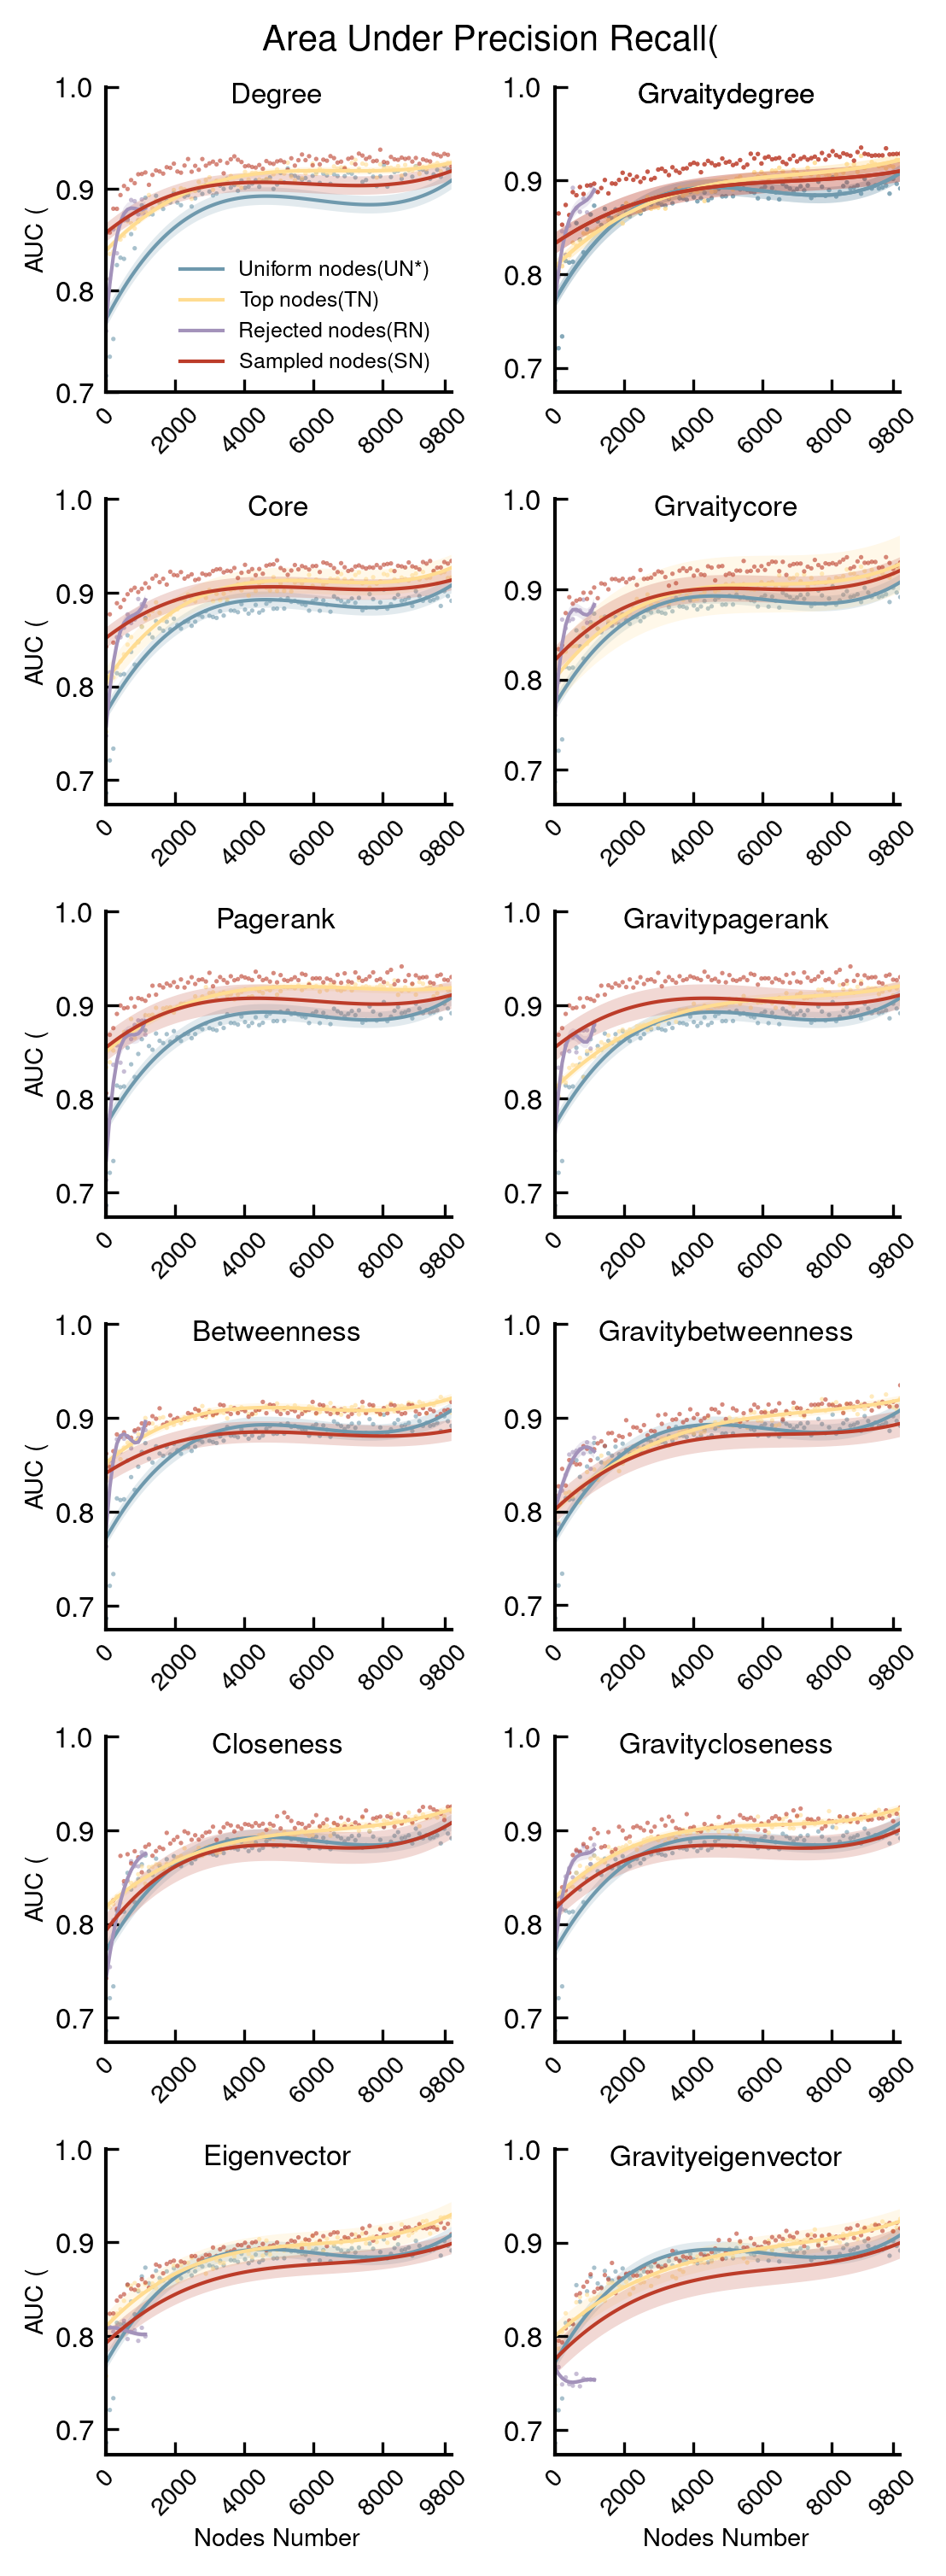

In [6]:

plt.style.use('nature')
from scipy.optimize import curve_fit
from scipy.interpolate import UnivariateSpline


def cubic_fit(x, a, b, c, d):
    return a * x**3 + b * x**2 + c * x + d

x = np.linspace(0,1,98)

fig,axes = plt.subplots(6,2,figsize = (2,6),dpi=600)

params, covariance = curve_fit(cubic_fit, x, cath_uniform[:98,0])
a_fit, b_fit, c_fit, d_fit = params
cath_uniform1 = cubic_fit(x, a_fit, b_fit, c_fit, d_fit)
axes[0,0].plot(x,cath_uniform1,color ='#6F99ADFF', label = 'Uniform nodes(UN*)',linewidth=0.5)
axes[0,0].scatter(x, cath_uniform[:98,1],color ='#6F99ADFF',edgecolors='none', s=0.4, alpha=0.6)
distances = np.abs(cath_uniform[:98, 1] - cath_uniform1)
spline = UnivariateSpline(np.arange(len(distances)), distances.flatten(), s=0)
smooth_distances = spline(np.arange(len(distances)))
smooth_distances_mean = np.mean([np.min(smooth_distances), np.max(smooth_distances)])* 1 /4
axes[0,0].fill_between(x, cath_uniform1-smooth_distances_mean, cath_uniform1+smooth_distances_mean, color='#6F99ADFF', alpha=0.2,edgecolors='none')
params, covariance = curve_fit(cubic_fit, x, cath_degree[:98, 3])
a_fit, b_fit, c_fit, d_fit = params
cath_degree_fit = cubic_fit(x, a_fit, b_fit, c_fit, d_fit)
axes[0,0].plot(x, cath_degree_fit, color='#FFDC91FF', label='Top nodes(TN)', linewidth=0.5)
axes[0,0].scatter(x, cath_degree[:98, 3], color ='#FFDC91FF',edgecolors='none', s=0.4, alpha=0.6)
distances = np.abs(cath_degree[:98, 3] - cath_degree_fit)
spline = UnivariateSpline(np.arange(len(distances)), distances.flatten(), s=0)
smooth_distances = spline(np.arange(len(distances)))
smooth_distances_mean = np.mean([np.min(smooth_distances), np.max(smooth_distances)]) * 1 / 4
axes[0,0].fill_between(x, cath_degree_fit - smooth_distances_mean, cath_degree_fit + smooth_distances_mean, color='#FFDC91FF', alpha=0.2,edgecolors='none')

axes[0,0].tick_params(labelsize=4)

axes[0,0].set_xticks([0,0.12,0.35,0.7,1])
axes[0,0].set_xticklabels(np.array([0, 300,980, 2000, 2700]).astype(int))

axes[0,0].grid (False)
axes[0,0].spines['top'].set_visible(False)
axes[0,0].spines['right'].set_visible(False)
axes[0,0].xaxis.set_ticks_position('bottom')
axes[0,0].yaxis.set_ticks_position('left')
axes[0,0].set_yticks(np.linspace(0.6, 1, 5))
axes[0,0].set_yticks([0.6, 0.7, 0.8, 0.9,1])
axes[0,0].set_xticks([], minor=True)
axes[0,0].set_yticks([], minor=True)
axes[0,0].tick_params(axis='both', which='both', length=1.2)
axes[0,0].text(0.5, 0.97, 'Degree', transform=axes[0,0].transAxes, ha='center', va='center', bbox=dict(facecolor='none', edgecolor='none', boxstyle='round', alpha=0.0), fontsize=4)



params, covariance = curve_fit(cubic_fit, x, cath_uniform[:98,0])
a_fit, b_fit, c_fit, d_fit = params
cath_uniform1 = cubic_fit(x, a_fit, b_fit, c_fit, d_fit)
axes[1,0].plot(x,cath_uniform1,color ='#6F99ADFF', label = 'uniform',linewidth=0.5)
axes[1,0].scatter(x, cath_uniform[:98,0],color ='#6F99ADFF',edgecolors='none', s=0.4, alpha=0.6)
distances = np.abs(cath_uniform[:98, 1] - cath_uniform1)
spline = UnivariateSpline(np.arange(len(distances)), distances.flatten(), s=0)
smooth_distances = spline(np.arange(len(distances)))
smooth_distances_mean = np.mean([np.min(smooth_distances), np.max(smooth_distances)])* 1 /4
axes[1,0].fill_between(x, cath_uniform1-smooth_distances_mean, cath_uniform1+smooth_distances_mean, color='#6F99ADFF', alpha=0.2,edgecolors='none')
params, covariance = curve_fit(cubic_fit, x, cath_core[:98, 3])
a_fit, b_fit, c_fit, d_fit = params
cath_core_fit = cubic_fit(x, a_fit, b_fit, c_fit, d_fit)
axes[1,0].plot(x, cath_core_fit, color='#FFDC91FF', label='Top Nodes', linewidth=0.5)
axes[1,0].scatter(x, cath_core[:98, 3], color ='#FFDC91FF',edgecolors='none', s=0.4, alpha=0.6)
distances = np.abs(cath_core[:98, 3] - cath_core_fit)
spline = UnivariateSpline(np.arange(len(distances)), distances.flatten(), s=0)
smooth_distances = spline(np.arange(len(distances)))
smooth_distances_mean = np.mean([np.min(smooth_distances), np.max(smooth_distances)]) * 0.5
axes[1,0].fill_between(x, cath_core_fit - smooth_distances_mean, cath_core_fit + smooth_distances_mean, color='#FFDC91FF', alpha=0.2,edgecolors='none')

axes[1,0].tick_params(labelsize=4)
axes[1,0].set_xticks([0,0.12,0.35,0.7,1])
axes[1,0].set_xticklabels(np.array([0, 300,980, 2000, 2700]).astype(int))
#axes[1,0].legend(fontsize=3,edgecolor='black',framealpha=0.1,loc='center right')
axes[1,0].grid (False)
axes[1,0].spines['top'].set_visible(False)
axes[1,0].spines['right'].set_visible(False)
axes[1,0].xaxis.set_ticks_position('bottom')
axes[1,0].yaxis.set_ticks_position('left')
axes[1,0].set_yticks(np.linspace(0.6, 1, 5))
axes[1,0].set_yticks([0.6, 0.7, 0.8, 0.9,1])
axes[1,0].set_xticks([], minor=True)
axes[1,0].set_yticks([], minor=True)
axes[1,0].tick_params(axis='both', which='both', length=1.2)
axes[1,0].text(0.5, 0.97, 'Core', transform=axes[1,0].transAxes, ha='center', va='center', bbox=dict(facecolor='none', edgecolor='none', boxstyle='round', alpha=0.0), fontsize=4)



params, covariance = curve_fit(cubic_fit, x, cath_uniform[:98,0])
a_fit, b_fit, c_fit, d_fit = params
cath_uniform1 = cubic_fit(x, a_fit, b_fit, c_fit, d_fit)
axes[2,0].plot(x,cath_uniform1,color ='#6F99ADFF', label = 'uniform',linewidth=0.5)
axes[2,0].scatter(x, cath_uniform[:98,0],color ='#6F99ADFF',edgecolors='none', s=0.4, alpha=0.6)
distances = np.abs(cath_uniform[:98, 1] - cath_uniform1)
spline = UnivariateSpline(np.arange(len(distances)), distances.flatten(), s=0)
smooth_distances = spline(np.arange(len(distances)))
smooth_distances_mean = np.mean([np.min(smooth_distances), np.max(smooth_distances)])* 1 /4
axes[2,0].fill_between(x, cath_uniform1-smooth_distances_mean, cath_uniform1+smooth_distances_mean, color='#6F99ADFF', alpha=0.2,edgecolors='none')
params, covariance = curve_fit(cubic_fit, x, cath_pagerank[:98, 3])
a_fit, b_fit, c_fit, d_fit = params
cath_pagerank_fit = cubic_fit(x, a_fit, b_fit, c_fit, d_fit)
axes[2,0].plot(x, cath_pagerank_fit, color='#FFDC91FF', label='Top Nodes', linewidth=0.5)
axes[2,0].scatter(x, cath_pagerank[:98, 3], color ='#FFDC91FF',edgecolors='none', s=0.4, alpha=0.6)
distances = np.abs(cath_pagerank[:98, 3] - cath_pagerank_fit)
spline = UnivariateSpline(np.arange(len(distances)), distances.flatten(), s=0)
smooth_distances = spline(np.arange(len(distances)))
smooth_distances_mean = np.mean([np.min(smooth_distances), np.max(smooth_distances)]) * 0.5
axes[2,0].fill_between(x, cath_pagerank_fit - smooth_distances_mean, cath_pagerank_fit + smooth_distances_mean, color='#FFDC91FF', alpha=0.2,edgecolors='none')

axes[2,0].tick_params(labelsize=4)
axes[2,0].set_xticks([0,0.12,0.35,0.7,1])
axes[2,0].set_xticklabels(np.array([0, 300,980, 2000, 2700]).astype(int))
#axes[2,0].legend(fontsize=3,edgecolor='black',framealpha=0.1,loc='center right')
axes[2,0].grid (False)
axes[2,0].spines['top'].set_visible(False)
axes[2,0].spines['right'].set_visible(False)
axes[2,0].xaxis.set_ticks_position('bottom')
axes[2,0].yaxis.set_ticks_position('left')
axes[2,0].set_yticks(np.linspace(0.6, 1, 5))
axes[2,0].set_yticks([0.6, 0.7, 0.8, 0.9,1])
axes[2,0].set_xticks([], minor=True)
axes[2,0].set_yticks([], minor=True)
axes[2,0].tick_params(axis='both', which='both', length=1.2)
axes[2,0].text(0.5, 0.97, 'Pagerank', transform=axes[2,0].transAxes, ha='center', va='center', bbox=dict(facecolor='none', edgecolor='none', boxstyle='round', alpha=0.0), fontsize=4)

params, covariance = curve_fit(cubic_fit, x, cath_uniform[:98,0])
a_fit, b_fit, c_fit, d_fit = params
cath_uniform1 = cubic_fit(x, a_fit, b_fit, c_fit, d_fit)
axes[3,0].plot(x,cath_uniform1,color ='#6F99ADFF', label = 'uniform',linewidth=0.5)
axes[3,0].scatter(x, cath_uniform[:98,0],color ='#6F99ADFF',edgecolors='none', s=0.4, alpha=0.6)
distances = np.abs(cath_uniform[:98, 1] - cath_uniform1)
spline = UnivariateSpline(np.arange(len(distances)), distances.flatten(), s=0)
smooth_distances = spline(np.arange(len(distances)))
smooth_distances_mean = np.mean([np.min(smooth_distances), np.max(smooth_distances)])* 1 /4
axes[3,0].fill_between(x, cath_uniform1-smooth_distances_mean, cath_uniform1+smooth_distances_mean, color='#6F99ADFF', alpha=0.2,edgecolors='none')
params, covariance = curve_fit(cubic_fit, x, cath_betweenness[:98, 3])
a_fit, b_fit, c_fit, d_fit = params
cath_betweenness_fit = cubic_fit(x, a_fit, b_fit, c_fit, d_fit)
axes[3,0].plot(x, cath_betweenness_fit, color='#FFDC91FF', label='Top Nodes', linewidth=0.5)
axes[3,0].scatter(x, cath_betweenness[:98, 3], color ='#FFDC91FF',edgecolors='none', s=0.4, alpha=0.6)
distances = np.abs(cath_betweenness[:98, 3] - cath_betweenness_fit)
spline = UnivariateSpline(np.arange(len(distances)), distances.flatten(), s=0)
smooth_distances = spline(np.arange(len(distances)))
smooth_distances_mean = np.mean([np.min(smooth_distances), np.max(smooth_distances)]) * 0.5
axes[3,0].fill_between(x, cath_betweenness_fit - smooth_distances_mean, cath_betweenness_fit + smooth_distances_mean, color='#FFDC91FF', alpha=0.2,edgecolors='none')

axes[3,0].tick_params(labelsize=4)
axes[3,0].set_xticks([0,0.12,0.35,0.7,1])
axes[3,0].set_xticklabels(np.array([0, 300,980, 2000, 2700]).astype(int))
#axes[3,0].legend(fontsize=3,edgecolor='black',framealpha=0.1,loc='center right')
axes[3,0].grid (False)
axes[3,0].spines['top'].set_visible(False)
axes[3,0].spines['right'].set_visible(False)
axes[3,0].xaxis.set_ticks_position('bottom')
axes[3,0].yaxis.set_ticks_position('left')
axes[3,0].set_yticks(np.linspace(0.6, 1, 5))
axes[3,0].set_yticks([0.6, 0.7, 0.8, 0.9,1])
axes[3,0].set_xticks([], minor=True)
axes[3,0].set_yticks([], minor=True)
axes[3,0].tick_params(axis='both', which='both', length=1.2)
axes[3,0].text(0.5, 0.97, 'Betweenness', transform=axes[3,0].transAxes, ha='center', va='center', bbox=dict(facecolor='none', edgecolor='none', boxstyle='round', alpha=0.0), fontsize=4)


params, covariance = curve_fit(cubic_fit, x, cath_uniform[:98,0])
a_fit, b_fit, c_fit, d_fit = params
cath_uniform1 = cubic_fit(x, a_fit, b_fit, c_fit, d_fit)
axes[4,0].plot(x,cath_uniform1,color ='#6F99ADFF', label = 'uniform',linewidth=0.5)
axes[4,0].scatter(x, cath_uniform[:98,0],color ='#6F99ADFF',edgecolors='none', s=0.4, alpha=0.6)
distances = np.abs(cath_uniform[:98, 1] - cath_uniform1)
spline = UnivariateSpline(np.arange(len(distances)), distances.flatten(), s=0)
smooth_distances = spline(np.arange(len(distances)))
smooth_distances_mean = np.mean([np.min(smooth_distances), np.max(smooth_distances)])* 1 /4
axes[4,0].fill_between(x, cath_uniform1-smooth_distances_mean, cath_uniform1+smooth_distances_mean, color='#6F99ADFF', alpha=0.2,edgecolors='none')
params, covariance = curve_fit(cubic_fit, x, cath_closeness[:98, 3])
a_fit, b_fit, c_fit, d_fit = params
cath_closeness_fit = cubic_fit(x, a_fit, b_fit, c_fit, d_fit)
axes[4,0].plot(x, cath_closeness_fit, color='#FFDC91FF', label='Top Nodes', linewidth=0.5)
axes[4,0].scatter(x, cath_closeness[:98, 3], color ='#FFDC91FF',edgecolors='none', s=0.4, alpha=0.6)
distances = np.abs(cath_closeness[:98, 3] - cath_closeness_fit)
spline = UnivariateSpline(np.arange(len(distances)), distances.flatten(), s=0)
smooth_distances = spline(np.arange(len(distances)))
smooth_distances_mean = np.mean([np.min(smooth_distances), np.max(smooth_distances)]) * 0.5
axes[4,0].fill_between(x, cath_closeness_fit - smooth_distances_mean, cath_closeness_fit + smooth_distances_mean, color='#FFDC91FF', alpha=0.2,edgecolors='none')

axes[4,0].tick_params(labelsize=4)
axes[4,0].set_xticks([0,0.12,0.35,0.7,1])
axes[4,0].set_xticklabels(np.array([0, 300,980, 2000, 2700]).astype(int))
#axes[4,0].legend(fontsize=3,edgecolor='black',framealpha=0.1,loc='center right')
axes[4,0].grid (False)
axes[4,0].spines['top'].set_visible(False)
axes[4,0].spines['right'].set_visible(False)
axes[4,0].xaxis.set_ticks_position('bottom')
axes[4,0].yaxis.set_ticks_position('left')
axes[4,0].set_yticks(np.linspace(0.6, 1, 5))
axes[4,0].set_yticks([0.6, 0.7, 0.8, 0.9,1])
axes[4,0].set_xticks([], minor=True)
axes[4,0].set_yticks([], minor=True)
axes[4,0].tick_params(axis='both', which='both', length=1.2)
axes[4,0].text(0.5, 0.97, 'Closeness', transform=axes[4,0].transAxes, ha='center', va='center', bbox=dict(facecolor='none', edgecolor='none', boxstyle='round', alpha=0.0), fontsize=4)



params, covariance = curve_fit(cubic_fit, x, cath_uniform[:98,0])
a_fit, b_fit, c_fit, d_fit = params
cath_uniform1 = cubic_fit(x, a_fit, b_fit, c_fit, d_fit)
axes[5,0].plot(x,cath_uniform1,color ='#6F99ADFF', label = 'uniform',linewidth=0.5)
axes[5,0].scatter(x, cath_uniform[:98,0],color ='#6F99ADFF',edgecolors='none', s=0.4, alpha=0.6)
distances = np.abs(cath_uniform[:98, 1] - cath_uniform1)
spline = UnivariateSpline(np.arange(len(distances)), distances.flatten(), s=0)
smooth_distances = spline(np.arange(len(distances)))
smooth_distances_mean = np.mean([np.min(smooth_distances), np.max(smooth_distances)])* 1 /4
axes[5,0].fill_between(x, cath_uniform1-smooth_distances_mean, cath_uniform1+smooth_distances_mean, color='#6F99ADFF', alpha=0.2,edgecolors='none')
params, covariance = curve_fit(cubic_fit, x, cath_eigenvector[:98, 3])
a_fit, b_fit, c_fit, d_fit = params
cath_eigenvector_fit = cubic_fit(x, a_fit, b_fit, c_fit, d_fit)
axes[5,0].plot(x, cath_eigenvector_fit, color='#FFDC91FF', label='Top Nodes', linewidth=0.5)
axes[5,0].scatter(x, cath_eigenvector[:98, 3], color ='#FFDC91FF',edgecolors='none', s=0.4, alpha=0.6)
distances = np.abs(cath_eigenvector[:98, 3] - cath_eigenvector_fit)
spline = UnivariateSpline(np.arange(len(distances)), distances.flatten(), s=0)
smooth_distances = spline(np.arange(len(distances)))
smooth_distances_mean = np.mean([np.min(smooth_distances), np.max(smooth_distances)]) * 0.5
axes[5,0].fill_between(x, cath_eigenvector_fit - smooth_distances_mean, cath_eigenvector_fit + smooth_distances_mean, color='#FFDC91FF', alpha=0.2,edgecolors='none')

axes[5,0].tick_params(labelsize=4)
axes[5,0].set_xticks([0,0.12,0.35,0.7,1])
axes[5,0].set_xticklabels(np.array([0, 300,980, 2000, 2700]).astype(int))
#axes[5,0].legend(fontsize=3,edgecolor='black',framealpha=0.1,loc='center right')
axes[5,0].grid (False)
axes[5,0].spines['top'].set_visible(False)
axes[5,0].spines['right'].set_visible(False)
axes[5,0].xaxis.set_ticks_position('bottom')
axes[5,0].yaxis.set_ticks_position('left')
axes[5,0].set_yticks(np.linspace(0.6, 1, 5))
axes[5,0].set_yticks([0.6, 0.7, 0.8, 0.9,1])
axes[5,0].set_xticks([], minor=True)
axes[5,0].set_yticks([], minor=True)
axes[5,0].tick_params(axis='both', which='both', length=1.2)
axes[5,0].text(0.5, 0.97, 'Eigenvector', transform=axes[5,0].transAxes, ha='center', va='center', bbox=dict(facecolor='none', edgecolor='none', boxstyle='round', alpha=0.0), fontsize=4)





params, covariance = curve_fit(cubic_fit, x, cath_uniform[:98,0])
a_fit, b_fit, c_fit, d_fit = params
cath_uniform1 = cubic_fit(x, a_fit, b_fit, c_fit, d_fit)

params, covariance = curve_fit(cubic_fit, x, cath_uniform[:98,0])
a_fit, b_fit, c_fit, d_fit = params
cath_uniform1 = cubic_fit(x, a_fit, b_fit, c_fit, d_fit)
axes[0,1].plot(x,cath_uniform1,color ='#6F99ADFF', label = 'uniform',linewidth=0.5)
axes[0,1].scatter(x, cath_uniform[:98,0],color ='#6F99ADFF',edgecolors='none', s=0.4, alpha=0.6)
distances = np.abs(cath_uniform[:98, 1] - cath_uniform1)
spline = UnivariateSpline(np.arange(len(distances)), distances.flatten(), s=0)
smooth_distances = spline(np.arange(len(distances)))
smooth_distances_mean = np.mean([np.min(smooth_distances), np.max(smooth_distances)])* 1 /4
axes[0,1].fill_between(x, cath_uniform1-smooth_distances_mean, cath_uniform1+smooth_distances_mean, color='#6F99ADFF', alpha=0.2,edgecolors='none')
params, covariance = curve_fit(cubic_fit, x, cath_gravitydegree[:98, 3])
a_fit, b_fit, c_fit, d_fit = params
cath_gravitydegree_fit = cubic_fit(x, a_fit, b_fit, c_fit, d_fit)
axes[0,1].plot(x, cath_gravitydegree_fit, color='#FFDC91FF', label='Top Nodes', linewidth=0.5)
axes[0,1].scatter(x, cath_gravitydegree[:98, 3], color ='#FFDC91FF',edgecolors='none', s=0.4, alpha=0.6)
distances = np.abs(cath_gravitydegree[:98, 3] - cath_gravitydegree_fit)
spline = UnivariateSpline(np.arange(len(distances)), distances.flatten(), s=0)
smooth_distances = spline(np.arange(len(distances)))
smooth_distances_mean = np.mean([np.min(smooth_distances), np.max(smooth_distances)]) * 0.5
axes[0,1].fill_between(x, cath_gravitydegree_fit - smooth_distances_mean, cath_gravitydegree_fit + smooth_distances_mean, color='#FFDC91FF', alpha=0.2,edgecolors='none')

axes[0,1].tick_params(labelsize=4)
axes[0,1].set_xticks([0,0.12,0.35,0.7,1])
axes[0,1].set_xticklabels(np.array([0, 300,980, 2000, 2700]).astype(int))
axes[0,1].grid (False)
axes[0,1].spines['top'].set_visible(False)
axes[0,1].spines['right'].set_visible(False)
axes[0,1].xaxis.set_ticks_position('bottom')
axes[0,1].yaxis.set_ticks_position('left')
axes[0,1].set_yticks(np.linspace(0.6, 1, 5))
axes[0,1].set_yticks([0.6, 0.7, 0.8, 0.9,1])
axes[0,1].set_xticks([], minor=True)
axes[0,1].set_yticks([], minor=True)
axes[0,1].tick_params(axis='both', which='both', length=1.2)
axes[0,1].text(0.5, 0.97, 'Grvaitydegree', transform=axes[0,1].transAxes, ha='center', va='center', bbox=dict(facecolor='none', edgecolor='none', boxstyle='round', alpha=0.0), fontsize=4)


axes[0,1].plot(x,cath_uniform1,color ='#6F99ADFF', label = 'uniform',linewidth=0.5)
axes[0,1].scatter(x, cath_uniform[:98,0],color ='#6F99ADFF',edgecolors='none', s=0.4, alpha=0.6)
distances = np.abs(cath_uniform[:98, 1] - cath_uniform1)
spline = UnivariateSpline(np.arange(len(distances)), distances.flatten(), s=0)
smooth_distances = spline(np.arange(len(distances)))
smooth_distances_mean = np.mean([np.min(smooth_distances), np.max(smooth_distances)])* 1 /4
axes[0,1].fill_between(x, cath_uniform1-smooth_distances_mean, cath_uniform1+smooth_distances_mean, color='#6F99ADFF', alpha=0.2,edgecolors='none')
params, covariance = curve_fit(cubic_fit, x, cath_gravitydegree[:98, 3])
a_fit, b_fit, c_fit, d_fit = params
cath_gravitydegree_fit = cubic_fit(x, a_fit, b_fit, c_fit, d_fit)
axes[0,1].plot(x, cath_gravitydegree_fit, color='#FFDC91FF', label='Top Nodes', linewidth=0.5)
axes[0,1].scatter(x, cath_gravitydegree[:98, 3], color ='#FFDC91FF',edgecolors='none', s=0.4, alpha=0.6)
distances = np.abs(cath_gravitydegree[:98, 3] - cath_gravitydegree_fit)
spline = UnivariateSpline(np.arange(len(distances)), distances.flatten(), s=0)
smooth_distances = spline(np.arange(len(distances)))
smooth_distances_mean = np.mean([np.min(smooth_distances), np.max(smooth_distances)]) * 2 / 4
axes[0,1].fill_between(x, cath_gravitydegree_fit - smooth_distances_mean, cath_gravitydegree_fit + smooth_distances_mean, color='#FFDC91FF', alpha=0.2,edgecolors='none')
params, covariance = curve_fit(cubic_fit, x, cath_gravitydegree[:98,0])
a_fit, b_fit, c_fit, d_fit = params
cath_gravitydegree_fit = cubic_fit(x, a_fit, b_fit, c_fit, d_fit)
axes[0,1].plot(x, cath_gravitydegree_fit, color='#BC3C29FF', label='Sampled Nodes', linewidth=0.5)
axes[0,1].scatter(x, cath_gravitydegree[:98, 1], color ='#BC3C29FF',edgecolors='none', s=0.4, alpha=0.6)
distances = np.abs(cath_gravitydegree[:98, 1] - cath_gravitydegree_fit)
spline = UnivariateSpline(np.arange(len(distances)), distances.flatten(), s=0)
smooth_distances = spline(np.arange(len(distances)))
smooth_distances_mean = np.mean([np.min(smooth_distances), np.max(smooth_distances)]) * 2 / 4
axes[0,1].fill_between(x, cath_gravitydegree_fit - smooth_distances_mean, cath_gravitydegree_fit + smooth_distances_mean, color='#BC3C29FF', alpha=0.2,edgecolors='none')
axes[0,1].tick_params(labelsize=4)
axes[0,1].set_xticks([0,0.12,0.35,0.7,1])
axes[0,1].set_xticklabels(np.array([0, 300,980, 2000, 2700]).astype(int))
#axes[0,1].legend(fontsize=3,edgecolor='black',framealpha=0.1,loc='center right')
axes[0,1].grid (False)
axes[0,1].spines['top'].set_visible(False)
axes[0,1].spines['right'].set_visible(False)
axes[0,1].xaxis.set_ticks_position('bottom')
axes[0,1].yaxis.set_ticks_position('left')
axes[0,1].set_yticks(np.linspace(0.6, 1, 5))
axes[0,1].set_yticks([0.6, 0.7, 0.8, 0.9,1])
axes[0,1].set_xticks([], minor=True)
axes[0,1].set_yticks([], minor=True)
axes[0,1].tick_params(axis='both', which='both', length=1.2)
axes[0,1].text(0.5, 0.97, 'Grvaitydegree', transform=axes[0,1].transAxes, ha='center', va='center', bbox=dict(facecolor='none', edgecolor='none', boxstyle='round', alpha=0.0), fontsize=4)



params, covariance = curve_fit(cubic_fit, x, cath_uniform[:98,0])
a_fit, b_fit, c_fit, d_fit = params
cath_uniform1 = cubic_fit(x, a_fit, b_fit, c_fit, d_fit)
axes[1,1].plot(x,cath_uniform1,color ='#6F99ADFF', label = 'uniform',linewidth=0.5)
axes[1,1].scatter(x, cath_uniform[:98,0],color ='#6F99ADFF',edgecolors='none', s=0.4, alpha=0.6)
distances = np.abs(cath_uniform[:98, 1] - cath_uniform1)
spline = UnivariateSpline(np.arange(len(distances)), distances.flatten(), s=0)
smooth_distances = spline(np.arange(len(distances)))
smooth_distances_mean = np.mean([np.min(smooth_distances), np.max(smooth_distances)])* 1 /4
axes[1,1].fill_between(x, cath_uniform1-smooth_distances_mean, cath_uniform1+smooth_distances_mean, color='#6F99ADFF', alpha=0.2,edgecolors='none')
params, covariance = curve_fit(cubic_fit, x, cath_gravitycore[:98, 3])
a_fit, b_fit, c_fit, d_fit = params
cath_gravitycore_fit = cubic_fit(x, a_fit, b_fit, c_fit, d_fit)
axes[1,1].plot(x, cath_gravitycore_fit, color='#FFDC91FF', label='Top Nodes', linewidth=0.5)
axes[1,1].scatter(x, cath_gravitycore[:98, 3], color ='#FFDC91FF',edgecolors='none', s=0.4, alpha=0.6)
distances = np.abs(cath_gravitycore[:98, 3] - cath_gravitycore_fit)
spline = UnivariateSpline(np.arange(len(distances)), distances.flatten(), s=0)
smooth_distances = spline(np.arange(len(distances)))
smooth_distances_mean = np.mean([np.min(smooth_distances), np.max(smooth_distances)]) *2 / 4
axes[1,1].fill_between(x, cath_gravitycore_fit - smooth_distances_mean, cath_gravitycore_fit + smooth_distances_mean, color='#FFDC91FF', alpha=0.2,edgecolors='none')

axes[1,1].tick_params(labelsize=4)
axes[1,1].set_xticks([0,0.12,0.35,0.7,1])
axes[1,1].set_xticklabels(np.array([0, 300,980, 2000, 2700]).astype(int))
#axes[1,1].legend(fontsize=3,edgecolor='black',framealpha=0.1,loc='center right')
axes[1,1].grid (False)
axes[1,1].spines['top'].set_visible(False)
axes[1,1].spines['right'].set_visible(False)
axes[1,1].xaxis.set_ticks_position('bottom')
axes[1,1].yaxis.set_ticks_position('left')
axes[1,1].set_yticks(np.linspace(0.6, 1, 5))
axes[1,1].set_yticks([0.6, 0.7, 0.8, 0.9,1])
axes[1,1].set_xticks([], minor=True)
axes[1,1].set_yticks([], minor=True)
axes[1,1].tick_params(axis='both', which='both', length=1.2)
axes[1,1].text(0.5, 0.97, 'Grvaitycore', transform=axes[1,1].transAxes, ha='center', va='center', bbox=dict(facecolor='none', edgecolor='none', boxstyle='round', alpha=0.0), fontsize=4)








params, covariance = curve_fit(cubic_fit, x, cath_uniform[:98,0])
a_fit, b_fit, c_fit, d_fit = params
cath_uniform1 = cubic_fit(x, a_fit, b_fit, c_fit, d_fit)
axes[2,1].plot(x,cath_uniform1,color ='#6F99ADFF', label = 'uniform',linewidth=0.5)
axes[2,1].scatter(x, cath_uniform[:98,0],color ='#6F99ADFF',edgecolors='none', s=0.4, alpha=0.6)
distances = np.abs(cath_uniform[:98, 1] - cath_uniform1)
spline = UnivariateSpline(np.arange(len(distances)), distances.flatten(), s=0)
smooth_distances = spline(np.arange(len(distances)))
smooth_distances_mean = np.mean([np.min(smooth_distances), np.max(smooth_distances)])* 1 /4
axes[2,1].fill_between(x, cath_uniform1-smooth_distances_mean, cath_uniform1+smooth_distances_mean, color='#6F99ADFF', alpha=0.2,edgecolors='none')
params, covariance = curve_fit(cubic_fit, x, cath_gravitypagerank[:98, 3])
a_fit, b_fit, c_fit, d_fit = params
cath_gravitypagerank_fit = cubic_fit(x, a_fit, b_fit, c_fit, d_fit)
axes[2,1].plot(x, cath_gravitypagerank_fit, color='#FFDC91FF', label='Top Nodes', linewidth=0.5)
axes[2,1].scatter(x, cath_gravitypagerank[:98, 3], color ='#FFDC91FF',edgecolors='none', s=0.4, alpha=0.6)
distances = np.abs(cath_gravitypagerank[:98, 3] - cath_gravitypagerank_fit)
spline = UnivariateSpline(np.arange(len(distances)), distances.flatten(), s=0)
smooth_distances = spline(np.arange(len(distances)))
smooth_distances_mean = np.mean([np.min(smooth_distances), np.max(smooth_distances)]) * 2 / 4
axes[2,1].fill_between(x, cath_gravitypagerank_fit - smooth_distances_mean, cath_gravitypagerank_fit + smooth_distances_mean, color='#FFDC91FF', alpha=0.2,edgecolors='none')
axes[2,1].tick_params(labelsize=4)
axes[2,1].set_xticks([0,0.12,0.35,0.7,1])
axes[2,1].set_xticklabels(np.array([0, 300,980, 2000, 2700]).astype(int))
#axes[2,1].legend(fontsize=3,edgecolor='black',framealpha=0.1,loc='center right')
axes[2,1].grid (False)
axes[2,1].spines['top'].set_visible(False)
axes[2,1].spines['right'].set_visible(False)
axes[2,1].xaxis.set_ticks_position('bottom')
axes[2,1].yaxis.set_ticks_position('left')
axes[2,1].set_yticks(np.linspace(0.6, 1, 5))
axes[2,1].set_yticks([0.6, 0.7, 0.8, 0.9,1])
axes[2,1].set_xticks([], minor=True)
axes[2,1].set_yticks([], minor=True)
axes[2,1].tick_params(axis='both', which='both', length=1.2)
axes[2,1].text(0.5, 0.97, 'Gravitypagerank', transform=axes[2,1].transAxes, ha='center', va='center', bbox=dict(facecolor='none', edgecolor='none', boxstyle='round', alpha=0.0), fontsize=4)




params, covariance = curve_fit(cubic_fit, x, cath_uniform[:98,0])
a_fit, b_fit, c_fit, d_fit = params
cath_uniform1 = cubic_fit(x, a_fit, b_fit, c_fit, d_fit)
axes[3,1].plot(x,cath_uniform1,color ='#6F99ADFF', label = 'uniform',linewidth=0.5)
axes[3,1].scatter(x, cath_uniform[:98,0],color ='#6F99ADFF',edgecolors='none', s=0.4, alpha=0.6)
distances = np.abs(cath_uniform[:98, 1] - cath_uniform1)
spline = UnivariateSpline(np.arange(len(distances)), distances.flatten(), s=0)
smooth_distances = spline(np.arange(len(distances)))
smooth_distances_mean = np.mean([np.min(smooth_distances), np.max(smooth_distances)])* 1 /4
axes[3,1].fill_between(x, cath_uniform1-smooth_distances_mean, cath_uniform1+smooth_distances_mean, color='#6F99ADFF', alpha=0.2,edgecolors='none')
params, covariance = curve_fit(cubic_fit, x, cath_gravitybetweenness[:98, 3])
a_fit, b_fit, c_fit, d_fit = params
cath_gravitybetweenness_fit = cubic_fit(x, a_fit, b_fit, c_fit, d_fit)
axes[3,1].plot(x, cath_gravitybetweenness_fit, color='#FFDC91FF', label='Top Nodes', linewidth=0.5)
axes[3,1].scatter(x, cath_gravitybetweenness[:98, 3], color ='#FFDC91FF',edgecolors='none', s=0.4, alpha=0.6)
distances = np.abs(cath_gravitybetweenness[:98, 3] - cath_gravitybetweenness_fit)
spline = UnivariateSpline(np.arange(len(distances)), distances.flatten(), s=0)
smooth_distances = spline(np.arange(len(distances)))
smooth_distances_mean = np.mean([np.min(smooth_distances), np.max(smooth_distances)]) * 2 / 4
axes[3,1].fill_between(x, cath_gravitybetweenness_fit - smooth_distances_mean, cath_gravitybetweenness_fit + smooth_distances_mean, color='#FFDC91FF', alpha=0.2,edgecolors='none')
axes[3,1].tick_params(labelsize=4)
axes[3,1].set_xticks([0,0.12,0.35,0.7,1])
axes[3,1].set_xticklabels(np.array([0, 300,980, 2000, 2700]).astype(int))
#axes[3,1].legend(fontsize=3,edgecolor='black',framealpha=0.1,loc='center right')
axes[3,1].grid (False)
axes[3,1].spines['top'].set_visible(False)
axes[3,1].spines['right'].set_visible(False)
axes[3,1].xaxis.set_ticks_position('bottom')
axes[3,1].yaxis.set_ticks_position('left')
axes[3,1].set_yticks(np.linspace(0.6, 1, 5))
axes[3,1].set_yticks([0.6, 0.7, 0.8, 0.9,1])
axes[3,1].set_xticks([], minor=True)
axes[3,1].set_yticks([], minor=True)
axes[3,1].tick_params(axis='both', which='both', length=1.2)
axes[3,1].text(0.5, 0.97, 'Gravitybetweenness', transform=axes[3,1].transAxes, ha='center', va='center', bbox=dict(facecolor='none', edgecolor='none', boxstyle='round', alpha=0.0), fontsize=4)






params, covariance = curve_fit(cubic_fit, x, cath_uniform[:98,0])
a_fit, b_fit, c_fit, d_fit = params
cath_uniform1 = cubic_fit(x, a_fit, b_fit, c_fit, d_fit)
axes[4,1].plot(x,cath_uniform1,color ='#6F99ADFF', label = 'uniform',linewidth=0.5)
axes[4,1].scatter(x, cath_uniform[:98,0],color ='#6F99ADFF',edgecolors='none', s=0.4, alpha=0.6)
distances = np.abs(cath_uniform[:98, 1] - cath_uniform1)
spline = UnivariateSpline(np.arange(len(distances)), distances.flatten(), s=0)
smooth_distances = spline(np.arange(len(distances)))
smooth_distances_mean = np.mean([np.min(smooth_distances), np.max(smooth_distances)])* 1 /4
axes[4,1].fill_between(x, cath_uniform1-smooth_distances_mean, cath_uniform1+smooth_distances_mean, color='#6F99ADFF', alpha=0.2,edgecolors='none')
params, covariance = curve_fit(cubic_fit, x, cath_gravitycloseness[:98, 3])
a_fit, b_fit, c_fit, d_fit = params
cath_gravitycloseness_fit = cubic_fit(x, a_fit, b_fit, c_fit, d_fit)
axes[4,1].plot(x, cath_gravitycloseness_fit, color='#FFDC91FF', label='Top Nodes', linewidth=0.5)
axes[4,1].scatter(x, cath_gravitycloseness[:98, 3], color ='#FFDC91FF',edgecolors='none', s=0.4, alpha=0.6)
distances = np.abs(cath_gravitycloseness[:98, 3] - cath_gravitycloseness_fit)
spline = UnivariateSpline(np.arange(len(distances)), distances.flatten(), s=0)
smooth_distances = spline(np.arange(len(distances)))
smooth_distances_mean = np.mean([np.min(smooth_distances), np.max(smooth_distances)]) * 2 / 4
axes[4,1].fill_between(x, cath_gravitycloseness_fit - smooth_distances_mean, cath_gravitycloseness_fit + smooth_distances_mean, color='#FFDC91FF', alpha=0.2,edgecolors='none')
axes[4,1].tick_params(labelsize=4)
axes[4,1].set_xticks([0,0.12,0.35,0.7,1])
axes[4,1].set_xticklabels(np.array([0, 300,980, 2000, 2700]).astype(int))
#axes[4,1].legend(fontsize=3,edgecolor='black',framealpha=0.1,loc='center right')
axes[4,1].grid (False)
axes[4,1].spines['top'].set_visible(False)
axes[4,1].spines['right'].set_visible(False)
axes[4,1].xaxis.set_ticks_position('bottom')
axes[4,1].yaxis.set_ticks_position('left')
axes[4,1].set_yticks(np.linspace(0.6, 1, 5))
axes[4,1].set_yticks([0.6, 0.7, 0.8, 0.9,1])
axes[4,1].set_xticks([], minor=True)
axes[4,1].set_yticks([], minor=True)
axes[4,1].tick_params(axis='both', which='both', length=1.2)
axes[4,1].text(0.5, 0.97, 'Gravitycloseness', transform=axes[4,1].transAxes, ha='center', va='center', bbox=dict(facecolor='none', edgecolor='none', boxstyle='round', alpha=0.0), fontsize=4)








params, covariance = curve_fit(cubic_fit, x, cath_uniform[:98,0])
a_fit, b_fit, c_fit, d_fit = params
cath_uniform1 = cubic_fit(x, a_fit, b_fit, c_fit, d_fit)
axes[5,1].plot(x,cath_uniform1,color ='#6F99ADFF', label = 'uniform',linewidth=0.5)
axes[5,1].scatter(x, cath_uniform[:98,0],color ='#6F99ADFF',edgecolors='none', s=0.4, alpha=0.6)
distances = np.abs(cath_uniform[:98, 1] - cath_uniform1)
spline = UnivariateSpline(np.arange(len(distances)), distances.flatten(), s=0)
smooth_distances = spline(np.arange(len(distances)))
smooth_distances_mean = np.mean([np.min(smooth_distances), np.max(smooth_distances)])* 1 /4
axes[5,1].fill_between(x, cath_uniform1-smooth_distances_mean, cath_uniform1+smooth_distances_mean, color='#6F99ADFF', alpha=0.2,edgecolors='none')
params, covariance = curve_fit(cubic_fit, x, cath_gravityeigenvector[:98, 3])
a_fit, b_fit, c_fit, d_fit = params
cath_gravityeigenvector_fit = cubic_fit(x, a_fit, b_fit, c_fit, d_fit)
axes[5,1].plot(x, cath_gravityeigenvector_fit, color='#FFDC91FF', label='Top Nodes', linewidth=0.5)
axes[5,1].scatter(x, cath_gravityeigenvector[:98, 3], color ='#FFDC91FF',edgecolors='none', s=0.4, alpha=0.6)
distances = np.abs(cath_gravityeigenvector[:98, 3] - cath_gravityeigenvector_fit)
spline = UnivariateSpline(np.arange(len(distances)), distances.flatten(), s=0)
smooth_distances = spline(np.arange(len(distances)))
smooth_distances_mean = np.mean([np.min(smooth_distances), np.max(smooth_distances)]) * 2 / 4
axes[5,1].fill_between(x, cath_gravityeigenvector_fit - smooth_distances_mean, cath_gravityeigenvector_fit + smooth_distances_mean, color='#FFDC91FF', alpha=0.2,edgecolors='none')
axes[5,1].tick_params(labelsize=4)
axes[5,1].set_xticks([0,0.12,0.35,0.7,1])
axes[5,1].set_xticklabels(np.array([0, 300,980, 2000, 2700]).astype(int))
#axes[5,1].legend(fontsize=3,edgecolor='black',framealpha=0.1,loc='center right')
axes[5,1].grid (False)
axes[5,1].spines['top'].set_visible(False)
axes[5,1].spines['right'].set_visible(False)
axes[5,1].xaxis.set_ticks_position('bottom')
axes[5,1].yaxis.set_ticks_position('left')
axes[5,1].set_yticks(np.linspace(0.6, 1, 5))
axes[5,1].set_yticks([0.6, 0.7, 0.8, 0.9,1])
axes[5,1].set_xticks([], minor=True)
axes[5,1].set_yticks([], minor=True)
axes[5,1].tick_params(axis='both', which='both', length=1.2)
axes[5,1].text(0.5, 0.97, 'Gravityeigenvector', transform=axes[5,1].transAxes, ha='center', va='center', bbox=dict(facecolor='none', edgecolor='none', boxstyle='round', alpha=0.0), fontsize=4)







y = np.linspace(0,1,98)
params, covariance = curve_fit(cubic_fit, x[:12], cath_degree_rn['mean_ap'].values[:12])
a_fit, b_fit, c_fit, d_fit = params
cath_degree_fit = cubic_fit(x[:12], a_fit, b_fit, c_fit, d_fit)
axes[0,0].plot(x[:12], cath_degree_fit, color='#A392BA', label='Rejected nodes(RN)', linewidth=0.5)
axes[0,0].scatter(x[:12], cath_degree_rn['mean_ap'].values[:12], color ='#A392BA',edgecolors='none', s=0.4, alpha=0.6)
distances = np.abs(cath_degree_rn['mean_ap'].values[:12] - cath_degree_fit)
spline = UnivariateSpline(np.arange(len(distances)), distances.flatten(), s=0)
smooth_distances = spline(np.arange(len(distances)))
smooth_distances_mean = np.mean([np.min(smooth_distances), np.max(smooth_distances)]) * 0.5
axes[0,0].fill_between(x[:12], cath_degree_fit - smooth_distances_mean, cath_degree_fit + smooth_distances_mean, color='#A392BA', alpha=0.2,edgecolors='none')

params, covariance = curve_fit(cubic_fit, x[:12], cath_core_rn['mean_ap'].values[:12])
a_fit, b_fit, c_fit, d_fit = params
cath_core_fit = cubic_fit(x[:12], a_fit, b_fit, c_fit, d_fit)
axes[1,0].plot(x[:12], cath_core_fit, color='#A392BA', label='Rejected nodes(RN)', linewidth=0.5)
axes[1,0].scatter(x[:12], cath_core_rn['mean_ap'].values[:12], color ='#A392BA',edgecolors='none', s=0.4, alpha=0.6)
distances = np.abs(cath_core_rn['mean_ap'].values[:12] - cath_core_fit)
spline = UnivariateSpline(np.arange(len(distances)), distances.flatten(), s=0)
smooth_distances = spline(np.arange(len(distances)))
smooth_distances_mean = np.mean([np.min(smooth_distances), np.max(smooth_distances)]) * 0.5
axes[1,0].fill_between(x[:12], cath_core_fit - smooth_distances_mean, cath_core_fit + smooth_distances_mean, color='#A392BA', alpha=0.2,edgecolors='none')



params, covariance = curve_fit(cubic_fit, x[:12], cath_pagerank_rn['mean_ap'].values[:12])
a_fit, b_fit, c_fit, d_fit = params
cath_pagerank_fit = cubic_fit(x[:12], a_fit, b_fit, c_fit, d_fit)
axes[2,0].plot(x[:12], cath_pagerank_fit, color='#A392BA', label='Rejected nodes(RN)', linewidth=0.5)
axes[2,0].scatter(x[:12], cath_pagerank_rn['mean_ap'].values[:12], color ='#A392BA',edgecolors='none', s=0.4, alpha=0.6)
distances = np.abs(cath_pagerank_rn['mean_ap'].values[:12] - cath_pagerank_fit)
spline = UnivariateSpline(np.arange(len(distances)), distances.flatten(), s=0)
smooth_distances = spline(np.arange(len(distances)))
smooth_distances_mean = np.mean([np.min(smooth_distances), np.max(smooth_distances)]) * 0.5
axes[2,0].fill_between(x[:12], cath_pagerank_fit - smooth_distances_mean, cath_pagerank_fit + smooth_distances_mean, color='#A392BA', alpha=0.2,edgecolors='none')





params, covariance = curve_fit(cubic_fit, x[:12], cath_betweenness_rn['mean_ap'].values[:12])
a_fit, b_fit, c_fit, d_fit = params
cath_betweenness_fit = cubic_fit(x[:12], a_fit, b_fit, c_fit, d_fit)
axes[3,0].plot(x[:12], cath_betweenness_fit, color='#A392BA', label='Rejected nodes(RN)', linewidth=0.5)
axes[3,0].scatter(x[:12], cath_betweenness_rn['mean_ap'].values[:12], color ='#A392BA',edgecolors='none', s=0.4, alpha=0.6)
distances = np.abs(cath_betweenness_rn['mean_ap'].values[:12] - cath_betweenness_fit)
spline = UnivariateSpline(np.arange(len(distances)), distances.flatten(), s=0)
smooth_distances = spline(np.arange(len(distances)))
smooth_distances_mean = np.mean([np.min(smooth_distances), np.max(smooth_distances)]) * 0.5



params, covariance = curve_fit(cubic_fit, x[:12], cath_closeness_rn['mean_ap'].values[:12])
a_fit, b_fit, c_fit, d_fit = params
cath_closeness_fit = cubic_fit(x[:12], a_fit, b_fit, c_fit, d_fit)
axes[4,0].plot(x[:12], cath_closeness_fit, color='#A392BA', label='Rejected nodes(RN)', linewidth=0.5)
axes[4,0].scatter(x[:12], cath_closeness_rn['mean_ap'].values[:12], color ='#A392BA',edgecolors='none', s=0.4, alpha=0.6)
distances = np.abs(cath_closeness_rn['mean_ap'].values[:12] - cath_closeness_fit)
spline = UnivariateSpline(np.arange(len(distances)), distances.flatten(), s=0)
smooth_distances = spline(np.arange(len(distances)))
smooth_distances_mean = np.mean([np.min(smooth_distances), np.max(smooth_distances)]) * 0.5
axes[4,0].fill_between(x[:12], cath_closeness_fit - smooth_distances_mean, cath_closeness_fit + smooth_distances_mean, color='#A392BA', alpha=0.2,edgecolors='none')


params, covariance = curve_fit(cubic_fit, x[:12], cath_eigenvector_rn['mean_ap'].values[:12])
a_fit, b_fit, c_fit, d_fit = params
cath_eigenvector_fit = cubic_fit(x[:12], a_fit, b_fit, c_fit, d_fit)
axes[5,0].plot(x[:12], cath_eigenvector_fit, color='#A392BA', label='Rejected nodes(RN)', linewidth=0.5)
axes[5,0].scatter(x[:12], cath_eigenvector_rn['mean_ap'].values[:12], color ='#A392BA',edgecolors='none', s=0.4, alpha=0.6)
distances = np.abs(cath_eigenvector_rn['mean_ap'].values[:12] - cath_eigenvector_fit)
spline = UnivariateSpline(np.arange(len(distances)), distances.flatten(), s=0)
smooth_distances = spline(np.arange(len(distances)))
smooth_distances_mean = np.mean([np.min(smooth_distances), np.max(smooth_distances)]) * 0.5
axes[5,0].fill_between(x[:12], cath_eigenvector_fit - smooth_distances_mean, cath_eigenvector_fit + smooth_distances_mean, color='#A392BA', alpha=0.2,edgecolors='none')



params, covariance = curve_fit(cubic_fit, x[:12], cath_gravitydegree_rn['mean_ap'].values[:12])
a_fit, b_fit, c_fit, d_fit = params
cath_gravitydegree_fit = cubic_fit(x[:12], a_fit, b_fit, c_fit, d_fit)
axes[0,1].plot(x[:12], cath_gravitydegree_fit, color='#A392BA', label='Rejected nodes(RN)', linewidth=0.5)
axes[0,1].scatter(x[:12], cath_gravitydegree_rn['mean_ap'].values[:12], color ='#A392BA',edgecolors='none', s=0.4, alpha=0.6)
distances = np.abs(cath_gravitydegree_rn['mean_ap'].values[:12] - cath_gravitydegree_fit)
spline = UnivariateSpline(np.arange(len(distances)), distances.flatten(), s=0)
smooth_distances = spline(np.arange(len(distances)))
smooth_distances_mean = np.mean([np.min(smooth_distances), np.max(smooth_distances)]) * 0.5
axes[0,1].fill_between(x[:12], cath_gravitydegree_fit - smooth_distances_mean, cath_gravitydegree_fit + smooth_distances_mean, color='#A392BA', alpha=0.2,edgecolors='none')



params, covariance = curve_fit(cubic_fit, x[:12], cath_gravitycore_rn['mean_ap'].values[:12])
a_fit, b_fit, c_fit, d_fit = params
cath_gravitycore_fit = cubic_fit(x[:12], a_fit, b_fit, c_fit, d_fit)
axes[1,1].plot(x[:12], cath_gravitycore_fit, color='#A392BA', label='Rejected nodes(RN)', linewidth=0.5)
axes[1,1].scatter(x[:12], cath_gravitycore_rn['mean_ap'].values[:12], color ='#A392BA',edgecolors='none', s=0.4, alpha=0.6)
distances =  np.abs(cath_gravitycore_rn['mean_ap'].values[:12] - cath_gravitycore_fit)
spline = UnivariateSpline(np.arange(len(distances)), distances.flatten(), s=0)
smooth_distances = spline(np.arange(len(distances)))
smooth_distances_mean = np.mean([np.min(smooth_distances), np.max(smooth_distances)]) * 0.5
axes[1,1].fill_between(x[:12], cath_gravitycore_fit - smooth_distances_mean, cath_gravitycore_fit + smooth_distances_mean, color='#A392BA', alpha=0.2,edgecolors='none')




params, covariance = curve_fit(cubic_fit, x[:12], cath_gravitypagerank_rn['mean_ap'].values[:12])
a_fit, b_fit, c_fit, d_fit = params
cath_gravitypagerank_fit = cubic_fit(x[:12], a_fit, b_fit, c_fit, d_fit)
axes[2,1].plot(x[:12], cath_gravitypagerank_fit, color='#A392BA', label='Rejected nodes(RN)', linewidth=0.5)
axes[2,1].scatter(x[:12], cath_gravitypagerank_rn['mean_ap'].values[:12], color ='#A392BA',edgecolors='none', s=0.4, alpha=0.6)
distances = np.abs(cath_gravitypagerank_rn['mean_ap'].values[:12] - cath_gravitypagerank_fit)
spline = UnivariateSpline(np.arange(len(distances)), distances.flatten(), s=0)
smooth_distances = spline(np.arange(len(distances)))
smooth_distances_mean = np.mean([np.min(smooth_distances), np.max(smooth_distances)]) * 0.5
axes[2,1].fill_between(x[:12], cath_gravitypagerank_fit - smooth_distances_mean, cath_gravitypagerank_fit + smooth_distances_mean, color='#A392BA', alpha=0.2,edgecolors='none')


params, covariance = curve_fit(cubic_fit, x[:12], cath_gravitybetweenness_rn['mean_ap'].values[:12])
a_fit, b_fit, c_fit, d_fit = params
cath_gravitybetweenness_fit = cubic_fit(x[:12], a_fit, b_fit, c_fit, d_fit)
axes[3,1].plot(x[:12], cath_gravitybetweenness_fit, color='#A392BA', label='Rejected nodes(RN)', linewidth=0.5)
axes[3,1].scatter(x[:12], cath_gravitybetweenness_rn['mean_ap'].values[:12], color ='#A392BA',edgecolors='none', s=0.4, alpha=0.6)
distances = np.abs(cath_gravitybetweenness_rn['mean_ap'].values[:12] - cath_gravitybetweenness_fit)
spline = UnivariateSpline(np.arange(len(distances)), distances.flatten(), s=0)
smooth_distances = spline(np.arange(len(distances)))
smooth_distances_mean = np.mean([np.min(smooth_distances), np.max(smooth_distances)]) * 0.5
axes[3,1].fill_between(x[:12], cath_gravitybetweenness_fit - smooth_distances_mean, cath_gravitybetweenness_fit + smooth_distances_mean, color='#A392BA', alpha=0.2,edgecolors='none')



params, covariance = curve_fit(cubic_fit, x[:12], cath_gravitycloseness_rn['mean_ap'].values[:12])
a_fit, b_fit, c_fit, d_fit = params
cath_gravitycloseness_fit = cubic_fit(x[:12], a_fit, b_fit, c_fit, d_fit)
axes[4,1].plot(x[:12], cath_gravitycloseness_fit, color='#A392BA', label='Rejected nodes(RN)', linewidth=0.5)
axes[4,1].scatter(x[:12], cath_gravitycloseness_rn['mean_ap'].values[:12], color ='#A392BA',edgecolors='none', s=0.4, alpha=0.6)
distances =  np.abs(cath_gravitycloseness_rn['mean_ap'].values[:12] - cath_gravitycloseness_fit)
spline = UnivariateSpline(np.arange(len(distances)), distances.flatten(), s=0)
smooth_distances = spline(np.arange(len(distances)))
smooth_distances_mean = np.mean([np.min(smooth_distances), np.max(smooth_distances)]) * 0.5
axes[4,1].fill_between(x[:12], cath_gravitycloseness_fit - smooth_distances_mean, cath_gravitycloseness_fit + smooth_distances_mean, color='#A392BA', alpha=0.2,edgecolors='none')


params, covariance = curve_fit(cubic_fit, x[:12], cath_gravityeigenvector_rn['mean_ap'].values[:12])
a_fit, b_fit, c_fit, d_fit = params
cath_gravityeigenvector_fit = cubic_fit(x[:12], a_fit, b_fit, c_fit, d_fit)
axes[5,1].plot(x[:12], cath_gravityeigenvector_fit, color='#A392BA', label='Rejected nodes(RN)', linewidth=0.5)
axes[5,1].scatter(x[:12], cath_gravityeigenvector_rn['mean_ap'].values[:12], color ='#A392BA',edgecolors='none', s=0.4, alpha=0.6)
distances = np.abs(cath_gravityeigenvector_rn['mean_ap'].values[:12] - cath_gravityeigenvector_fit)
spline = UnivariateSpline(np.arange(len(distances)), distances.flatten(), s=0)
smooth_distances = spline(np.arange(len(distances)))
smooth_distances_mean = np.mean([np.min(smooth_distances), np.max(smooth_distances)]) * 0.5
axes[5,1].fill_between(x[:12], cath_gravityeigenvector_fit - smooth_distances_mean, cath_gravityeigenvector_fit + smooth_distances_mean, color='#A392BA', alpha=0.2,edgecolors='none')


params, covariance = curve_fit(cubic_fit, x, cath_degree[:98,0])
a_fit, b_fit, c_fit, d_fit = params
cath_degree_fit = cubic_fit(x, a_fit, b_fit, c_fit, d_fit)
axes[0,0].plot(x, cath_degree_fit, color='#BC3C29FF', label='Sampled nodes(SN)', linewidth=0.5)
axes[0,0].scatter(x, cath_degree[:98, 1], color ='#BC3C29FF',edgecolors='none', s=0.4, alpha=0.6)
distances = np.abs(cath_degree[:98, 1] - cath_degree_fit)
spline = UnivariateSpline(np.arange(len(distances)), distances.flatten(), s=0)
smooth_distances = spline(np.arange(len(distances)))
smooth_distances_mean = np.mean([np.min(smooth_distances), np.max(smooth_distances)]) * 2 / 4
axes[0,0].fill_between(x, cath_degree_fit - smooth_distances_mean, cath_degree_fit + smooth_distances_mean, color='#BC3C29FF', alpha=0.2,edgecolors='none')

params, covariance = curve_fit(cubic_fit, x, cath_core[:98,0])
a_fit, b_fit, c_fit, d_fit = params
cath_core_fit = cubic_fit(x, a_fit, b_fit, c_fit, d_fit)
axes[1,0].plot(x, cath_core_fit, color='#BC3C29FF', label='Sampled Nodes', linewidth=0.5)
axes[1,0].scatter(x, cath_core[:98, 1], color ='#BC3C29FF',edgecolors='none', s=0.4, alpha=0.6)
distances = np.abs(cath_core[:98, 1] - cath_core_fit)
spline = UnivariateSpline(np.arange(len(distances)), distances.flatten(), s=0)
smooth_distances = spline(np.arange(len(distances)))
smooth_distances_mean = np.mean([np.min(smooth_distances), np.max(smooth_distances)]) * 2 / 4
axes[1,0].fill_between(x, cath_core_fit - smooth_distances_mean, cath_core_fit + smooth_distances_mean, color='#BC3C29FF', alpha=0.2,edgecolors='none')

params, covariance = curve_fit(cubic_fit, x, cath_pagerank[:98,0])
a_fit, b_fit, c_fit, d_fit = params
cath_pagerank_fit = cubic_fit(x, a_fit, b_fit, c_fit, d_fit)
axes[2,0].plot(x, cath_pagerank_fit, color='#BC3C29FF', label='Sampled Nodes', linewidth=0.5)
axes[2,0].scatter(x, cath_pagerank[:98, 1], color ='#BC3C29FF',edgecolors='none', s=0.4, alpha=0.6)
distances = np.abs(cath_pagerank[:98, 1] - cath_pagerank_fit)
spline = UnivariateSpline(np.arange(len(distances)), distances.flatten(), s=0)
smooth_distances = spline(np.arange(len(distances)))
smooth_distances_mean = np.mean([np.min(smooth_distances), np.max(smooth_distances)]) * 2 / 4
axes[2,0].fill_between(x, cath_pagerank_fit - smooth_distances_mean, cath_pagerank_fit + smooth_distances_mean, color='#BC3C29FF', alpha=0.2,edgecolors='none')

params, covariance = curve_fit(cubic_fit, x, cath_betweenness[:98,0])
a_fit, b_fit, c_fit, d_fit = params
cath_betweenness_fit = cubic_fit(x, a_fit, b_fit, c_fit, d_fit)
axes[3,0].plot(x, cath_betweenness_fit, color='#BC3C29FF', label='Sampled Nodes', linewidth=0.5)
axes[3,0].scatter(x, cath_betweenness[:98, 1], color ='#BC3C29FF',edgecolors='none', s=0.4, alpha=0.6)
distances = np.abs(cath_betweenness[:98, 1] - cath_betweenness_fit)
spline = UnivariateSpline(np.arange(len(distances)), distances.flatten(), s=0)
smooth_distances = spline(np.arange(len(distances)))
smooth_distances_mean = np.mean([np.min(smooth_distances), np.max(smooth_distances)]) * 2 / 4
axes[3,0].fill_between(x, cath_betweenness_fit - smooth_distances_mean, cath_betweenness_fit + smooth_distances_mean, color='#BC3C29FF', alpha=0.2,edgecolors='none')


params, covariance = curve_fit(cubic_fit, x, cath_closeness[:98,0])
a_fit, b_fit, c_fit, d_fit = params
cath_closeness_fit = cubic_fit(x, a_fit, b_fit, c_fit, d_fit)
axes[4,0].plot(x, cath_closeness_fit, color='#BC3C29FF', label='Sampled Nodes', linewidth=0.5)
axes[4,0].scatter(x, cath_closeness[:98, 1], color ='#BC3C29FF',edgecolors='none', s=0.4, alpha=0.6)
distances = np.abs(cath_closeness[:98, 1] - cath_closeness_fit)
spline = UnivariateSpline(np.arange(len(distances)), distances.flatten(), s=0)
smooth_distances = spline(np.arange(len(distances)))
smooth_distances_mean = np.mean([np.min(smooth_distances), np.max(smooth_distances)]) * 2 / 4
axes[4,0].fill_between(x, cath_closeness_fit - smooth_distances_mean, cath_closeness_fit + smooth_distances_mean, color='#BC3C29FF', alpha=0.2,edgecolors='none')

params, covariance = curve_fit(cubic_fit, x, cath_eigenvector[:98,0])
a_fit, b_fit, c_fit, d_fit = params
cath_eigenvector_fit = cubic_fit(x, a_fit, b_fit, c_fit, d_fit)
axes[5,0].plot(x, cath_eigenvector_fit, color='#BC3C29FF', label='Sampled Nodes', linewidth=0.5)
axes[5,0].scatter(x, cath_eigenvector[:98, 1], color ='#BC3C29FF',edgecolors='none', s=0.4, alpha=0.6)
distances = np.abs(cath_eigenvector[:98, 1] - cath_eigenvector_fit)
spline = UnivariateSpline(np.arange(len(distances)), distances.flatten(), s=0)
smooth_distances = spline(np.arange(len(distances)))
smooth_distances_mean = np.mean([np.min(smooth_distances), np.max(smooth_distances)]) * 2 / 4
axes[5,0].fill_between(x, cath_eigenvector_fit - smooth_distances_mean, cath_eigenvector_fit + smooth_distances_mean, color='#BC3C29FF', alpha=0.2,edgecolors='none')


params, covariance = curve_fit(cubic_fit, x, cath_gravitydegree[:98,0])
a_fit, b_fit, c_fit, d_fit = params
cath_gravitydegree_fit = cubic_fit(x, a_fit, b_fit, c_fit, d_fit)
axes[0,1].plot(x, cath_gravitydegree_fit, color='#BC3C29FF', label='Sampled Nodes', linewidth=0.5)
axes[0,1].scatter(x, cath_gravitydegree[:98, 1], color ='#BC3C29FF',edgecolors='none', s=0.4, alpha=0.6)
distances = np.abs(cath_gravitydegree[:98, 1] - cath_gravitydegree_fit)
spline = UnivariateSpline(np.arange(len(distances)), distances.flatten(), s=0)
smooth_distances = spline(np.arange(len(distances)))
smooth_distances_mean = np.mean([np.min(smooth_distances), np.max(smooth_distances)]) * 2 / 4
axes[0,1].fill_between(x, cath_gravitydegree_fit - smooth_distances_mean, cath_gravitydegree_fit + smooth_distances_mean, color='#BC3C29FF', alpha=0.2,edgecolors='none')

params, covariance = curve_fit(cubic_fit, x, cath_gravitycore[:98,0])
a_fit, b_fit, c_fit, d_fit = params
cath_gravitycore_fit = cubic_fit(x, a_fit, b_fit, c_fit, d_fit)
axes[1,1].plot(x, cath_gravitycore_fit, color='#BC3C29FF', label='Sampled Nodes', linewidth=0.5)
axes[1,1].scatter(x, cath_gravitycore[:98, 1], color ='#BC3C29FF',edgecolors='none', s=0.4, alpha=0.6)
distances = np.abs(cath_gravitycore[:98, 1] - cath_gravitycore_fit)
spline = UnivariateSpline(np.arange(len(distances)), distances.flatten(), s=0)
smooth_distances = spline(np.arange(len(distances)))
smooth_distances_mean = np.mean([np.min(smooth_distances), np.max(smooth_distances)]) * 2 / 4
axes[1,1].fill_between(x, cath_gravitycore_fit - smooth_distances_mean, cath_gravitycore_fit + smooth_distances_mean, color='#BC3C29FF', alpha=0.2,edgecolors='none')

params, covariance = curve_fit(cubic_fit, x, cath_gravitypagerank[:98,0])
a_fit, b_fit, c_fit, d_fit = params
cath_gravitypagerank_fit = cubic_fit(x, a_fit, b_fit, c_fit, d_fit)
axes[2,1].plot(x, cath_gravitypagerank_fit, color='#BC3C29FF', label='Sampled Nodes', linewidth=0.5)
axes[2,1].scatter(x, cath_gravitypagerank[:98, 1], color ='#BC3C29FF',edgecolors='none', s=0.4, alpha=0.6)
distances = np.abs(cath_gravitypagerank[:98, 1] - cath_gravitypagerank_fit)
spline = UnivariateSpline(np.arange(len(distances)), distances.flatten(), s=0)
smooth_distances = spline(np.arange(len(distances)))
smooth_distances_mean = np.mean([np.min(smooth_distances), np.max(smooth_distances)]) * 2 / 4
axes[2,1].fill_between(x, cath_gravitypagerank_fit - smooth_distances_mean, cath_gravitypagerank_fit + smooth_distances_mean, color='#BC3C29FF', alpha=0.2,edgecolors='none')

params, covariance = curve_fit(cubic_fit, x, cath_gravitybetweenness[:98,0])
a_fit, b_fit, c_fit, d_fit = params
cath_gravitybetweenness_fit = cubic_fit(x, a_fit, b_fit, c_fit, d_fit)
axes[3,1].plot(x, cath_gravitybetweenness_fit, color='#BC3C29FF', label='Sampled Nodes', linewidth=0.5)
axes[3,1].scatter(x, cath_gravitybetweenness[:98, 1], color ='#BC3C29FF',edgecolors='none', s=0.4, alpha=0.6)
distances = np.abs(cath_gravitybetweenness[:98, 1] - cath_gravitybetweenness_fit)
spline = UnivariateSpline(np.arange(len(distances)), distances.flatten(), s=0)
smooth_distances = spline(np.arange(len(distances)))
smooth_distances_mean = np.mean([np.min(smooth_distances), np.max(smooth_distances)]) * 2 / 4
axes[3,1].fill_between(x, cath_gravitybetweenness_fit - smooth_distances_mean, cath_gravitybetweenness_fit + smooth_distances_mean, color='#BC3C29FF', alpha=0.2,edgecolors='none')


params, covariance = curve_fit(cubic_fit, x, cath_gravitycloseness[:98,0])
a_fit, b_fit, c_fit, d_fit = params
cath_gravitycloseness_fit = cubic_fit(x, a_fit, b_fit, c_fit, d_fit)
axes[4,1].plot(x, cath_gravitycloseness_fit, color='#BC3C29FF', label='Sampled Nodes', linewidth=0.5)
axes[4,1].scatter(x, cath_gravitycloseness[:98, 1], color ='#BC3C29FF',edgecolors='none', s=0.4, alpha=0.6)
distances = np.abs(cath_gravitycloseness[:98, 1] - cath_gravitycloseness_fit)
spline = UnivariateSpline(np.arange(len(distances)), distances.flatten(), s=0)
smooth_distances = spline(np.arange(len(distances)))
smooth_distances_mean = np.mean([np.min(smooth_distances), np.max(smooth_distances)]) * 2 / 4
axes[4,1].fill_between(x, cath_gravitycloseness_fit - smooth_distances_mean, cath_gravitycloseness_fit + smooth_distances_mean, color='#BC3C29FF', alpha=0.2,edgecolors='none')

params, covariance = curve_fit(cubic_fit, x, cath_gravityeigenvector[:98,0])
a_fit, b_fit, c_fit, d_fit = params
cath_gravityeigenvector_fit = cubic_fit(x, a_fit, b_fit, c_fit, d_fit)
axes[5,1].plot(x, cath_gravityeigenvector_fit, color='#BC3C29FF', label='Sampled Nodes', linewidth=0.5)
axes[5,1].scatter(x, cath_gravityeigenvector[:98, 1], color ='#BC3C29FF',edgecolors='none', s=0.4, alpha=0.6)
distances = np.abs(cath_gravityeigenvector[:98, 1] - cath_gravityeigenvector_fit)
spline = UnivariateSpline(np.arange(len(distances)), distances.flatten(), s=0)
smooth_distances = spline(np.arange(len(distances)))
smooth_distances_mean = np.mean([np.min(smooth_distances), np.max(smooth_distances)]) * 2 / 4
axes[5,1].fill_between(x, cath_gravityeigenvector_fit - smooth_distances_mean, cath_gravityeigenvector_fit + smooth_distances_mean, color='#BC3C29FF', alpha=0.2,edgecolors='none')


axes[0,0].legend(fontsize=3,edgecolor='black',framealpha=0.1,loc='best',frameon=False)

plt.subplots_adjust(wspace=0.3,hspace=0.3)

for i in range(6):
    axes[i,0].set_ylabel('AUC (%)',fontsize=3.5,labelpad=1)
    if i==5:
        axes[i,0].set_xlabel('Nodes Number',fontsize=3.5,labelpad=1)
        axes[i,1].set_xlabel('Nodes Number',fontsize=3.5,labelpad=1)


for ax in axes.flat:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.xaxis.set_ticks_position('bottom')
    ax.yaxis.set_ticks_position('left')
    ax.tick_params(axis='both', which='both', length=1.8,pad=1.5,width=0.4)
    ax.set_xlim([0,1])
    ax.set_xticks([0,0.2,0.4,0.6,0.8,0.98])
    ax.set_xticklabels(np.array([0, 2000,4000,6000,8000,9800]).astype(int))
    ax.set_yticks(np.linspace(0.7, 1, 4))
    ax.set_yticks([ 0.7, 0.8, 0.9,1])
    ax.tick_params(axis='x', rotation=45,labelsize=3.5)



plt.subplots_adjust(wspace=0.3,hspace=0.35)


fig.suptitle('Area Under Precision Recall(%) on CA-HepTh',fontsize=5, y=0.90)
fig.savefig('C:/Users/WENJIA/Downloads/papers/results/cath_ap.png',dpi=350)
fig.savefig('C:/Users/WENJIA/Downloads/papers/results/cath_ap.pdf',dpi=350)

Text(0.5, 0.95, 'Area Under the Curve (%) on CA-HepTh')

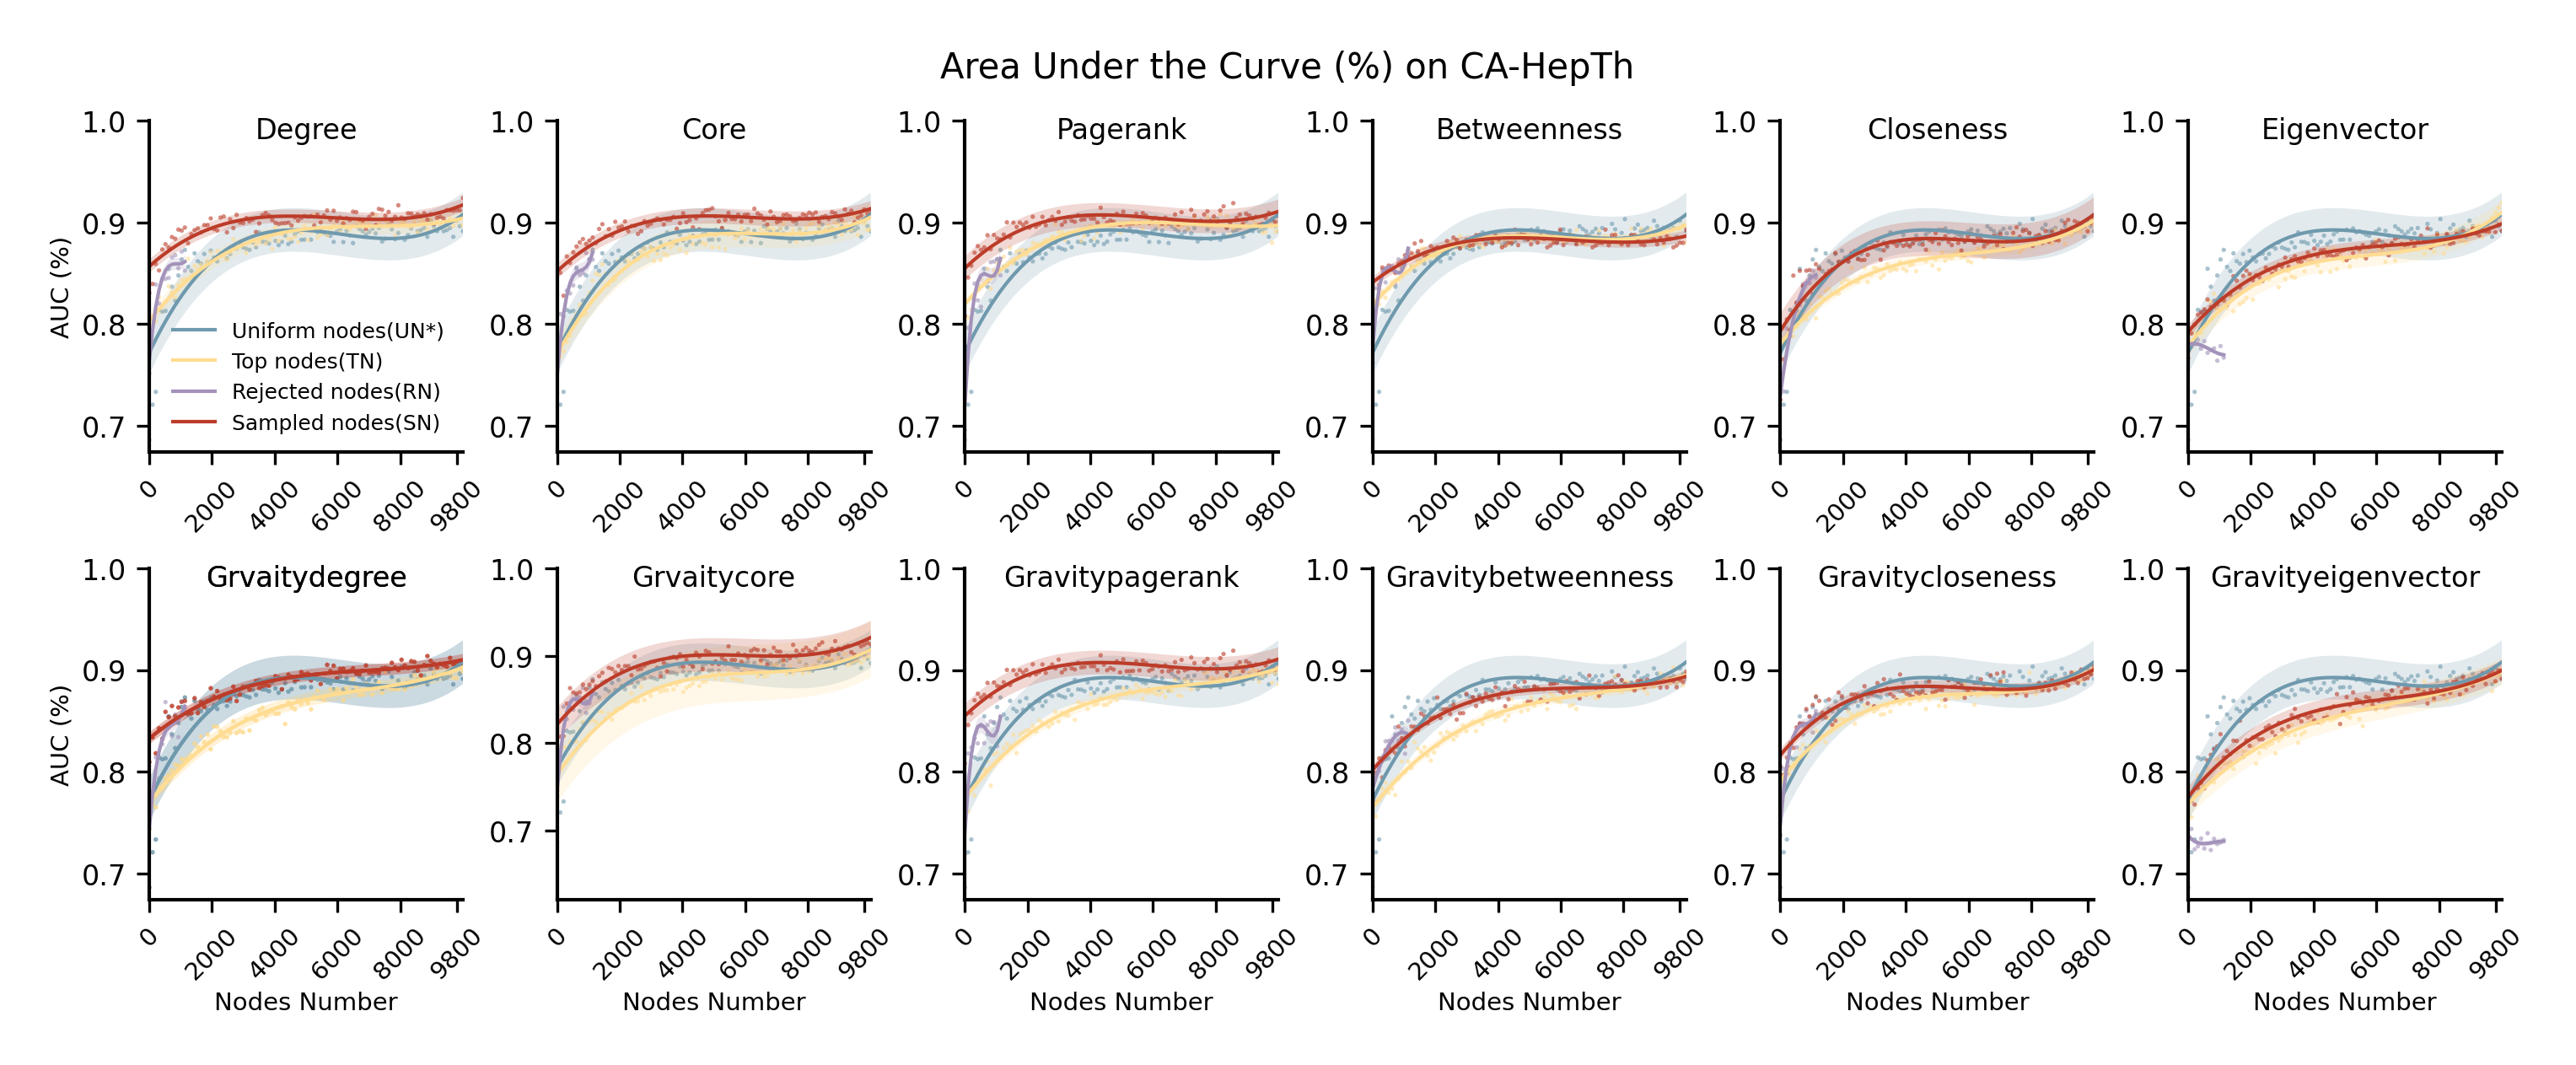

In [56]:

plt.style.use('nature')
from scipy.optimize import curve_fit
from scipy.interpolate import UnivariateSpline


def cubic_fit(x, a, b, c, d):
    return a * x**3 + b * x**2 + c * x + d

x = np.linspace(0,1,98)

fig,axes = plt.subplots(2,6,figsize = (6,2),dpi=600)

params, covariance = curve_fit(cubic_fit, x, cath_uniform[:98,0])
a_fit, b_fit, c_fit, d_fit = params
cath_uniform1 = cubic_fit(x, a_fit, b_fit, c_fit, d_fit)
axes[0,0].plot(x,cath_uniform1,color ='#6F99ADFF', label = 'Uniform nodes(UN*)',linewidth=0.5)
axes[0,0].scatter(x, cath_uniform[:98,0],color ='#6F99ADFF',edgecolors='none', s=0.4, alpha=0.6)
distances = np.abs(cath_uniform[:98, 0] - cath_uniform1)
spline = UnivariateSpline(np.arange(len(distances)), distances.flatten(), s=0)
smooth_distances = spline(np.arange(len(distances)))
smooth_distances_mean = np.mean([np.min(smooth_distances), np.max(smooth_distances)])* 2 / 4
axes[0,0].fill_between(x, cath_uniform1-smooth_distances_mean, cath_uniform1+smooth_distances_mean, color='#6F99ADFF', alpha=0.2,edgecolors='none')
params, covariance = curve_fit(cubic_fit, x, cath_degree[:98, 2])
a_fit, b_fit, c_fit, d_fit = params
cath_degree_fit = cubic_fit(x, a_fit, b_fit, c_fit, d_fit)
axes[0,0].plot(x, cath_degree_fit, color='#FFDC91FF', label='Top nodes(TN)', linewidth=0.5)
axes[0,0].scatter(x, cath_degree[:98, 2], color ='#FFDC91FF',edgecolors='none', s=0.4, alpha=0.6)
distances = np.abs(cath_degree[:98, 2] - cath_degree_fit)
spline = UnivariateSpline(np.arange(len(distances)), distances.flatten(), s=0)
smooth_distances = spline(np.arange(len(distances)))
smooth_distances_mean = np.mean([np.min(smooth_distances), np.max(smooth_distances)]) * 2 / 4
axes[0,0].fill_between(x, cath_degree_fit - smooth_distances_mean, cath_degree_fit + smooth_distances_mean, color='#FFDC91FF', alpha=0.2,edgecolors='none')

axes[0,0].tick_params(labelsize=4)

axes[0,0].set_xticks([0,0.12,0.35,0.7,1])
axes[0,0].set_xticklabels(np.array([0, 300,980, 2000, 2700]).astype(int))

axes[0,0].grid (False)
axes[0,0].spines['top'].set_visible(False)
axes[0,0].spines['right'].set_visible(False)
axes[0,0].xaxis.set_ticks_position('bottom')
axes[0,0].yaxis.set_ticks_position('left')
axes[0,0].set_yticks(np.linspace(0.6, 1, 5))
axes[0,0].set_yticks([0.6, 0.7, 0.8, 0.9,1])
axes[0,0].set_xticks([], minor=True)
axes[0,0].set_yticks([], minor=True)
axes[0,0].tick_params(axis='both', which='both', length=1.2)
axes[0,0].text(0.5, 0.97, 'Degree', transform=axes[0,0].transAxes, ha='center', va='center', bbox=dict(facecolor='none', edgecolor='none', boxstyle='round', alpha=0.0), fontsize=4)



params, covariance = curve_fit(cubic_fit, x, cath_uniform[:98,0])
a_fit, b_fit, c_fit, d_fit = params
cath_uniform1 = cubic_fit(x, a_fit, b_fit, c_fit, d_fit)
axes[0,1].plot(x,cath_uniform1,color ='#6F99ADFF', label = 'uniform',linewidth=0.5)
axes[0,1].scatter(x, cath_uniform[:98,0],color ='#6F99ADFF',edgecolors='none', s=0.4, alpha=0.6)
distances = np.abs(cath_uniform[:98, 0] - cath_uniform1)
spline = UnivariateSpline(np.arange(len(distances)), distances.flatten(), s=0)
smooth_distances = spline(np.arange(len(distances)))
smooth_distances_mean = np.mean([np.min(smooth_distances), np.max(smooth_distances)])* 2 / 4
axes[0,1].fill_between(x, cath_uniform1-smooth_distances_mean, cath_uniform1+smooth_distances_mean, color='#6F99ADFF', alpha=0.2,edgecolors='none')
params, covariance = curve_fit(cubic_fit, x, cath_core[:98, 2])
a_fit, b_fit, c_fit, d_fit = params
cath_core_fit = cubic_fit(x, a_fit, b_fit, c_fit, d_fit)
axes[0,1].plot(x, cath_core_fit, color='#FFDC91FF', label='Top Nodes', linewidth=0.5)
axes[0,1].scatter(x, cath_core[:98, 2], color ='#FFDC91FF',edgecolors='none', s=0.4, alpha=0.6)
distances = np.abs(cath_core[:98, 2] - cath_core_fit)
spline = UnivariateSpline(np.arange(len(distances)), distances.flatten(), s=0)
smooth_distances = spline(np.arange(len(distances)))
smooth_distances_mean = np.mean([np.min(smooth_distances), np.max(smooth_distances)]) * 2 / 4
axes[0,1].fill_between(x, cath_core_fit - smooth_distances_mean, cath_core_fit + smooth_distances_mean, color='#FFDC91FF', alpha=0.2,edgecolors='none')

axes[0,1].tick_params(labelsize=4)
axes[0,1].grid (False)
axes[0,1].spines['top'].set_visible(False)
axes[0,1].spines['right'].set_visible(False)
axes[0,1].xaxis.set_ticks_position('bottom')
axes[0,1].yaxis.set_ticks_position('left')
axes[0,1].set_yticks(np.linspace(0.6, 1, 5))
axes[0,1].set_yticks([0.6, 0.7, 0.8, 0.9,1])
axes[0,1].set_xticks([], minor=True)
axes[0,1].set_yticks([], minor=True)
axes[0,1].tick_params(axis='both', which='both', length=1.2)
axes[0,1].text(0.5, 0.97, 'Core', transform=axes[0,1].transAxes, ha='center', va='center', bbox=dict(facecolor='none', edgecolor='none', boxstyle='round', alpha=0.0), fontsize=4)



params, covariance = curve_fit(cubic_fit, x, cath_uniform[:98,0])
a_fit, b_fit, c_fit, d_fit = params
cath_uniform1 = cubic_fit(x, a_fit, b_fit, c_fit, d_fit)
axes[0,2].plot(x,cath_uniform1,color ='#6F99ADFF', label = 'uniform',linewidth=0.5)
axes[0,2].scatter(x, cath_uniform[:98,0],color ='#6F99ADFF',edgecolors='none', s=0.4, alpha=0.6)
distances = np.abs(cath_uniform[:98, 0] - cath_uniform1)
spline = UnivariateSpline(np.arange(len(distances)), distances.flatten(), s=0)
smooth_distances = spline(np.arange(len(distances)))
smooth_distances_mean = np.mean([np.min(smooth_distances), np.max(smooth_distances)])* 2 / 4
axes[0,2].fill_between(x, cath_uniform1-smooth_distances_mean, cath_uniform1+smooth_distances_mean, color='#6F99ADFF', alpha=0.2,edgecolors='none')
params, covariance = curve_fit(cubic_fit, x, cath_pagerank[:98, 2])
a_fit, b_fit, c_fit, d_fit = params
cath_pagerank_fit = cubic_fit(x, a_fit, b_fit, c_fit, d_fit)
axes[0,2].plot(x, cath_pagerank_fit, color='#FFDC91FF', label='Top Nodes', linewidth=0.5)
axes[0,2].scatter(x, cath_pagerank[:98, 2], color ='#FFDC91FF',edgecolors='none', s=0.4, alpha=0.6)
distances = np.abs(cath_pagerank[:98, 2] - cath_pagerank_fit)
spline = UnivariateSpline(np.arange(len(distances)), distances.flatten(), s=0)
smooth_distances = spline(np.arange(len(distances)))
smooth_distances_mean = np.mean([np.min(smooth_distances), np.max(smooth_distances)]) * 2 / 4
axes[0,2].fill_between(x, cath_pagerank_fit - smooth_distances_mean, cath_pagerank_fit + smooth_distances_mean, color='#FFDC91FF', alpha=0.2,edgecolors='none')

axes[0,2].tick_params(labelsize=4)
axes[0,2].set_xticks([0,0.12,0.35,0.7,1])
axes[0,2].set_xticklabels(np.array([0, 300,980, 2000, 2700]).astype(int))
#axes[0,2].legend(fontsize=3,edgecolor='black',framealpha=0.1,loc='center right')
axes[0,2].grid (False)
axes[0,2].spines['top'].set_visible(False)
axes[0,2].spines['right'].set_visible(False)
axes[0,2].xaxis.set_ticks_position('bottom')
axes[0,2].yaxis.set_ticks_position('left')
axes[0,2].set_yticks(np.linspace(0.6, 1, 5))
axes[0,2].set_yticks([0.6, 0.7, 0.8, 0.9,1])
axes[0,2].set_xticks([], minor=True)
axes[0,2].set_yticks([], minor=True)
axes[0,2].tick_params(axis='both', which='both', length=1.2)
axes[0,2].text(0.5, 0.97, 'Pagerank', transform=axes[0,2].transAxes, ha='center', va='center', bbox=dict(facecolor='none', edgecolor='none', boxstyle='round', alpha=0.0), fontsize=4)

params, covariance = curve_fit(cubic_fit, x, cath_uniform[:98,0])
a_fit, b_fit, c_fit, d_fit = params
cath_uniform1 = cubic_fit(x, a_fit, b_fit, c_fit, d_fit)
axes[0,3].plot(x,cath_uniform1,color ='#6F99ADFF', label = 'uniform',linewidth=0.5)
axes[0,3].scatter(x, cath_uniform[:98,0],color ='#6F99ADFF',edgecolors='none', s=0.4, alpha=0.6)
distances = np.abs(cath_uniform[:98, 0] - cath_uniform1)
spline = UnivariateSpline(np.arange(len(distances)), distances.flatten(), s=0)
smooth_distances = spline(np.arange(len(distances)))
smooth_distances_mean = np.mean([np.min(smooth_distances), np.max(smooth_distances)])* 2 / 4
axes[0,3].fill_between(x, cath_uniform1-smooth_distances_mean, cath_uniform1+smooth_distances_mean, color='#6F99ADFF', alpha=0.2,edgecolors='none')
params, covariance = curve_fit(cubic_fit, x, cath_betweenness[:98, 2])
a_fit, b_fit, c_fit, d_fit = params
cath_betweenness_fit = cubic_fit(x, a_fit, b_fit, c_fit, d_fit)
axes[0,3].plot(x, cath_betweenness_fit, color='#FFDC91FF', label='Top Nodes', linewidth=0.5)
axes[0,3].scatter(x, cath_betweenness[:98, 2], color ='#FFDC91FF',edgecolors='none', s=0.4, alpha=0.6)
distances = np.abs(cath_betweenness[:98, 2] - cath_betweenness_fit)
spline = UnivariateSpline(np.arange(len(distances)), distances.flatten(), s=0)
smooth_distances = spline(np.arange(len(distances)))
smooth_distances_mean = np.mean([np.min(smooth_distances), np.max(smooth_distances)]) * 2 / 4
axes[0,3].fill_between(x, cath_betweenness_fit - smooth_distances_mean, cath_betweenness_fit + smooth_distances_mean, color='#FFDC91FF', alpha=0.2,edgecolors='none')

axes[0,3].tick_params(labelsize=4)
axes[0,3].set_xticks([0,0.12,0.35,0.7,1])
axes[0,3].set_xticklabels(np.array([0, 300,980, 2000, 2700]).astype(int))
#axes[0,3].legend(fontsize=3,edgecolor='black',framealpha=0.1,loc='center right')
axes[0,3].grid (False)
axes[0,3].spines['top'].set_visible(False)
axes[0,3].spines['right'].set_visible(False)
axes[0,3].xaxis.set_ticks_position('bottom')
axes[0,3].yaxis.set_ticks_position('left')
axes[0,3].set_yticks(np.linspace(0.6, 1, 5))
axes[0,3].set_yticks([0.6, 0.7, 0.8, 0.9,1])
axes[0,3].set_xticks([], minor=True)
axes[0,3].set_yticks([], minor=True)
axes[0,3].tick_params(axis='both', which='both', length=1.2)
axes[0,3].text(0.5, 0.97, 'Betweenness', transform=axes[0,3].transAxes, ha='center', va='center', bbox=dict(facecolor='none', edgecolor='none', boxstyle='round', alpha=0.0), fontsize=4)


params, covariance = curve_fit(cubic_fit, x, cath_uniform[:98,0])
a_fit, b_fit, c_fit, d_fit = params
cath_uniform1 = cubic_fit(x, a_fit, b_fit, c_fit, d_fit)
axes[0,4].plot(x,cath_uniform1,color ='#6F99ADFF', label = 'uniform',linewidth=0.5)
axes[0,4].scatter(x, cath_uniform[:98,0],color ='#6F99ADFF',edgecolors='none', s=0.4, alpha=0.6)
distances = np.abs(cath_uniform[:98, 0] - cath_uniform1)
spline = UnivariateSpline(np.arange(len(distances)), distances.flatten(), s=0)
smooth_distances = spline(np.arange(len(distances)))
smooth_distances_mean = np.mean([np.min(smooth_distances), np.max(smooth_distances)])* 2 / 4
axes[0,4].fill_between(x, cath_uniform1-smooth_distances_mean, cath_uniform1+smooth_distances_mean, color='#6F99ADFF', alpha=0.2,edgecolors='none')
params, covariance = curve_fit(cubic_fit, x, cath_closeness[:98, 2])
a_fit, b_fit, c_fit, d_fit = params
cath_closeness_fit = cubic_fit(x, a_fit, b_fit, c_fit, d_fit)
axes[0,4].plot(x, cath_closeness_fit, color='#FFDC91FF', label='Top Nodes', linewidth=0.5)
axes[0,4].scatter(x, cath_closeness[:98, 2], color ='#FFDC91FF',edgecolors='none', s=0.4, alpha=0.6)
distances = np.abs(cath_closeness[:98, 2] - cath_closeness_fit)
spline = UnivariateSpline(np.arange(len(distances)), distances.flatten(), s=0)
smooth_distances = spline(np.arange(len(distances)))
smooth_distances_mean = np.mean([np.min(smooth_distances), np.max(smooth_distances)]) * 2 / 4
axes[0,4].fill_between(x, cath_closeness_fit - smooth_distances_mean, cath_closeness_fit + smooth_distances_mean, color='#FFDC91FF', alpha=0.2,edgecolors='none')

axes[0,4].tick_params(labelsize=4)
axes[0,4].set_xticks([0,0.12,0.35,0.7,1])
axes[0,4].set_xticklabels(np.array([0, 300,980, 2000, 2700]).astype(int))
#axes[0,4].legend(fontsize=3,edgecolor='black',framealpha=0.1,loc='center right')
axes[0,4].grid (False)
axes[0,4].spines['top'].set_visible(False)
axes[0,4].spines['right'].set_visible(False)
axes[0,4].xaxis.set_ticks_position('bottom')
axes[0,4].yaxis.set_ticks_position('left')
axes[0,4].set_yticks(np.linspace(0.6, 1, 5))
axes[0,4].set_yticks([0.6, 0.7, 0.8, 0.9,1])
axes[0,4].set_xticks([], minor=True)
axes[0,4].set_yticks([], minor=True)
axes[0,4].tick_params(axis='both', which='both', length=1.2)
axes[0,4].text(0.5, 0.97, 'Closeness', transform=axes[0,4].transAxes, ha='center', va='center', bbox=dict(facecolor='none', edgecolor='none', boxstyle='round', alpha=0.0), fontsize=4)



params, covariance = curve_fit(cubic_fit, x, cath_uniform[:98,0])
a_fit, b_fit, c_fit, d_fit = params
cath_uniform1 = cubic_fit(x, a_fit, b_fit, c_fit, d_fit)
axes[0,5].plot(x,cath_uniform1,color ='#6F99ADFF', label = 'uniform',linewidth=0.5)
axes[0,5].scatter(x, cath_uniform[:98,0],color ='#6F99ADFF',edgecolors='none', s=0.4, alpha=0.6)
distances = np.abs(cath_uniform[:98, 0] - cath_uniform1)
spline = UnivariateSpline(np.arange(len(distances)), distances.flatten(), s=0)
smooth_distances = spline(np.arange(len(distances)))
smooth_distances_mean = np.mean([np.min(smooth_distances), np.max(smooth_distances)])* 2 / 4
axes[0,5].fill_between(x, cath_uniform1-smooth_distances_mean, cath_uniform1+smooth_distances_mean, color='#6F99ADFF', alpha=0.2,edgecolors='none')
params, covariance = curve_fit(cubic_fit, x, cath_eigenvector[:98, 2])
a_fit, b_fit, c_fit, d_fit = params
cath_eigenvector_fit = cubic_fit(x, a_fit, b_fit, c_fit, d_fit)
axes[0,5].plot(x, cath_eigenvector_fit, color='#FFDC91FF', label='Top Nodes', linewidth=0.5)
axes[0,5].scatter(x, cath_eigenvector[:98, 2], color ='#FFDC91FF',edgecolors='none', s=0.4, alpha=0.6)
distances = np.abs(cath_eigenvector[:98, 2] - cath_eigenvector_fit)
spline = UnivariateSpline(np.arange(len(distances)), distances.flatten(), s=0)
smooth_distances = spline(np.arange(len(distances)))
smooth_distances_mean = np.mean([np.min(smooth_distances), np.max(smooth_distances)]) * 2 / 4
axes[0,5].fill_between(x, cath_eigenvector_fit - smooth_distances_mean, cath_eigenvector_fit + smooth_distances_mean, color='#FFDC91FF', alpha=0.2,edgecolors='none')

axes[0,5].tick_params(labelsize=4)
axes[0,5].set_xticks([0,0.12,0.35,0.7,1])
axes[0,5].set_xticklabels(np.array([0, 300,980, 2000, 2700]).astype(int))
#axes[0,5].legend(fontsize=3,edgecolor='black',framealpha=0.1,loc='center right')
axes[0,5].grid (False)
axes[0,5].spines['top'].set_visible(False)
axes[0,5].spines['right'].set_visible(False)
axes[0,5].xaxis.set_ticks_position('bottom')
axes[0,5].yaxis.set_ticks_position('left')
axes[0,5].set_yticks(np.linspace(0.6, 1, 5))
axes[0,5].set_yticks([0.6, 0.7, 0.8, 0.9,1])
axes[0,5].set_xticks([], minor=True)
axes[0,5].set_yticks([], minor=True)
axes[0,5].tick_params(axis='both', which='both', length=1.2)
axes[0,5].text(0.5, 0.97, 'Eigenvector', transform=axes[0,5].transAxes, ha='center', va='center', bbox=dict(facecolor='none', edgecolor='none', boxstyle='round', alpha=0.0), fontsize=4)





params, covariance = curve_fit(cubic_fit, x, cath_uniform[:98,0])
a_fit, b_fit, c_fit, d_fit = params
cath_uniform1 = cubic_fit(x, a_fit, b_fit, c_fit, d_fit)

params, covariance = curve_fit(cubic_fit, x, cath_uniform[:98,0])
a_fit, b_fit, c_fit, d_fit = params
cath_uniform1 = cubic_fit(x, a_fit, b_fit, c_fit, d_fit)
axes[1,0].plot(x,cath_uniform1,color ='#6F99ADFF', label = 'uniform',linewidth=0.5)
axes[1,0].scatter(x, cath_uniform[:98,0],color ='#6F99ADFF',edgecolors='none', s=0.4, alpha=0.6)
distances = np.abs(cath_uniform[:98, 0] - cath_uniform1)
spline = UnivariateSpline(np.arange(len(distances)), distances.flatten(), s=0)
smooth_distances = spline(np.arange(len(distances)))
smooth_distances_mean = np.mean([np.min(smooth_distances), np.max(smooth_distances)])* 2 / 4
axes[1,0].fill_between(x, cath_uniform1-smooth_distances_mean, cath_uniform1+smooth_distances_mean, color='#6F99ADFF', alpha=0.2,edgecolors='none')
params, covariance = curve_fit(cubic_fit, x, cath_gravitydegree[:98, 2])
a_fit, b_fit, c_fit, d_fit = params
cath_gravitydegree_fit = cubic_fit(x, a_fit, b_fit, c_fit, d_fit)
axes[1,0].plot(x, cath_gravitydegree_fit, color='#FFDC91FF', label='Top Nodes', linewidth=0.5)
axes[1,0].scatter(x, cath_gravitydegree[:98, 2], color ='#FFDC91FF',edgecolors='none', s=0.4, alpha=0.6)
distances = np.abs(cath_gravitydegree[:98, 2] - cath_gravitydegree_fit)
spline = UnivariateSpline(np.arange(len(distances)), distances.flatten(), s=0)
smooth_distances = spline(np.arange(len(distances)))
smooth_distances_mean = np.mean([np.min(smooth_distances), np.max(smooth_distances)]) * 2 / 4
axes[1,0].fill_between(x, cath_gravitydegree_fit - smooth_distances_mean, cath_gravitydegree_fit + smooth_distances_mean, color='#FFDC91FF', alpha=0.2,edgecolors='none')

axes[1,0].tick_params(labelsize=4)
axes[1,0].set_xticks([0,0.12,0.35,0.7,1])
axes[1,0].set_xticklabels(np.array([0, 300,980, 2000, 2700]).astype(int))
axes[1,0].grid (False)
axes[1,0].spines['top'].set_visible(False)
axes[1,0].spines['right'].set_visible(False)
axes[1,0].xaxis.set_ticks_position('bottom')
axes[1,0].yaxis.set_ticks_position('left')
axes[1,0].set_yticks(np.linspace(0.6, 1, 5))
axes[1,0].set_yticks([0.6, 0.7, 0.8, 0.9,1])
axes[1,0].set_xticks([], minor=True)
axes[1,0].set_yticks([], minor=True)
axes[1,0].tick_params(axis='both', which='both', length=1.2)
axes[1,0].text(0.5, 0.97, 'Grvaitydegree', transform=axes[1,0].transAxes, ha='center', va='center', bbox=dict(facecolor='none', edgecolor='none', boxstyle='round', alpha=0.0), fontsize=4)


axes[1,0].plot(x,cath_uniform1,color ='#6F99ADFF', label = 'uniform',linewidth=0.5)
axes[1,0].scatter(x, cath_uniform[:98,0],color ='#6F99ADFF',edgecolors='none', s=0.4, alpha=0.6)
distances = np.abs(cath_uniform[:98, 0] - cath_uniform1)
spline = UnivariateSpline(np.arange(len(distances)), distances.flatten(), s=0)
smooth_distances = spline(np.arange(len(distances)))
smooth_distances_mean = np.mean([np.min(smooth_distances), np.max(smooth_distances)])* 2 / 4
axes[1,0].fill_between(x, cath_uniform1-smooth_distances_mean, cath_uniform1+smooth_distances_mean, color='#6F99ADFF', alpha=0.2,edgecolors='none')
params, covariance = curve_fit(cubic_fit, x, cath_gravitydegree[:98, 2])
a_fit, b_fit, c_fit, d_fit = params
cath_gravitydegree_fit = cubic_fit(x, a_fit, b_fit, c_fit, d_fit)
axes[1,0].plot(x, cath_gravitydegree_fit, color='#FFDC91FF', label='Top Nodes', linewidth=0.5)
axes[1,0].scatter(x, cath_gravitydegree[:98, 2], color ='#FFDC91FF',edgecolors='none', s=0.4, alpha=0.6)
distances = np.abs(cath_gravitydegree[:98, 2] - cath_gravitydegree_fit)
spline = UnivariateSpline(np.arange(len(distances)), distances.flatten(), s=0)
smooth_distances = spline(np.arange(len(distances)))
smooth_distances_mean = np.mean([np.min(smooth_distances), np.max(smooth_distances)]) * 2 / 4
axes[1,0].fill_between(x, cath_gravitydegree_fit - smooth_distances_mean, cath_gravitydegree_fit + smooth_distances_mean, color='#FFDC91FF', alpha=0.2,edgecolors='none')
params, covariance = curve_fit(cubic_fit, x, cath_gravitydegree[:98,0])
a_fit, b_fit, c_fit, d_fit = params
cath_gravitydegree_fit = cubic_fit(x, a_fit, b_fit, c_fit, d_fit)
axes[1,0].plot(x, cath_gravitydegree_fit, color='#BC3C29FF', label='Sampled Nodes', linewidth=0.5)
axes[1,0].scatter(x, cath_gravitydegree[:98, 0], color ='#BC3C29FF',edgecolors='none', s=0.4, alpha=0.6)
distances = np.abs(cath_gravitydegree[:98, 0] - cath_gravitydegree_fit)
spline = UnivariateSpline(np.arange(len(distances)), distances.flatten(), s=0)
smooth_distances = spline(np.arange(len(distances)))
smooth_distances_mean = np.mean([np.min(smooth_distances), np.max(smooth_distances)]) * 2 / 4
axes[1,0].fill_between(x, cath_gravitydegree_fit - smooth_distances_mean, cath_gravitydegree_fit + smooth_distances_mean, color='#BC3C29FF', alpha=0.2,edgecolors='none')
axes[1,0].tick_params(labelsize=4)
axes[1,0].set_xticks([0,0.12,0.35,0.7,1])
axes[1,0].set_xticklabels(np.array([0, 300,980, 2000, 2700]).astype(int))
#axes[1,0].legend(fontsize=3,edgecolor='black',framealpha=0.1,loc='center right')
axes[1,0].grid (False)
axes[1,0].spines['top'].set_visible(False)
axes[1,0].spines['right'].set_visible(False)
axes[1,0].xaxis.set_ticks_position('bottom')
axes[1,0].yaxis.set_ticks_position('left')
axes[1,0].set_yticks(np.linspace(0.6, 1, 5))
axes[1,0].set_yticks([0.6, 0.7, 0.8, 0.9,1])
axes[1,0].set_xticks([], minor=True)
axes[1,0].set_yticks([], minor=True)
axes[1,0].tick_params(axis='both', which='both', length=1.2)
axes[1,0].text(0.5, 0.97, 'Grvaitydegree', transform=axes[1,0].transAxes, ha='center', va='center', bbox=dict(facecolor='none', edgecolor='none', boxstyle='round', alpha=0.0), fontsize=4)



params, covariance = curve_fit(cubic_fit, x, cath_uniform[:98,0])
a_fit, b_fit, c_fit, d_fit = params
cath_uniform1 = cubic_fit(x, a_fit, b_fit, c_fit, d_fit)
axes[1,1].plot(x,cath_uniform1,color ='#6F99ADFF', label = 'uniform',linewidth=0.5)
axes[1,1].scatter(x, cath_uniform[:98,0],color ='#6F99ADFF',edgecolors='none', s=0.4, alpha=0.6)
distances = np.abs(cath_uniform[:98, 0] - cath_uniform1)
spline = UnivariateSpline(np.arange(len(distances)), distances.flatten(), s=0)
smooth_distances = spline(np.arange(len(distances)))
smooth_distances_mean = np.mean([np.min(smooth_distances), np.max(smooth_distances)])* 2 / 4
axes[1,1].fill_between(x, cath_uniform1-smooth_distances_mean, cath_uniform1+smooth_distances_mean, color='#6F99ADFF', alpha=0.2,edgecolors='none')
params, covariance = curve_fit(cubic_fit, x, cath_gravitycore[:98, 2])
a_fit, b_fit, c_fit, d_fit = params
cath_gravitycore_fit = cubic_fit(x, a_fit, b_fit, c_fit, d_fit)
axes[1,1].plot(x, cath_gravitycore_fit, color='#FFDC91FF', label='Top Nodes', linewidth=0.5)
axes[1,1].scatter(x, cath_gravitycore[:98, 2], color ='#FFDC91FF',edgecolors='none', s=0.4, alpha=0.6)
distances = np.abs(cath_gravitycore[:98, 2] - cath_gravitycore_fit)
spline = UnivariateSpline(np.arange(len(distances)), distances.flatten(), s=0)
smooth_distances = spline(np.arange(len(distances)))
smooth_distances_mean = np.mean([np.min(smooth_distances), np.max(smooth_distances)]) *2 / 4
axes[1,1].fill_between(x, cath_gravitycore_fit - smooth_distances_mean, cath_gravitycore_fit + smooth_distances_mean, color='#FFDC91FF', alpha=0.2,edgecolors='none')

axes[1,1].tick_params(labelsize=4)
axes[1,1].set_xticks([0,0.12,0.35,0.7,1])
axes[1,1].set_xticklabels(np.array([0, 300,980, 2000, 2700]).astype(int))
#axes[1,1].legend(fontsize=3,edgecolor='black',framealpha=0.1,loc='center right')
axes[1,1].grid (False)
axes[1,1].spines['top'].set_visible(False)
axes[1,1].spines['right'].set_visible(False)
axes[1,1].xaxis.set_ticks_position('bottom')
axes[1,1].yaxis.set_ticks_position('left')
axes[1,1].set_yticks(np.linspace(0.6, 1, 5))
axes[1,1].set_yticks([0.6, 0.7, 0.8, 0.9,1])
axes[1,1].set_xticks([], minor=True)
axes[1,1].set_yticks([], minor=True)
axes[1,1].tick_params(axis='both', which='both', length=1.2)
axes[1,1].text(0.5, 0.97, 'Grvaitycore', transform=axes[1,1].transAxes, ha='center', va='center', bbox=dict(facecolor='none', edgecolor='none', boxstyle='round', alpha=0.0), fontsize=4)








params, covariance = curve_fit(cubic_fit, x, cath_uniform[:98,0])
a_fit, b_fit, c_fit, d_fit = params
cath_uniform1 = cubic_fit(x, a_fit, b_fit, c_fit, d_fit)
axes[1,2].plot(x,cath_uniform1,color ='#6F99ADFF', label = 'uniform',linewidth=0.5)
axes[1,2].scatter(x, cath_uniform[:98,0],color ='#6F99ADFF',edgecolors='none', s=0.4, alpha=0.6)
distances = np.abs(cath_uniform[:98, 0] - cath_uniform1)
spline = UnivariateSpline(np.arange(len(distances)), distances.flatten(), s=0)
smooth_distances = spline(np.arange(len(distances)))
smooth_distances_mean = np.mean([np.min(smooth_distances), np.max(smooth_distances)])* 2 / 4
axes[1,2].fill_between(x, cath_uniform1-smooth_distances_mean, cath_uniform1+smooth_distances_mean, color='#6F99ADFF', alpha=0.2,edgecolors='none')
params, covariance = curve_fit(cubic_fit, x, cath_gravitypagerank[:98, 2])
a_fit, b_fit, c_fit, d_fit = params
cath_gravitypagerank_fit = cubic_fit(x, a_fit, b_fit, c_fit, d_fit)
axes[1,2].plot(x, cath_gravitypagerank_fit, color='#FFDC91FF', label='Top Nodes', linewidth=0.5)
axes[1,2].scatter(x, cath_gravitypagerank[:98, 2], color ='#FFDC91FF',edgecolors='none', s=0.4, alpha=0.6)
distances = np.abs(cath_gravitypagerank[:98, 2] - cath_gravitypagerank_fit)
spline = UnivariateSpline(np.arange(len(distances)), distances.flatten(), s=0)
smooth_distances = spline(np.arange(len(distances)))
smooth_distances_mean = np.mean([np.min(smooth_distances), np.max(smooth_distances)]) * 2 / 4
axes[1,2].fill_between(x, cath_gravitypagerank_fit - smooth_distances_mean, cath_gravitypagerank_fit + smooth_distances_mean, color='#FFDC91FF', alpha=0.2,edgecolors='none')
axes[1,2].tick_params(labelsize=4)
axes[1,2].set_xticks([0,0.12,0.35,0.7,1])
axes[1,2].set_xticklabels(np.array([0, 300,980, 2000, 2700]).astype(int))
#axes[1,2].legend(fontsize=3,edgecolor='black',framealpha=0.1,loc='center right')
axes[1,2].grid (False)
axes[1,2].spines['top'].set_visible(False)
axes[1,2].spines['right'].set_visible(False)
axes[1,2].xaxis.set_ticks_position('bottom')
axes[1,2].yaxis.set_ticks_position('left')
axes[1,2].set_yticks(np.linspace(0.6, 1, 5))
axes[1,2].set_yticks([0.6, 0.7, 0.8, 0.9,1])
axes[1,2].set_xticks([], minor=True)
axes[1,2].set_yticks([], minor=True)
axes[1,2].tick_params(axis='both', which='both', length=1.2)
axes[1,2].text(0.5, 0.97, 'Gravitypagerank', transform=axes[1,2].transAxes, ha='center', va='center', bbox=dict(facecolor='none', edgecolor='none', boxstyle='round', alpha=0.0), fontsize=4)




params, covariance = curve_fit(cubic_fit, x, cath_uniform[:98,0])
a_fit, b_fit, c_fit, d_fit = params
cath_uniform1 = cubic_fit(x, a_fit, b_fit, c_fit, d_fit)
axes[1,3].plot(x,cath_uniform1,color ='#6F99ADFF', label = 'uniform',linewidth=0.5)
axes[1,3].scatter(x, cath_uniform[:98,0],color ='#6F99ADFF',edgecolors='none', s=0.4, alpha=0.6)
distances = np.abs(cath_uniform[:98, 0] - cath_uniform1)
spline = UnivariateSpline(np.arange(len(distances)), distances.flatten(), s=0)
smooth_distances = spline(np.arange(len(distances)))
smooth_distances_mean = np.mean([np.min(smooth_distances), np.max(smooth_distances)])* 2 / 4
axes[1,3].fill_between(x, cath_uniform1-smooth_distances_mean, cath_uniform1+smooth_distances_mean, color='#6F99ADFF', alpha=0.2,edgecolors='none')
params, covariance = curve_fit(cubic_fit, x, cath_gravitybetweenness[:98, 2])
a_fit, b_fit, c_fit, d_fit = params
cath_gravitybetweenness_fit = cubic_fit(x, a_fit, b_fit, c_fit, d_fit)
axes[1,3].plot(x, cath_gravitybetweenness_fit, color='#FFDC91FF', label='Top Nodes', linewidth=0.5)
axes[1,3].scatter(x, cath_gravitybetweenness[:98, 2], color ='#FFDC91FF',edgecolors='none', s=0.4, alpha=0.6)
distances = np.abs(cath_gravitybetweenness[:98, 2] - cath_gravitybetweenness_fit)
spline = UnivariateSpline(np.arange(len(distances)), distances.flatten(), s=0)
smooth_distances = spline(np.arange(len(distances)))
smooth_distances_mean = np.mean([np.min(smooth_distances), np.max(smooth_distances)]) * 2 / 4
axes[1,3].fill_between(x, cath_gravitybetweenness_fit - smooth_distances_mean, cath_gravitybetweenness_fit + smooth_distances_mean, color='#FFDC91FF', alpha=0.2,edgecolors='none')
axes[1,3].tick_params(labelsize=4)
axes[1,3].set_xticks([0,0.12,0.35,0.7,1])
axes[1,3].set_xticklabels(np.array([0, 300,980, 2000, 2700]).astype(int))
#axes[1,3].legend(fontsize=3,edgecolor='black',framealpha=0.1,loc='center right')
axes[1,3].grid (False)
axes[1,3].spines['top'].set_visible(False)
axes[1,3].spines['right'].set_visible(False)
axes[1,3].xaxis.set_ticks_position('bottom')
axes[1,3].yaxis.set_ticks_position('left')
axes[1,3].set_yticks(np.linspace(0.6, 1, 5))
axes[1,3].set_yticks([0.6, 0.7, 0.8, 0.9,1])
axes[1,3].set_xticks([], minor=True)
axes[1,3].set_yticks([], minor=True)
axes[1,3].tick_params(axis='both', which='both', length=1.2)
axes[1,3].text(0.5, 0.97, 'Gravitybetweenness', transform=axes[1,3].transAxes, ha='center', va='center', bbox=dict(facecolor='none', edgecolor='none', boxstyle='round', alpha=0.0), fontsize=4)






params, covariance = curve_fit(cubic_fit, x, cath_uniform[:98,0])
a_fit, b_fit, c_fit, d_fit = params
cath_uniform1 = cubic_fit(x, a_fit, b_fit, c_fit, d_fit)
axes[1,4].plot(x,cath_uniform1,color ='#6F99ADFF', label = 'uniform',linewidth=0.5)
axes[1,4].scatter(x, cath_uniform[:98,0],color ='#6F99ADFF',edgecolors='none', s=0.4, alpha=0.6)
distances = np.abs(cath_uniform[:98, 0] - cath_uniform1)
spline = UnivariateSpline(np.arange(len(distances)), distances.flatten(), s=0)
smooth_distances = spline(np.arange(len(distances)))
smooth_distances_mean = np.mean([np.min(smooth_distances), np.max(smooth_distances)])* 2 / 4
axes[1,4].fill_between(x, cath_uniform1-smooth_distances_mean, cath_uniform1+smooth_distances_mean, color='#6F99ADFF', alpha=0.2,edgecolors='none')
params, covariance = curve_fit(cubic_fit, x, cath_gravitycloseness[:98, 2])
a_fit, b_fit, c_fit, d_fit = params
cath_gravitycloseness_fit = cubic_fit(x, a_fit, b_fit, c_fit, d_fit)
axes[1,4].plot(x, cath_gravitycloseness_fit, color='#FFDC91FF', label='Top Nodes', linewidth=0.5)
axes[1,4].scatter(x, cath_gravitycloseness[:98, 2], color ='#FFDC91FF',edgecolors='none', s=0.4, alpha=0.6)
distances = np.abs(cath_gravitycloseness[:98, 2] - cath_gravitycloseness_fit)
spline = UnivariateSpline(np.arange(len(distances)), distances.flatten(), s=0)
smooth_distances = spline(np.arange(len(distances)))
smooth_distances_mean = np.mean([np.min(smooth_distances), np.max(smooth_distances)]) * 2 / 4
axes[1,4].fill_between(x, cath_gravitycloseness_fit - smooth_distances_mean, cath_gravitycloseness_fit + smooth_distances_mean, color='#FFDC91FF', alpha=0.2,edgecolors='none')
axes[1,4].tick_params(labelsize=4)
axes[1,4].set_xticks([0,0.12,0.35,0.7,1])
axes[1,4].set_xticklabels(np.array([0, 300,980, 2000, 2700]).astype(int))
#axes[1,4].legend(fontsize=3,edgecolor='black',framealpha=0.1,loc='center right')
axes[1,4].grid (False)
axes[1,4].spines['top'].set_visible(False)
axes[1,4].spines['right'].set_visible(False)
axes[1,4].xaxis.set_ticks_position('bottom')
axes[1,4].yaxis.set_ticks_position('left')
axes[1,4].set_yticks(np.linspace(0.6, 1, 5))
axes[1,4].set_yticks([0.6, 0.7, 0.8, 0.9,1])
axes[1,4].set_xticks([], minor=True)
axes[1,4].set_yticks([], minor=True)
axes[1,4].tick_params(axis='both', which='both', length=1.2)
axes[1,4].text(0.5, 0.97, 'Gravitycloseness', transform=axes[1,4].transAxes, ha='center', va='center', bbox=dict(facecolor='none', edgecolor='none', boxstyle='round', alpha=0.0), fontsize=4)








params, covariance = curve_fit(cubic_fit, x, cath_uniform[:98,0])
a_fit, b_fit, c_fit, d_fit = params
cath_uniform1 = cubic_fit(x, a_fit, b_fit, c_fit, d_fit)
axes[1,5].plot(x,cath_uniform1,color ='#6F99ADFF', label = 'uniform',linewidth=0.5)
axes[1,5].scatter(x, cath_uniform[:98,0],color ='#6F99ADFF',edgecolors='none', s=0.4, alpha=0.6)
distances = np.abs(cath_uniform[:98, 0] - cath_uniform1)
spline = UnivariateSpline(np.arange(len(distances)), distances.flatten(), s=0)
smooth_distances = spline(np.arange(len(distances)))
smooth_distances_mean = np.mean([np.min(smooth_distances), np.max(smooth_distances)])* 2 / 4
axes[1,5].fill_between(x, cath_uniform1-smooth_distances_mean, cath_uniform1+smooth_distances_mean, color='#6F99ADFF', alpha=0.2,edgecolors='none')
params, covariance = curve_fit(cubic_fit, x, cath_gravityeigenvector[:98, 2])
a_fit, b_fit, c_fit, d_fit = params
cath_gravityeigenvector_fit = cubic_fit(x, a_fit, b_fit, c_fit, d_fit)
axes[1,5].plot(x, cath_gravityeigenvector_fit, color='#FFDC91FF', label='Top Nodes', linewidth=0.5)
axes[1,5].scatter(x, cath_gravityeigenvector[:98, 2], color ='#FFDC91FF',edgecolors='none', s=0.4, alpha=0.6)
distances = np.abs(cath_gravityeigenvector[:98, 2] - cath_gravityeigenvector_fit)
spline = UnivariateSpline(np.arange(len(distances)), distances.flatten(), s=0)
smooth_distances = spline(np.arange(len(distances)))
smooth_distances_mean = np.mean([np.min(smooth_distances), np.max(smooth_distances)]) * 2 / 4
axes[1,5].fill_between(x, cath_gravityeigenvector_fit - smooth_distances_mean, cath_gravityeigenvector_fit + smooth_distances_mean, color='#FFDC91FF', alpha=0.2,edgecolors='none')
axes[1,5].tick_params(labelsize=4)
axes[1,5].set_xticks([0,0.12,0.35,0.7,1])
axes[1,5].set_xticklabels(np.array([0, 300,980, 2000, 2700]).astype(int))
#axes[1,5].legend(fontsize=3,edgecolor='black',framealpha=0.1,loc='center right')
axes[1,5].grid (False)
axes[1,5].spines['top'].set_visible(False)
axes[1,5].spines['right'].set_visible(False)
axes[1,5].xaxis.set_ticks_position('bottom')
axes[1,5].yaxis.set_ticks_position('left')
axes[1,5].set_yticks(np.linspace(0.6, 1, 5))
axes[1,5].set_yticks([0.6, 0.7, 0.8, 0.9,1])
axes[1,5].set_xticks([], minor=True)
axes[1,5].set_yticks([], minor=True)
axes[1,5].tick_params(axis='both', which='both', length=1.2)
axes[1,5].text(0.5, 0.97, 'Gravityeigenvector', transform=axes[1,5].transAxes, ha='center', va='center', bbox=dict(facecolor='none', edgecolor='none', boxstyle='round', alpha=0.0), fontsize=4)







y = np.linspace(0,1,66)
params, covariance = curve_fit(cubic_fit, x[:12], cath_degree_rn['mean_auc'].values[:12])
a_fit, b_fit, c_fit, d_fit = params
cath_degree_fit = cubic_fit(x[:12], a_fit, b_fit, c_fit, d_fit)
axes[0,0].plot(x[:12], cath_degree_fit, color='#A392BA', label='Rejected nodes(RN)', linewidth=0.5)
axes[0,0].scatter(x[:12], cath_degree_rn['mean_auc'].values[:12], color ='#A392BA',edgecolors='none', s=0.4, alpha=0.6)
distances = np.abs(cath_degree_rn['mean_auc'].values[:12] - cath_degree_fit)
spline = UnivariateSpline(np.arange(len(distances)), distances.flatten(), s=0)
smooth_distances = spline(np.arange(len(distances)))
smooth_distances_mean = np.mean([np.min(smooth_distances), np.max(smooth_distances)]) * 2 / 4
axes[0,0].fill_between(x[:12], cath_degree_fit - smooth_distances_mean, cath_degree_fit + smooth_distances_mean, color='#A392BA', alpha=0.2,edgecolors='none')

params, covariance = curve_fit(cubic_fit, x[:12], cath_core_rn['mean_auc'].values[:12])
a_fit, b_fit, c_fit, d_fit = params
cath_core_fit = cubic_fit(x[:12], a_fit, b_fit, c_fit, d_fit)
axes[0,1].plot(x[:12], cath_core_fit, color='#A392BA', label='Rejected nodes(RN)', linewidth=0.5)
axes[0,1].scatter(x[:12], cath_core_rn['mean_auc'].values[:12], color ='#A392BA',edgecolors='none', s=0.4, alpha=0.6)
distances = np.abs(cath_core_rn['mean_auc'].values[:12] - cath_core_fit)
spline = UnivariateSpline(np.arange(len(distances)), distances.flatten(), s=0)
smooth_distances = spline(np.arange(len(distances)))
smooth_distances_mean = np.mean([np.min(smooth_distances), np.max(smooth_distances)]) * 2 / 4
axes[0,1].fill_between(x[:12], cath_core_fit - smooth_distances_mean, cath_core_fit + smooth_distances_mean, color='#A392BA', alpha=0.2,edgecolors='none')



params, covariance = curve_fit(cubic_fit, x[:12], cath_pagerank_rn['mean_auc'].values[:12])
a_fit, b_fit, c_fit, d_fit = params
cath_pagerank_fit = cubic_fit(x[:12], a_fit, b_fit, c_fit, d_fit)
axes[0,2].plot(x[:12], cath_pagerank_fit, color='#A392BA', label='Rejected nodes(RN)', linewidth=0.5)
axes[0,2].scatter(x[:12], cath_pagerank_rn['mean_auc'].values[:12], color ='#A392BA',edgecolors='none', s=0.4, alpha=0.6)
distances = np.abs(cath_pagerank_rn['mean_auc'].values[:12] - cath_pagerank_fit)
spline = UnivariateSpline(np.arange(len(distances)), distances.flatten(), s=0)
smooth_distances = spline(np.arange(len(distances)))
smooth_distances_mean = np.mean([np.min(smooth_distances), np.max(smooth_distances)]) * 2 / 4
axes[0,2].fill_between(x[:12], cath_pagerank_fit - smooth_distances_mean, cath_pagerank_fit + smooth_distances_mean, color='#A392BA', alpha=0.2,edgecolors='none')





params, covariance = curve_fit(cubic_fit, x[:12], cath_betweenness_rn['mean_auc'].values[:12])
a_fit, b_fit, c_fit, d_fit = params
cath_betweenness_fit = cubic_fit(x[:12], a_fit, b_fit, c_fit, d_fit)
axes[0,3].plot(x[:12], cath_betweenness_fit, color='#A392BA', label='Rejected nodes(RN)', linewidth=0.5)
axes[0,3].scatter(x[:12], cath_betweenness_rn['mean_auc'].values[:12], color ='#A392BA',edgecolors='none', s=0.4, alpha=0.6)
distances = np.abs(cath_betweenness_rn['mean_auc'].values[:12] - cath_betweenness_fit)
spline = UnivariateSpline(np.arange(len(distances)), distances.flatten(), s=0)
smooth_distances = spline(np.arange(len(distances)))
smooth_distances_mean = np.mean([np.min(smooth_distances), np.max(smooth_distances)]) * 2 / 4



params, covariance = curve_fit(cubic_fit, x[:12], cath_closeness_rn['mean_auc'].values[:12])
a_fit, b_fit, c_fit, d_fit = params
cath_closeness_fit = cubic_fit(x[:12], a_fit, b_fit, c_fit, d_fit)
axes[0,4].plot(x[:12], cath_closeness_fit, color='#A392BA', label='Rejected nodes(RN)', linewidth=0.5)
axes[0,4].scatter(x[:12], cath_closeness_rn['mean_auc'].values[:12], color ='#A392BA',edgecolors='none', s=0.4, alpha=0.6)
distances = np.abs(cath_closeness_rn['mean_auc'].values[:12] - cath_closeness_fit)
spline = UnivariateSpline(np.arange(len(distances)), distances.flatten(), s=0)
smooth_distances = spline(np.arange(len(distances)))
smooth_distances_mean = np.mean([np.min(smooth_distances), np.max(smooth_distances)]) * 2 / 4
axes[0,4].fill_between(x[:12], cath_closeness_fit - smooth_distances_mean, cath_closeness_fit + smooth_distances_mean, color='#A392BA', alpha=0.2,edgecolors='none')


params, covariance = curve_fit(cubic_fit, x[:12], cath_eigenvector_rn['mean_auc'].values[:12])
a_fit, b_fit, c_fit, d_fit = params
cath_eigenvector_fit = cubic_fit(x[:12], a_fit, b_fit, c_fit, d_fit)
axes[0,5].plot(x[:12], cath_eigenvector_fit, color='#A392BA', label='Rejected nodes(RN)', linewidth=0.5)
axes[0,5].scatter(x[:12], cath_eigenvector_rn['mean_auc'].values[:12], color ='#A392BA',edgecolors='none', s=0.4, alpha=0.6)
distances = np.abs(cath_eigenvector_rn['mean_auc'].values[:12] - cath_eigenvector_fit)
spline = UnivariateSpline(np.arange(len(distances)), distances.flatten(), s=0)
smooth_distances = spline(np.arange(len(distances)))
smooth_distances_mean = np.mean([np.min(smooth_distances), np.max(smooth_distances)]) * 2 / 4
axes[0,5].fill_between(x[:12], cath_eigenvector_fit - smooth_distances_mean, cath_eigenvector_fit + smooth_distances_mean, color='#A392BA', alpha=0.2,edgecolors='none')



params, covariance = curve_fit(cubic_fit, x[:12], cath_gravitydegree_rn['mean_auc'].values[:12])
a_fit, b_fit, c_fit, d_fit = params
cath_gravitydegree_fit = cubic_fit(x[:12], a_fit, b_fit, c_fit, d_fit)
axes[1,0].plot(x[:12], cath_gravitydegree_fit, color='#A392BA', label='Rejected nodes(RN)', linewidth=0.5)
axes[1,0].scatter(x[:12], cath_gravitydegree_rn['mean_auc'].values[:12], color ='#A392BA',edgecolors='none', s=0.4, alpha=0.6)
distances = np.abs(cath_gravitydegree_rn['mean_auc'].values[:12] - cath_gravitydegree_fit)
spline = UnivariateSpline(np.arange(len(distances)), distances.flatten(), s=0)
smooth_distances = spline(np.arange(len(distances)))
smooth_distances_mean = np.mean([np.min(smooth_distances), np.max(smooth_distances)]) * 2 / 4
axes[1,0].fill_between(x[:12], cath_gravitydegree_fit - smooth_distances_mean, cath_gravitydegree_fit + smooth_distances_mean, color='#A392BA', alpha=0.2,edgecolors='none')



params, covariance = curve_fit(cubic_fit, x[:12], cath_gravitycore_rn['mean_auc'].values[:12])
a_fit, b_fit, c_fit, d_fit = params
cath_gravitycore_fit = cubic_fit(x[:12], a_fit, b_fit, c_fit, d_fit)
axes[1,1].plot(x[:12], cath_gravitycore_fit, color='#A392BA', label='Rejected nodes(RN)', linewidth=0.5)
axes[1,1].scatter(x[:12], cath_gravitycore_rn['mean_auc'].values[:12], color ='#A392BA',edgecolors='none', s=0.4, alpha=0.6)
distances =  np.abs(cath_gravitycore_rn['mean_auc'].values[:12] - cath_gravitycore_fit)
spline = UnivariateSpline(np.arange(len(distances)), distances.flatten(), s=0)
smooth_distances = spline(np.arange(len(distances)))
smooth_distances_mean = np.mean([np.min(smooth_distances), np.max(smooth_distances)]) * 2 / 4
axes[1,1].fill_between(x[:12], cath_gravitycore_fit - smooth_distances_mean, cath_gravitycore_fit + smooth_distances_mean, color='#A392BA', alpha=0.2,edgecolors='none')




params, covariance = curve_fit(cubic_fit, x[:12], cath_gravitypagerank_rn['mean_auc'].values[:12])
a_fit, b_fit, c_fit, d_fit = params
cath_gravitypagerank_fit = cubic_fit(x[:12], a_fit, b_fit, c_fit, d_fit)
axes[1,2].plot(x[:12], cath_gravitypagerank_fit, color='#A392BA', label='Rejected nodes(RN)', linewidth=0.5)
axes[1,2].scatter(x[:12], cath_gravitypagerank_rn['mean_auc'].values[:12], color ='#A392BA',edgecolors='none', s=0.4, alpha=0.6)
distances = np.abs(cath_gravitypagerank_rn['mean_auc'].values[:12] - cath_gravitypagerank_fit)
spline = UnivariateSpline(np.arange(len(distances)), distances.flatten(), s=0)
smooth_distances = spline(np.arange(len(distances)))
smooth_distances_mean = np.mean([np.min(smooth_distances), np.max(smooth_distances)]) * 2 / 4
axes[1,2].fill_between(x[:12], cath_gravitypagerank_fit - smooth_distances_mean, cath_gravitypagerank_fit + smooth_distances_mean, color='#A392BA', alpha=0.2,edgecolors='none')


params, covariance = curve_fit(cubic_fit, x[:12], cath_gravitybetweenness_rn['mean_auc'].values[:12])
a_fit, b_fit, c_fit, d_fit = params
cath_gravitybetweenness_fit = cubic_fit(x[:12], a_fit, b_fit, c_fit, d_fit)
axes[1,3].plot(x[:12], cath_gravitybetweenness_fit, color='#A392BA', label='Rejected nodes(RN)', linewidth=0.5)
axes[1,3].scatter(x[:12], cath_gravitybetweenness_rn['mean_auc'].values[:12], color ='#A392BA',edgecolors='none', s=0.4, alpha=0.6)
distances = np.abs(cath_gravitybetweenness_rn['mean_auc'].values[:12] - cath_gravitybetweenness_fit)
spline = UnivariateSpline(np.arange(len(distances)), distances.flatten(), s=0)
smooth_distances = spline(np.arange(len(distances)))
smooth_distances_mean = np.mean([np.min(smooth_distances), np.max(smooth_distances)]) * 2 / 4
axes[1,3].fill_between(x[:12], cath_gravitybetweenness_fit - smooth_distances_mean, cath_gravitybetweenness_fit + smooth_distances_mean, color='#A392BA', alpha=0.2,edgecolors='none')



params, covariance = curve_fit(cubic_fit, x[:12], cath_gravitycloseness_rn['mean_auc'].values[:12])
a_fit, b_fit, c_fit, d_fit = params
cath_gravitycloseness_fit = cubic_fit(x[:12], a_fit, b_fit, c_fit, d_fit)
axes[1,4].plot(x[:12], cath_gravitycloseness_fit, color='#A392BA', label='Rejected nodes(RN)', linewidth=0.5)
axes[1,4].scatter(x[:12], cath_gravitycloseness_rn['mean_auc'].values[:12], color ='#A392BA',edgecolors='none', s=0.4, alpha=0.6)
distances =  np.abs(cath_gravitycloseness_rn['mean_auc'].values[:12] - cath_gravitycloseness_fit)
spline = UnivariateSpline(np.arange(len(distances)), distances.flatten(), s=0)
smooth_distances = spline(np.arange(len(distances)))
smooth_distances_mean = np.mean([np.min(smooth_distances), np.max(smooth_distances)]) * 2 / 4
axes[1,4].fill_between(x[:12], cath_gravitycloseness_fit - smooth_distances_mean, cath_gravitycloseness_fit + smooth_distances_mean, color='#A392BA', alpha=0.2,edgecolors='none')


params, covariance = curve_fit(cubic_fit, x[:12], cath_gravityeigenvector_rn['mean_auc'].values[:12])
a_fit, b_fit, c_fit, d_fit = params
cath_gravityeigenvector_fit = cubic_fit(x[:12], a_fit, b_fit, c_fit, d_fit)
axes[1,5].plot(x[:12], cath_gravityeigenvector_fit, color='#A392BA', label='Rejected nodes(RN)', linewidth=0.5)
axes[1,5].scatter(x[:12], cath_gravityeigenvector_rn['mean_auc'].values[:12], color ='#A392BA',edgecolors='none', s=0.4, alpha=0.6)
distances = np.abs(cath_gravityeigenvector_rn['mean_auc'].values[:12] - cath_gravityeigenvector_fit)
spline = UnivariateSpline(np.arange(len(distances)), distances.flatten(), s=0)
smooth_distances = spline(np.arange(len(distances)))
smooth_distances_mean = np.mean([np.min(smooth_distances), np.max(smooth_distances)]) * 2 / 4
axes[1,5].fill_between(x[:12], cath_gravityeigenvector_fit - smooth_distances_mean, cath_gravityeigenvector_fit + smooth_distances_mean, color='#A392BA', alpha=0.2,edgecolors='none')


params, covariance = curve_fit(cubic_fit, x, cath_degree[:98,0])
a_fit, b_fit, c_fit, d_fit = params
cath_degree_fit = cubic_fit(x, a_fit, b_fit, c_fit, d_fit)
axes[0,0].plot(x, cath_degree_fit, color='#BC3C29FF', label='Sampled nodes(SN)', linewidth=0.5)
axes[0,0].scatter(x, cath_degree[:98, 0], color ='#BC3C29FF',edgecolors='none', s=0.4, alpha=0.6)
distances = np.abs(cath_degree[:98, 0] - cath_degree_fit)
spline = UnivariateSpline(np.arange(len(distances)), distances.flatten(), s=0)
smooth_distances = spline(np.arange(len(distances)))
smooth_distances_mean = np.mean([np.min(smooth_distances), np.max(smooth_distances)]) * 2 / 4
axes[0,0].fill_between(x, cath_degree_fit - smooth_distances_mean, cath_degree_fit + smooth_distances_mean, color='#BC3C29FF', alpha=0.2,edgecolors='none')

params, covariance = curve_fit(cubic_fit, x, cath_core[:98,0])
a_fit, b_fit, c_fit, d_fit = params
cath_core_fit = cubic_fit(x, a_fit, b_fit, c_fit, d_fit)
axes[0,1].plot(x, cath_core_fit, color='#BC3C29FF', label='Sampled Nodes', linewidth=0.5)
axes[0,1].scatter(x, cath_core[:98, 0], color ='#BC3C29FF',edgecolors='none', s=0.4, alpha=0.6)
distances = np.abs(cath_core[:98, 0] - cath_core_fit)
spline = UnivariateSpline(np.arange(len(distances)), distances.flatten(), s=0)
smooth_distances = spline(np.arange(len(distances)))
smooth_distances_mean = np.mean([np.min(smooth_distances), np.max(smooth_distances)]) * 2 / 4
axes[0,1].fill_between(x, cath_core_fit - smooth_distances_mean, cath_core_fit + smooth_distances_mean, color='#BC3C29FF', alpha=0.2,edgecolors='none')

params, covariance = curve_fit(cubic_fit, x, cath_pagerank[:98,0])
a_fit, b_fit, c_fit, d_fit = params
cath_pagerank_fit = cubic_fit(x, a_fit, b_fit, c_fit, d_fit)
axes[0,2].plot(x, cath_pagerank_fit, color='#BC3C29FF', label='Sampled Nodes', linewidth=0.5)
axes[0,2].scatter(x, cath_pagerank[:98, 0], color ='#BC3C29FF',edgecolors='none', s=0.4, alpha=0.6)
distances = np.abs(cath_pagerank[:98, 0] - cath_pagerank_fit)
spline = UnivariateSpline(np.arange(len(distances)), distances.flatten(), s=0)
smooth_distances = spline(np.arange(len(distances)))
smooth_distances_mean = np.mean([np.min(smooth_distances), np.max(smooth_distances)]) * 2 / 4
axes[0,2].fill_between(x, cath_pagerank_fit - smooth_distances_mean, cath_pagerank_fit + smooth_distances_mean, color='#BC3C29FF', alpha=0.2,edgecolors='none')

params, covariance = curve_fit(cubic_fit, x, cath_betweenness[:98,0])
a_fit, b_fit, c_fit, d_fit = params
cath_betweenness_fit = cubic_fit(x, a_fit, b_fit, c_fit, d_fit)
axes[0,3].plot(x, cath_betweenness_fit, color='#BC3C29FF', label='Sampled Nodes', linewidth=0.5)
axes[0,3].scatter(x, cath_betweenness[:98, 0], color ='#BC3C29FF',edgecolors='none', s=0.4, alpha=0.6)
distances = np.abs(cath_betweenness[:98, 0] - cath_betweenness_fit)
spline = UnivariateSpline(np.arange(len(distances)), distances.flatten(), s=0)
smooth_distances = spline(np.arange(len(distances)))
smooth_distances_mean = np.mean([np.min(smooth_distances), np.max(smooth_distances)]) * 2 / 4
axes[0,3].fill_between(x, cath_betweenness_fit - smooth_distances_mean, cath_betweenness_fit + smooth_distances_mean, color='#BC3C29FF', alpha=0.2,edgecolors='none')


params, covariance = curve_fit(cubic_fit, x, cath_closeness[:98,0])
a_fit, b_fit, c_fit, d_fit = params
cath_closeness_fit = cubic_fit(x, a_fit, b_fit, c_fit, d_fit)
axes[0,4].plot(x, cath_closeness_fit, color='#BC3C29FF', label='Sampled Nodes', linewidth=0.5)
axes[0,4].scatter(x, cath_closeness[:98, 0], color ='#BC3C29FF',edgecolors='none', s=0.4, alpha=0.6)
distances = np.abs(cath_closeness[:98, 0] - cath_closeness_fit)
spline = UnivariateSpline(np.arange(len(distances)), distances.flatten(), s=0)
smooth_distances = spline(np.arange(len(distances)))
smooth_distances_mean = np.mean([np.min(smooth_distances), np.max(smooth_distances)]) * 2 / 4
axes[0,4].fill_between(x, cath_closeness_fit - smooth_distances_mean, cath_closeness_fit + smooth_distances_mean, color='#BC3C29FF', alpha=0.2,edgecolors='none')

params, covariance = curve_fit(cubic_fit, x, cath_eigenvector[:98,0])
a_fit, b_fit, c_fit, d_fit = params
cath_eigenvector_fit = cubic_fit(x, a_fit, b_fit, c_fit, d_fit)
axes[0,5].plot(x, cath_eigenvector_fit, color='#BC3C29FF', label='Sampled Nodes', linewidth=0.5)
axes[0,5].scatter(x, cath_eigenvector[:98, 0], color ='#BC3C29FF',edgecolors='none', s=0.4, alpha=0.6)
distances = np.abs(cath_eigenvector[:98, 0] - cath_eigenvector_fit)
spline = UnivariateSpline(np.arange(len(distances)), distances.flatten(), s=0)
smooth_distances = spline(np.arange(len(distances)))
smooth_distances_mean = np.mean([np.min(smooth_distances), np.max(smooth_distances)]) * 2 / 4
axes[0,5].fill_between(x, cath_eigenvector_fit - smooth_distances_mean, cath_eigenvector_fit + smooth_distances_mean, color='#BC3C29FF', alpha=0.2,edgecolors='none')


params, covariance = curve_fit(cubic_fit, x, cath_gravitydegree[:98,0])
a_fit, b_fit, c_fit, d_fit = params
cath_gravitydegree_fit = cubic_fit(x, a_fit, b_fit, c_fit, d_fit)
axes[1,0].plot(x, cath_gravitydegree_fit, color='#BC3C29FF', label='Sampled Nodes', linewidth=0.5)
axes[1,0].scatter(x, cath_gravitydegree[:98, 0], color ='#BC3C29FF',edgecolors='none', s=0.4, alpha=0.6)
distances = np.abs(cath_gravitydegree[:98, 0] - cath_gravitydegree_fit)
spline = UnivariateSpline(np.arange(len(distances)), distances.flatten(), s=0)
smooth_distances = spline(np.arange(len(distances)))
smooth_distances_mean = np.mean([np.min(smooth_distances), np.max(smooth_distances)]) * 2 / 4
axes[1,0].fill_between(x, cath_gravitydegree_fit - smooth_distances_mean, cath_gravitydegree_fit + smooth_distances_mean, color='#BC3C29FF', alpha=0.2,edgecolors='none')

params, covariance = curve_fit(cubic_fit, x, cath_gravitycore[:98,0])
a_fit, b_fit, c_fit, d_fit = params
cath_gravitycore_fit = cubic_fit(x, a_fit, b_fit, c_fit, d_fit)
axes[1,1].plot(x, cath_gravitycore_fit, color='#BC3C29FF', label='Sampled Nodes', linewidth=0.5)
axes[1,1].scatter(x, cath_gravitycore[:98, 0], color ='#BC3C29FF',edgecolors='none', s=0.4, alpha=0.6)
distances = np.abs(cath_gravitycore[:98, 0] - cath_gravitycore_fit)
spline = UnivariateSpline(np.arange(len(distances)), distances.flatten(), s=0)
smooth_distances = spline(np.arange(len(distances)))
smooth_distances_mean = np.mean([np.min(smooth_distances), np.max(smooth_distances)]) * 2 / 4
axes[1,1].fill_between(x, cath_gravitycore_fit - smooth_distances_mean, cath_gravitycore_fit + smooth_distances_mean, color='#BC3C29FF', alpha=0.2,edgecolors='none')

params, covariance = curve_fit(cubic_fit, x, cath_gravitypagerank[:98,0])
a_fit, b_fit, c_fit, d_fit = params
cath_gravitypagerank_fit = cubic_fit(x, a_fit, b_fit, c_fit, d_fit)
axes[1,2].plot(x, cath_gravitypagerank_fit, color='#BC3C29FF', label='Sampled Nodes', linewidth=0.5)
axes[1,2].scatter(x, cath_gravitypagerank[:98, 0], color ='#BC3C29FF',edgecolors='none', s=0.4, alpha=0.6)
distances = np.abs(cath_gravitypagerank[:98, 0] - cath_gravitypagerank_fit)
spline = UnivariateSpline(np.arange(len(distances)), distances.flatten(), s=0)
smooth_distances = spline(np.arange(len(distances)))
smooth_distances_mean = np.mean([np.min(smooth_distances), np.max(smooth_distances)]) * 2 / 4
axes[1,2].fill_between(x, cath_gravitypagerank_fit - smooth_distances_mean, cath_gravitypagerank_fit + smooth_distances_mean, color='#BC3C29FF', alpha=0.2,edgecolors='none')

params, covariance = curve_fit(cubic_fit, x, cath_gravitybetweenness[:98,0])
a_fit, b_fit, c_fit, d_fit = params
cath_gravitybetweenness_fit = cubic_fit(x, a_fit, b_fit, c_fit, d_fit)
axes[1,3].plot(x, cath_gravitybetweenness_fit, color='#BC3C29FF', label='Sampled Nodes', linewidth=0.5)
axes[1,3].scatter(x, cath_gravitybetweenness[:98, 0], color ='#BC3C29FF',edgecolors='none', s=0.4, alpha=0.6)
distances = np.abs(cath_gravitybetweenness[:98, 0] - cath_gravitybetweenness_fit)
spline = UnivariateSpline(np.arange(len(distances)), distances.flatten(), s=0)
smooth_distances = spline(np.arange(len(distances)))
smooth_distances_mean = np.mean([np.min(smooth_distances), np.max(smooth_distances)]) * 2 / 4
axes[1,3].fill_between(x, cath_gravitybetweenness_fit - smooth_distances_mean, cath_gravitybetweenness_fit + smooth_distances_mean, color='#BC3C29FF', alpha=0.2,edgecolors='none')


params, covariance = curve_fit(cubic_fit, x, cath_gravitycloseness[:98,0])
a_fit, b_fit, c_fit, d_fit = params
cath_gravitycloseness_fit = cubic_fit(x, a_fit, b_fit, c_fit, d_fit)
axes[1,4].plot(x, cath_gravitycloseness_fit, color='#BC3C29FF', label='Sampled Nodes', linewidth=0.5)
axes[1,4].scatter(x, cath_gravitycloseness[:98, 0], color ='#BC3C29FF',edgecolors='none', s=0.4, alpha=0.6)
distances = np.abs(cath_gravitycloseness[:98, 0] - cath_gravitycloseness_fit)
spline = UnivariateSpline(np.arange(len(distances)), distances.flatten(), s=0)
smooth_distances = spline(np.arange(len(distances)))
smooth_distances_mean = np.mean([np.min(smooth_distances), np.max(smooth_distances)]) * 2 / 4
axes[1,4].fill_between(x, cath_gravitycloseness_fit - smooth_distances_mean, cath_gravitycloseness_fit + smooth_distances_mean, color='#BC3C29FF', alpha=0.2,edgecolors='none')

params, covariance = curve_fit(cubic_fit, x, cath_gravityeigenvector[:98,0])
a_fit, b_fit, c_fit, d_fit = params
cath_gravityeigenvector_fit = cubic_fit(x, a_fit, b_fit, c_fit, d_fit)
axes[1,5].plot(x, cath_gravityeigenvector_fit, color='#BC3C29FF', label='Sampled Nodes', linewidth=0.5)
axes[1,5].scatter(x, cath_gravityeigenvector[:98, 0], color ='#BC3C29FF',edgecolors='none', s=0.4, alpha=0.6)
distances = np.abs(cath_gravityeigenvector[:98, 0] - cath_gravityeigenvector_fit)
spline = UnivariateSpline(np.arange(len(distances)), distances.flatten(), s=0)
smooth_distances = spline(np.arange(len(distances)))
smooth_distances_mean = np.mean([np.min(smooth_distances), np.max(smooth_distances)]) * 2 / 4
axes[1,5].fill_between(x, cath_gravityeigenvector_fit - smooth_distances_mean, cath_gravityeigenvector_fit + smooth_distances_mean, color='#BC3C29FF', alpha=0.2,edgecolors='none')


axes[0,0].legend(fontsize=3,edgecolor='black',framealpha=0.1,loc='best',frameon=False)

plt.subplots_adjust(wspace=0.3,hspace=0.3)

for j in range(6):
    axes[1,j].set_xlabel('Nodes Number',fontsize=3.5,labelpad=1)

    if j==0:
        axes[0,j].set_ylabel('AUC (%)',fontsize=3.5,labelpad=1)
        axes[1,j].set_ylabel('AUC (%)',fontsize=3.5,labelpad=1)



for ax in axes.flat:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.xaxis.set_ticks_position('bottom')
    ax.yaxis.set_ticks_position('left')
    ax.tick_params(axis='both', which='both', length=1.8,pad=1.5,width=0.4)
    ax.set_xlim([0,1])
    ax.set_xticks([0,0.2,0.4,0.6,0.8,0.98])
    ax.set_xticklabels(np.array([0, 2000,4000,6000,8000,9800]).astype(int))
    ax.set_yticks(np.linspace(0.7, 1, 4))
    ax.set_yticks([ 0.7, 0.8, 0.9,1])
    ax.tick_params(axis='x', rotation=45,labelsize=3.5)


plt.subplots_adjust(wspace=0.3,hspace=0.35)


fig.suptitle('Area Under the Curve (%) on CA-HepTh',fontsize=5, y=0.95)
# fig.savefig('results/cath_auc.png',dpi=350)
# fig.savefig('results/cath_auc.pdf',dpi=350)

Text(0.5, 0.95, 'Area Under Precision Recall (%) on CA-HepTh')

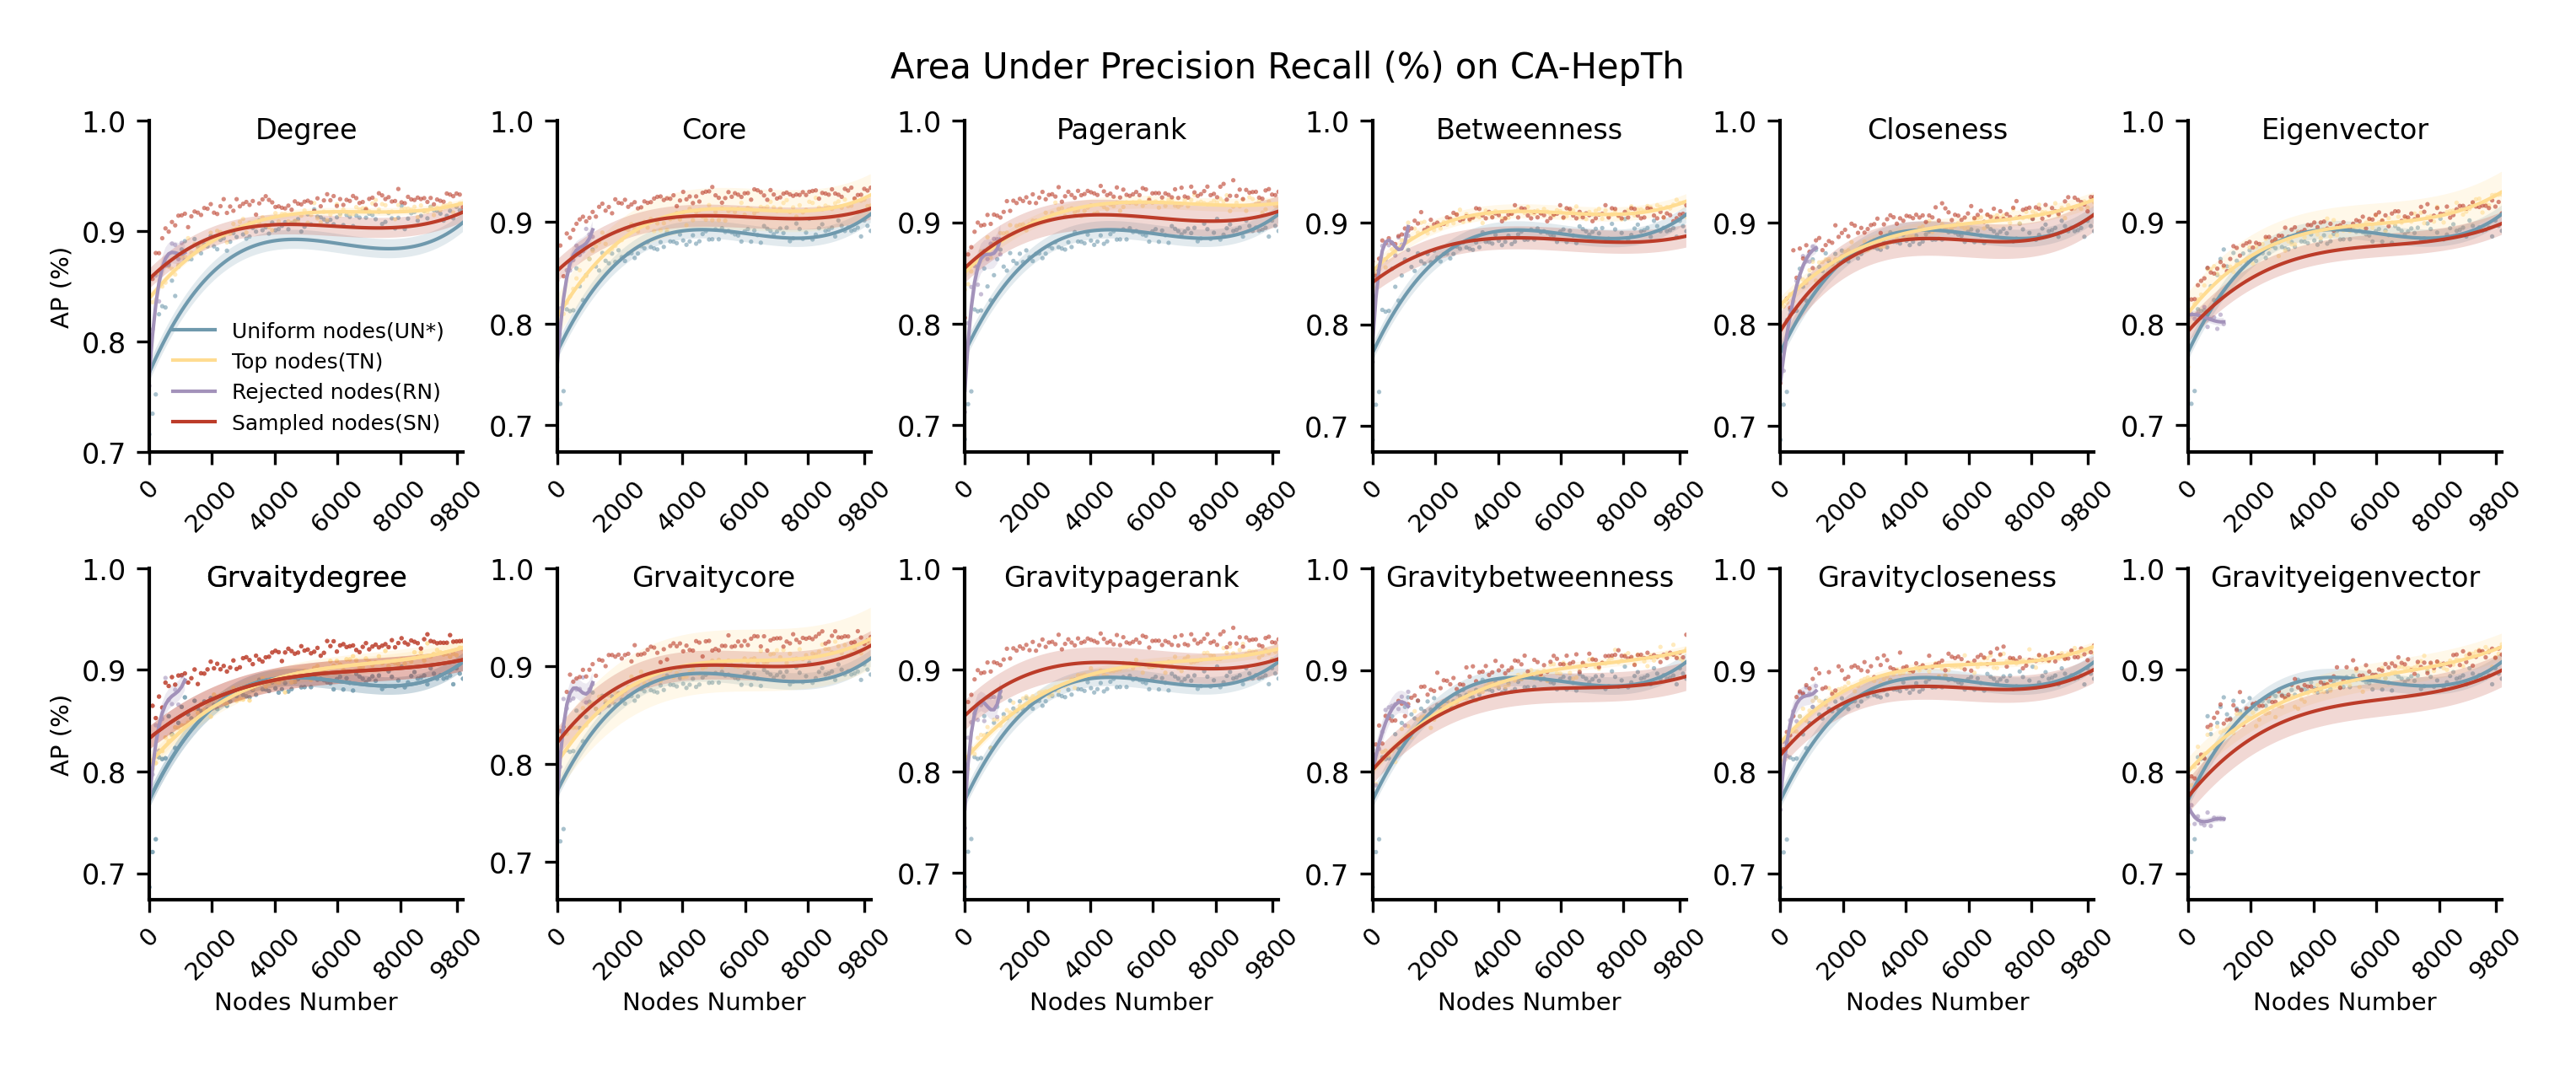

In [57]:

plt.style.use('nature')
from scipy.optimize import curve_fit
from scipy.interpolate import UnivariateSpline


def cubic_fit(x, a, b, c, d):
    return a * x**3 + b * x**2 + c * x + d

x = np.linspace(0,1,98)

fig,axes = plt.subplots(2,6,figsize = (6,2),dpi=600)

params, covariance = curve_fit(cubic_fit, x, cath_uniform[:98,0])
a_fit, b_fit, c_fit, d_fit = params
cath_uniform1 = cubic_fit(x, a_fit, b_fit, c_fit, d_fit)
axes[0,0].plot(x,cath_uniform1,color ='#6F99ADFF', label = 'Uniform nodes(UN*)',linewidth=0.5)
axes[0,0].scatter(x, cath_uniform[:98,1],color ='#6F99ADFF',edgecolors='none', s=0.4, alpha=0.6)
distances = np.abs(cath_uniform[:98, 1] - cath_uniform1)
spline = UnivariateSpline(np.arange(len(distances)), distances.flatten(), s=0)
smooth_distances = spline(np.arange(len(distances)))
smooth_distances_mean = np.mean([np.min(smooth_distances), np.max(smooth_distances)])* 1 /4
axes[0,0].fill_between(x, cath_uniform1-smooth_distances_mean, cath_uniform1+smooth_distances_mean, color='#6F99ADFF', alpha=0.2,edgecolors='none')
params, covariance = curve_fit(cubic_fit, x, cath_degree[:98, 3])
a_fit, b_fit, c_fit, d_fit = params
cath_degree_fit = cubic_fit(x, a_fit, b_fit, c_fit, d_fit)
axes[0,0].plot(x, cath_degree_fit, color='#FFDC91FF', label='Top nodes(TN)', linewidth=0.5)
axes[0,0].scatter(x, cath_degree[:98, 3], color ='#FFDC91FF',edgecolors='none', s=0.4, alpha=0.6)
distances = np.abs(cath_degree[:98, 3] - cath_degree_fit)
spline = UnivariateSpline(np.arange(len(distances)), distances.flatten(), s=0)
smooth_distances = spline(np.arange(len(distances)))
smooth_distances_mean = np.mean([np.min(smooth_distances), np.max(smooth_distances)]) * 1 / 4
axes[0,0].fill_between(x, cath_degree_fit - smooth_distances_mean, cath_degree_fit + smooth_distances_mean, color='#FFDC91FF', alpha=0.2,edgecolors='none')

axes[0,0].tick_params(labelsize=4)

axes[0,0].set_xticks([0,0.12,0.35,0.7,1])
axes[0,0].set_xticklabels(np.array([0, 300,980, 2000, 2700]).astype(int))

axes[0,0].grid (False)
axes[0,0].spines['top'].set_visible(False)
axes[0,0].spines['right'].set_visible(False)
axes[0,0].xaxis.set_ticks_position('bottom')
axes[0,0].yaxis.set_ticks_position('left')
axes[0,0].set_yticks(np.linspace(0.6, 1, 5))
axes[0,0].set_yticks([0.6, 0.7, 0.8, 0.9,1])
axes[0,0].set_xticks([], minor=True)
axes[0,0].set_yticks([], minor=True)
axes[0,0].tick_params(axis='both', which='both', length=1.2)
axes[0,0].text(0.5, 0.97, 'Degree', transform=axes[0,0].transAxes, ha='center', va='center', bbox=dict(facecolor='none', edgecolor='none', boxstyle='round', alpha=0.0), fontsize=4)



params, covariance = curve_fit(cubic_fit, x, cath_uniform[:98,0])
a_fit, b_fit, c_fit, d_fit = params
cath_uniform1 = cubic_fit(x, a_fit, b_fit, c_fit, d_fit)
axes[0,1].plot(x,cath_uniform1,color ='#6F99ADFF', label = 'uniform',linewidth=0.5)
axes[0,1].scatter(x, cath_uniform[:98,0],color ='#6F99ADFF',edgecolors='none', s=0.4, alpha=0.6)
distances = np.abs(cath_uniform[:98, 1] - cath_uniform1)
spline = UnivariateSpline(np.arange(len(distances)), distances.flatten(), s=0)
smooth_distances = spline(np.arange(len(distances)))
smooth_distances_mean = np.mean([np.min(smooth_distances), np.max(smooth_distances)])* 1 /4
axes[0,1].fill_between(x, cath_uniform1-smooth_distances_mean, cath_uniform1+smooth_distances_mean, color='#6F99ADFF', alpha=0.2,edgecolors='none')
params, covariance = curve_fit(cubic_fit, x, cath_core[:98, 3])
a_fit, b_fit, c_fit, d_fit = params
cath_core_fit = cubic_fit(x, a_fit, b_fit, c_fit, d_fit)
axes[0,1].plot(x, cath_core_fit, color='#FFDC91FF', label='Top Nodes', linewidth=0.5)
axes[0,1].scatter(x, cath_core[:98, 3], color ='#FFDC91FF',edgecolors='none', s=0.4, alpha=0.6)
distances = np.abs(cath_core[:98, 3] - cath_core_fit)
spline = UnivariateSpline(np.arange(len(distances)), distances.flatten(), s=0)
smooth_distances = spline(np.arange(len(distances)))
smooth_distances_mean = np.mean([np.min(smooth_distances), np.max(smooth_distances)]) * 3 / 4
axes[0,1].fill_between(x, cath_core_fit - smooth_distances_mean, cath_core_fit + smooth_distances_mean, color='#FFDC91FF', alpha=0.2,edgecolors='none')

axes[0,1].tick_params(labelsize=4)
axes[0,1].set_xticks([0,0.12,0.35,0.7,1])
axes[0,1].set_xticklabels(np.array([0, 300,980, 2000, 2700]).astype(int))
#axes[0,1].legend(fontsize=3,edgecolor='black',framealpha=0.1,loc='center right')
axes[0,1].grid (False)
axes[0,1].spines['top'].set_visible(False)
axes[0,1].spines['right'].set_visible(False)
axes[0,1].xaxis.set_ticks_position('bottom')
axes[0,1].yaxis.set_ticks_position('left')
axes[0,1].set_yticks(np.linspace(0.6, 1, 5))
axes[0,1].set_yticks([0.6, 0.7, 0.8, 0.9,1])
axes[0,1].set_xticks([], minor=True)
axes[0,1].set_yticks([], minor=True)
axes[0,1].tick_params(axis='both', which='both', length=1.2)
axes[0,1].text(0.5, 0.97, 'Core', transform=axes[0,1].transAxes, ha='center', va='center', bbox=dict(facecolor='none', edgecolor='none', boxstyle='round', alpha=0.0), fontsize=4)



params, covariance = curve_fit(cubic_fit, x, cath_uniform[:98,0])
a_fit, b_fit, c_fit, d_fit = params
cath_uniform1 = cubic_fit(x, a_fit, b_fit, c_fit, d_fit)
axes[0,2].plot(x,cath_uniform1,color ='#6F99ADFF', label = 'uniform',linewidth=0.5)
axes[0,2].scatter(x, cath_uniform[:98,0],color ='#6F99ADFF',edgecolors='none', s=0.4, alpha=0.6)
distances = np.abs(cath_uniform[:98, 1] - cath_uniform1)
spline = UnivariateSpline(np.arange(len(distances)), distances.flatten(), s=0)
smooth_distances = spline(np.arange(len(distances)))
smooth_distances_mean = np.mean([np.min(smooth_distances), np.max(smooth_distances)])* 1 /4
axes[0,2].fill_between(x, cath_uniform1-smooth_distances_mean, cath_uniform1+smooth_distances_mean, color='#6F99ADFF', alpha=0.2,edgecolors='none')
params, covariance = curve_fit(cubic_fit, x, cath_pagerank[:98, 3])
a_fit, b_fit, c_fit, d_fit = params
cath_pagerank_fit = cubic_fit(x, a_fit, b_fit, c_fit, d_fit)
axes[0,2].plot(x, cath_pagerank_fit, color='#FFDC91FF', label='Top Nodes', linewidth=0.5)
axes[0,2].scatter(x, cath_pagerank[:98, 3], color ='#FFDC91FF',edgecolors='none', s=0.4, alpha=0.6)
distances = np.abs(cath_pagerank[:98, 3] - cath_pagerank_fit)
spline = UnivariateSpline(np.arange(len(distances)), distances.flatten(), s=0)
smooth_distances = spline(np.arange(len(distances)))
smooth_distances_mean = np.mean([np.min(smooth_distances), np.max(smooth_distances)]) * 3 / 4
axes[0,2].fill_between(x, cath_pagerank_fit - smooth_distances_mean, cath_pagerank_fit + smooth_distances_mean, color='#FFDC91FF', alpha=0.2,edgecolors='none')

axes[0,2].tick_params(labelsize=4)
axes[0,2].set_xticks([0,0.12,0.35,0.7,1])
axes[0,2].set_xticklabels(np.array([0, 300,980, 2000, 2700]).astype(int))
#axes[0,2].legend(fontsize=3,edgecolor='black',framealpha=0.1,loc='center right')
axes[0,2].grid (False)
axes[0,2].spines['top'].set_visible(False)
axes[0,2].spines['right'].set_visible(False)
axes[0,2].xaxis.set_ticks_position('bottom')
axes[0,2].yaxis.set_ticks_position('left')
axes[0,2].set_yticks(np.linspace(0.6, 1, 5))
axes[0,2].set_yticks([0.6, 0.7, 0.8, 0.9,1])
axes[0,2].set_xticks([], minor=True)
axes[0,2].set_yticks([], minor=True)
axes[0,2].tick_params(axis='both', which='both', length=1.2)
axes[0,2].text(0.5, 0.97, 'Pagerank', transform=axes[0,2].transAxes, ha='center', va='center', bbox=dict(facecolor='none', edgecolor='none', boxstyle='round', alpha=0.0), fontsize=4)

params, covariance = curve_fit(cubic_fit, x, cath_uniform[:98,0])
a_fit, b_fit, c_fit, d_fit = params
cath_uniform1 = cubic_fit(x, a_fit, b_fit, c_fit, d_fit)
axes[0,3].plot(x,cath_uniform1,color ='#6F99ADFF', label = 'uniform',linewidth=0.5)
axes[0,3].scatter(x, cath_uniform[:98,0],color ='#6F99ADFF',edgecolors='none', s=0.4, alpha=0.6)
distances = np.abs(cath_uniform[:98, 1] - cath_uniform1)
spline = UnivariateSpline(np.arange(len(distances)), distances.flatten(), s=0)
smooth_distances = spline(np.arange(len(distances)))
smooth_distances_mean = np.mean([np.min(smooth_distances), np.max(smooth_distances)])* 1 /4
axes[0,3].fill_between(x, cath_uniform1-smooth_distances_mean, cath_uniform1+smooth_distances_mean, color='#6F99ADFF', alpha=0.2,edgecolors='none')
params, covariance = curve_fit(cubic_fit, x, cath_betweenness[:98, 3])
a_fit, b_fit, c_fit, d_fit = params
cath_betweenness_fit = cubic_fit(x, a_fit, b_fit, c_fit, d_fit)
axes[0,3].plot(x, cath_betweenness_fit, color='#FFDC91FF', label='Top Nodes', linewidth=0.5)
axes[0,3].scatter(x, cath_betweenness[:98, 3], color ='#FFDC91FF',edgecolors='none', s=0.4, alpha=0.6)
distances = np.abs(cath_betweenness[:98, 3] - cath_betweenness_fit)
spline = UnivariateSpline(np.arange(len(distances)), distances.flatten(), s=0)
smooth_distances = spline(np.arange(len(distances)))
smooth_distances_mean = np.mean([np.min(smooth_distances), np.max(smooth_distances)]) * 3 / 4
axes[0,3].fill_between(x, cath_betweenness_fit - smooth_distances_mean, cath_betweenness_fit + smooth_distances_mean, color='#FFDC91FF', alpha=0.2,edgecolors='none')

axes[0,3].tick_params(labelsize=4)
axes[0,3].set_xticks([0,0.12,0.35,0.7,1])
axes[0,3].set_xticklabels(np.array([0, 300,980, 2000, 2700]).astype(int))
#axes[0,3].legend(fontsize=3,edgecolor='black',framealpha=0.1,loc='center right')
axes[0,3].grid (False)
axes[0,3].spines['top'].set_visible(False)
axes[0,3].spines['right'].set_visible(False)
axes[0,3].xaxis.set_ticks_position('bottom')
axes[0,3].yaxis.set_ticks_position('left')
axes[0,3].set_yticks(np.linspace(0.6, 1, 5))
axes[0,3].set_yticks([0.6, 0.7, 0.8, 0.9,1])
axes[0,3].set_xticks([], minor=True)
axes[0,3].set_yticks([], minor=True)
axes[0,3].tick_params(axis='both', which='both', length=1.2)
axes[0,3].text(0.5, 0.97, 'Betweenness', transform=axes[0,3].transAxes, ha='center', va='center', bbox=dict(facecolor='none', edgecolor='none', boxstyle='round', alpha=0.0), fontsize=4)


params, covariance = curve_fit(cubic_fit, x, cath_uniform[:98,0])
a_fit, b_fit, c_fit, d_fit = params
cath_uniform1 = cubic_fit(x, a_fit, b_fit, c_fit, d_fit)
axes[0,4].plot(x,cath_uniform1,color ='#6F99ADFF', label = 'uniform',linewidth=0.5)
axes[0,4].scatter(x, cath_uniform[:98,0],color ='#6F99ADFF',edgecolors='none', s=0.4, alpha=0.6)
distances = np.abs(cath_uniform[:98, 1] - cath_uniform1)
spline = UnivariateSpline(np.arange(len(distances)), distances.flatten(), s=0)
smooth_distances = spline(np.arange(len(distances)))
smooth_distances_mean = np.mean([np.min(smooth_distances), np.max(smooth_distances)])* 1 /4
axes[0,4].fill_between(x, cath_uniform1-smooth_distances_mean, cath_uniform1+smooth_distances_mean, color='#6F99ADFF', alpha=0.2,edgecolors='none')
params, covariance = curve_fit(cubic_fit, x, cath_closeness[:98, 3])
a_fit, b_fit, c_fit, d_fit = params
cath_closeness_fit = cubic_fit(x, a_fit, b_fit, c_fit, d_fit)
axes[0,4].plot(x, cath_closeness_fit, color='#FFDC91FF', label='Top Nodes', linewidth=0.5)
axes[0,4].scatter(x, cath_closeness[:98, 3], color ='#FFDC91FF',edgecolors='none', s=0.4, alpha=0.6)
distances = np.abs(cath_closeness[:98, 3] - cath_closeness_fit)
spline = UnivariateSpline(np.arange(len(distances)), distances.flatten(), s=0)
smooth_distances = spline(np.arange(len(distances)))
smooth_distances_mean = np.mean([np.min(smooth_distances), np.max(smooth_distances)]) * 3 / 4
axes[0,4].fill_between(x, cath_closeness_fit - smooth_distances_mean, cath_closeness_fit + smooth_distances_mean, color='#FFDC91FF', alpha=0.2,edgecolors='none')

axes[0,4].tick_params(labelsize=4)
axes[0,4].set_xticks([0,0.12,0.35,0.7,1])
axes[0,4].set_xticklabels(np.array([0, 300,980, 2000, 2700]).astype(int))
#axes[0,4].legend(fontsize=3,edgecolor='black',framealpha=0.1,loc='center right')
axes[0,4].grid (False)
axes[0,4].spines['top'].set_visible(False)
axes[0,4].spines['right'].set_visible(False)
axes[0,4].xaxis.set_ticks_position('bottom')
axes[0,4].yaxis.set_ticks_position('left')
axes[0,4].set_yticks(np.linspace(0.6, 1, 5))
axes[0,4].set_yticks([0.6, 0.7, 0.8, 0.9,1])
axes[0,4].set_xticks([], minor=True)
axes[0,4].set_yticks([], minor=True)
axes[0,4].tick_params(axis='both', which='both', length=1.2)
axes[0,4].text(0.5, 0.97, 'Closeness', transform=axes[0,4].transAxes, ha='center', va='center', bbox=dict(facecolor='none', edgecolor='none', boxstyle='round', alpha=0.0), fontsize=4)



params, covariance = curve_fit(cubic_fit, x, cath_uniform[:98,0])
a_fit, b_fit, c_fit, d_fit = params
cath_uniform1 = cubic_fit(x, a_fit, b_fit, c_fit, d_fit)
axes[0,5].plot(x,cath_uniform1,color ='#6F99ADFF', label = 'uniform',linewidth=0.5)
axes[0,5].scatter(x, cath_uniform[:98,0],color ='#6F99ADFF',edgecolors='none', s=0.4, alpha=0.6)
distances = np.abs(cath_uniform[:98, 1] - cath_uniform1)
spline = UnivariateSpline(np.arange(len(distances)), distances.flatten(), s=0)
smooth_distances = spline(np.arange(len(distances)))
smooth_distances_mean = np.mean([np.min(smooth_distances), np.max(smooth_distances)])* 1 /4
axes[0,5].fill_between(x, cath_uniform1-smooth_distances_mean, cath_uniform1+smooth_distances_mean, color='#6F99ADFF', alpha=0.2,edgecolors='none')
params, covariance = curve_fit(cubic_fit, x, cath_eigenvector[:98, 3])
a_fit, b_fit, c_fit, d_fit = params
cath_eigenvector_fit = cubic_fit(x, a_fit, b_fit, c_fit, d_fit)
axes[0,5].plot(x, cath_eigenvector_fit, color='#FFDC91FF', label='Top Nodes', linewidth=0.5)
axes[0,5].scatter(x, cath_eigenvector[:98, 3], color ='#FFDC91FF',edgecolors='none', s=0.4, alpha=0.6)
distances = np.abs(cath_eigenvector[:98, 3] - cath_eigenvector_fit)
spline = UnivariateSpline(np.arange(len(distances)), distances.flatten(), s=0)
smooth_distances = spline(np.arange(len(distances)))
smooth_distances_mean = np.mean([np.min(smooth_distances), np.max(smooth_distances)]) * 3 / 4
axes[0,5].fill_between(x, cath_eigenvector_fit - smooth_distances_mean, cath_eigenvector_fit + smooth_distances_mean, color='#FFDC91FF', alpha=0.2,edgecolors='none')

axes[0,5].tick_params(labelsize=4)
axes[0,5].set_xticks([0,0.12,0.35,0.7,1])
axes[0,5].set_xticklabels(np.array([0, 300,980, 2000, 2700]).astype(int))
#axes[0,5].legend(fontsize=3,edgecolor='black',framealpha=0.1,loc='center right')
axes[0,5].grid (False)
axes[0,5].spines['top'].set_visible(False)
axes[0,5].spines['right'].set_visible(False)
axes[0,5].xaxis.set_ticks_position('bottom')
axes[0,5].yaxis.set_ticks_position('left')
axes[0,5].set_yticks(np.linspace(0.6, 1, 5))
axes[0,5].set_yticks([0.6, 0.7, 0.8, 0.9,1])
axes[0,5].set_xticks([], minor=True)
axes[0,5].set_yticks([], minor=True)
axes[0,5].tick_params(axis='both', which='both', length=1.2)
axes[0,5].text(0.5, 0.97, 'Eigenvector', transform=axes[0,5].transAxes, ha='center', va='center', bbox=dict(facecolor='none', edgecolor='none', boxstyle='round', alpha=0.0), fontsize=4)





params, covariance = curve_fit(cubic_fit, x, cath_uniform[:98,0])
a_fit, b_fit, c_fit, d_fit = params
cath_uniform1 = cubic_fit(x, a_fit, b_fit, c_fit, d_fit)

params, covariance = curve_fit(cubic_fit, x, cath_uniform[:98,0])
a_fit, b_fit, c_fit, d_fit = params
cath_uniform1 = cubic_fit(x, a_fit, b_fit, c_fit, d_fit)
axes[1,0].plot(x,cath_uniform1,color ='#6F99ADFF', label = 'uniform',linewidth=0.5)
axes[1,0].scatter(x, cath_uniform[:98,0],color ='#6F99ADFF',edgecolors='none', s=0.4, alpha=0.6)
distances = np.abs(cath_uniform[:98, 1] - cath_uniform1)
spline = UnivariateSpline(np.arange(len(distances)), distances.flatten(), s=0)
smooth_distances = spline(np.arange(len(distances)))
smooth_distances_mean = np.mean([np.min(smooth_distances), np.max(smooth_distances)])* 1 /4
axes[1,0].fill_between(x, cath_uniform1-smooth_distances_mean, cath_uniform1+smooth_distances_mean, color='#6F99ADFF', alpha=0.2,edgecolors='none')
params, covariance = curve_fit(cubic_fit, x, cath_gravitydegree[:98, 3])
a_fit, b_fit, c_fit, d_fit = params
cath_gravitydegree_fit = cubic_fit(x, a_fit, b_fit, c_fit, d_fit)
axes[1,0].plot(x, cath_gravitydegree_fit, color='#FFDC91FF', label='Top Nodes', linewidth=0.5)
axes[1,0].scatter(x, cath_gravitydegree[:98, 3], color ='#FFDC91FF',edgecolors='none', s=0.4, alpha=0.6)
distances = np.abs(cath_gravitydegree[:98, 3] - cath_gravitydegree_fit)
spline = UnivariateSpline(np.arange(len(distances)), distances.flatten(), s=0)
smooth_distances = spline(np.arange(len(distances)))
smooth_distances_mean = np.mean([np.min(smooth_distances), np.max(smooth_distances)]) * 3 / 4
axes[1,0].fill_between(x, cath_gravitydegree_fit - smooth_distances_mean, cath_gravitydegree_fit + smooth_distances_mean, color='#FFDC91FF', alpha=0.2,edgecolors='none')

axes[1,0].tick_params(labelsize=4)
axes[1,0].set_xticks([0,0.12,0.35,0.7,1])
axes[1,0].set_xticklabels(np.array([0, 300,980, 2000, 2700]).astype(int))
axes[1,0].grid (False)
axes[1,0].spines['top'].set_visible(False)
axes[1,0].spines['right'].set_visible(False)
axes[1,0].xaxis.set_ticks_position('bottom')
axes[1,0].yaxis.set_ticks_position('left')
axes[1,0].set_yticks(np.linspace(0.6, 1, 5))
axes[1,0].set_yticks([0.6, 0.7, 0.8, 0.9,1])
axes[1,0].set_xticks([], minor=True)
axes[1,0].set_yticks([], minor=True)
axes[1,0].tick_params(axis='both', which='both', length=1.2)
axes[1,0].text(0.5, 0.97, 'Grvaitydegree', transform=axes[1,0].transAxes, ha='center', va='center', bbox=dict(facecolor='none', edgecolor='none', boxstyle='round', alpha=0.0), fontsize=4)


axes[1,0].plot(x,cath_uniform1,color ='#6F99ADFF', label = 'uniform',linewidth=0.5)
axes[1,0].scatter(x, cath_uniform[:98,0],color ='#6F99ADFF',edgecolors='none', s=0.4, alpha=0.6)
distances = np.abs(cath_uniform[:98, 1] - cath_uniform1)
spline = UnivariateSpline(np.arange(len(distances)), distances.flatten(), s=0)
smooth_distances = spline(np.arange(len(distances)))
smooth_distances_mean = np.mean([np.min(smooth_distances), np.max(smooth_distances)])* 1 /4
axes[1,0].fill_between(x, cath_uniform1-smooth_distances_mean, cath_uniform1+smooth_distances_mean, color='#6F99ADFF', alpha=0.2,edgecolors='none')
params, covariance = curve_fit(cubic_fit, x, cath_gravitydegree[:98, 3])
a_fit, b_fit, c_fit, d_fit = params
cath_gravitydegree_fit = cubic_fit(x, a_fit, b_fit, c_fit, d_fit)
axes[1,0].plot(x, cath_gravitydegree_fit, color='#FFDC91FF', label='Top Nodes', linewidth=0.5)
axes[1,0].scatter(x, cath_gravitydegree[:98, 3], color ='#FFDC91FF',edgecolors='none', s=0.4, alpha=0.6)
distances = np.abs(cath_gravitydegree[:98, 3] - cath_gravitydegree_fit)
spline = UnivariateSpline(np.arange(len(distances)), distances.flatten(), s=0)
smooth_distances = spline(np.arange(len(distances)))
smooth_distances_mean = np.mean([np.min(smooth_distances), np.max(smooth_distances)]) * 2 / 4
axes[1,0].fill_between(x, cath_gravitydegree_fit - smooth_distances_mean, cath_gravitydegree_fit + smooth_distances_mean, color='#FFDC91FF', alpha=0.2,edgecolors='none')
params, covariance = curve_fit(cubic_fit, x, cath_gravitydegree[:98,0])
a_fit, b_fit, c_fit, d_fit = params
cath_gravitydegree_fit = cubic_fit(x, a_fit, b_fit, c_fit, d_fit)
axes[1,0].plot(x, cath_gravitydegree_fit, color='#BC3C29FF', label='Sampled Nodes', linewidth=0.5)
axes[1,0].scatter(x, cath_gravitydegree[:98, 1], color ='#BC3C29FF',edgecolors='none', s=0.4, alpha=0.6)
distances = np.abs(cath_gravitydegree[:98, 1] - cath_gravitydegree_fit)
spline = UnivariateSpline(np.arange(len(distances)), distances.flatten(), s=0)
smooth_distances = spline(np.arange(len(distances)))
smooth_distances_mean = np.mean([np.min(smooth_distances), np.max(smooth_distances)]) * 2 / 4
axes[1,0].fill_between(x, cath_gravitydegree_fit - smooth_distances_mean, cath_gravitydegree_fit + smooth_distances_mean, color='#BC3C29FF', alpha=0.2,edgecolors='none')
axes[1,0].tick_params(labelsize=4)
axes[1,0].set_xticks([0,0.12,0.35,0.7,1])
axes[1,0].set_xticklabels(np.array([0, 300,980, 2000, 2700]).astype(int))
#axes[1,0].legend(fontsize=3,edgecolor='black',framealpha=0.1,loc='center right')
axes[1,0].grid (False)
axes[1,0].spines['top'].set_visible(False)
axes[1,0].spines['right'].set_visible(False)
axes[1,0].xaxis.set_ticks_position('bottom')
axes[1,0].yaxis.set_ticks_position('left')
axes[1,0].set_yticks(np.linspace(0.6, 1, 5))
axes[1,0].set_yticks([0.6, 0.7, 0.8, 0.9,1])
axes[1,0].set_xticks([], minor=True)
axes[1,0].set_yticks([], minor=True)
axes[1,0].tick_params(axis='both', which='both', length=1.2)
axes[1,0].text(0.5, 0.97, 'Grvaitydegree', transform=axes[1,0].transAxes, ha='center', va='center', bbox=dict(facecolor='none', edgecolor='none', boxstyle='round', alpha=0.0), fontsize=4)



params, covariance = curve_fit(cubic_fit, x, cath_uniform[:98,0])
a_fit, b_fit, c_fit, d_fit = params
cath_uniform1 = cubic_fit(x, a_fit, b_fit, c_fit, d_fit)
axes[1,1].plot(x,cath_uniform1,color ='#6F99ADFF', label = 'uniform',linewidth=0.5)
axes[1,1].scatter(x, cath_uniform[:98,0],color ='#6F99ADFF',edgecolors='none', s=0.4, alpha=0.6)
distances = np.abs(cath_uniform[:98, 1] - cath_uniform1)
spline = UnivariateSpline(np.arange(len(distances)), distances.flatten(), s=0)
smooth_distances = spline(np.arange(len(distances)))
smooth_distances_mean = np.mean([np.min(smooth_distances), np.max(smooth_distances)])* 1 /4
axes[1,1].fill_between(x, cath_uniform1-smooth_distances_mean, cath_uniform1+smooth_distances_mean, color='#6F99ADFF', alpha=0.2,edgecolors='none')
params, covariance = curve_fit(cubic_fit, x, cath_gravitycore[:98, 3])
a_fit, b_fit, c_fit, d_fit = params
cath_gravitycore_fit = cubic_fit(x, a_fit, b_fit, c_fit, d_fit)
axes[1,1].plot(x, cath_gravitycore_fit, color='#FFDC91FF', label='Top Nodes', linewidth=0.5)
axes[1,1].scatter(x, cath_gravitycore[:98, 3], color ='#FFDC91FF',edgecolors='none', s=0.4, alpha=0.6)
distances = np.abs(cath_gravitycore[:98, 3] - cath_gravitycore_fit)
spline = UnivariateSpline(np.arange(len(distances)), distances.flatten(), s=0)
smooth_distances = spline(np.arange(len(distances)))
smooth_distances_mean = np.mean([np.min(smooth_distances), np.max(smooth_distances)]) *2 / 4
axes[1,1].fill_between(x, cath_gravitycore_fit - smooth_distances_mean, cath_gravitycore_fit + smooth_distances_mean, color='#FFDC91FF', alpha=0.2,edgecolors='none')

axes[1,1].tick_params(labelsize=4)
axes[1,1].set_xticks([0,0.12,0.35,0.7,1])
axes[1,1].set_xticklabels(np.array([0, 300,980, 2000, 2700]).astype(int))
#axes[1,1].legend(fontsize=3,edgecolor='black',framealpha=0.1,loc='center right')
axes[1,1].grid (False)
axes[1,1].spines['top'].set_visible(False)
axes[1,1].spines['right'].set_visible(False)
axes[1,1].xaxis.set_ticks_position('bottom')
axes[1,1].yaxis.set_ticks_position('left')
axes[1,1].set_yticks(np.linspace(0.6, 1, 5))
axes[1,1].set_yticks([0.6, 0.7, 0.8, 0.9,1])
axes[1,1].set_xticks([], minor=True)
axes[1,1].set_yticks([], minor=True)
axes[1,1].tick_params(axis='both', which='both', length=1.2)
axes[1,1].text(0.5, 0.97, 'Grvaitycore', transform=axes[1,1].transAxes, ha='center', va='center', bbox=dict(facecolor='none', edgecolor='none', boxstyle='round', alpha=0.0), fontsize=4)








params, covariance = curve_fit(cubic_fit, x, cath_uniform[:98,0])
a_fit, b_fit, c_fit, d_fit = params
cath_uniform1 = cubic_fit(x, a_fit, b_fit, c_fit, d_fit)
axes[1,2].plot(x,cath_uniform1,color ='#6F99ADFF', label = 'uniform',linewidth=0.5)
axes[1,2].scatter(x, cath_uniform[:98,0],color ='#6F99ADFF',edgecolors='none', s=0.4, alpha=0.6)
distances = np.abs(cath_uniform[:98, 1] - cath_uniform1)
spline = UnivariateSpline(np.arange(len(distances)), distances.flatten(), s=0)
smooth_distances = spline(np.arange(len(distances)))
smooth_distances_mean = np.mean([np.min(smooth_distances), np.max(smooth_distances)])* 1 /4
axes[1,2].fill_between(x, cath_uniform1-smooth_distances_mean, cath_uniform1+smooth_distances_mean, color='#6F99ADFF', alpha=0.2,edgecolors='none')
params, covariance = curve_fit(cubic_fit, x, cath_gravitypagerank[:98, 3])
a_fit, b_fit, c_fit, d_fit = params
cath_gravitypagerank_fit = cubic_fit(x, a_fit, b_fit, c_fit, d_fit)
axes[1,2].plot(x, cath_gravitypagerank_fit, color='#FFDC91FF', label='Top Nodes', linewidth=0.5)
axes[1,2].scatter(x, cath_gravitypagerank[:98, 3], color ='#FFDC91FF',edgecolors='none', s=0.4, alpha=0.6)
distances = np.abs(cath_gravitypagerank[:98, 3] - cath_gravitypagerank_fit)
spline = UnivariateSpline(np.arange(len(distances)), distances.flatten(), s=0)
smooth_distances = spline(np.arange(len(distances)))
smooth_distances_mean = np.mean([np.min(smooth_distances), np.max(smooth_distances)]) * 2 / 4
axes[1,2].fill_between(x, cath_gravitypagerank_fit - smooth_distances_mean, cath_gravitypagerank_fit + smooth_distances_mean, color='#FFDC91FF', alpha=0.2,edgecolors='none')
axes[1,2].tick_params(labelsize=4)
axes[1,2].set_xticks([0,0.12,0.35,0.7,1])
axes[1,2].set_xticklabels(np.array([0, 300,980, 2000, 2700]).astype(int))
#axes[1,2].legend(fontsize=3,edgecolor='black',framealpha=0.1,loc='center right')
axes[1,2].grid (False)
axes[1,2].spines['top'].set_visible(False)
axes[1,2].spines['right'].set_visible(False)
axes[1,2].xaxis.set_ticks_position('bottom')
axes[1,2].yaxis.set_ticks_position('left')
axes[1,2].set_yticks(np.linspace(0.6, 1, 5))
axes[1,2].set_yticks([0.6, 0.7, 0.8, 0.9,1])
axes[1,2].set_xticks([], minor=True)
axes[1,2].set_yticks([], minor=True)
axes[1,2].tick_params(axis='both', which='both', length=1.2)
axes[1,2].text(0.5, 0.97, 'Gravitypagerank', transform=axes[1,2].transAxes, ha='center', va='center', bbox=dict(facecolor='none', edgecolor='none', boxstyle='round', alpha=0.0), fontsize=4)




params, covariance = curve_fit(cubic_fit, x, cath_uniform[:98,0])
a_fit, b_fit, c_fit, d_fit = params
cath_uniform1 = cubic_fit(x, a_fit, b_fit, c_fit, d_fit)
axes[1,3].plot(x,cath_uniform1,color ='#6F99ADFF', label = 'uniform',linewidth=0.5)
axes[1,3].scatter(x, cath_uniform[:98,0],color ='#6F99ADFF',edgecolors='none', s=0.4, alpha=0.6)
distances = np.abs(cath_uniform[:98, 1] - cath_uniform1)
spline = UnivariateSpline(np.arange(len(distances)), distances.flatten(), s=0)
smooth_distances = spline(np.arange(len(distances)))
smooth_distances_mean = np.mean([np.min(smooth_distances), np.max(smooth_distances)])* 1 /4
axes[1,3].fill_between(x, cath_uniform1-smooth_distances_mean, cath_uniform1+smooth_distances_mean, color='#6F99ADFF', alpha=0.2,edgecolors='none')
params, covariance = curve_fit(cubic_fit, x, cath_gravitybetweenness[:98, 3])
a_fit, b_fit, c_fit, d_fit = params
cath_gravitybetweenness_fit = cubic_fit(x, a_fit, b_fit, c_fit, d_fit)
axes[1,3].plot(x, cath_gravitybetweenness_fit, color='#FFDC91FF', label='Top Nodes', linewidth=0.5)
axes[1,3].scatter(x, cath_gravitybetweenness[:98, 3], color ='#FFDC91FF',edgecolors='none', s=0.4, alpha=0.6)
distances = np.abs(cath_gravitybetweenness[:98, 3] - cath_gravitybetweenness_fit)
spline = UnivariateSpline(np.arange(len(distances)), distances.flatten(), s=0)
smooth_distances = spline(np.arange(len(distances)))
smooth_distances_mean = np.mean([np.min(smooth_distances), np.max(smooth_distances)]) * 2 / 4
axes[1,3].fill_between(x, cath_gravitybetweenness_fit - smooth_distances_mean, cath_gravitybetweenness_fit + smooth_distances_mean, color='#FFDC91FF', alpha=0.2,edgecolors='none')
axes[1,3].tick_params(labelsize=4)
axes[1,3].set_xticks([0,0.12,0.35,0.7,1])
axes[1,3].set_xticklabels(np.array([0, 300,980, 2000, 2700]).astype(int))
#axes[1,3].legend(fontsize=3,edgecolor='black',framealpha=0.1,loc='center right')
axes[1,3].grid (False)
axes[1,3].spines['top'].set_visible(False)
axes[1,3].spines['right'].set_visible(False)
axes[1,3].xaxis.set_ticks_position('bottom')
axes[1,3].yaxis.set_ticks_position('left')
axes[1,3].set_yticks(np.linspace(0.6, 1, 5))
axes[1,3].set_yticks([0.6, 0.7, 0.8, 0.9,1])
axes[1,3].set_xticks([], minor=True)
axes[1,3].set_yticks([], minor=True)
axes[1,3].tick_params(axis='both', which='both', length=1.2)
axes[1,3].text(0.5, 0.97, 'Gravitybetweenness', transform=axes[1,3].transAxes, ha='center', va='center', bbox=dict(facecolor='none', edgecolor='none', boxstyle='round', alpha=0.0), fontsize=4)






params, covariance = curve_fit(cubic_fit, x, cath_uniform[:98,0])
a_fit, b_fit, c_fit, d_fit = params
cath_uniform1 = cubic_fit(x, a_fit, b_fit, c_fit, d_fit)
axes[1,4].plot(x,cath_uniform1,color ='#6F99ADFF', label = 'uniform',linewidth=0.5)
axes[1,4].scatter(x, cath_uniform[:98,0],color ='#6F99ADFF',edgecolors='none', s=0.4, alpha=0.6)
distances = np.abs(cath_uniform[:98, 1] - cath_uniform1)
spline = UnivariateSpline(np.arange(len(distances)), distances.flatten(), s=0)
smooth_distances = spline(np.arange(len(distances)))
smooth_distances_mean = np.mean([np.min(smooth_distances), np.max(smooth_distances)])* 1 /4
axes[1,4].fill_between(x, cath_uniform1-smooth_distances_mean, cath_uniform1+smooth_distances_mean, color='#6F99ADFF', alpha=0.2,edgecolors='none')
params, covariance = curve_fit(cubic_fit, x, cath_gravitycloseness[:98, 3])
a_fit, b_fit, c_fit, d_fit = params
cath_gravitycloseness_fit = cubic_fit(x, a_fit, b_fit, c_fit, d_fit)
axes[1,4].plot(x, cath_gravitycloseness_fit, color='#FFDC91FF', label='Top Nodes', linewidth=0.5)
axes[1,4].scatter(x, cath_gravitycloseness[:98, 3], color ='#FFDC91FF',edgecolors='none', s=0.4, alpha=0.6)
distances = np.abs(cath_gravitycloseness[:98, 3] - cath_gravitycloseness_fit)
spline = UnivariateSpline(np.arange(len(distances)), distances.flatten(), s=0)
smooth_distances = spline(np.arange(len(distances)))
smooth_distances_mean = np.mean([np.min(smooth_distances), np.max(smooth_distances)]) * 2 / 4
axes[1,4].fill_between(x, cath_gravitycloseness_fit - smooth_distances_mean, cath_gravitycloseness_fit + smooth_distances_mean, color='#FFDC91FF', alpha=0.2,edgecolors='none')
axes[1,4].tick_params(labelsize=4)
axes[1,4].set_xticks([0,0.12,0.35,0.7,1])
axes[1,4].set_xticklabels(np.array([0, 300,980, 2000, 2700]).astype(int))
#axes[1,4].legend(fontsize=3,edgecolor='black',framealpha=0.1,loc='center right')
axes[1,4].grid (False)
axes[1,4].spines['top'].set_visible(False)
axes[1,4].spines['right'].set_visible(False)
axes[1,4].xaxis.set_ticks_position('bottom')
axes[1,4].yaxis.set_ticks_position('left')
axes[1,4].set_yticks(np.linspace(0.6, 1, 5))
axes[1,4].set_yticks([0.6, 0.7, 0.8, 0.9,1])
axes[1,4].set_xticks([], minor=True)
axes[1,4].set_yticks([], minor=True)
axes[1,4].tick_params(axis='both', which='both', length=1.2)
axes[1,4].text(0.5, 0.97, 'Gravitycloseness', transform=axes[1,4].transAxes, ha='center', va='center', bbox=dict(facecolor='none', edgecolor='none', boxstyle='round', alpha=0.0), fontsize=4)








params, covariance = curve_fit(cubic_fit, x, cath_uniform[:98,0])
a_fit, b_fit, c_fit, d_fit = params
cath_uniform1 = cubic_fit(x, a_fit, b_fit, c_fit, d_fit)
axes[1,5].plot(x,cath_uniform1,color ='#6F99ADFF', label = 'uniform',linewidth=0.5)
axes[1,5].scatter(x, cath_uniform[:98,0],color ='#6F99ADFF',edgecolors='none', s=0.4, alpha=0.6)
distances = np.abs(cath_uniform[:98, 1] - cath_uniform1)
spline = UnivariateSpline(np.arange(len(distances)), distances.flatten(), s=0)
smooth_distances = spline(np.arange(len(distances)))
smooth_distances_mean = np.mean([np.min(smooth_distances), np.max(smooth_distances)])* 1 /4
axes[1,5].fill_between(x, cath_uniform1-smooth_distances_mean, cath_uniform1+smooth_distances_mean, color='#6F99ADFF', alpha=0.2,edgecolors='none')
params, covariance = curve_fit(cubic_fit, x, cath_gravityeigenvector[:98, 3])
a_fit, b_fit, c_fit, d_fit = params
cath_gravityeigenvector_fit = cubic_fit(x, a_fit, b_fit, c_fit, d_fit)
axes[1,5].plot(x, cath_gravityeigenvector_fit, color='#FFDC91FF', label='Top Nodes', linewidth=0.5)
axes[1,5].scatter(x, cath_gravityeigenvector[:98, 3], color ='#FFDC91FF',edgecolors='none', s=0.4, alpha=0.6)
distances = np.abs(cath_gravityeigenvector[:98, 3] - cath_gravityeigenvector_fit)
spline = UnivariateSpline(np.arange(len(distances)), distances.flatten(), s=0)
smooth_distances = spline(np.arange(len(distances)))
smooth_distances_mean = np.mean([np.min(smooth_distances), np.max(smooth_distances)]) * 2 / 4
axes[1,5].fill_between(x, cath_gravityeigenvector_fit - smooth_distances_mean, cath_gravityeigenvector_fit + smooth_distances_mean, color='#FFDC91FF', alpha=0.2,edgecolors='none')
axes[1,5].tick_params(labelsize=4)
axes[1,5].set_xticks([0,0.12,0.35,0.7,1])
axes[1,5].set_xticklabels(np.array([0, 300,980, 2000, 2700]).astype(int))
#axes[1,5].legend(fontsize=3,edgecolor='black',framealpha=0.1,loc='center right')
axes[1,5].grid (False)
axes[1,5].spines['top'].set_visible(False)
axes[1,5].spines['right'].set_visible(False)
axes[1,5].xaxis.set_ticks_position('bottom')
axes[1,5].yaxis.set_ticks_position('left')
axes[1,5].set_yticks(np.linspace(0.6, 1, 5))
axes[1,5].set_yticks([0.6, 0.7, 0.8, 0.9,1])
axes[1,5].set_xticks([], minor=True)
axes[1,5].set_yticks([], minor=True)
axes[1,5].tick_params(axis='both', which='both', length=1.2)
axes[1,5].text(0.5, 0.97, 'Gravityeigenvector', transform=axes[1,5].transAxes, ha='center', va='center', bbox=dict(facecolor='none', edgecolor='none', boxstyle='round', alpha=0.0), fontsize=4)







y = np.linspace(0,1,66)
params, covariance = curve_fit(cubic_fit, x[:12], cath_degree_rn['mean_ap'].values[:12])
a_fit, b_fit, c_fit, d_fit = params
cath_degree_fit = cubic_fit(x[:12], a_fit, b_fit, c_fit, d_fit)
axes[0,0].plot(x[:12], cath_degree_fit, color='#A392BA', label='Rejected nodes(RN)', linewidth=0.5)
axes[0,0].scatter(x[:12], cath_degree_rn['mean_ap'].values[:12], color ='#A392BA',edgecolors='none', s=0.4, alpha=0.6)
distances = np.abs(cath_degree_rn['mean_ap'].values[:12] - cath_degree_fit)
spline = UnivariateSpline(np.arange(len(distances)), distances.flatten(), s=0)
smooth_distances = spline(np.arange(len(distances)))
smooth_distances_mean = np.mean([np.min(smooth_distances), np.max(smooth_distances)]) * 3 / 4
axes[0,0].fill_between(x[:12], cath_degree_fit - smooth_distances_mean, cath_degree_fit + smooth_distances_mean, color='#A392BA', alpha=0.2,edgecolors='none')

params, covariance = curve_fit(cubic_fit, x[:12], cath_core_rn['mean_ap'].values[:12])
a_fit, b_fit, c_fit, d_fit = params
cath_core_fit = cubic_fit(x[:12], a_fit, b_fit, c_fit, d_fit)
axes[0,1].plot(x[:12], cath_core_fit, color='#A392BA', label='Rejected nodes(RN)', linewidth=0.5)
axes[0,1].scatter(x[:12], cath_core_rn['mean_ap'].values[:12], color ='#A392BA',edgecolors='none', s=0.4, alpha=0.6)
distances = np.abs(cath_core_rn['mean_ap'].values[:12] - cath_core_fit)
spline = UnivariateSpline(np.arange(len(distances)), distances.flatten(), s=0)
smooth_distances = spline(np.arange(len(distances)))
smooth_distances_mean = np.mean([np.min(smooth_distances), np.max(smooth_distances)]) * 3 / 4
axes[0,1].fill_between(x[:12], cath_core_fit - smooth_distances_mean, cath_core_fit + smooth_distances_mean, color='#A392BA', alpha=0.2,edgecolors='none')



params, covariance = curve_fit(cubic_fit, x[:12], cath_pagerank_rn['mean_ap'].values[:12])
a_fit, b_fit, c_fit, d_fit = params
cath_pagerank_fit = cubic_fit(x[:12], a_fit, b_fit, c_fit, d_fit)
axes[0,2].plot(x[:12], cath_pagerank_fit, color='#A392BA', label='Rejected nodes(RN)', linewidth=0.5)
axes[0,2].scatter(x[:12], cath_pagerank_rn['mean_ap'].values[:12], color ='#A392BA',edgecolors='none', s=0.4, alpha=0.6)
distances = np.abs(cath_pagerank_rn['mean_ap'].values[:12] - cath_pagerank_fit)
spline = UnivariateSpline(np.arange(len(distances)), distances.flatten(), s=0)
smooth_distances = spline(np.arange(len(distances)))
smooth_distances_mean = np.mean([np.min(smooth_distances), np.max(smooth_distances)]) * 3 / 4
axes[0,2].fill_between(x[:12], cath_pagerank_fit - smooth_distances_mean, cath_pagerank_fit + smooth_distances_mean, color='#A392BA', alpha=0.2,edgecolors='none')





params, covariance = curve_fit(cubic_fit, x[:12], cath_betweenness_rn['mean_ap'].values[:12])
a_fit, b_fit, c_fit, d_fit = params
cath_betweenness_fit = cubic_fit(x[:12], a_fit, b_fit, c_fit, d_fit)
axes[0,3].plot(x[:12], cath_betweenness_fit, color='#A392BA', label='Rejected nodes(RN)', linewidth=0.5)
axes[0,3].scatter(x[:12], cath_betweenness_rn['mean_ap'].values[:12], color ='#A392BA',edgecolors='none', s=0.4, alpha=0.6)
distances = np.abs(cath_betweenness_rn['mean_ap'].values[:12] - cath_betweenness_fit)
spline = UnivariateSpline(np.arange(len(distances)), distances.flatten(), s=0)
smooth_distances = spline(np.arange(len(distances)))
smooth_distances_mean = np.mean([np.min(smooth_distances), np.max(smooth_distances)]) * 3 / 4



params, covariance = curve_fit(cubic_fit, x[:12], cath_closeness_rn['mean_ap'].values[:12])
a_fit, b_fit, c_fit, d_fit = params
cath_closeness_fit = cubic_fit(x[:12], a_fit, b_fit, c_fit, d_fit)
axes[0,4].plot(x[:12], cath_closeness_fit, color='#A392BA', label='Rejected nodes(RN)', linewidth=0.5)
axes[0,4].scatter(x[:12], cath_closeness_rn['mean_ap'].values[:12], color ='#A392BA',edgecolors='none', s=0.4, alpha=0.6)
distances = np.abs(cath_closeness_rn['mean_ap'].values[:12] - cath_closeness_fit)
spline = UnivariateSpline(np.arange(len(distances)), distances.flatten(), s=0)
smooth_distances = spline(np.arange(len(distances)))
smooth_distances_mean = np.mean([np.min(smooth_distances), np.max(smooth_distances)]) * 3 / 4
axes[0,4].fill_between(x[:12], cath_closeness_fit - smooth_distances_mean, cath_closeness_fit + smooth_distances_mean, color='#A392BA', alpha=0.2,edgecolors='none')


params, covariance = curve_fit(cubic_fit, x[:12], cath_eigenvector_rn['mean_ap'].values[:12])
a_fit, b_fit, c_fit, d_fit = params
cath_eigenvector_fit = cubic_fit(x[:12], a_fit, b_fit, c_fit, d_fit)
axes[0,5].plot(x[:12], cath_eigenvector_fit, color='#A392BA', label='Rejected nodes(RN)', linewidth=0.5)
axes[0,5].scatter(x[:12], cath_eigenvector_rn['mean_ap'].values[:12], color ='#A392BA',edgecolors='none', s=0.4, alpha=0.6)
distances = np.abs(cath_eigenvector_rn['mean_ap'].values[:12] - cath_eigenvector_fit)
spline = UnivariateSpline(np.arange(len(distances)), distances.flatten(), s=0)
smooth_distances = spline(np.arange(len(distances)))
smooth_distances_mean = np.mean([np.min(smooth_distances), np.max(smooth_distances)]) * 3 / 4
axes[0,5].fill_between(x[:12], cath_eigenvector_fit - smooth_distances_mean, cath_eigenvector_fit + smooth_distances_mean, color='#A392BA', alpha=0.2,edgecolors='none')



params, covariance = curve_fit(cubic_fit, x[:12], cath_gravitydegree_rn['mean_ap'].values[:12])
a_fit, b_fit, c_fit, d_fit = params
cath_gravitydegree_fit = cubic_fit(x[:12], a_fit, b_fit, c_fit, d_fit)
axes[1,0].plot(x[:12], cath_gravitydegree_fit, color='#A392BA', label='Rejected nodes(RN)', linewidth=0.5)
axes[1,0].scatter(x[:12], cath_gravitydegree_rn['mean_ap'].values[:12], color ='#A392BA',edgecolors='none', s=0.4, alpha=0.6)
distances = np.abs(cath_gravitydegree_rn['mean_ap'].values[:12] - cath_gravitydegree_fit)
spline = UnivariateSpline(np.arange(len(distances)), distances.flatten(), s=0)
smooth_distances = spline(np.arange(len(distances)))
smooth_distances_mean = np.mean([np.min(smooth_distances), np.max(smooth_distances)]) * 3 / 4
axes[1,0].fill_between(x[:12], cath_gravitydegree_fit - smooth_distances_mean, cath_gravitydegree_fit + smooth_distances_mean, color='#A392BA', alpha=0.2,edgecolors='none')



params, covariance = curve_fit(cubic_fit, x[:12], cath_gravitycore_rn['mean_ap'].values[:12])
a_fit, b_fit, c_fit, d_fit = params
cath_gravitycore_fit = cubic_fit(x[:12], a_fit, b_fit, c_fit, d_fit)
axes[1,1].plot(x[:12], cath_gravitycore_fit, color='#A392BA', label='Rejected nodes(RN)', linewidth=0.5)
axes[1,1].scatter(x[:12], cath_gravitycore_rn['mean_ap'].values[:12], color ='#A392BA',edgecolors='none', s=0.4, alpha=0.6)
distances =  np.abs(cath_gravitycore_rn['mean_ap'].values[:12] - cath_gravitycore_fit)
spline = UnivariateSpline(np.arange(len(distances)), distances.flatten(), s=0)
smooth_distances = spline(np.arange(len(distances)))
smooth_distances_mean = np.mean([np.min(smooth_distances), np.max(smooth_distances)]) * 3 / 4
axes[1,1].fill_between(x[:12], cath_gravitycore_fit - smooth_distances_mean, cath_gravitycore_fit + smooth_distances_mean, color='#A392BA', alpha=0.2,edgecolors='none')




params, covariance = curve_fit(cubic_fit, x[:12], cath_gravitypagerank_rn['mean_ap'].values[:12])
a_fit, b_fit, c_fit, d_fit = params
cath_gravitypagerank_fit = cubic_fit(x[:12], a_fit, b_fit, c_fit, d_fit)
axes[1,2].plot(x[:12], cath_gravitypagerank_fit, color='#A392BA', label='Rejected nodes(RN)', linewidth=0.5)
axes[1,2].scatter(x[:12], cath_gravitypagerank_rn['mean_ap'].values[:12], color ='#A392BA',edgecolors='none', s=0.4, alpha=0.6)
distances = np.abs(cath_gravitypagerank_rn['mean_ap'].values[:12] - cath_gravitypagerank_fit)
spline = UnivariateSpline(np.arange(len(distances)), distances.flatten(), s=0)
smooth_distances = spline(np.arange(len(distances)))
smooth_distances_mean = np.mean([np.min(smooth_distances), np.max(smooth_distances)]) * 3 / 4
axes[1,2].fill_between(x[:12], cath_gravitypagerank_fit - smooth_distances_mean, cath_gravitypagerank_fit + smooth_distances_mean, color='#A392BA', alpha=0.2,edgecolors='none')


params, covariance = curve_fit(cubic_fit, x[:12], cath_gravitybetweenness_rn['mean_ap'].values[:12])
a_fit, b_fit, c_fit, d_fit = params
cath_gravitybetweenness_fit = cubic_fit(x[:12], a_fit, b_fit, c_fit, d_fit)
axes[1,3].plot(x[:12], cath_gravitybetweenness_fit, color='#A392BA', label='Rejected nodes(RN)', linewidth=0.5)
axes[1,3].scatter(x[:12], cath_gravitybetweenness_rn['mean_ap'].values[:12], color ='#A392BA',edgecolors='none', s=0.4, alpha=0.6)
distances = np.abs(cath_gravitybetweenness_rn['mean_ap'].values[:12] - cath_gravitybetweenness_fit)
spline = UnivariateSpline(np.arange(len(distances)), distances.flatten(), s=0)
smooth_distances = spline(np.arange(len(distances)))
smooth_distances_mean = np.mean([np.min(smooth_distances), np.max(smooth_distances)]) * 3 / 4
axes[1,3].fill_between(x[:12], cath_gravitybetweenness_fit - smooth_distances_mean, cath_gravitybetweenness_fit + smooth_distances_mean, color='#A392BA', alpha=0.2,edgecolors='none')



params, covariance = curve_fit(cubic_fit, x[:12], cath_gravitycloseness_rn['mean_ap'].values[:12])
a_fit, b_fit, c_fit, d_fit = params
cath_gravitycloseness_fit = cubic_fit(x[:12], a_fit, b_fit, c_fit, d_fit)
axes[1,4].plot(x[:12], cath_gravitycloseness_fit, color='#A392BA', label='Rejected nodes(RN)', linewidth=0.5)
axes[1,4].scatter(x[:12], cath_gravitycloseness_rn['mean_ap'].values[:12], color ='#A392BA',edgecolors='none', s=0.4, alpha=0.6)
distances =  np.abs(cath_gravitycloseness_rn['mean_ap'].values[:12] - cath_gravitycloseness_fit)
spline = UnivariateSpline(np.arange(len(distances)), distances.flatten(), s=0)
smooth_distances = spline(np.arange(len(distances)))
smooth_distances_mean = np.mean([np.min(smooth_distances), np.max(smooth_distances)]) * 3 / 4
axes[1,4].fill_between(x[:12], cath_gravitycloseness_fit - smooth_distances_mean, cath_gravitycloseness_fit + smooth_distances_mean, color='#A392BA', alpha=0.2,edgecolors='none')


params, covariance = curve_fit(cubic_fit, x[:12], cath_gravityeigenvector_rn['mean_ap'].values[:12])
a_fit, b_fit, c_fit, d_fit = params
cath_gravityeigenvector_fit = cubic_fit(x[:12], a_fit, b_fit, c_fit, d_fit)
axes[1,5].plot(x[:12], cath_gravityeigenvector_fit, color='#A392BA', label='Rejected nodes(RN)', linewidth=0.5)
axes[1,5].scatter(x[:12], cath_gravityeigenvector_rn['mean_ap'].values[:12], color ='#A392BA',edgecolors='none', s=0.4, alpha=0.6)
distances = np.abs(cath_gravityeigenvector_rn['mean_ap'].values[:12] - cath_gravityeigenvector_fit)
spline = UnivariateSpline(np.arange(len(distances)), distances.flatten(), s=0)
smooth_distances = spline(np.arange(len(distances)))
smooth_distances_mean = np.mean([np.min(smooth_distances), np.max(smooth_distances)]) * 3 / 4
axes[1,5].fill_between(x[:12], cath_gravityeigenvector_fit - smooth_distances_mean, cath_gravityeigenvector_fit + smooth_distances_mean, color='#A392BA', alpha=0.2,edgecolors='none')


params, covariance = curve_fit(cubic_fit, x, cath_degree[:98,0])
a_fit, b_fit, c_fit, d_fit = params
cath_degree_fit = cubic_fit(x, a_fit, b_fit, c_fit, d_fit)
axes[0,0].plot(x, cath_degree_fit, color='#BC3C29FF', label='Sampled nodes(SN)', linewidth=0.5)
axes[0,0].scatter(x, cath_degree[:98, 1], color ='#BC3C29FF',edgecolors='none', s=0.4, alpha=0.6)
distances = np.abs(cath_degree[:98, 1] - cath_degree_fit)
spline = UnivariateSpline(np.arange(len(distances)), distances.flatten(), s=0)
smooth_distances = spline(np.arange(len(distances)))
smooth_distances_mean = np.mean([np.min(smooth_distances), np.max(smooth_distances)]) * 2 / 4
axes[0,0].fill_between(x, cath_degree_fit - smooth_distances_mean, cath_degree_fit + smooth_distances_mean, color='#BC3C29FF', alpha=0.2,edgecolors='none')

params, covariance = curve_fit(cubic_fit, x, cath_core[:98,0])
a_fit, b_fit, c_fit, d_fit = params
cath_core_fit = cubic_fit(x, a_fit, b_fit, c_fit, d_fit)
axes[0,1].plot(x, cath_core_fit, color='#BC3C29FF', label='Sampled Nodes', linewidth=0.5)
axes[0,1].scatter(x, cath_core[:98, 1], color ='#BC3C29FF',edgecolors='none', s=0.4, alpha=0.6)
distances = np.abs(cath_core[:98, 1] - cath_core_fit)
spline = UnivariateSpline(np.arange(len(distances)), distances.flatten(), s=0)
smooth_distances = spline(np.arange(len(distances)))
smooth_distances_mean = np.mean([np.min(smooth_distances), np.max(smooth_distances)]) * 2 / 4
axes[0,1].fill_between(x, cath_core_fit - smooth_distances_mean, cath_core_fit + smooth_distances_mean, color='#BC3C29FF', alpha=0.2,edgecolors='none')

params, covariance = curve_fit(cubic_fit, x, cath_pagerank[:98,0])
a_fit, b_fit, c_fit, d_fit = params
cath_pagerank_fit = cubic_fit(x, a_fit, b_fit, c_fit, d_fit)
axes[0,2].plot(x, cath_pagerank_fit, color='#BC3C29FF', label='Sampled Nodes', linewidth=0.5)
axes[0,2].scatter(x, cath_pagerank[:98, 1], color ='#BC3C29FF',edgecolors='none', s=0.4, alpha=0.6)
distances = np.abs(cath_pagerank[:98, 1] - cath_pagerank_fit)
spline = UnivariateSpline(np.arange(len(distances)), distances.flatten(), s=0)
smooth_distances = spline(np.arange(len(distances)))
smooth_distances_mean = np.mean([np.min(smooth_distances), np.max(smooth_distances)]) * 2 / 4
axes[0,2].fill_between(x, cath_pagerank_fit - smooth_distances_mean, cath_pagerank_fit + smooth_distances_mean, color='#BC3C29FF', alpha=0.2,edgecolors='none')

params, covariance = curve_fit(cubic_fit, x, cath_betweenness[:98,0])
a_fit, b_fit, c_fit, d_fit = params
cath_betweenness_fit = cubic_fit(x, a_fit, b_fit, c_fit, d_fit)
axes[0,3].plot(x, cath_betweenness_fit, color='#BC3C29FF', label='Sampled Nodes', linewidth=0.5)
axes[0,3].scatter(x, cath_betweenness[:98, 1], color ='#BC3C29FF',edgecolors='none', s=0.4, alpha=0.6)
distances = np.abs(cath_betweenness[:98, 1] - cath_betweenness_fit)
spline = UnivariateSpline(np.arange(len(distances)), distances.flatten(), s=0)
smooth_distances = spline(np.arange(len(distances)))
smooth_distances_mean = np.mean([np.min(smooth_distances), np.max(smooth_distances)]) * 2 / 4
axes[0,3].fill_between(x, cath_betweenness_fit - smooth_distances_mean, cath_betweenness_fit + smooth_distances_mean, color='#BC3C29FF', alpha=0.2,edgecolors='none')


params, covariance = curve_fit(cubic_fit, x, cath_closeness[:98,0])
a_fit, b_fit, c_fit, d_fit = params
cath_closeness_fit = cubic_fit(x, a_fit, b_fit, c_fit, d_fit)
axes[0,4].plot(x, cath_closeness_fit, color='#BC3C29FF', label='Sampled Nodes', linewidth=0.5)
axes[0,4].scatter(x, cath_closeness[:98, 1], color ='#BC3C29FF',edgecolors='none', s=0.4, alpha=0.6)
distances = np.abs(cath_closeness[:98, 1] - cath_closeness_fit)
spline = UnivariateSpline(np.arange(len(distances)), distances.flatten(), s=0)
smooth_distances = spline(np.arange(len(distances)))
smooth_distances_mean = np.mean([np.min(smooth_distances), np.max(smooth_distances)]) * 2 / 4
axes[0,4].fill_between(x, cath_closeness_fit - smooth_distances_mean, cath_closeness_fit + smooth_distances_mean, color='#BC3C29FF', alpha=0.2,edgecolors='none')

params, covariance = curve_fit(cubic_fit, x, cath_eigenvector[:98,0])
a_fit, b_fit, c_fit, d_fit = params
cath_eigenvector_fit = cubic_fit(x, a_fit, b_fit, c_fit, d_fit)
axes[0,5].plot(x, cath_eigenvector_fit, color='#BC3C29FF', label='Sampled Nodes', linewidth=0.5)
axes[0,5].scatter(x, cath_eigenvector[:98, 1], color ='#BC3C29FF',edgecolors='none', s=0.4, alpha=0.6)
distances = np.abs(cath_eigenvector[:98, 1] - cath_eigenvector_fit)
spline = UnivariateSpline(np.arange(len(distances)), distances.flatten(), s=0)
smooth_distances = spline(np.arange(len(distances)))
smooth_distances_mean = np.mean([np.min(smooth_distances), np.max(smooth_distances)]) * 2 / 4
axes[0,5].fill_between(x, cath_eigenvector_fit - smooth_distances_mean, cath_eigenvector_fit + smooth_distances_mean, color='#BC3C29FF', alpha=0.2,edgecolors='none')


params, covariance = curve_fit(cubic_fit, x, cath_gravitydegree[:98,0])
a_fit, b_fit, c_fit, d_fit = params
cath_gravitydegree_fit = cubic_fit(x, a_fit, b_fit, c_fit, d_fit)
axes[1,0].plot(x, cath_gravitydegree_fit, color='#BC3C29FF', label='Sampled Nodes', linewidth=0.5)
axes[1,0].scatter(x, cath_gravitydegree[:98, 1], color ='#BC3C29FF',edgecolors='none', s=0.4, alpha=0.6)
distances = np.abs(cath_gravitydegree[:98, 1] - cath_gravitydegree_fit)
spline = UnivariateSpline(np.arange(len(distances)), distances.flatten(), s=0)
smooth_distances = spline(np.arange(len(distances)))
smooth_distances_mean = np.mean([np.min(smooth_distances), np.max(smooth_distances)]) * 2 / 4
axes[1,0].fill_between(x, cath_gravitydegree_fit - smooth_distances_mean, cath_gravitydegree_fit + smooth_distances_mean, color='#BC3C29FF', alpha=0.2,edgecolors='none')

params, covariance = curve_fit(cubic_fit, x, cath_gravitycore[:98,0])
a_fit, b_fit, c_fit, d_fit = params
cath_gravitycore_fit = cubic_fit(x, a_fit, b_fit, c_fit, d_fit)
axes[1,1].plot(x, cath_gravitycore_fit, color='#BC3C29FF', label='Sampled Nodes', linewidth=0.5)
axes[1,1].scatter(x, cath_gravitycore[:98, 1], color ='#BC3C29FF',edgecolors='none', s=0.4, alpha=0.6)
distances = np.abs(cath_gravitycore[:98, 1] - cath_gravitycore_fit)
spline = UnivariateSpline(np.arange(len(distances)), distances.flatten(), s=0)
smooth_distances = spline(np.arange(len(distances)))
smooth_distances_mean = np.mean([np.min(smooth_distances), np.max(smooth_distances)]) * 2 / 4
axes[1,1].fill_between(x, cath_gravitycore_fit - smooth_distances_mean, cath_gravitycore_fit + smooth_distances_mean, color='#BC3C29FF', alpha=0.2,edgecolors='none')

params, covariance = curve_fit(cubic_fit, x, cath_gravitypagerank[:98,0])
a_fit, b_fit, c_fit, d_fit = params
cath_gravitypagerank_fit = cubic_fit(x, a_fit, b_fit, c_fit, d_fit)
axes[1,2].plot(x, cath_gravitypagerank_fit, color='#BC3C29FF', label='Sampled Nodes', linewidth=0.5)
axes[1,2].scatter(x, cath_gravitypagerank[:98, 1], color ='#BC3C29FF',edgecolors='none', s=0.4, alpha=0.6)
distances = np.abs(cath_gravitypagerank[:98, 1] - cath_gravitypagerank_fit)
spline = UnivariateSpline(np.arange(len(distances)), distances.flatten(), s=0)
smooth_distances = spline(np.arange(len(distances)))
smooth_distances_mean = np.mean([np.min(smooth_distances), np.max(smooth_distances)]) * 2 / 4
axes[1,2].fill_between(x, cath_gravitypagerank_fit - smooth_distances_mean, cath_gravitypagerank_fit + smooth_distances_mean, color='#BC3C29FF', alpha=0.2,edgecolors='none')

params, covariance = curve_fit(cubic_fit, x, cath_gravitybetweenness[:98,0])
a_fit, b_fit, c_fit, d_fit = params
cath_gravitybetweenness_fit = cubic_fit(x, a_fit, b_fit, c_fit, d_fit)
axes[1,3].plot(x, cath_gravitybetweenness_fit, color='#BC3C29FF', label='Sampled Nodes', linewidth=0.5)
axes[1,3].scatter(x, cath_gravitybetweenness[:98, 1], color ='#BC3C29FF',edgecolors='none', s=0.4, alpha=0.6)
distances = np.abs(cath_gravitybetweenness[:98, 1] - cath_gravitybetweenness_fit)
spline = UnivariateSpline(np.arange(len(distances)), distances.flatten(), s=0)
smooth_distances = spline(np.arange(len(distances)))
smooth_distances_mean = np.mean([np.min(smooth_distances), np.max(smooth_distances)]) * 2 / 4
axes[1,3].fill_between(x, cath_gravitybetweenness_fit - smooth_distances_mean, cath_gravitybetweenness_fit + smooth_distances_mean, color='#BC3C29FF', alpha=0.2,edgecolors='none')


params, covariance = curve_fit(cubic_fit, x, cath_gravitycloseness[:98,0])
a_fit, b_fit, c_fit, d_fit = params
cath_gravitycloseness_fit = cubic_fit(x, a_fit, b_fit, c_fit, d_fit)
axes[1,4].plot(x, cath_gravitycloseness_fit, color='#BC3C29FF', label='Sampled Nodes', linewidth=0.5)
axes[1,4].scatter(x, cath_gravitycloseness[:98, 1], color ='#BC3C29FF',edgecolors='none', s=0.4, alpha=0.6)
distances = np.abs(cath_gravitycloseness[:98, 1] - cath_gravitycloseness_fit)
spline = UnivariateSpline(np.arange(len(distances)), distances.flatten(), s=0)
smooth_distances = spline(np.arange(len(distances)))
smooth_distances_mean = np.mean([np.min(smooth_distances), np.max(smooth_distances)]) * 2 / 4
axes[1,4].fill_between(x, cath_gravitycloseness_fit - smooth_distances_mean, cath_gravitycloseness_fit + smooth_distances_mean, color='#BC3C29FF', alpha=0.2,edgecolors='none')

params, covariance = curve_fit(cubic_fit, x, cath_gravityeigenvector[:98,0])
a_fit, b_fit, c_fit, d_fit = params
cath_gravityeigenvector_fit = cubic_fit(x, a_fit, b_fit, c_fit, d_fit)
axes[1,5].plot(x, cath_gravityeigenvector_fit, color='#BC3C29FF', label='Sampled Nodes', linewidth=0.5)
axes[1,5].scatter(x, cath_gravityeigenvector[:98, 1], color ='#BC3C29FF',edgecolors='none', s=0.4, alpha=0.6)
distances = np.abs(cath_gravityeigenvector[:98, 1] - cath_gravityeigenvector_fit)
spline = UnivariateSpline(np.arange(len(distances)), distances.flatten(), s=0)
smooth_distances = spline(np.arange(len(distances)))
smooth_distances_mean = np.mean([np.min(smooth_distances), np.max(smooth_distances)]) * 2 / 4
axes[1,5].fill_between(x, cath_gravityeigenvector_fit - smooth_distances_mean, cath_gravityeigenvector_fit + smooth_distances_mean, color='#BC3C29FF', alpha=0.2,edgecolors='none')


axes[0,0].legend(fontsize=3,edgecolor='black',framealpha=0.1,loc='best',frameon=False)

plt.subplots_adjust(wspace=0.3,hspace=0.3)

for j in range(6):
    axes[1,j].set_xlabel('Nodes Number',fontsize=3.5,labelpad=1)

    if j==0:
        axes[0,j].set_ylabel('AP (%)',fontsize=3.5,labelpad=1)
        axes[1,j].set_ylabel('AP (%)',fontsize=3.5,labelpad=1)

for ax in axes.flat:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.xaxis.set_ticks_position('bottom')
    ax.yaxis.set_ticks_position('left')
    ax.tick_params(axis='both', which='both', length=1.8,pad=1.5,width=0.4)
    ax.set_xlim([0,1])
    ax.set_xticks([0,0.2,0.4,0.6,0.8,0.98])
    ax.set_xticklabels(np.array([0, 2000,4000,6000,8000,9800]).astype(int))
    ax.set_yticks(np.linspace(0.7, 1, 4))
    ax.set_yticks([ 0.7, 0.8, 0.9,1])
    ax.tick_params(axis='x', rotation=45,labelsize=3.5)

plt.subplots_adjust(wspace=0.3,hspace=0.35)


fig.suptitle('Area Under Precision Recall (%) on CA-HepTh',fontsize=5, y=0.95)
